<a href="https://colab.research.google.com/github/johndoeesq/ECSConstraintDecoding/blob/main/FinalThesis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# GPT-2 Dialogue Generation

In [ ]:
# =========================
# GPT-2 Dialogue Generation (Following devjwsong's approach)
# Adapted for EmpatheticDialogues Dataset
# Reference: https://github.com/devjwsong/gpt2-dialogue-generation-pytorch
# =========================

print("Installing dependencies...")
import subprocess
import sys

packages = ["transformers", "datasets", "pandas", "torch"]
for pkg in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

print("Dependencies installed!\n")

from google.colab import drive
drive.mount('/content/drive')

import os
os.environ["WANDB_DISABLED"] = "true"

import torch
import pandas as pd
import numpy as np
from torch.utils.data import Dataset, DataLoader
from transformers import (
    GPT2LMHeadModel,
    GPT2Tokenizer,
    get_linear_schedule_with_warmup
)
from torch.optim import AdamW  # Use torch's AdamW
from tqdm import tqdm
import random


# -------------------------
# CONFIGURATION
# -------------------------
class Config:
    # Data
    data_path = "/content/drive/MyDrive/Generator/emotion-emotion_69k.csv"
    save_path = "/content/drive/MyDrive/Generator/gpt2_empathetic_checkpoint"

    # Model
    model_name = "gpt2"  # or "gpt2-medium"

    # Training
    num_epochs = 3
    batch_size = 4
    learning_rate = 5e-5
    warmup_ratio = 0.1
    max_grad_norm = 1.0

    # Data
    max_len = 300  # Maximum sequence length
    max_samples = None  # USE FULL DATASET (set to None)
    val_split = 0.1

    # Special tokens (following the repo's approach)
    bos_token = "<bos>"
    eos_token = "<eos>"
    sp1_token = "<sp1>"  # Speaker 1 (User)
    sp2_token = "<sp2>"  # Speaker 2 (Agent)

    # Device
    device = "cuda" if torch.cuda.is_available() else "cpu"
    seed = 42

cfg = Config()

# Set seed
random.seed(cfg.seed)
np.random.seed(cfg.seed)
torch.manual_seed(cfg.seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(cfg.seed)

print(f"Device: {cfg.device}\n")


# -------------------------
# DATA LOADING
# -------------------------
print("="*70)
print("LOADING DATA")
print("="*70)

def load_data(filepath):
    """Load and parse CSV"""
    df = pd.read_csv(filepath, on_bad_lines='skip', encoding='utf-8', low_memory=False)

    # Check if no headers
    if any(str(col).startswith(('0', '1', 'I ', 'A ')) or 'Customer' in str(col) for col in df.columns):
        df = pd.read_csv(filepath, header=None, on_bad_lines='skip', encoding='utf-8', low_memory=False)
        df.columns = ['idx', 'situation', 'emotion', 'customer', 'agent'] + [f'extra_{i}' for i in range(len(df.columns)-5)]

    print(f"Loaded {len(df):,} rows")
    return df


def clean_text(text):
    """Clean text"""
    if pd.isna(text):
        return ""
    text = str(text).strip()

    for prefix in ["Customer :", "Customer:", "Agent :", "Agent:"]:
        if text.startswith(prefix):
            text = text[len(prefix):].strip()

    for marker in ["\nAgent :", "\r\nAgent :", "\nAgent:", "\r\nAgent:"]:
        if marker in text:
            text = text.split(marker)[0].strip()

    return text


def prepare_dialogues(df, config):
    """
    Prepare dialogues in format:
    <bos> <sp1> user_utterance <sp2> agent_utterance <eos>

    We can also add emotion and situation as context
    """
    print("\nPreparing dialogues...")

    # Get columns
    cols = df.columns.tolist()
    sit_col = next((c for c in cols if 'situation' in str(c).lower()), cols[1])
    emo_col = next((c for c in cols if 'emotion' in str(c).lower()), cols[2])
    cust_col = next((c for c in cols if 'customer' in str(c).lower()), cols[3])
    agent_col = next((c for c in cols if 'agent' in str(c).lower()), cols[4])

    df = df[[sit_col, emo_col, cust_col, agent_col]].copy()
    df.columns = ['situation', 'emotion', 'customer', 'agent']

    # Clean
    for col in df.columns:
        df[col] = df[col].apply(clean_text)

    # Filter
    df = df[
        (df['customer'].str.len() > 5) &
        (df['agent'].str.len() > 3) &
        (df['emotion'].str.len() > 0)
    ]

    print(f"Clean samples: {len(df):,}")

    # Sample if needed (if max_samples is specified)
    if config.max_samples is not None and len(df) > config.max_samples:
        df = df.sample(n=config.max_samples, random_state=config.seed)
        print(f"✓ Sampled to: {len(df):,}")
    else:
        print(f"✓ Using full dataset: {len(df):,}")

    # Create dialogue format
    # Format: <bos> [emotion: X] <sp1> user utterance <sp2> agent response <eos>
    dialogues = []
    for _, row in df.iterrows():
        dialogue = (
            f"{config.bos_token} [emotion: {row['emotion']}] "
            f"{config.sp1_token} {row['customer']} "
            f"{config.sp2_token} {row['agent']} "
            f"{config.eos_token}"
        )
        dialogues.append(dialogue)

    print(f"Created {len(dialogues):,} dialogue examples")
    print(f"\nSample dialogue:\n{dialogues[0]}\n")

    # Split train/val
    random.shuffle(dialogues)
    split_idx = int(len(dialogues) * (1 - config.val_split))

    train_dialogues = dialogues[:split_idx]
    val_dialogues = dialogues[split_idx:]

    print(f"✓ Train: {len(train_dialogues):,} | Val: {len(val_dialogues):,}")

    return train_dialogues, val_dialogues


# Load data
df = load_data(cfg.data_path)
train_dialogues, val_dialogues = prepare_dialogues(df, cfg)


# -------------------------
# TOKENIZER & MODEL
# -------------------------
print("\n" + "="*70)
print("LOADING MODEL & TOKENIZER")
print("="*70)

# Load tokenizer
tokenizer = GPT2Tokenizer.from_pretrained(cfg.model_name)

# Add special tokens
special_tokens = {
    'bos_token': cfg.bos_token,
    'eos_token': cfg.eos_token,
    'pad_token': '<pad>',
    'additional_special_tokens': [cfg.sp1_token, cfg.sp2_token]
}

tokenizer.add_special_tokens(special_tokens)
print(f"Added special tokens: {list(special_tokens.values())}")

# Load model
model = GPT2LMHeadModel.from_pretrained(cfg.model_name)
model.resize_token_embeddings(len(tokenizer))
model.to(cfg.device)

print(f"Model: {cfg.model_name}")
print(f"Vocab size: {len(tokenizer)}")
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")


# -------------------------
# DATASET CLASS
# -------------------------
class DialogueDataset(Dataset):
    """Custom dataset following the repo's approach"""

    def __init__(self, dialogues, tokenizer, max_len):
        self.dialogues = dialogues
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.dialogues)

    def __getitem__(self, idx):
        dialogue = self.dialogues[idx]

        # Tokenize
        tokens = self.tokenizer.encode(dialogue, max_length=self.max_len, truncation=True)

        # Pad if needed
        if len(tokens) < self.max_len:
            tokens = tokens + [self.tokenizer.pad_token_id] * (self.max_len - len(tokens))

        # Convert to tensor
        tokens = torch.tensor(tokens, dtype=torch.long)

        # Labels = tokens (for causal LM)
        # Mask padding tokens in labels with -100
        labels = tokens.clone()
        labels[labels == self.tokenizer.pad_token_id] = -100

        return {
            'input_ids': tokens,
            'labels': labels
        }


# Create datasets
train_dataset = DialogueDataset(train_dialogues, tokenizer, cfg.max_len)
val_dataset = DialogueDataset(val_dialogues, tokenizer, cfg.max_len)

train_loader = DataLoader(train_dataset, batch_size=cfg.batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=cfg.batch_size)

print(f"\nCreated dataloaders")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches: {len(val_loader)}")


# -------------------------
# TRAINING SETUP
# -------------------------
print("\n" + "="*70)
print("TRAINING SETUP")
print("="*70)

# Optimizer
optimizer = AdamW(model.parameters(), lr=cfg.learning_rate)

# Scheduler
total_steps = len(train_loader) * cfg.num_epochs
warmup_steps = int(total_steps * cfg.warmup_ratio)
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

print(f"Optimizer: AdamW (lr={cfg.learning_rate})")
print(f"Total steps: {total_steps}")
print(f"Warmup steps: {warmup_steps}")


# -------------------------
# TRAINING LOOP
# -------------------------
def train_epoch(model, loader, optimizer, scheduler, device, max_grad_norm):
    """Train for one epoch"""
    model.train()
    total_loss = 0

    progress_bar = tqdm(loader, desc="Training")
    for batch in progress_bar:
        input_ids = batch['input_ids'].to(device)
        labels = batch['labels'].to(device)

        # Forward pass
        outputs = model(input_ids=input_ids, labels=labels)
        loss = outputs.loss

        # Backward pass
        loss.backward()

        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)

        # Update
        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()

        # Track loss
        total_loss += loss.item()
        progress_bar.set_postfix({'loss': f'{loss.item():.4f}'})

    return total_loss / len(loader)


def evaluate(model, loader, device):
    """Evaluate on validation set"""
    model.eval()
    total_loss = 0

    with torch.no_grad():
        for batch in tqdm(loader, desc="Evaluating"):
            input_ids = batch['input_ids'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids=input_ids, labels=labels)
            loss = outputs.loss

            total_loss += loss.item()

    return total_loss / len(loader)


print("\n" + "="*70)
print("TRAINING")
print("="*70)

best_val_loss = float('inf')

for epoch in range(cfg.num_epochs):
    print(f"\nEpoch {epoch + 1}/{cfg.num_epochs}")
    print("-" * 70)

    # Train
    train_loss = train_epoch(model, train_loader, optimizer, scheduler, cfg.device, cfg.max_grad_norm)

    # Evaluate
    val_loss = evaluate(model, val_loader, cfg.device)

    # Metrics
    train_ppl = np.exp(train_loss)
    val_ppl = np.exp(val_loss)

    print(f"\nResults:")
    print(f"  Train Loss: {train_loss:.4f} | PPL: {train_ppl:.2f}")
    print(f"  Val Loss: {val_loss:.4f} | PPL: {val_ppl:.2f}")

    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        print(f"New best! Saving checkpoint...")

        os.makedirs(cfg.save_path, exist_ok=True)
        model.save_pretrained(cfg.save_path)
        tokenizer.save_pretrained(cfg.save_path)

        print(f"Saved to: {cfg.save_path}")


# -------------------------
# GENERATION FUNCTION
# -------------------------
print("\n" + "="*70)
print("GENERATION TEST")
print("="*70)

def generate_response(emotion, user_utterance, model, tokenizer, device, max_length=50):
    """
    Generate response following the format:
    <bos> [emotion: X] <sp1> user utterance <sp2>
    """
    model.eval()

    # Build prompt
    prompt = (
        f"{cfg.bos_token} [emotion: {emotion}] "
        f"{cfg.sp1_token} {user_utterance} "
        f"{cfg.sp2_token}"
    )

    # Tokenize
    input_ids = tokenizer.encode(prompt, return_tensors='pt').to(device)

    # Generate with better parameters
    with torch.no_grad():
        output_ids = model.generate(
            input_ids,
            max_length=input_ids.shape[1] + max_length,
            min_length=input_ids.shape[1] + 5,  # At least 5 tokens
            do_sample=True,
            top_p=0.92,  # Slightly increased for more diversity
            top_k=50,
            temperature=0.7,  # Lower temperature for more focused responses
            repetition_penalty=1.3,  # Higher penalty to avoid repetition
            no_repeat_ngram_size=3,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id,
            early_stopping=True,
            num_beams=1,  # Greedy with sampling
        )

    # Decode
    generated_text = tokenizer.decode(output_ids[0], skip_special_tokens=False)

    # Extract response (between <sp2> and <eos>)
    if cfg.sp2_token in generated_text:
        response = generated_text.split(cfg.sp2_token)[1]
        if cfg.eos_token in response:
            response = response.split(cfg.eos_token)[0]
        response = response.strip()

        # Additional cleanup - remove special tokens that might leak
        for token in [cfg.bos_token, cfg.sp1_token, '<pad>']:
            response = response.replace(token, '')

        response = response.strip()

        # If response is too short or has issues, return fallback
        if len(response) < 3 or '?' in response[-3:]:  # Ends with question - might be generic
            return response if len(response) > 10 else "I understand how you feel."

        return response

    return "I understand how you feel."


# Test generation with multiple attempts
test_examples = [
    ("caring", "My friend helped me move to my new apartment. They were so kind."),
    ("sad", "I lost my childhood pet yesterday. I miss them so much."),
    ("excited", "I just got accepted to my dream university!"),
    ("anxious", "I have a big presentation tomorrow and I'm really nervous."),
    ("grateful", "My parents surprised me with a birthday party."),
    ("lonely", "All my friends are busy and I'm spending the weekend alone."),
    ("proud", "I finally finished writing my book after two years of work."),
    ("disappointed", "I didn't get the job I really wanted."),
]

print()
for emotion, user_msg in test_examples:
    # Generate 3 times and pick the best one (longest non-question)
    responses = []
    for _ in range(3):
        resp = generate_response(emotion, user_msg, model, tokenizer, cfg.device)
        responses.append(resp)

    # Pick best response (prefer statements over questions, longer over shorter)
    best_response = max(responses, key=lambda r: (not r.endswith('?'), len(r)))

    print(f"{'='*70}")
    print(f"Emotion: {emotion}")
    print(f"User: {user_msg}")
    print(f"Agent: {best_response}")
    print()


print("="*70)
print("TRAINING COMPLETE!")
print("="*70)
print(f"\nBest validation loss: {best_val_loss:.4f}")
print(f"Model saved at: {cfg.save_path}")

#Training with all datasets

In [ ]:
# =========================
# COMPLETE: GPT-2 Empathetic Dialogue Generator
# - Full Dataset (61k+ samples)
# - Improved Multi-Candidate Generation
# - Following devjwsong's methodology
# =========================

print("Installing dependencies...")
import subprocess
import sys

packages = ["transformers", "datasets", "pandas", "torch"]
for pkg in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

print("✓ Dependencies installed!\n")

from google.colab import drive
drive.mount('/content/drive')

import os
os.environ["WANDB_DISABLED"] = "true"

import torch
import pandas as pd
import numpy as np
from torch.utils.data import Dataset, DataLoader
from transformers import (
    GPT2LMHeadModel,
    GPT2Tokenizer,
    get_linear_schedule_with_warmup
)
from torch.optim import AdamW
from tqdm import tqdm
import random


# -------------------------
# CONFIGURATION
# -------------------------
class Config:
    # Data
    data_path = "/content/drive/MyDrive/Generator/emotion-emotion_69k.csv"
    save_path = "/content/drive/MyDrive/Generator/gpt2_empathetic_final"

    # Model
    model_name = "gpt2"

    # Training
    num_epochs = 3
    batch_size = 4
    learning_rate = 5e-5
    warmup_ratio = 0.1
    max_grad_norm = 1.0

    # Data
    max_len = 300
    max_samples = None  # USE FULL DATASET
    val_split = 0.1

    # Special tokens
    bos_token = "<bos>"
    eos_token = "<eos>"
    sp1_token = "<sp1>"  # User
    sp2_token = "<sp2>"  # Agent

    # Device
    device = "cuda" if torch.cuda.is_available() else "cpu"
    seed = 42

cfg = Config()

# Set seed
random.seed(cfg.seed)
np.random.seed(cfg.seed)
torch.manual_seed(cfg.seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(cfg.seed)

print(f"Device: {cfg.device}\n")


# -------------------------
# DATA LOADING
# -------------------------
print("="*70)
print("LOADING DATA")
print("="*70)

def load_data(filepath):
    """Load and parse CSV"""
    df = pd.read_csv(filepath, on_bad_lines='skip', encoding='utf-8', low_memory=False)

    # Check if no headers
    if any(str(col).startswith(('0', '1', 'I ', 'A ')) or 'Customer' in str(col) for col in df.columns):
        df = pd.read_csv(filepath, header=None, on_bad_lines='skip', encoding='utf-8', low_memory=False)
        df.columns = ['idx', 'situation', 'emotion', 'customer', 'agent'] + [f'extra_{i}' for i in range(len(df.columns)-5)]

    print(f"✓ Loaded {len(df):,} rows")
    return df


def clean_text(text):
    """Clean text"""
    if pd.isna(text):
        return ""
    text = str(text).strip()

    for prefix in ["Customer :", "Customer:", "Agent :", "Agent:"]:
        if text.startswith(prefix):
            text = text[len(prefix):].strip()

    for marker in ["\nAgent :", "\r\nAgent :", "\nAgent:", "\r\nAgent:"]:
        if marker in text:
            text = text.split(marker)[0].strip()

    return text


def prepare_dialogues(df, config):
    """Prepare dialogues in format: <bos> [emotion: X] <sp1> user <sp2> agent <eos>"""
    print("\nPreparing dialogues...")

    # Get columns
    cols = df.columns.tolist()
    sit_col = next((c for c in cols if 'situation' in str(c).lower()), cols[1])
    emo_col = next((c for c in cols if 'emotion' in str(c).lower()), cols[2])
    cust_col = next((c for c in cols if 'customer' in str(c).lower()), cols[3])
    agent_col = next((c for c in cols if 'agent' in str(c).lower()), cols[4])

    df = df[[sit_col, emo_col, cust_col, agent_col]].copy()
    df.columns = ['situation', 'emotion', 'customer', 'agent']

    # Clean
    for col in df.columns:
        df[col] = df[col].apply(clean_text)

    # Filter
    df = df[
        (df['customer'].str.len() > 5) &
        (df['agent'].str.len() > 3) &
        (df['emotion'].str.len() > 0)
    ]

    print(f"✓ Clean samples: {len(df):,}")

    # Sample if needed
    if config.max_samples is not None and len(df) > config.max_samples:
        df = df.sample(n=config.max_samples, random_state=config.seed)
        print(f"✓ Sampled to: {len(df):,}")
    else:
        print(f"✓ Using full dataset: {len(df):,}")

    # Create dialogue format
    dialogues = []
    for _, row in df.iterrows():
        dialogue = (
            f"{config.bos_token} [emotion: {row['emotion']}] "
            f"{config.sp1_token} {row['customer']} "
            f"{config.sp2_token} {row['agent']} "
            f"{config.eos_token}"
        )
        dialogues.append(dialogue)

    print(f"✓ Created {len(dialogues):,} dialogue examples")
    print(f"\nSample dialogue:\n{dialogues[0]}\n")

    # Split train/val
    random.shuffle(dialogues)
    split_idx = int(len(dialogues) * (1 - config.val_split))

    train_dialogues = dialogues[:split_idx]
    val_dialogues = dialogues[split_idx:]

    print(f"✓ Train: {len(train_dialogues):,} | Val: {len(val_dialogues):,}")

    return train_dialogues, val_dialogues


# Load data
df = load_data(cfg.data_path)
train_dialogues, val_dialogues = prepare_dialogues(df, cfg)


# -------------------------
# TOKENIZER & MODEL
# -------------------------
print("\n" + "="*70)
print("LOADING MODEL & TOKENIZER")
print("="*70)

tokenizer = GPT2Tokenizer.from_pretrained(cfg.model_name)

# Add special tokens
special_tokens = {
    'bos_token': cfg.bos_token,
    'eos_token': cfg.eos_token,
    'pad_token': '<pad>',
    'additional_special_tokens': [cfg.sp1_token, cfg.sp2_token]
}

tokenizer.add_special_tokens(special_tokens)
print(f"✓ Added special tokens: {list(special_tokens.values())}")

# Load model
model = GPT2LMHeadModel.from_pretrained(cfg.model_name)
model.resize_token_embeddings(len(tokenizer))
model.to(cfg.device)

print(f" Model: {cfg.model_name}")
print(f" Vocab size: {len(tokenizer)}")
print(f" Parameters: {sum(p.numel() for p in model.parameters()):,}")


# -------------------------
# DATASET CLASS
# -------------------------
class DialogueDataset(Dataset):
    def __init__(self, dialogues, tokenizer, max_len):
        self.dialogues = dialogues
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.dialogues)

    def __getitem__(self, idx):
        dialogue = self.dialogues[idx]
        tokens = self.tokenizer.encode(dialogue, max_length=self.max_len, truncation=True)

        if len(tokens) < self.max_len:
            tokens = tokens + [self.tokenizer.pad_token_id] * (self.max_len - len(tokens))

        tokens = torch.tensor(tokens, dtype=torch.long)
        labels = tokens.clone()
        labels[labels == self.tokenizer.pad_token_id] = -100

        return {'input_ids': tokens, 'labels': labels}


# Create datasets
train_dataset = DialogueDataset(train_dialogues, tokenizer, cfg.max_len)
val_dataset = DialogueDataset(val_dialogues, tokenizer, cfg.max_len)

train_loader = DataLoader(train_dataset, batch_size=cfg.batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=cfg.batch_size)

print(f"\n✓ Created dataloaders")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches: {len(val_loader)}")


# -------------------------
# TRAINING SETUP
# -------------------------
print("\n" + "="*70)
print("TRAINING SETUP")
print("="*70)

optimizer = AdamW(model.parameters(), lr=cfg.learning_rate)

total_steps = len(train_loader) * cfg.num_epochs
warmup_steps = int(total_steps * cfg.warmup_ratio)
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

print(f"✓ Optimizer: AdamW (lr={cfg.learning_rate})")
print(f"✓ Total steps: {total_steps}")
print(f"✓ Warmup steps: {warmup_steps}")


# -------------------------
# TRAINING LOOP
# -------------------------
def train_epoch(model, loader, optimizer, scheduler, device, max_grad_norm):
    model.train()
    total_loss = 0

    progress_bar = tqdm(loader, desc="Training")
    for batch in progress_bar:
        input_ids = batch['input_ids'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids=input_ids, labels=labels)
        loss = outputs.loss

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)

        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()

        total_loss += loss.item()
        progress_bar.set_postfix({'loss': f'{loss.item():.4f}'})

    return total_loss / len(loader)


def evaluate(model, loader, device):
    model.eval()
    total_loss = 0

    with torch.no_grad():
        for batch in tqdm(loader, desc="Evaluating"):
            input_ids = batch['input_ids'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids=input_ids, labels=labels)
            total_loss += outputs.loss.item()

    return total_loss / len(loader)


print("\n" + "="*70)
print("TRAINING")
print("="*70)

best_val_loss = float('inf')

for epoch in range(cfg.num_epochs):
    print(f"\nEpoch {epoch + 1}/{cfg.num_epochs}")
    print("-" * 70)

    train_loss = train_epoch(model, train_loader, optimizer, scheduler, cfg.device, cfg.max_grad_norm)
    val_loss = evaluate(model, val_loader, cfg.device)

    train_ppl = np.exp(train_loss)
    val_ppl = np.exp(val_loss)

    print(f"\nResults:")
    print(f"  Train Loss: {train_loss:.4f} | PPL: {train_ppl:.2f}")
    print(f"  Val Loss: {val_loss:.4f} | PPL: {val_ppl:.2f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        print(f"  ✓ New best! Saving checkpoint...")

        os.makedirs(cfg.save_path, exist_ok=True)
        model.save_pretrained(cfg.save_path)
        tokenizer.save_pretrained(cfg.save_path)

        print(f"  ✓ Saved to: {cfg.save_path}")


# -------------------------
# IMPROVED GENERATION (MULTI-CANDIDATE)
# -------------------------
print("\n" + "="*70)
print("IMPROVED GENERATION TEST")
print("="*70)

def generate_single_response(emotion, user_utterance, model, tokenizer, device,
                            temperature=0.75, max_length=40):
    """Generate a single response with given temperature"""
    model.eval()

    prompt = (
        f"{cfg.bos_token} [emotion: {emotion}] "
        f"{cfg.sp1_token} {user_utterance} "
        f"{cfg.sp2_token}"
    )

    input_ids = tokenizer.encode(prompt, return_tensors='pt').to(device)

    with torch.no_grad():
        output_ids = model.generate(
            input_ids,
            max_length=input_ids.shape[1] + max_length,
            min_length=input_ids.shape[1] + 5,
            do_sample=True,
            top_p=0.9,
            top_k=40,
            temperature=temperature,
            repetition_penalty=1.4,
            no_repeat_ngram_size=4,
            length_penalty=0.8,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )

    generated_text = tokenizer.decode(output_ids[0], skip_special_tokens=False)

    if cfg.sp2_token in generated_text:
        response = generated_text.split(cfg.sp2_token)[1]
        if cfg.eos_token in response:
            response = response.split(cfg.eos_token)[0]
        response = response.strip()

        # Cleanup
        for token in [cfg.bos_token, cfg.sp1_token, cfg.sp2_token, cfg.eos_token, '<pad>']:
            response = response.replace(token, '')

        response = response.strip()

        # Post-process: limit to first 2-3 sentences
        sentences = response.replace('!', '.').replace('?', '.').split('.')
        sentences = [s.strip() for s in sentences if len(s.strip()) > 3]

        if len(sentences) > 2:
            response = '. '.join(sentences[:2]) + '.'

        return response

    return "I understand how you feel."


def score_response(response):
    """
    Score a response based on multiple criteria
    Higher score = better response

    """
    words = response.split()
    score = 100  # Base score

    # Length scoring (optimal: 10-20 words)
    length = len(words)
    if length < 8:
        score -= 30  # Too short
    elif length > 25:
        score -= 20  # Too long
    elif 12 <= length <= 18:
        score += 10  # Optimal length

    # Question penalization
    question_count = response.count('?')
    if question_count > 1:
        score -= 15  # Multiple questions
    elif response.endswith('?'):
        score -= 5   # Single question

    # Completeness check
    if not response[-1] in '.!?':
        score -= 10  # Incomplete sentence

    # Repetition check
    words_lower = [w.lower() for w in words]
    unique_ratio = len(set(words_lower)) / len(words_lower) if words_lower else 1
    if unique_ratio < 0.7:  # High repetition
        score -= int((1 - unique_ratio) * 30)

    return score


def generate_best_response(emotion, user_utterance, model, tokenizer, device):
    """
    Generate multiple candidates and select the best one
    """
    candidates = []
    temperatures = [0.70, 0.75, 0.80]

    # Generate candidates
    for temp in temperatures:
        response = generate_single_response(
            emotion, user_utterance, model, tokenizer, device, temperature=temp
        )
        candidates.append(response)

    # Score and select best
    scored = [(score_response(c), c) for c in candidates]
    best_score, best_response = max(scored, key=lambda x: x[0])

    return best_response


# Test examples
test_examples = [
    ("caring", "My friend helped me move to my new apartment. They were so kind."),
    ("sad", "I lost my childhood pet yesterday. I miss them so much."),
    ("excited", "I just got accepted to my dream university!"),
    ("anxious", "I have a big presentation tomorrow and I'm really nervous."),
    ("grateful", "My parents surprised me with a birthday party."),
    ("lonely", "All my friends are busy and I'm spending the weekend alone."),
    ("proud", "I finally finished writing my book after two years of work."),
    ("disappointed", "I didn't get the job I really wanted."),
    ("angry", "My coworker took credit for my work in the meeting."),
    ("hopeful", "I'm interviewing for a new position next week."),
]

print()
for emotion, user_msg in test_examples:
    response = generate_best_response(emotion, user_msg, model, tokenizer, cfg.device)

    print(f"{'='*70}")
    print(f"Emotion: {emotion}")
    print(f"User: {user_msg}")
    print(f"Agent: {response}")
    print()


print("="*70)
print("✓ TRAINING COMPLETE!")
print("="*70)
print(f"\nBest validation loss: {best_val_loss:.4f}")
print(f"Best perplexity: {np.exp(best_val_loss):.2f}")
print(f"Model saved at: {cfg.save_path}")
print("\nGeneration uses multi-candidate selection with scoring for best quality!")

# ENHANCED GENERATION with Quality Control
## Fixes incoherent outputs, inappropriate responses, and excessive questions

In [ ]:
import torch
import re
from transformers import GPT2LMHeadModel, GPT2Tokenizer

# -------------------------
# CONFIGURATION
# -------------------------
class GenerationConfig:
    model_path = "/content/drive/MyDrive/Generator/gpt2_empathetic_final"
    device = "cuda" if torch.cuda.is_available() else "cpu"

    # Special tokens
    bos_token = "<bos>"
    eos_token = "<eos>"
    sp1_token = "<sp1>"
    sp2_token = "<sp2>"

    # Enhanced generation parameters
    num_candidates = 5  # Generate more candidates
    max_length = 35     # Shorter responses
    min_length = 10

    # Sampling parameters (more conservative)
    temperatures = [0.65, 0.70, 0.75]  # Lower temperatures
    top_p = 0.88
    top_k = 35
    repetition_penalty = 1.5  # Higher penalty
    no_repeat_ngram = 4

cfg = GenerationConfig()

# -------------------------
# LOAD MODEL
# -------------------------
print("Loading model...")
tokenizer = GPT2Tokenizer.from_pretrained(cfg.model_path)
model = GPT2LMHeadModel.from_pretrained(cfg.model_path)
model.to(cfg.device)
model.eval()
print(f"✓ Model loaded on {cfg.device}\n")

# -------------------------
# QUALITY FILTERS
# -------------------------

def check_coherence(response: str, user_text: str, emotion: str) -> float:
    """
    Check if response is coherent and appropriate
    Returns score: 0.0 (bad) to 1.0 (good)
    """
    score = 1.0
    response_lower = response.lower()
    user_lower = user_text.lower()

    # 1. Check for question spam (max 1 question)
    question_count = response.count('?')
    if question_count > 1:
        score -= 0.4

    # 2. Penalize very generic questions
    generic_questions = [
        'what happened', 'how are you', 'are you okay',
        'what kind of', 'do you have', 'did you',
        'what did you do', 'what was', 'when did'
    ]
    for generic in generic_questions:
        if generic in response_lower:
            score -= 0.2
            break

    # 3. Check for inappropriate blame/judgment
    blame_phrases = [
        'what did you do to deserve',
        'did you deserve',
        'it\'s your fault',
        'you should have'
    ]
    for blame in blame_phrases:
        if blame in response_lower:
            score -= 0.8  # Heavy penalty

    # 4. Check for off-topic responses
    # Extract key nouns from user text
    user_nouns = set(re.findall(r'\b(friend|pet|job|university|presentation|party|book|work|meeting|interview)\b', user_lower))
    response_nouns = set(re.findall(r'\b(friend|pet|job|university|presentation|party|book|work|meeting|interview)\b', response_lower))

    # If user mentioned something specific but response mentions something else
    if user_nouns and response_nouns and not user_nouns.intersection(response_nouns):
        # Check if it's a different topic
        if len(response_nouns) > 0:
            score -= 0.3

    # 5. Check emotion appropriateness
    emotion_keywords = {
        'sad': ['sorry', 'understand', 'difficult', 'hard', 'tough'],
        'happy': ['congratulations', 'wonderful', 'great', 'amazing', 'awesome'],
        'excited': ['congratulations', 'wonderful', 'great', 'amazing', 'exciting'],
        'angry': ['understand', 'frustrating', 'unfair', 'wrong'],
        'anxious': ['understand', 'nervous', 'breathe', 'preparation'],
        'lonely': ['sorry', 'understand', 'here for you'],
        'caring': ['wonderful', 'kind', 'thoughtful', 'sweet'],
        'grateful': ['wonderful', 'thoughtful', 'kind', 'sweet'],
        'proud': ['congratulations', 'amazing', 'proud', 'achievement'],
        'disappointed': ['sorry', 'understand', 'tough', 'difficult'],
        'hopeful': ['exciting', 'good luck', 'hope', 'fingers crossed']
    }

    keywords = emotion_keywords.get(emotion, [])
    has_appropriate_keyword = any(kw in response_lower for kw in keywords)
    if not has_appropriate_keyword and len(response.split()) > 8:
        score -= 0.2

    # 6. Penalize very short responses
    word_count = len(response.split())
    if word_count < 6:
        score -= 0.3

    # 7. Penalize incomplete sentences
    if not response.strip().endswith(('.', '!', '?')):
        score -= 0.2

    # 8. Reward empathetic statements
    empathy_words = ['understand', 'sorry', 'feel', 'must', 'sounds', 'can imagine']
    empathy_count = sum(1 for word in empathy_words if word in response_lower)
    score += empathy_count * 0.1

    return max(0.0, min(1.0, score))


def clean_response(response: str) -> str:
    """Clean and post-process response"""
    # Remove special tokens
    for token in [cfg.bos_token, cfg.sp1_token, cfg.sp2_token, cfg.eos_token, '<pad>']:
        response = response.replace(token, '')

    # Remove extra spaces
    response = re.sub(r'\s+', ' ', response).strip()

    # Limit to 2 sentences
    sentences = re.split(r'[.!?]+', response)
    sentences = [s.strip() for s in sentences if len(s.strip()) > 3]

    if len(sentences) > 2:
        response = '. '.join(sentences[:2])
        if not response.endswith(('.', '!', '?')):
            response += '.'
    elif len(sentences) > 0:
        response = '. '.join(sentences)
        if not response.endswith(('.', '!', '?')):
            response += '.'

    # Capitalize first letter
    if response:
        response = response[0].upper() + response[1:]

    return response


def score_response(response: str, user_text: str, emotion: str) -> float:
    """
    Comprehensive scoring function
    """
    words = response.split()
    score = 100.0

    # 1. Length scoring (optimal: 12-20 words)
    length = len(words)
    if length < 8:
        score -= 30
    elif length > 25:
        score -= 25
    elif 12 <= length <= 20:
        score += 15

    # 2. Coherence check
    coherence_score = check_coherence(response, user_text, emotion)
    score += (coherence_score - 0.5) * 50  # Scale to ±25

    # 3. Question penalty (prefer statements)
    question_count = response.count('?')
    if question_count > 1:
        score -= 20
    elif question_count == 1:
        score -= 5

    # 4. Repetition check
    words_lower = [w.lower() for w in words]
    unique_ratio = len(set(words_lower)) / len(words_lower) if words_lower else 1
    if unique_ratio < 0.75:
        score -= 20

    # 5. Completeness
    if not response.strip().endswith(('.', '!', '?')):
        score -= 15

    return score


# -------------------------
# GENERATION FUNCTIONS
# -------------------------

def generate_single_candidate(emotion: str, user_text: str, temperature: float) -> str:
    """Generate a single response candidate"""
    prompt = (
        f"{cfg.bos_token} [emotion: {emotion}] "
        f"{cfg.sp1_token} {user_text} "
        f"{cfg.sp2_token}"
    )

    input_ids = tokenizer.encode(prompt, return_tensors='pt').to(cfg.device)

    with torch.no_grad():
        output_ids = model.generate(
            input_ids,
            max_length=input_ids.shape[1] + cfg.max_length,
            min_length=input_ids.shape[1] + cfg.min_length,
            do_sample=True,
            top_p=cfg.top_p,
            top_k=cfg.top_k,
            temperature=temperature,
            repetition_penalty=cfg.repetition_penalty,
            no_repeat_ngram_size=cfg.no_repeat_ngram,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )

    generated_text = tokenizer.decode(output_ids[0], skip_special_tokens=False)

    # Extract response
    if cfg.sp2_token in generated_text:
        response = generated_text.split(cfg.sp2_token)[1]
        if cfg.eos_token in response:
            response = response.split(cfg.eos_token)[0]
        response = clean_response(response)
        return response

    return ""


def generate_best_response(emotion: str, user_text: str, verbose: bool = False) -> str:
    """
    Generate multiple candidates and select the best one
    """
    candidates = []

    # Generate candidates with different temperatures
    for temp in cfg.temperatures:
        for _ in range(2):  # 2 candidates per temperature
            response = generate_single_candidate(emotion, user_text, temp)
            if response and len(response) > 5:
                score = score_response(response, user_text, emotion)
                candidates.append((score, response, temp))

    if not candidates:
        return "I understand how you feel."

    # Sort by score
    candidates.sort(reverse=True, key=lambda x: x[0])

    if verbose:
        print(f"\nCandidates for '{emotion}' emotion:")
        for i, (score, resp, temp) in enumerate(candidates[:3], 1):
            print(f"  {i}. [Score: {score:.1f}, Temp: {temp}] {resp}")

    # Return best candidate
    return candidates[0][1]


# -------------------------
# TEST EXAMPLES
# -------------------------

test_examples = [
    ("caring", "My friend helped me move to my new apartment. They were so kind."),
    ("sad", "I lost my childhood pet yesterday. I miss them so much."),
    ("excited", "I just got accepted to my dream university!"),
    ("anxious", "I have a big presentation tomorrow and I'm really nervous."),
    ("grateful", "My parents surprised me with a birthday party."),
    ("lonely", "All my friends are busy and I'm spending the weekend alone."),
    ("proud", "I finally finished writing my book after two years of work."),
    ("disappointed", "I didn't get the job I really wanted."),
    ("angry", "My coworker took credit for my work in the meeting."),
    ("hopeful", "I'm interviewing for a new position next week."),
]

print("="*70)
print("ENHANCED GENERATION TEST")
print("="*70)
print()

for emotion, user_msg in test_examples:
    response = generate_best_response(emotion, user_msg, verbose=False)

    print(f"{'='*70}")
    print(f"Emotion: {emotion}")
    print(f"User: {user_msg}")
    print(f"Agent: {response}")
    print()

print("="*70)
print("✓ ENHANCED GENERATION COMPLETE!")
print("="*70)
print("\nImprovements:")
print("  ✓ Multiple candidates with quality scoring")
print("  ✓ Coherence checking (topic relevance)")
print("  ✓ Inappropriate response filtering")
print("  ✓ Question spam prevention")
print("  ✓ Emotion appropriateness validation")
print("  ✓ Empathy keyword boosting")

# GPT-2 Architecture with JSD-Based ECS feedback loop

In [ ]:
# =============================================================================
# G2 Architecture: GPT-2 Generator + JSD-Based ECS Feedback Loop
# Thesis: Dialogic Emotional Coherence in Neural Dialogue Systems
# Generator : ED-32 fine-tuned GPT-2 (gpt2_empathetic_final)
# Classifier: ED-7 fine-tuned DistilBERT (affective_encoder_v3)
# ECS Metric: Jensen-Shannon Divergence over emotion probability distributions
# =============================================================================

print("Installing dependencies...")
import subprocess, sys
for pkg in ["transformers", "torch", "numpy", "pandas", "scipy"]:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])
print("✓ Dependencies installed\n")

from google.colab import drive
drive.mount('/content/drive')

import os
os.environ["WANDB_DISABLED"] = "true"

import torch
import numpy as np
from scipy.spatial.distance import jensenshannon
from transformers import (
    GPT2LMHeadModel, GPT2Tokenizer,
    DistilBertForSequenceClassification, DistilBertTokenizer
)


# =============================================================================
# CONFIGURATION
# =============================================================================
class G2Config:
    # ── Paths ──────────────────────────────────────────────────────────────
    generator_path   = "/content/drive/MyDrive/Generator/gpt2_empathetic_final"
    classifier_path  = "/content/drive/MyDrive/Generator/affective_encoder_v3/best_model"

    # ── Special tokens (must match generator training) ──────────────────────
    bos_token = "<bos>"
    eos_token = "<eos>"
    sp1_token = "<sp1>"   # User
    sp2_token = "<sp2>"   # Agent

    # ── ED-7 emotion labels (order must match classifier output layer) ───────
    emotion_labels = ['fear', 'anger', 'disgust', 'joy', 'sadness', 'surprise', 'neutral']
    num_emotions   = 7

    # ── ECS (JSD-based) ─────────────────────────────────────────────────────
    # ECS = 1 - JSD(e_i, e_{i+1}), bounded [0, 1], higher = more coherent
    ecs_threshold  = 0.70   # Minimum acceptable ECS; regenerate if below

    # ── Generation parameters ───────────────────────────────────────────────
    max_new_tokens      = 40
    min_new_tokens      = 8
    temperatures        = [0.65, 0.70, 0.75, 0.80]  # Candidate temperatures
    top_p               = 0.88
    top_k               = 35
    repetition_penalty  = 1.5
    no_repeat_ngram     = 4
    max_candidates      = 8    # Max candidates before fallback
    max_regenerations   = 3    # Max full regeneration rounds

    # ── Device ──────────────────────────────────────────────────────────────
    device = "cuda" if torch.cuda.is_available() else "cpu"
    seed   = 42

cfg = G2Config()

torch.manual_seed(cfg.seed)
np.random.seed(cfg.seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(cfg.seed)

print(f"Device : {cfg.device}")
print(f"ECS threshold : {cfg.ecs_threshold} (JSD-based)\n")


# =============================================================================
# MODEL LOADING
# =============================================================================
print("=" * 70)
print("LOADING MODELS")
print("=" * 70)

# ── Generator (ED-32 GPT-2) ─────────────────────────────────────────────────
print("\n[1/2] Loading GPT-2 generator (ED-32)...")
gen_tokenizer = GPT2Tokenizer.from_pretrained(cfg.generator_path)
generator     = GPT2LMHeadModel.from_pretrained(cfg.generator_path)
generator.to(cfg.device)
generator.eval()
print(f"  ✓ Generator loaded | Vocab: {len(gen_tokenizer)}")

# ── Classifier (ED-7 DistilBERT) ────────────────────────────────────────────
print("\n[2/2] Loading DistilBERT classifier (ED-7)...")
clf_tokenizer = DistilBertTokenizer.from_pretrained(cfg.classifier_path)
classifier    = DistilBertForSequenceClassification.from_pretrained(cfg.classifier_path)
classifier.to(cfg.device)
classifier.eval()
print(f"  ✓ Classifier loaded | Labels: {cfg.emotion_labels}\n")


# =============================================================================
# CORE FUNCTIONS
# =============================================================================

def get_emotion_distribution(text: str) -> np.ndarray:
    """
    Pass text through ED-7 DistilBERT classifier.
    Returns a probability distribution over 7 emotions (numpy array, sums to 1).

    This is the e_i vector in the ECS formula.
    """
    inputs = clf_tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=128,
        padding=True
    ).to(cfg.device)

    with torch.no_grad():
        logits = classifier(**inputs).logits          # shape: (1, 7)

    probs = torch.softmax(logits, dim=-1).squeeze()   # shape: (7,)
    return probs.cpu().numpy()                         # numpy for scipy JSD


def compute_jsd(p: np.ndarray, q: np.ndarray) -> float:
    """
    Jensen-Shannon Divergence between two probability distributions.
    scipy.spatial.distance.jensenshannon returns the *square root* of JSD
    (i.e. the JS distance), bounded [0, 1].

    We use this directly so ECS = 1 - JSD stays in [0, 1].
    """
    # Add small epsilon to avoid log(0)
    p = np.clip(p, 1e-10, 1.0)
    q = np.clip(q, 1e-10, 1.0)
    # Renormalise after clipping
    p = p / p.sum()
    q = q / q.sum()
    return float(jensenshannon(p, q))   # JS distance ∈ [0, 1]


def compute_ecs(emotion_distributions: list) -> float:
    """
    ECS = (1 / n-1) * Σ (1 - JSD(e_i, e_{i+1}))

    Args:
        emotion_distributions: list of numpy arrays, one per utterance
                               ordered as [u1, u2, u3, ...]
    Returns:
        ECS score ∈ [0, 1]  (higher = more emotionally coherent)
    """
    n = len(emotion_distributions)
    if n < 2:
        return 1.0   # Single utterance: trivially coherent

    coherence_sum = 0.0
    for i in range(n - 1):
        jsd   = compute_jsd(emotion_distributions[i], emotion_distributions[i + 1])
        coherence_sum += (1.0 - jsd)   # Similarity, not distance

    return coherence_sum / (n - 1)


def generate_single_response(
    emotion: str,
    user_text: str,
    temperature: float
) -> str:
    """
    Generate one candidate response using the ED-32 GPT-2 generator.
    Format: <bos> [emotion: X] <sp1> user_text <sp2> [generated] <eos>
    """
    prompt = (
        f"{cfg.bos_token} [emotion: {emotion}] "
        f"{cfg.sp1_token} {user_text} "
        f"{cfg.sp2_token}"
    )

    input_ids = gen_tokenizer.encode(prompt, return_tensors="pt").to(cfg.device)

    with torch.no_grad():
        output_ids = generator.generate(
            input_ids,
            max_length         = input_ids.shape[1] + cfg.max_new_tokens,
            min_length         = input_ids.shape[1] + cfg.min_new_tokens,
            do_sample          = True,
            top_p              = cfg.top_p,
            top_k              = cfg.top_k,
            temperature        = temperature,
            repetition_penalty = cfg.repetition_penalty,
            no_repeat_ngram_size = cfg.no_repeat_ngram,
            pad_token_id       = gen_tokenizer.pad_token_id,
            eos_token_id       = gen_tokenizer.eos_token_id,
        )

    generated = gen_tokenizer.decode(output_ids[0], skip_special_tokens=False)

    # ── Extract agent response between <sp2> and <eos> ──────────────────────
    if cfg.sp2_token in generated:
        response = generated.split(cfg.sp2_token)[1]
        if cfg.eos_token in response:
            response = response.split(cfg.eos_token)[0]

        # Clean residual special tokens
        for tok in [cfg.bos_token, cfg.sp1_token, cfg.sp2_token, cfg.eos_token, "<pad>"]:
            response = response.replace(tok, "")

        response = response.strip()

        # Trim to 2 sentences max for conciseness
        import re
        sentences = re.split(r'(?<=[.!?])\s+', response)
        sentences = [s.strip() for s in sentences if len(s.strip()) > 3]
        if len(sentences) > 2:
            response = " ".join(sentences[:2])

        # Ensure ends with punctuation
        if response and response[-1] not in ".!?":
            response += "."

        # Capitalise
        if response:
            response = response[0].upper() + response[1:]

        return response

    return ""


def basic_quality_check(response: str) -> bool:
    """
    Hard filters — discard clearly broken responses before ECS scoring.
    Returns True if response passes basic quality.
    """
    if not response or len(response.split()) < 5:
        return False

    # Discard self-referential agent responses
    bad_phrases = [
        "i wish i had", "i don't have", "as an ai",
        "i am an ai", "i cannot", "i'm not able"
    ]
    response_lower = response.lower()
    if any(phrase in response_lower for phrase in bad_phrases):
        return False

    return True


# =============================================================================
# G2 CORE: ECS-GUIDED GENERATION
# =============================================================================

def g2_generate(
    emotion: str,
    user_text: str,
    verbose: bool = True
) -> dict:
    """
    G2 Architecture: Generate → Score with ECS → Accept or Regenerate

    The feedback loop:
    1. Generate N candidates across temperature range
    2. For each candidate, compute ECS between [user_text, response]
       using the ED-7 emotion probability distributions
    3. Accept the highest-ECS candidate if it meets the threshold (≥ 0.70)
    4. If no candidate meets the threshold after max_regenerations,
       return the best available (with a flag)

    Args:
        emotion  : emotion label string (from ED-32 label set)
        user_text: user utterance
        verbose  : print ECS scores for each candidate

    Returns:
        dict with keys:
            response      : final selected response string
            ecs_score     : ECS score of selected response
            threshold_met : whether ECS ≥ cfg.ecs_threshold
            candidates    : list of all (response, ecs) pairs evaluated
            user_dist     : emotion distribution of user utterance
            agent_dist    : emotion distribution of selected response
    """
    # ── Step 1: Get user emotion distribution (e_1) ─────────────────────────
    user_dist = get_emotion_distribution(user_text)

    all_candidates = []   # (ecs_score, response, temperature)

    # ── Step 2: Generate candidates across temperatures ──────────────────────
    for regen_round in range(cfg.max_regenerations):
        for temp in cfg.temperatures:
            response = generate_single_response(emotion, user_text, temp)

            if not basic_quality_check(response):
                continue

            # ── Step 3: Get agent emotion distribution (e_2) ─────────────────
            agent_dist = get_emotion_distribution(response)

            # ── Step 4: Compute ECS over [user, agent] ────────────────────────
            ecs = compute_ecs([user_dist, agent_dist])

            all_candidates.append((ecs, response, temp, agent_dist))

            if verbose:
                user_label  = cfg.emotion_labels[np.argmax(user_dist)]
                agent_label = cfg.emotion_labels[np.argmax(agent_dist)]
                print(f"    [Temp={temp:.2f}] ECS={ecs:.4f} "
                      f"| User→{user_label} Agent→{agent_label} "
                      f"| {response[:60]}...")

        # Check if any candidate already meets threshold
        passing = [c for c in all_candidates if c[0] >= cfg.ecs_threshold]
        if passing:
            break   # No need for more regeneration rounds

        if verbose and regen_round < cfg.max_regenerations - 1:
            print(f" Round {regen_round + 1}: no candidate met ECS ≥ "
                  f"{cfg.ecs_threshold}, regenerating...\n")

    # ── Step 5: Select best candidate ────────────────────────────────────────
    if not all_candidates:
        # Complete fallback
        return {
            "response"      : "I understand how you feel.",
            "ecs_score"     : 0.0,
            "threshold_met" : False,
            "candidates"    : [],
            "user_dist"     : user_dist,
            "agent_dist"    : None
        }

    # Sort by ECS descending
    all_candidates.sort(key=lambda x: x[0], reverse=True)
    best_ecs, best_response, best_temp, best_agent_dist = all_candidates[0]

    return {
        "response"      : best_response,
        "ecs_score"     : best_ecs,
        "threshold_met" : best_ecs >= cfg.ecs_threshold,
        "candidates"    : [(r, e) for e, r, t, _ in all_candidates],
        "user_dist"     : user_dist,
        "agent_dist"    : best_agent_dist
    }


# =============================================================================
# EVALUATION: G0 BASELINE vs G2 ECS
# Compare the same inputs side-by-side
# =============================================================================

def g0_generate(emotion: str, user_text: str) -> str:
    """
    G0 Baseline: single generation at temperature 0.75, no ECS feedback.
    Used for direct comparison with G2.
    """
    return generate_single_response(emotion, user_text, temperature=0.75)


def run_comparison_test():
    """
    Run G0 vs G2 on standard test examples.
    Prints side-by-side comparison with ECS scores.
    This is the comparison table for your thesis.
    """

    test_examples = [
        ("caring",      "My friend helped me move to my new apartment. They were so kind."),
        ("sad",         "I lost my childhood pet yesterday. I miss them so much."),
        ("excited",     "I just got accepted to my dream university!"),
        ("anxious",     "I have a big presentation tomorrow and I'm really nervous."),
        ("grateful",    "My parents surprised me with a birthday party."),
        ("lonely",      "All my friends are busy and I'm spending the weekend alone."),
        ("proud",       "I finally finished writing my book after two years of work."),
        ("disappointed","I didn't get the job I really wanted."),
        ("angry",       "My coworker took credit for my work in the meeting."),
        ("hopeful",     "I'm interviewing for a new position next week."),
    ]

    print("\n" + "=" * 70)
    print("G0 BASELINE  vs  G2 (ECS-GUIDED) — COMPARISON")
    print("=" * 70)

    results = []

    for emotion, user_msg in test_examples:
        print(f"\n{'─'*70}")
        print(f"Emotion : {emotion}")
        print(f"User    : {user_msg}")

        # ── G0: no ECS ──────────────────────────────────────────────────────
        g0_response = g0_generate(emotion, user_msg)
        g0_user_dist  = get_emotion_distribution(user_msg)
        g0_agent_dist = get_emotion_distribution(g0_response)
        g0_ecs        = compute_ecs([g0_user_dist, g0_agent_dist])

        print(f"\n  [G0]  Response : {g0_response}")
        print(f"        ECS      : {g0_ecs:.4f}  "
              f"({'✓ PASS' if g0_ecs >= cfg.ecs_threshold else '✗ FAIL'})")

        # ── G2: ECS-guided ──────────────────────────────────────────────────
        print(f"\n  [G2]  Generating candidates...")
        g2_result = g2_generate(emotion, user_msg, verbose=True)

        print(f"\n  [G2]  Response : {g2_result['response']}")
        print(f"        ECS      : {g2_result['ecs_score']:.4f}  "
              f"({'✓ PASS' if g2_result['threshold_met'] else '✗ BEST AVAILABLE'})")

        # ── ECS improvement ─────────────────────────────────────────────────
        improvement = g2_result['ecs_score'] - g0_ecs
        print(f"\n  ECS Improvement : {improvement:+.4f}")

        results.append({
            "emotion"        : emotion,
            "user"           : user_msg,
            "g0_response"    : g0_response,
            "g0_ecs"         : g0_ecs,
            "g2_response"    : g2_result["response"],
            "g2_ecs"         : g2_result["ecs_score"],
            "threshold_met"  : g2_result["threshold_met"],
            "improvement"    : improvement
        })

    # ── Summary table ────────────────────────────────────────────────────────
    print("\n\n" + "=" * 70)
    print("SUMMARY TABLE  (for thesis)")
    print("=" * 70)
    print(f"{'Emotion':<14} {'G0 ECS':>8} {'G2 ECS':>8} {'Δ ECS':>8} {'Pass?':>8}")
    print("─" * 50)

    g0_scores = []
    g2_scores = []

    for r in results:
        status = "✓" if r["threshold_met"] else "~"
        print(f"{r['emotion']:<14} {r['g0_ecs']:>8.4f} {r['g2_ecs']:>8.4f} "
              f"{r['improvement']:>+8.4f} {status:>8}")
        g0_scores.append(r["g0_ecs"])
        g2_scores.append(r["g2_ecs"])

    print("─" * 50)
    print(f"{'AVERAGE':<14} {np.mean(g0_scores):>8.4f} {np.mean(g2_scores):>8.4f} "
          f"{np.mean(g2_scores)-np.mean(g0_scores):>+8.4f}")

    print(f"\n✓ Threshold   : ECS ≥ {cfg.ecs_threshold}")
    print(f"✓ G2 passing  : {sum(r['threshold_met'] for r in results)}/{len(results)} examples")
    print(f"✓ Avg improvement : {np.mean(g2_scores)-np.mean(g0_scores):+.4f}")

    return results


# =============================================================================
# RUN
# =============================================================================
if __name__ == "__main__":
    print("\n" + "=" * 70)
    print("G2 ARCHITECTURE — ECS FEEDBACK LOOP")
    print("Thesis: Dialogic Emotional Coherence in Neural Dialogue Systems")
    print("=" * 70)
    print(f"\nECS Formula  : ECS = (1/n-1) Σ (1 - JSD(e_i, e_{{i+1}}))")
    print(f"Threshold    : ECS ≥ {cfg.ecs_threshold}")
    print(f"Generator    : ED-32 GPT-2 (gpt2_empathetic_final)")
    print(f"Classifier   : ED-7 DistilBERT (affective_encoder_v3)")
    print(f"Labels       : {cfg.emotion_labels}")

    results = run_comparison_test()

    print("\n" + "=" * 70)
    print("✓ G2 ECS GENERATION COMPLETE")
    print("  Next step: Add Drift + EQ on top of this ECS baseline")
    print("=" * 70)

Installing dependencies...
✓ Dependencies installed

Mounted at /content/drive
Device : cpu
ECS threshold : 0.7 (JSD-based)

LOADING MODELS

[1/2] Loading GPT-2 generator (ED-32)...


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

  ✓ Generator loaded | Vocab: 50262

[2/2] Loading DistilBERT classifier (ED-7)...


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

  ✓ Classifier loaded | Labels: ['fear', 'anger', 'disgust', 'joy', 'sadness', 'surprise', 'neutral']


G2 ARCHITECTURE — ECS FEEDBACK LOOP
Thesis: Dialogic Emotional Coherence in Neural Dialogue Systems

ECS Formula  : ECS = (1/n-1) Σ (1 - JSD(e_i, e_{i+1}))
Threshold    : ECS ≥ 0.7
Generator    : ED-32 GPT-2 (gpt2_empathetic_final)
Classifier   : ED-7 DistilBERT (affective_encoder_v3)
Labels       : ['fear', 'anger', 'disgust', 'joy', 'sadness', 'surprise', 'neutral']

G0 BASELINE  vs  G2 (ECS-GUIDED) — COMPARISON

──────────────────────────────────────────────────────────────────────
Emotion : caring
User    : My friend helped me move to my new apartment. They were so kind.

  [G0]  Response : That's nice of them, did you have fun? What kind was it and what kind are they?
        ECS      : 0.9951  (✓ PASS)

  [G2]  Generating candidates...
    [Temp=0.65] ECS=0.9992 | User→fear Agent→fear | That's nice of them, what did you guys do? Did they help wit...
    [Temp=0.70] ECS=0.7891 |

# VALIDATION EVALUATION: G0 vs G1 vs G2

In [ ]:
# =============================================================================
# VALIDATION EVALUATION: G0 vs G1 vs G2
# Thesis: Dialogic Emotional Coherence in Neural Dialogue Systems
#
# Architecture:
#   G0 — Generate once, no ECS (pure baseline)
#   G1 — Generate once, score with ECS (ECS as evaluator only)
#   G2 — Generate + ECS feedback loop, regenerate if below threshold
#
# Validation: 500 randomly sampled examples from held-out val set
#             recreated from emotion-emotion_69k.csv using seed=42
#             (same split as training)
#
# Metrics:
#   - ECS per architecture (mean, std)
#   - Paired t-test: G0 vs G1, G0 vs G2, G1 vs G2
#   - Pass rate @ threshold 0.70
#   - Per-emotion breakdown
# =============================================================================

print("Installing dependencies...")
import subprocess, sys
for pkg in ["transformers", "torch", "numpy", "pandas", "scipy", "tqdm"]:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])
print("✓ Dependencies installed\n")

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import os
os.environ["WANDB_DISABLED"] = "true"

import torch
import numpy as np
import pandas as pd
import json
import random
from scipy.spatial.distance import jensenshannon
from scipy import stats
from tqdm import tqdm
from transformers import (
    GPT2LMHeadModel, GPT2Tokenizer,
    DistilBertForSequenceClassification, DistilBertTokenizer
)


# =============================================================================
# CONFIGURATION
# =============================================================================
class EvalConfig:
    # ── Paths ──────────────────────────────────────────────────────────────
    data_path       = "/content/drive/MyDrive/Generator/emotion-emotion_69k.csv"
    generator_path  = "/content/drive/MyDrive/Generator/gpt2_empathetic_final"
    classifier_path = "/content/drive/MyDrive/Generator/affective_encoder_v3/best_model"
    results_path    = "/content/drive/MyDrive/Generator/validation_results"

    # ── Special tokens ──────────────────────────────────────────────────────
    bos_token = "<bos>"
    eos_token = "<eos>"
    sp1_token = "<sp1>"
    sp2_token = "<sp2>"

    # ── ED-7 labels ─────────────────────────────────────────────────────────
    emotion_labels = ['fear', 'anger', 'disgust', 'joy', 'sadness', 'surprise', 'neutral']

    # ── Evaluation ──────────────────────────────────────────────────────────
    val_split       = 0.1       # Must match training split
    seed            = 42        # Must match training seed
    n_eval_samples  = 500       # Randomly sampled from val set

    # ── ECS threshold ───────────────────────────────────────────────────────
    ecs_threshold   = 0.70

    # ── Generation ──────────────────────────────────────────────────────────
    max_new_tokens      = 40
    min_new_tokens      = 8
    temperature_g0      = 0.75                    # G0: fixed temperature
    temperatures_g2     = [0.65, 0.70, 0.75, 0.80]  # G2: multi-temperature
    top_p               = 0.88
    top_k               = 35
    repetition_penalty  = 1.5
    no_repeat_ngram     = 4
    max_regenerations   = 3

    # ── Device ──────────────────────────────────────────────────────────────
    device = "cuda" if torch.cuda.is_available() else "cpu"

cfg = EvalConfig()

random.seed(cfg.seed)
np.random.seed(cfg.seed)
torch.manual_seed(cfg.seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(cfg.seed)

print(f"Device         : {cfg.device}")
print(f"Eval samples   : {cfg.n_eval_samples}")
print(f"ECS threshold  : {cfg.ecs_threshold}\n")


# =============================================================================
# DATA: RECREATE VALIDATION SET (same split as training)
# =============================================================================
print("=" * 70)
print("RECREATING VALIDATION SET")
print("=" * 70)

def clean_text(text):
    if pd.isna(text):
        return ""
    text = str(text).strip()
    for prefix in ["Customer :", "Customer:", "Agent :", "Agent:"]:
        if text.startswith(prefix):
            text = text[len(prefix):].strip()
    for marker in ["\nAgent :", "\r\nAgent :", "\nAgent:", "\r\nAgent:"]:
        if marker in text:
            text = text.split(marker)[0].strip()
    return text


def load_val_set(cfg):
    """
    Recreate the exact validation set used during training.
    Uses identical preprocessing, filtering, and seed as training script.
    """
    df = pd.read_csv(
        cfg.data_path,
        on_bad_lines='skip',
        encoding='utf-8',
        low_memory=False
    )

    # Handle headerless CSV
    if any(str(col).startswith(('0', '1', 'I ', 'A ')) or
           'Customer' in str(col) for col in df.columns):
        df = pd.read_csv(
            cfg.data_path, header=None,
            on_bad_lines='skip', encoding='utf-8', low_memory=False
        )
        df.columns = (
            ['idx', 'situation', 'emotion', 'customer', 'agent'] +
            [f'extra_{i}' for i in range(len(df.columns) - 5)]
        )

    cols = df.columns.tolist()
    sit_col   = next((c for c in cols if 'situation' in str(c).lower()), cols[1])
    emo_col   = next((c for c in cols if 'emotion'   in str(c).lower()), cols[2])
    cust_col  = next((c for c in cols if 'customer'  in str(c).lower()), cols[3])
    agent_col = next((c for c in cols if 'agent'     in str(c).lower()), cols[4])

    df = df[[sit_col, emo_col, cust_col, agent_col]].copy()
    df.columns = ['situation', 'emotion', 'customer', 'agent']

    for col in df.columns:
        df[col] = df[col].apply(clean_text)

    df = df[
        (df['customer'].str.len() > 5) &
        (df['agent'].str.len() > 3) &
        (df['emotion'].str.len() > 0)
    ].reset_index(drop=True)

    print(f"  Total clean samples : {len(df):,}")

    # ── Recreate exact train/val split ──────────────────────────────────────
    indices = list(range(len(df)))
    random.seed(cfg.seed)
    random.shuffle(indices)

    split_idx    = int(len(indices) * (1 - cfg.val_split))
    val_indices  = indices[split_idx:]
    val_df       = df.iloc[val_indices].reset_index(drop=True)

    print(f"  Validation set size : {len(val_df):,}")

    # ── Sample n_eval_samples ───────────────────────────────────────────────
    eval_df = val_df.sample(
        n=cfg.n_eval_samples,
        random_state=cfg.seed
    ).reset_index(drop=True)

    print(f"  Eval sample size    : {len(eval_df):,}")
    print(f"  Emotion distribution:\n"
          f"{eval_df['emotion'].value_counts().head(10).to_string()}\n")

    return eval_df


eval_df = load_val_set(cfg)


# =============================================================================
# MODEL LOADING
# =============================================================================
print("=" * 70)
print("LOADING MODELS")
print("=" * 70)

print("\n[1/2] Loading GPT-2 generator (ED-32)...")
gen_tokenizer = GPT2Tokenizer.from_pretrained(cfg.generator_path)
generator     = GPT2LMHeadModel.from_pretrained(cfg.generator_path)
generator.to(cfg.device)
generator.eval()
print(f"  ✓ Generator  | Vocab: {len(gen_tokenizer)}")

print("\n[2/2] Loading DistilBERT classifier (ED-7)...")
clf_tokenizer = DistilBertTokenizer.from_pretrained(cfg.classifier_path)
classifier    = DistilBertForSequenceClassification.from_pretrained(cfg.classifier_path)
classifier.to(cfg.device)
classifier.eval()
print(f"  ✓ Classifier | Labels: {cfg.emotion_labels}\n")


# =============================================================================
# CORE METRIC FUNCTIONS
# =============================================================================

def get_emotion_distribution(text: str) -> np.ndarray:
    """ED-7 DistilBERT → probability vector over 7 emotions."""
    inputs = clf_tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=128,
        padding=True
    ).to(cfg.device)

    with torch.no_grad():
        logits = classifier(**inputs).logits

    probs = torch.softmax(logits, dim=-1).squeeze()
    return probs.cpu().numpy()


def compute_jsd(p: np.ndarray, q: np.ndarray) -> float:
    """Jensen-Shannon Distance (square root of JSD), bounded [0, 1]."""
    p = np.clip(p, 1e-10, 1.0);  p = p / p.sum()
    q = np.clip(q, 1e-10, 1.0);  q = q / q.sum()
    return float(jensenshannon(p, q))


def compute_ecs(distributions: list) -> float:
    """
    ECS = (1/n-1) Σ (1 - JSD(e_i, e_{i+1}))
    For single turn: distributions = [user_dist, agent_dist]
    """
    n = len(distributions)
    if n < 2:
        return 1.0
    return sum(
        1.0 - compute_jsd(distributions[i], distributions[i + 1])
        for i in range(n - 1)
    ) / (n - 1)


# =============================================================================
# GENERATION FUNCTIONS
# =============================================================================

def generate_response(
    emotion: str,
    user_text: str,
    temperature: float
) -> str:
    """Single generation pass — shared by G0, G1, G2."""
    prompt = (
        f"{cfg.bos_token} [emotion: {emotion}] "
        f"{cfg.sp1_token} {user_text} "
        f"{cfg.sp2_token}"
    )
    input_ids = gen_tokenizer.encode(
        prompt, return_tensors="pt"
    ).to(cfg.device)

    with torch.no_grad():
        output_ids = generator.generate(
            input_ids,
            max_length           = input_ids.shape[1] + cfg.max_new_tokens,
            min_length           = input_ids.shape[1] + cfg.min_new_tokens,
            do_sample            = True,
            top_p                = cfg.top_p,
            top_k                = cfg.top_k,
            temperature          = temperature,
            repetition_penalty   = cfg.repetition_penalty,
            no_repeat_ngram_size = cfg.no_repeat_ngram,
            pad_token_id         = gen_tokenizer.pad_token_id,
            eos_token_id         = gen_tokenizer.eos_token_id,
        )

    generated = gen_tokenizer.decode(output_ids[0], skip_special_tokens=False)

    if cfg.sp2_token in generated:
        response = generated.split(cfg.sp2_token)[1]
        if cfg.eos_token in response:
            response = response.split(cfg.eos_token)[0]
        for tok in [cfg.bos_token, cfg.sp1_token,
                    cfg.sp2_token, cfg.eos_token, "<pad>"]:
            response = response.replace(tok, "")
        response = response.strip()
        if response and response[-1] not in ".!?":
            response += "."
        if response:
            response = response[0].upper() + response[1:]
        return response

    return "I understand how you feel."


def basic_quality_check(response: str) -> bool:
    if not response or len(response.split()) < 5:
        return False
    bad = ["i wish i had", "i don't have", "as an ai", "i am an ai"]
    return not any(b in response.lower() for b in bad)


# =============================================================================
# THREE ARCHITECTURES
# =============================================================================

def run_g0(emotion: str, user_text: str) -> dict:
    """
    G0: Single generation at fixed temperature.
    No ECS involvement whatsoever.
    """
    response  = generate_response(emotion, user_text, cfg.temperature_g0)
    user_dist = get_emotion_distribution(user_text)
    agent_dist = get_emotion_distribution(response)
    ecs       = compute_ecs([user_dist, agent_dist])

    return {
        "response"  : response,
        "ecs"       : ecs,
        "pass"      : ecs >= cfg.ecs_threshold,
        "arch"      : "G0"
    }


def run_g1(emotion: str, user_text: str) -> dict:
    """
    G1: Single generation, ECS scored AFTER generation.
    ECS is an evaluator only — does NOT influence generation.
    """
    response   = generate_response(emotion, user_text, cfg.temperature_g0)
    user_dist  = get_emotion_distribution(user_text)
    agent_dist = get_emotion_distribution(response)
    ecs        = compute_ecs([user_dist, agent_dist])

    # G1 reports ECS but cannot regenerate — score is final
    return {
        "response"  : response,
        "ecs"       : ecs,
        "pass"      : ecs >= cfg.ecs_threshold,
        "arch"      : "G1"
    }


def run_g2(emotion: str, user_text: str) -> dict:
    """
    G2: Multi-candidate generation with ECS feedback loop.
    Regenerates if no candidate meets threshold.
    ECS is a generative constraint.
    """
    user_dist    = get_emotion_distribution(user_text)
    all_candidates = []
    n_regenerations = 0

    for regen_round in range(cfg.max_regenerations):
        for temp in cfg.temperatures_g2:
            response = generate_response(emotion, user_text, temp)
            if not basic_quality_check(response):
                continue

            agent_dist = get_emotion_distribution(response)
            ecs        = compute_ecs([user_dist, agent_dist])
            all_candidates.append((ecs, response, agent_dist))

        passing = [c for c in all_candidates if c[0] >= cfg.ecs_threshold]
        if passing:
            break
        n_regenerations += 1

    if not all_candidates:
        return {
            "response"       : "I understand how you feel.",
            "ecs"            : 0.0,
            "pass"           : False,
            "arch"           : "G2",
            "n_regenerations": n_regenerations
        }

    all_candidates.sort(key=lambda x: x[0], reverse=True)
    best_ecs, best_response, _ = all_candidates[0]

    return {
        "response"        : best_response,
        "ecs"             : best_ecs,
        "pass"            : best_ecs >= cfg.ecs_threshold,
        "arch"            : "G2",
        "n_regenerations" : n_regenerations
    }


# =============================================================================
# MAIN EVALUATION LOOP
# =============================================================================
print("=" * 70)
print("RUNNING VALIDATION EVALUATION")
print(f"Evaluating {cfg.n_eval_samples} examples across G0, G1, G2")
print("=" * 70 + "\n")

g0_results = []
g1_results = []
g2_results = []

os.makedirs(cfg.results_path, exist_ok=True)

for idx, row in tqdm(eval_df.iterrows(), total=len(eval_df), desc="Evaluating"):
    emotion   = str(row['emotion']).strip()
    user_text = str(row['customer']).strip()
    reference = str(row['agent']).strip()   # Ground truth (for reference)

    # Run all three architectures on same input
    g0 = run_g0(emotion, user_text)
    g1 = run_g1(emotion, user_text)
    g2 = run_g2(emotion, user_text)

    # Store results
    base = {"emotion": emotion, "user": user_text, "reference": reference}
    g0_results.append({**base, **g0})
    g1_results.append({**base, **g1})
    g2_results.append({**base, **g2})

    # Save checkpoint every 50 examples
    if (idx + 1) % 50 == 0:
        checkpoint = {
            "g0": g0_results,
            "g1": g1_results,
            "g2": g2_results
        }
        with open(f"{cfg.results_path}/checkpoint.json", "w") as f:
            json.dump(checkpoint, f, indent=2)
        tqdm.write(f"  ✓ Checkpoint saved at {idx+1} examples")

print("\n✓ Evaluation complete\n")


# =============================================================================
# STATISTICAL ANALYSIS
# =============================================================================
print("=" * 70)
print("STATISTICAL ANALYSIS")
print("=" * 70)

g0_ecs = np.array([r["ecs"] for r in g0_results])
g1_ecs = np.array([r["ecs"] for r in g1_results])
g2_ecs = np.array([r["ecs"] for r in g2_results])

# ── Paired t-tests ───────────────────────────────────────────────────────────
t_g0_g1, p_g0_g1 = stats.ttest_rel(g1_ecs, g0_ecs)
t_g0_g2, p_g0_g2 = stats.ttest_rel(g2_ecs, g0_ecs)
t_g1_g2, p_g1_g2 = stats.ttest_rel(g2_ecs, g1_ecs)

# ── Cohen's d (effect size) ──────────────────────────────────────────────────
def cohens_d(a, b):
    diff  = np.mean(a) - np.mean(b)
    pooled_std = np.sqrt((np.std(a, ddof=1)**2 + np.std(b, ddof=1)**2) / 2)
    return diff / pooled_std if pooled_std > 0 else 0.0

d_g0_g1 = cohens_d(g1_ecs, g0_ecs)
d_g0_g2 = cohens_d(g2_ecs, g0_ecs)
d_g1_g2 = cohens_d(g2_ecs, g1_ecs)

# ── Pass rates ───────────────────────────────────────────────────────────────
g0_pass = np.mean([r["pass"] for r in g0_results]) * 100
g1_pass = np.mean([r["pass"] for r in g1_results]) * 100
g2_pass = np.mean([r["pass"] for r in g2_results]) * 100


# =============================================================================
# RESULTS TABLES
# =============================================================================

print("\n── Table 1: Overall ECS Comparison ─────────────────────────────────")
print(f"{'Architecture':<16} {'Mean ECS':>10} {'Std ECS':>10} "
      f"{'Pass Rate':>10} {'vs G0 Δ':>10}")
print("─" * 60)
for name, scores, pass_r in [
    ("G0 (Baseline)", g0_ecs, g0_pass),
    ("G1 (ECS eval)", g1_ecs, g1_pass),
    ("G2 (ECS loop)", g2_ecs, g2_pass),
]:
    delta = f"{np.mean(scores)-np.mean(g0_ecs):+.4f}" if name != "G0 (Baseline)" else "—"
    print(f"{name:<16} {np.mean(scores):>10.4f} {np.std(scores):>10.4f} "
          f"{pass_r:>9.1f}% {delta:>10}")

print("\n── Table 2: Paired t-Test Results ──────────────────────────────────")
print(f"{'Comparison':<16} {'t-stat':>10} {'p-value':>12} "
      f"{'Sig?':>8} {'Cohen d':>10}")
print("─" * 60)
for comp, t, p, d in [
    ("G1 vs G0", t_g0_g1, p_g0_g1, d_g0_g1),
    ("G2 vs G0", t_g0_g2, p_g0_g2, d_g0_g2),
    ("G2 vs G1", t_g1_g2, p_g1_g2, d_g1_g2),
]:
    sig = "✓ p<0.05" if p < 0.05 else "✗ n.s."
    print(f"{comp:<16} {t:>10.4f} {p:>12.6f} {sig:>8} {d:>10.4f}")

print("\n── Table 3: Per-Emotion ECS Breakdown ──────────────────────────────")
emotions = eval_df['emotion'].unique()

# Map ED-32 labels to coarser groups for cleaner reporting
label_map = {
    "afraid":"fear","terrified":"fear","anxious":"fear","apprehensive":"fear",
    "angry":"anger","annoyed":"anger","furious":"anger","jealous":"anger",
    "disgusted":"disgust",
    "joyful":"joy","excited":"joy","hopeful":"joy","content":"joy",
    "grateful":"joy","proud":"joy","confident":"joy","impressed":"joy","caring":"joy",
    "sad":"sadness","lonely":"sadness","disappointed":"sadness","nostalgic":"sadness",
    "sentimental":"sadness","embarrassed":"sadness","guilty":"sadness",
    "ashamed":"sadness","devastated":"sadness",
    "surprised":"surprise","anticipating":"surprise",
    "prepared":"neutral","trusting":"neutral","faithful":"neutral"
}

# Group results by mapped emotion
from collections import defaultdict
emotion_g0 = defaultdict(list)
emotion_g2 = defaultdict(list)

for r0, r2 in zip(g0_results, g2_results):
    mapped = label_map.get(r0["emotion"].lower(), r0["emotion"])
    emotion_g0[mapped].append(r0["ecs"])
    emotion_g2[mapped].append(r2["ecs"])

print(f"{'Emotion':<12} {'n':>5} {'G0 ECS':>10} {'G2 ECS':>10} "
      f"{'Δ ECS':>10} {'p-value':>12}")
print("─" * 65)

emotion_summary = []
for emo in sorted(emotion_g0.keys()):
    e0 = np.array(emotion_g0[emo])
    e2 = np.array(emotion_g2[emo])
    if len(e0) < 2:
        continue
    _, p = stats.ttest_rel(e2, e0)
    delta = np.mean(e2) - np.mean(e0)
    sig   = "*" if p < 0.05 else ""
    print(f"{emo:<12} {len(e0):>5} {np.mean(e0):>10.4f} {np.mean(e2):>10.4f} "
          f"{delta:>+10.4f} {p:>11.4f}{sig}")
    emotion_summary.append({
        "emotion": emo, "n": len(e0),
        "g0_ecs": np.mean(e0), "g2_ecs": np.mean(e2),
        "delta": delta, "p": p
    })

print("\n  * p < 0.05")


# =============================================================================
# SAVE RESULTS
# =============================================================================
print("\n" + "=" * 70)
print("SAVING RESULTS")
print("=" * 70)

# Full results JSON
full_results = {
    "config": {
        "n_eval_samples" : cfg.n_eval_samples,
        "ecs_threshold"  : cfg.ecs_threshold,
        "seed"           : cfg.seed,
        "val_split"      : cfg.val_split
    },
    "overall": {
        "g0": {"mean_ecs": float(np.mean(g0_ecs)), "std_ecs": float(np.std(g0_ecs)),
                "pass_rate": float(g0_pass)},
        "g1": {"mean_ecs": float(np.mean(g1_ecs)), "std_ecs": float(np.std(g1_ecs)),
                "pass_rate": float(g1_pass)},
        "g2": {"mean_ecs": float(np.mean(g2_ecs)), "std_ecs": float(np.std(g2_ecs)),
                "pass_rate": float(g2_pass)},
    },
    "ttest": {
        "g1_vs_g0": {"t": float(t_g0_g1), "p": float(p_g0_g1), "cohens_d": float(d_g0_g1)},
        "g2_vs_g0": {"t": float(t_g0_g2), "p": float(p_g0_g2), "cohens_d": float(d_g0_g2)},
        "g2_vs_g1": {"t": float(t_g1_g2), "p": float(p_g1_g2), "cohens_d": float(d_g1_g2)},
    },
    "per_emotion": emotion_summary,
    "raw": {
        "g0": g0_results,
        "g1": g1_results,
        "g2": g2_results
    }
}

results_file = f"{cfg.results_path}/validation_results.json"
with open(results_file, "w") as f:
    json.dump(full_results, f, indent=2)
print(f"  ✓ Full results saved : {results_file}")

# CSV for easy inspection
results_csv = pd.DataFrame({
    "emotion"   : [r["emotion"]  for r in g0_results],
    "user"      : [r["user"]     for r in g0_results],
    "g0_response": [r["response"] for r in g0_results],
    "g1_response": [r["response"] for r in g1_results],
    "g2_response": [r["response"] for r in g2_results],
    "g0_ecs"    : g0_ecs,
    "g1_ecs"    : g1_ecs,
    "g2_ecs"    : g2_ecs,
    "g0_pass"   : [r["pass"] for r in g0_results],
    "g2_pass"   : [r["pass"] for r in g2_results],
})
csv_file = f"{cfg.results_path}/validation_results.csv"
results_csv.to_csv(csv_file, index=False)
print(f"  ✓ CSV saved          : {csv_file}")


# =============================================================================
# THESIS-READY SUMMARY
# =============================================================================
print("\n" + "=" * 70)
print("THESIS-READY SUMMARY")
print("=" * 70)
print(f"""
Dataset    : emotion-emotion_69k.csv (val split 10%, seed=42)
Eval set   : {cfg.n_eval_samples} randomly sampled held-out examples
Metric     : ECS = (1/n-1) Σ (1 - JSD(eᵢ, eᵢ₊₁))
Threshold  : ECS ≥ {cfg.ecs_threshold}

Results:
  G0 Mean ECS  : {np.mean(g0_ecs):.4f} ± {np.std(g0_ecs):.4f}
  G1 Mean ECS  : {np.mean(g1_ecs):.4f} ± {np.std(g1_ecs):.4f}
  G2 Mean ECS  : {np.mean(g2_ecs):.4f} ± {np.std(g2_ecs):.4f}

  G2 vs G0 improvement : {np.mean(g2_ecs)-np.mean(g0_ecs):+.4f}
  G2 vs G0 t-test      : t={t_g0_g2:.4f}, p={p_g0_g2:.6f}
                         {'✓ Statistically significant (p<0.05)' if p_g0_g2 < 0.05 else '✗ Not significant'}
  G2 vs G0 Cohen d     : {d_g0_g2:.4f} ({'large' if abs(d_g0_g2)>0.8 else 'medium' if abs(d_g0_g2)>0.5 else 'small'} effect)

  G2 pass rate : {g2_pass:.1f}%
  G0 pass rate : {g0_pass:.1f}%
""")
print("=" * 70)
print("✓ VALIDATION EVALUATION COMPLETE")
print("  Results saved to Google Drive for thesis use")
print("=" * 70)

Installing dependencies...
✓ Dependencies installed

Mounted at /content/drive
Device         : cuda
Eval samples   : 500
ECS threshold  : 0.7

RECREATING VALIDATION SET
  Total clean samples : 64,317
  Validation set size : 6,432
  Eval sample size    : 500
  Emotion distribution:
emotion
surprised    24
grateful     23
lonely       22
annoyed      21
angry        20
furious      19
confident    19
content      18
proud        17
ashamed      17

LOADING MODELS

[1/2] Loading GPT-2 generator (ED-32)...


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

  ✓ Generator  | Vocab: 50262

[2/2] Loading DistilBERT classifier (ED-7)...


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

  ✓ Classifier | Labels: ['fear', 'anger', 'disgust', 'joy', 'sadness', 'surprise', 'neutral']

RUNNING VALIDATION EVALUATION
Evaluating 500 examples across G0, G1, G2



...

  ✓ Checkpoint saved at 400 examples


Evaluating:  90%|█████████ | 450/500 [26:09<03:18,  3.97s/it]

  ✓ Checkpoint saved at 450 examples


Evaluating: 100%|██████████| 500/500 [29:05<00:00,  3.49s/it]

  ✓ Checkpoint saved at 500 examples

✓ Evaluation complete

STATISTICAL ANALYSIS

── Table 1: Overall ECS Comparison ─────────────────────────────────
Architecture       Mean ECS    Std ECS  Pass Rate    vs G0 Δ
────────────────────────────────────────────────────────────
G0 (Baseline)        0.5384     0.3876      44.0%          —
G1 (ECS eval)        0.5272     0.3851      41.8%    -0.0112
G2 (ECS loop)        0.8496     0.2684      82.2%    +0.3112

── Table 2: Paired t-Test Results ──────────────────────────────────
Comparison           t-stat      p-value     Sig?    Cohen d
────────────────────────────────────────────────────────────
G1 vs G0            -0.5580     0.577070   ✗ n.s.    -0.0290
G2 vs G0            18.4085     0.000000 ✓ p<0.05     0.9326
G2 vs G1            18.7681     0.000000 ✓ p<0.05     0.9705

── Table 3: Per-Emotion ECS Breakdown ──────────────────────────────
Emotion          n     G0 ECS     G2 ECS      Δ ECS      p-value
─────────────────────────────────

# Improved G1 and with BLUE and ROGUE

In [ ]:
print("Installing dependencies...")
import subprocess, sys
for pkg in ["transformers", "torch", "numpy", "pandas", "scipy", "tqdm", "nltk", "rouge-score"]:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])
print("✓ Dependencies installed\n")

from google.colab import drive
drive.mount('/content/drive')

import os
os.environ["WANDB_DISABLED"] = "true"

import torch
import numpy as np
import pandas as pd
import json
import random
from scipy.spatial.distance import jensenshannon
from scipy import stats
from tqdm import tqdm
from transformers import (
    GPT2LMHeadModel, GPT2Tokenizer,
    DistilBertForSequenceClassification, DistilBertTokenizer
)
import nltk
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from rouge_score import rouge_scorer as rouge_lib
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)


# =============================================================================
# CONFIGURATION
# =============================================================================
class EvalConfig:
    # ── Paths ──────────────────────────────────────────────────────────────
    data_path       = "/content/drive/MyDrive/Generator/emotion-emotion_69k.csv"
    generator_path  = "/content/drive/MyDrive/Generator/gpt2_empathetic_final"
    classifier_path = "/content/drive/MyDrive/Generator/affective_encoder_v3/best_model"
    results_path    = "/content/drive/MyDrive/Generator/validation_results"

    # ── Special tokens ──────────────────────────────────────────────────────
    bos_token = "<bos>"
    eos_token = "<eos>"
    sp1_token = "<sp1>"
    sp2_token = "<sp2>"

    # ── ED-7 labels ─────────────────────────────────────────────────────────
    emotion_labels = ['fear', 'anger', 'disgust', 'joy', 'sadness', 'surprise', 'neutral']

    # ── Evaluation ──────────────────────────────────────────────────────────
    val_split       = 0.1       # Must match training split
    seed            = 42        # Must match training seed
    n_eval_samples  = 500       # Randomly sampled from val set

    # ── ECS threshold ───────────────────────────────────────────────────────
    ecs_threshold   = 0.70

    # ── Generation ──────────────────────────────────────────────────────────
    max_new_tokens      = 40
    min_new_tokens      = 8
    temperature_g0      = 0.75                       # G0: single fixed temperature
    temperatures_g1     = [0.65, 0.70, 0.75, 0.80]  # G1: multi-candidate, pick best ECS
    temperatures_g2     = [0.65, 0.70, 0.75, 0.80]  # G2: multi-candidate + feedback loop
    top_p               = 0.88
    top_k               = 35
    repetition_penalty  = 1.5
    no_repeat_ngram     = 4
    max_regenerations   = 3

    # ── Device ──────────────────────────────────────────────────────────────
    device = "cuda" if torch.cuda.is_available() else "cpu"

cfg = EvalConfig()

random.seed(cfg.seed)
np.random.seed(cfg.seed)
torch.manual_seed(cfg.seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(cfg.seed)

print(f"Device         : {cfg.device}")
print(f"Eval samples   : {cfg.n_eval_samples}")
print(f"ECS threshold  : {cfg.ecs_threshold}\n")


# =============================================================================
# DATA: RECREATE VALIDATION SET (same split as training)
# =============================================================================
print("=" * 70)
print("RECREATING VALIDATION SET")
print("=" * 70)

def clean_text(text):
    if pd.isna(text):
        return ""
    text = str(text).strip()
    for prefix in ["Customer :", "Customer:", "Agent :", "Agent:"]:
        if text.startswith(prefix):
            text = text[len(prefix):].strip()
    for marker in ["\nAgent :", "\r\nAgent :", "\nAgent:", "\r\nAgent:"]:
        if marker in text:
            text = text.split(marker)[0].strip()
    return text


def load_val_set(cfg):
    """
    Recreate the exact validation set used during training.
    Uses identical preprocessing, filtering, and seed as training script.
    """
    df = pd.read_csv(
        cfg.data_path,
        on_bad_lines='skip',
        encoding='utf-8',
        low_memory=False
    )

    # Handle headerless CSV
    if any(str(col).startswith(('0', '1', 'I ', 'A ')) or
           'Customer' in str(col) for col in df.columns):
        df = pd.read_csv(
            cfg.data_path, header=None,
            on_bad_lines='skip', encoding='utf-8', low_memory=False
        )
        df.columns = (
            ['idx', 'situation', 'emotion', 'customer', 'agent'] +
            [f'extra_{i}' for i in range(len(df.columns) - 5)]
        )

    cols = df.columns.tolist()
    sit_col   = next((c for c in cols if 'situation' in str(c).lower()), cols[1])
    emo_col   = next((c for c in cols if 'emotion'   in str(c).lower()), cols[2])
    cust_col  = next((c for c in cols if 'customer'  in str(c).lower()), cols[3])
    agent_col = next((c for c in cols if 'agent'     in str(c).lower()), cols[4])

    df = df[[sit_col, emo_col, cust_col, agent_col]].copy()
    df.columns = ['situation', 'emotion', 'customer', 'agent']

    for col in df.columns:
        df[col] = df[col].apply(clean_text)

    df = df[
        (df['customer'].str.len() > 5) &
        (df['agent'].str.len() > 3) &
        (df['emotion'].str.len() > 0)
    ].reset_index(drop=True)

    print(f"  Total clean samples : {len(df):,}")

    # ── Recreate exact train/val split ──────────────────────────────────────
    indices = list(range(len(df)))
    random.seed(cfg.seed)
    random.shuffle(indices)

    split_idx    = int(len(indices) * (1 - cfg.val_split))
    val_indices  = indices[split_idx:]
    val_df       = df.iloc[val_indices].reset_index(drop=True)

    print(f"  Validation set size : {len(val_df):,}")

    # ── Sample n_eval_samples ───────────────────────────────────────────────
    eval_df = val_df.sample(
        n=cfg.n_eval_samples,
        random_state=cfg.seed
    ).reset_index(drop=True)

    print(f"  Eval sample size    : {len(eval_df):,}")
    print(f"  Emotion distribution:\n"
          f"{eval_df['emotion'].value_counts().head(10).to_string()}\n")

    return eval_df


eval_df = load_val_set(cfg)


# =============================================================================
# MODEL LOADING
# =============================================================================
print("=" * 70)
print("LOADING MODELS")
print("=" * 70)

print("\n[1/2] Loading GPT-2 generator (ED-32)...")
gen_tokenizer = GPT2Tokenizer.from_pretrained(cfg.generator_path)
generator     = GPT2LMHeadModel.from_pretrained(cfg.generator_path)
generator.to(cfg.device)
generator.eval()
print(f"Generator  | Vocab: {len(gen_tokenizer)}")

print("\n[2/2] Loading DistilBERT classifier (ED-7)...")
clf_tokenizer = DistilBertTokenizer.from_pretrained(cfg.classifier_path)
classifier    = DistilBertForSequenceClassification.from_pretrained(cfg.classifier_path)
classifier.to(cfg.device)
classifier.eval()
print(f"Classifier | Labels: {cfg.emotion_labels}\n")


# =============================================================================
# CORE METRIC FUNCTIONS
# =============================================================================

def get_emotion_distribution(text: str) -> np.ndarray:
    """ED-7 DistilBERT → probability vector over 7 emotions."""
    inputs = clf_tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=128,
        padding=True
    ).to(cfg.device)

    with torch.no_grad():
        logits = classifier(**inputs).logits

    probs = torch.softmax(logits, dim=-1).squeeze()
    return probs.cpu().numpy()


def compute_jsd(p: np.ndarray, q: np.ndarray) -> float:
    """Jensen-Shannon Distance (square root of JSD), bounded [0, 1]."""
    p = np.clip(p, 1e-10, 1.0);  p = p / p.sum()
    q = np.clip(q, 1e-10, 1.0);  q = q / q.sum()
    result = (jensenshannon(p, q))
    return float(result) if not np.isnan(result) else 0.0


def compute_ecs(distributions: list) -> float:
    """
    ECS = (1/n-1) Σ (1 - JSD(e_i, e_{i+1}))
    For single turn: distributions = [user_dist, agent_dist]
    """
    n = len(distributions)
    if n < 2:
        return 1.0
    return sum(
        1.0 - compute_jsd(distributions[i], distributions[i + 1])
        for i in range(n - 1)
    ) / (n - 1)


# ── BLEU & ROUGE (independent metrics — break ECS circularity) ───────────────
_smoother     = SmoothingFunction().method1
_rouge_scorer = rouge_lib.RougeScorer(['rougeL'], use_stemmer=True)

def compute_bleu(hypothesis: str, reference: str) -> dict:
    """
    BLEU-1 and BLEU-2 of hypothesis against reference response.
    Uses add-1 smoothing for short sentences.
    """
    hyp_tokens = hypothesis.lower().split()
    ref_tokens = reference.lower().split()
    if not hyp_tokens or not ref_tokens:
        return {"bleu1": 0.0, "bleu2": 0.0}
    bleu1 = sentence_bleu(
        [ref_tokens], hyp_tokens,
        weights=(1, 0, 0, 0),
        smoothing_function=_smoother
    )
    bleu2 = sentence_bleu(
        [ref_tokens], hyp_tokens,
        weights=(0.5, 0.5, 0, 0),
        smoothing_function=_smoother
    )
    return {"bleu1": float(bleu1), "bleu2": float(bleu2)}


def compute_rouge(hypothesis: str, reference: str) -> float:
    """ROUGE-L F1 of hypothesis against reference response."""
    if not hypothesis or not reference:
        return 0.0
    score = _rouge_scorer.score(reference, hypothesis)
    return float(score['rougeL'].fmeasure)


# =============================================================================
# GENERATION FUNCTIONS
# =============================================================================

def generate_response(
    emotion: str,
    user_text: str,
    temperature: float
) -> str:
    """Single generation pass — shared by G0, G1, G2."""
    prompt = (
        f"{cfg.bos_token} [emotion: {emotion}] "
        f"{cfg.sp1_token} {user_text} "
        f"{cfg.sp2_token}"
    )
    input_ids = gen_tokenizer.encode(
        prompt, return_tensors="pt"
    ).to(cfg.device)

    with torch.no_grad():
        output_ids = generator.generate(
            input_ids,
            max_length           = input_ids.shape[1] + cfg.max_new_tokens,
            min_length           = input_ids.shape[1] + cfg.min_new_tokens,
            do_sample            = True,
            top_p                = cfg.top_p,
            top_k                = cfg.top_k,
            temperature          = temperature,
            repetition_penalty   = cfg.repetition_penalty,
            no_repeat_ngram_size = cfg.no_repeat_ngram,
            pad_token_id         = gen_tokenizer.pad_token_id,
            eos_token_id         = gen_tokenizer.eos_token_id,
        )

    generated = gen_tokenizer.decode(output_ids[0], skip_special_tokens=False)

    if cfg.sp2_token in generated:
        response = generated.split(cfg.sp2_token)[1]
        if cfg.eos_token in response:
            response = response.split(cfg.eos_token)[0]
        for tok in [cfg.bos_token, cfg.sp1_token,
                    cfg.sp2_token, cfg.eos_token, "<pad>"]:
            response = response.replace(tok, "")
        response = response.strip()
        if response and response[-1] not in ".!?":
            response += "."
        if response:
            response = response[0].upper() + response[1:]
        return response

    return "I understand how you feel."


def basic_quality_check(response: str) -> bool:
    if not response or len(response.split()) < 5:
        return False
    bad = ["i wish i had", "i don't have", "as an ai", "i am an ai"]
    return not any(b in response.lower() for b in bad)


# =============================================================================
# THREE ARCHITECTURES
# =============================================================================

def run_g0(emotion: str, user_text: str, reference: str) -> dict:
    """
    G0: Single generation at fixed temperature.
    No ECS involvement whatsoever — pure baseline.
    """
    response   = generate_response(emotion, user_text, cfg.temperature_g0)
    user_dist  = get_emotion_distribution(user_text)
    agent_dist = get_emotion_distribution(response)
    ecs        = compute_ecs([user_dist, agent_dist])
    bleu       = compute_bleu(response, reference)
    rougeL     = compute_rouge(response, reference)

    return {
        "response" : response,
        "ecs"      : ecs,
        "bleu1"    : bleu["bleu1"],
        "bleu2"    : bleu["bleu2"],
        "rougeL"   : rougeL,
        "pass"     : ecs >= cfg.ecs_threshold,
        "arch"     : "G0"
    }


def run_g1(emotion: str, user_text: str, reference: str) -> dict:
    """
    G1: Multi-candidate generation across temperatures.
    Scores all candidates with ECS and picks the BEST one.
    NO regeneration loop — ECS is a post-hoc selector, not a constraint.

    This isolates the value of candidate selection alone.
    G1 vs G0 = does multi-candidate + best-ECS selection help?
    G2 vs G1 = does the regeneration feedback loop add further value?
    """
    user_dist  = get_emotion_distribution(user_text)
    candidates = []

    for temp in cfg.temperatures_g1:
        response = generate_response(emotion, user_text, temp)
        if not basic_quality_check(response):
            continue
        agent_dist = get_emotion_distribution(response)
        ecs        = compute_ecs([user_dist, agent_dist])
        candidates.append((ecs, response, agent_dist))

    if not candidates:
        response  = "I understand how you feel."
        agent_dist = get_emotion_distribution(response)
        ecs        = compute_ecs([user_dist, agent_dist])
        candidates = [(ecs, response, agent_dist)]

    # Pick candidate with highest ECS — no threshold check, no regeneration
    candidates.sort(key=lambda x: x[0], reverse=True)
    best_ecs, best_response, _ = candidates[0]

    bleu   = compute_bleu(best_response, reference)
    rougeL = compute_rouge(best_response, reference)

    return {
        "response"    : best_response,
        "ecs"         : best_ecs,
        "bleu1"       : bleu["bleu1"],
        "bleu2"       : bleu["bleu2"],
        "rougeL"      : rougeL,
        "pass"        : best_ecs >= cfg.ecs_threshold,
        "n_candidates": len(candidates),
        "arch"        : "G1"
    }


def run_g2(emotion: str, user_text: str, reference: str) -> dict:
    """
    G2: Multi-candidate generation with ECS feedback loop.
    Regenerates if no candidate meets threshold.
    ECS is a generative constraint, not just an evaluator.
    """
    user_dist      = get_emotion_distribution(user_text)
    all_candidates = []
    n_regenerations = 0

    for regen_round in range(cfg.max_regenerations):
        for temp in cfg.temperatures_g2:
            response = generate_response(emotion, user_text, temp)
            if not basic_quality_check(response):
                continue
            agent_dist = get_emotion_distribution(response)
            ecs        = compute_ecs([user_dist, agent_dist])
            all_candidates.append((ecs, response, agent_dist))

        passing = [c for c in all_candidates if c[0] >= cfg.ecs_threshold]
        if passing:
            break
        n_regenerations += 1

    if not all_candidates:
        best_response = "I understand how you feel."
        best_ecs      = 0.0
    else:
        all_candidates.sort(key=lambda x: x[0], reverse=True)
        best_ecs, best_response, _ = all_candidates[0]

    bleu   = compute_bleu(best_response, reference)
    rougeL = compute_rouge(best_response, reference)

    return {
        "response"        : best_response,
        "ecs"             : best_ecs,
        "bleu1"           : bleu["bleu1"],
        "bleu2"           : bleu["bleu2"],
        "rougeL"          : rougeL,
        "pass"            : best_ecs >= cfg.ecs_threshold,
        "n_regenerations" : n_regenerations,
        "arch"            : "G2"
    }


# =============================================================================
# MAIN EVALUATION LOOP
# =============================================================================
print("=" * 70)
print("RUNNING VALIDATION EVALUATION")
print(f"Evaluating {cfg.n_eval_samples} examples across G0, G1, G2")
print("=" * 70 + "\n")

g0_results = []
g1_results = []
g2_results = []

os.makedirs(cfg.results_path, exist_ok=True)

for idx, row in tqdm(eval_df.iterrows(), total=len(eval_df), desc="Evaluating"):
    emotion   = str(row['emotion']).strip()
    user_text = str(row['customer']).strip()
    reference = str(row['agent']).strip()   # Ground truth (for reference)

    # Run all three architectures on same input
    g0 = run_g0(emotion, user_text, reference)
    g1 = run_g1(emotion, user_text, reference)
    g2 = run_g2(emotion, user_text, reference)

    # Store results
    base = {"emotion": emotion, "user": user_text, "reference": reference}
    g0_results.append({**base, **g0})
    g1_results.append({**base, **g1})
    g2_results.append({**base, **g2})

    # Save checkpoint every 50 examples
    if (idx + 1) % 50 == 0:
        checkpoint = {
            "g0": g0_results,
            "g1": g1_results,
            "g2": g2_results
        }
        with open(f"{cfg.results_path}/checkpoint.json", "w") as f:
            json.dump(checkpoint, f, indent=2)
        tqdm.write(f"  ✓ Checkpoint saved at {idx+1} examples")

print("\n✓ Evaluation complete\n")


# =============================================================================
# STATISTICAL ANALYSIS
# =============================================================================
print("=" * 70)
print("STATISTICAL ANALYSIS")
print("=" * 70)

g0_ecs   = np.array([r["ecs"]    for r in g0_results])
g1_ecs   = np.array([r["ecs"]    for r in g1_results])
g2_ecs   = np.array([r["ecs"]    for r in g2_results])

g0_bleu1  = np.array([r["bleu1"]  for r in g0_results])
g1_bleu1  = np.array([r["bleu1"]  for r in g1_results])
g2_bleu1  = np.array([r["bleu1"]  for r in g2_results])

g0_bleu2  = np.array([r["bleu2"]  for r in g0_results])
g1_bleu2  = np.array([r["bleu2"]  for r in g1_results])
g2_bleu2  = np.array([r["bleu2"]  for r in g2_results])

g0_rougeL = np.array([r["rougeL"] for r in g0_results])
g1_rougeL = np.array([r["rougeL"] for r in g1_results])
g2_rougeL = np.array([r["rougeL"] for r in g2_results])

# ── Paired t-tests ───────────────────────────────────────────────────────────
t_g0_g1, p_g0_g1 = stats.ttest_rel(g1_ecs, g0_ecs)
t_g0_g2, p_g0_g2 = stats.ttest_rel(g2_ecs, g0_ecs)
t_g1_g2, p_g1_g2 = stats.ttest_rel(g2_ecs, g1_ecs)

# ── Cohen's d (effect size) ──────────────────────────────────────────────────
def cohens_d(a, b):
    diff  = np.mean(a) - np.mean(b)
    pooled_std = np.sqrt((np.std(a, ddof=1)**2 + np.std(b, ddof=1)**2) / 2)
    return diff / pooled_std if pooled_std > 0 else 0.0

d_g0_g1 = cohens_d(g1_ecs, g0_ecs)
d_g0_g2 = cohens_d(g2_ecs, g0_ecs)
d_g1_g2 = cohens_d(g2_ecs, g1_ecs)

# ── Pass rates ───────────────────────────────────────────────────────────────
g0_pass = np.mean([r["pass"] for r in g0_results]) * 100
g1_pass = np.mean([r["pass"] for r in g1_results]) * 100
g2_pass = np.mean([r["pass"] for r in g2_results]) * 100


# =============================================================================
# RESULTS TABLES
# =============================================================================

print("\n── Table 1: Overall Results ─────────────────────────────────────────")
print(f"{'Architecture':<16} {'ECS↑':>8} {'±std':>6} {'Pass%':>7} "
      f"{'BLEU-1↑':>8} {'BLEU-2↑':>8} {'ROUGE-L↑':>9} {'vs G0 ΔECS':>11}")
print("─" * 80)
for name, e, b1, b2, rl, pass_r in [
    ("G0 (Baseline)", g0_ecs, g0_bleu1, g0_bleu2, g0_rougeL, g0_pass),
    ("G1 (ECS sel.)", g1_ecs, g1_bleu1, g1_bleu2, g1_rougeL, g1_pass),
    ("G2 (ECS loop)", g2_ecs, g2_bleu1, g2_bleu2, g2_rougeL, g2_pass),
]:
    delta = f"{np.mean(e)-np.mean(g0_ecs):+.4f}" if name != "G0 (Baseline)" else "—"
    print(f"{name:<16} {np.mean(e):>8.4f} {np.std(e):>6.4f} {pass_r:>6.1f}% "
          f"{np.mean(b1):>8.4f} {np.mean(b2):>8.4f} {np.mean(rl):>9.4f} {delta:>11}")

print("\n  Note: BLEU and ROUGE-L are computed against held-out reference")
print("        responses — independent of ECS, breaking metric circularity.")

print("\n── Table 2: Paired t-Test Results (ECS) ────────────────────────────")
print(f"{'Comparison':<16} {'t-stat':>10} {'p-value':>12} "
      f"{'Sig?':>10} {'Cohen d':>10} {'Effect':>8}")
print("─" * 70)
for comp, t, p, d in [
    ("G1 vs G0", t_g0_g1, p_g0_g1, d_g0_g1),
    ("G2 vs G0", t_g0_g2, p_g0_g2, d_g0_g2),
    ("G2 vs G1", t_g1_g2, p_g1_g2, d_g1_g2),
]:
    sig    = "✓ p<0.05" if p < 0.05 else "✗ n.s."
    effect = "large" if abs(d) > 0.8 else "medium" if abs(d) > 0.5 else "small"
    print(f"{comp:<16} {t:>10.4f} {p:>12.6f} {sig:>10} {d:>10.4f} {effect:>8}")

print("\n── Table 3: Per-Emotion ECS Breakdown ──────────────────────────────")
emotions = eval_df['emotion'].unique()

# Map ED-32 labels to coarser groups for cleaner reporting
label_map = {
    "afraid":"fear","terrified":"fear","anxious":"fear","apprehensive":"fear",
    "angry":"anger","annoyed":"anger","furious":"anger","jealous":"anger",
    "disgusted":"disgust",
    "joyful":"joy","excited":"joy","hopeful":"joy","content":"joy",
    "grateful":"joy","proud":"joy","confident":"joy","impressed":"joy","caring":"joy",
    "sad":"sadness","lonely":"sadness","disappointed":"sadness","nostalgic":"sadness",
    "sentimental":"sadness","embarrassed":"sadness","guilty":"sadness",
    "ashamed":"sadness","devastated":"sadness",
    "surprised":"surprise","anticipating":"surprise",
    "prepared":"neutral","trusting":"neutral","faithful":"neutral"
}

# Group results by mapped emotion
from collections import defaultdict
emotion_g0 = defaultdict(list)
emotion_g2 = defaultdict(list)

for r0, r2 in zip(g0_results, g2_results):
    mapped = label_map.get(r0["emotion"].lower(), r0["emotion"])
    emotion_g0[mapped].append(r0["ecs"])
    emotion_g2[mapped].append(r2["ecs"])

print(f"{'Emotion':<12} {'n':>5} {'G0 ECS':>10} {'G2 ECS':>10} "
      f"{'Δ ECS':>10} {'p-value':>12}")
print("─" * 65)

emotion_summary = []
for emo in sorted(emotion_g0.keys()):
    e0 = np.array(emotion_g0[emo])
    e2 = np.array(emotion_g2[emo])
    if len(e0) < 2:
        continue
    _, p = stats.ttest_rel(e2, e0)
    delta = np.mean(e2) - np.mean(e0)
    sig   = "*" if p < 0.05 else ""
    print(f"{emo:<12} {len(e0):>5} {np.mean(e0):>10.4f} {np.mean(e2):>10.4f} "
          f"{delta:>+10.4f} {p:>11.4f}{sig}")
    emotion_summary.append({
        "emotion": emo, "n": len(e0),
        "g0_ecs": np.mean(e0), "g2_ecs": np.mean(e2),
        "delta": delta, "p": p
    })

print("\n  * p < 0.05")


# =============================================================================
# SAVE RESULTS
# =============================================================================
print("\n" + "=" * 70)
print("SAVING RESULTS")
print("=" * 70)

# Full results JSON
full_results = {
    "config": {
        "n_eval_samples" : cfg.n_eval_samples,
        "ecs_threshold"  : cfg.ecs_threshold,
        "seed"           : cfg.seed,
        "val_split"      : cfg.val_split
    },
    "overall": {
        "g0": {"mean_ecs": float(np.mean(g0_ecs)), "std_ecs": float(np.std(g0_ecs)),
                "pass_rate": float(g0_pass)},
        "g1": {"mean_ecs": float(np.mean(g1_ecs)), "std_ecs": float(np.std(g1_ecs)),
                "pass_rate": float(g1_pass)},
        "g2": {"mean_ecs": float(np.mean(g2_ecs)), "std_ecs": float(np.std(g2_ecs)),
                "pass_rate": float(g2_pass)},
    },
    "ttest": {
        "g1_vs_g0": {"t": float(t_g0_g1), "p": float(p_g0_g1), "cohens_d": float(d_g0_g1)},
        "g2_vs_g0": {"t": float(t_g0_g2), "p": float(p_g0_g2), "cohens_d": float(d_g0_g2)},
        "g2_vs_g1": {"t": float(t_g1_g2), "p": float(p_g1_g2), "cohens_d": float(d_g1_g2)},
    },
    "per_emotion": emotion_summary,
    "raw": {
        "g0": g0_results,
        "g1": g1_results,
        "g2": g2_results
    }
}

results_file = f"{cfg.results_path}/validation_results.json"
with open(results_file, "w") as f:
    json.dump(full_results, f, indent=2)
print(f" Full results saved : {results_file}")

# CSV for easy inspection
results_csv = pd.DataFrame({
    "emotion"    : [r["emotion"]   for r in g0_results],
    "user"       : [r["user"]      for r in g0_results],
    "reference"  : [r["reference"] for r in g0_results],
    "g0_response": [r["response"]  for r in g0_results],
    "g1_response": [r["response"]  for r in g1_results],
    "g2_response": [r["response"]  for r in g2_results],
    "g0_ecs"     : g0_ecs,
    "g1_ecs"     : g1_ecs,
    "g2_ecs"     : g2_ecs,
    "g0_bleu1"   : g0_bleu1,
    "g1_bleu1"   : g1_bleu1,
    "g2_bleu1"   : g2_bleu1,
    "g0_bleu2"   : g0_bleu2,
    "g1_bleu2"   : g1_bleu2,
    "g2_bleu2"   : g2_bleu2,
    "g0_rougeL"  : g0_rougeL,
    "g1_rougeL"  : g1_rougeL,
    "g2_rougeL"  : g2_rougeL,
    "g0_pass"    : [r["pass"] for r in g0_results],
    "g1_pass"    : [r["pass"] for r in g1_results],
    "g2_pass"    : [r["pass"] for r in g2_results],
})
csv_file = f"{cfg.results_path}/validation_results.csv"
results_csv.to_csv(csv_file, index=False)
print(f"CSV saved : {csv_file}")


# =============================================================================
# THESIS-READY SUMMARY
# =============================================================================
print("\n" + "=" * 70)
print("THESIS-READY SUMMARY")
print("=" * 70)
print(f"""
Dataset    : emotion-emotion_69k.csv (val split 10%, seed=42)
Eval set   : {cfg.n_eval_samples} randomly sampled held-out examples
ECS Metric : ECS = (1/n-1) Σ (1 - JSD(eᵢ, eᵢ₊₁))
Threshold  : ECS ≥ {cfg.ecs_threshold}

                  G0          G1          G2
  ECS (↑)    : {np.mean(g0_ecs):.4f}      {np.mean(g1_ecs):.4f}      {np.mean(g2_ecs):.4f}
  BLEU-1 (↑) : {np.mean(g0_bleu1):.4f}      {np.mean(g1_bleu1):.4f}      {np.mean(g2_bleu1):.4f}
  BLEU-2 (↑) : {np.mean(g0_bleu2):.4f}      {np.mean(g1_bleu2):.4f}      {np.mean(g2_bleu2):.4f}
  ROUGE-L(↑) : {np.mean(g0_rougeL):.4f}      {np.mean(g1_rougeL):.4f}      {np.mean(g2_rougeL):.4f}
  Pass Rate  : {g0_pass:.1f}%       {g1_pass:.1f}%       {g2_pass:.1f}%

  G2 vs G0 ECS improvement : {np.mean(g2_ecs)-np.mean(g0_ecs):+.4f}
  G2 vs G0 t-test          : t={t_g0_g2:.4f}, p={p_g0_g2:.6f}
                             {'Statistically significant (p<0.05)' if p_g0_g2 < 0.05 else '✗ Not significant'}
  G2 vs G0 Cohen d         : {d_g0_g2:.4f} ({'large' if abs(d_g0_g2)>0.8 else 'medium' if abs(d_g0_g2)>0.5 else 'small'} effect)

  G2 vs G1 ECS improvement : {np.mean(g2_ecs)-np.mean(g1_ecs):+.4f}
  G2 vs G1 t-test          : t={t_g1_g2:.4f}, p={p_g1_g2:.6f}
                             {'Statistically significant (p<0.05)' if p_g1_g2 < 0.05 else '✗ Not significant'}
""")
print("=" * 70)
print("  VALIDATION EVALUATION COMPLETE")
print("  Results saved to Google Drive for thesis use")
print("=" * 70)

Installing dependencies...
✓ Dependencies installed

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device         : cuda
Eval samples   : 500
ECS threshold  : 0.7

RECREATING VALIDATION SET
  Total clean samples : 64,317
  Validation set size : 6,432
  Eval sample size    : 500
  Emotion distribution:
emotion
surprised    24
grateful     23
lonely       22
annoyed      21
angry        20
furious      19
confident    19
content      18
proud        17
ashamed      17

LOADING MODELS

[1/2] Loading GPT-2 generator (ED-32)...


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

  ✓ Generator  | Vocab: 50262

[2/2] Loading DistilBERT classifier (ED-7)...


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

  ✓ Classifier | Labels: ['fear', 'anger', 'disgust', 'joy', 'sadness', 'surprise', 'neutral']

RUNNING VALIDATION EVALUATION
Evaluating 500 examples across G0, G1, G2



...

  ✓ Checkpoint saved at 400 examples


Evaluating:  90%|█████████ | 450/500 [35:22<04:11,  5.03s/it]

  ✓ Checkpoint saved at 450 examples


Evaluating: 100%|██████████| 500/500 [39:28<00:00,  4.74s/it]

  ✓ Checkpoint saved at 500 examples

✓ Evaluation complete

STATISTICAL ANALYSIS

── Table 1: Overall Results ─────────────────────────────────────────
Architecture         ECS↑   ±std   Pass%  BLEU-1↑  BLEU-2↑  ROUGE-L↑  vs G0 ΔECS
────────────────────────────────────────────────────────────────────────────────
G0 (Baseline)      0.5432 0.3863   43.4%   0.0800   0.0239    0.1143           —
G1 (ECS sel.)      0.7558 0.3398   69.8%   0.0809   0.0254    0.1168     +0.2126
G2 (ECS loop)      0.8581 0.2578   82.8%   0.0803   0.0255    0.1144     +0.3148

  Note: BLEU and ROUGE-L are computed against held-out reference
        responses — independent of ECS, breaking metric circularity.

── Table 2: Paired t-Test Results (ECS) ────────────────────────────
Comparison           t-stat      p-value       Sig?    Cohen d   Effect
──────────────────────────────────────────────────────────────────────
G1 vs G0            12.6995     0.000000   ✓ p<0.05     0.5837   medium
G2 vs G0            19

# Cross Data Validation in MELD

In [ ]:
# =============================================================================
# CROSS-DATASET VALIDATION
# Thesis: Dialogic Emotional Coherence in Neural Dialogue Systems
#
# Design:
#   1. Load saved G0/G1/G2 responses from ED-7 experiment (500 examples)
#   2. Re-score ALL responses using MELD-7 classifier (out-of-domain)
#   3. Compare ECS_ED7 vs ECS_MELD across architectures
#   4. Compute Pearson + Spearman correlation between the two scorers
#   5. Test whether G2 > G0 holds under MELD scoring (cross-dataset)
#
# Key Argument:
#   If ECS_ED7 and ECS_MELD correlate significantly, ECS is measuring
#   genuine emotional coherence — not an EmpatheticDialogues artifact.
#
# Classifiers:
#   ED-7  : DistilBERT on EmpatheticDialogues | F1=0.9877 | in-domain
#   MELD-7: DistilBERT on MELD               | F1=0.4197 | out-of-domain
#
# Label orders (CRITICAL — must align before JSD):
#   ED-7  : ['fear','anger','disgust','joy','sadness','surprise','neutral']
#   MELD-7: ['joy','surprise','anger','sadness','disgust','fear','neutral']
# =============================================================================

print("Installing dependencies...")
import subprocess, sys
for pkg in ["transformers", "torch", "numpy", "pandas", "scipy", "tqdm"]:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])
print("✓ Dependencies installed\n")

from google.colab import drive
drive.mount('/content/drive')

import os
os.environ["WANDB_DISABLED"] = "true"

import torch
import numpy as np
import pandas as pd
import json
from scipy.spatial.distance import jensenshannon
from scipy import stats
from tqdm import tqdm
from transformers import (
    DistilBertForSequenceClassification,
    DistilBertTokenizer
)


# =============================================================================
# CONFIGURATION
# =============================================================================
class CrossValConfig:
    # ── Paths ──────────────────────────────────────────────────────────────
    results_csv     = "/content/drive/MyDrive/Generator/validation_results/validation_results.csv"
    ed7_path        = "/content/drive/MyDrive/Generator/affective_encoder_v3/best_model"
    meld_path       = "/content/drive/My Drive/AffectiveED/results_meld/MELD-7_Emotions_run_567/checkpoint-3747"
    output_path     = "/content/drive/MyDrive/Generator/validation_results"

    # ── Label orders (MUST match each classifier's output layer) ───────────
    ed7_labels  = ['fear', 'anger', 'disgust', 'joy', 'sadness', 'surprise', 'neutral']
    meld_labels = ['joy', 'surprise', 'anger', 'sadness', 'disgust', 'fear', 'neutral']

    # ── Canonical label order for alignment ────────────────────────────────
    # Both distributions will be reordered to this before JSD
    canonical_labels = ['fear', 'anger', 'disgust', 'joy', 'sadness', 'surprise', 'neutral']

    # ── ECS threshold ───────────────────────────────────────────────────────
    ecs_threshold = 0.70

    # ── Device ──────────────────────────────────────────────────────────────
    device = "cuda" if torch.cuda.is_available() else "cpu"

cfg = CrossValConfig()

# ── Build reorder indices for MELD → canonical ──────────────────────────────
# This ensures MELD probability vectors are reordered to match ED-7 before JSD
meld_to_canonical = [cfg.meld_labels.index(label)
                     for label in cfg.canonical_labels]

print(f"Device         : {cfg.device}")
print(f"ECS threshold  : {cfg.ecs_threshold}")
print(f"\nLabel alignment check:")
print(f"  Canonical : {cfg.canonical_labels}")
print(f"  MELD→Canon: {[cfg.meld_labels[i] for i in meld_to_canonical]}")
print(f"  Match      : {[cfg.meld_labels[i] for i in meld_to_canonical] == cfg.canonical_labels}\n")


# =============================================================================
# LOAD SAVED RESULTS
# =============================================================================
print("=" * 70)
print("LOADING SAVED ED-7 RESULTS")
print("=" * 70)

df = pd.read_csv(cfg.results_csv)
print(f"  ✓ Loaded {len(df):,} examples")
print(f"  Columns: {list(df.columns)}\n")

# Verify required columns exist
required = ['emotion', 'user', 'reference',
            'g0_response', 'g1_response', 'g2_response',
            'g0_ecs', 'g1_ecs', 'g2_ecs']
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns in CSV: {missing}")

print(f"  ✓ All required columns present")
print(f"  Emotion distribution:\n{df['emotion'].value_counts().head(8).to_string()}\n")


# =============================================================================
# LOAD CLASSIFIERS
# =============================================================================
print("=" * 70)
print("LOADING CLASSIFIERS")
print("=" * 70)

print("\n[1/2] Loading ED-7 classifier (in-domain)...")
ed7_tokenizer  = DistilBertTokenizer.from_pretrained(cfg.ed7_path)
ed7_classifier = DistilBertForSequenceClassification.from_pretrained(cfg.ed7_path)
ed7_classifier.to(cfg.device)
ed7_classifier.eval()
print(f"  ✓ ED-7  | Labels: {cfg.ed7_labels}")

print("\n[2/2] Loading MELD-7 classifier (out-of-domain)...")
meld_tokenizer  = DistilBertTokenizer.from_pretrained(cfg.meld_path)
meld_classifier = DistilBertForSequenceClassification.from_pretrained(cfg.meld_path)
meld_classifier.to(cfg.device)
meld_classifier.eval()
print(f"  ✓ MELD-7| Labels: {cfg.meld_labels}\n")


# =============================================================================
# CORE FUNCTIONS
# =============================================================================

def get_distribution(text: str, tokenizer, classifier) -> np.ndarray:
    """
    Get emotion probability distribution from any classifier.
    Returns raw output order — caller is responsible for alignment.
    """
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=128,
        padding=True
    ).to(cfg.device)

    with torch.no_grad():
        logits = classifier(**inputs).logits

    probs = torch.softmax(logits, dim=-1).squeeze()
    return probs.cpu().numpy()


def align_to_canonical(dist: np.ndarray, source_labels: list) -> np.ndarray:
    """
    Reorder a probability distribution from source_labels order
    to canonical_labels order.

    Example:
      MELD output: [joy=0.3, surprise=0.1, anger=0.2, ...]
      Canonical  : [fear, anger, disgust, joy, sadness, surprise, neutral]
      Reordered  : [fear_val, anger_val, disgust_val, joy_val, ...]
    """
    reorder_idx = [source_labels.index(label)
                   for label in cfg.canonical_labels]
    return dist[reorder_idx]


def compute_jsd(p: np.ndarray, q: np.ndarray) -> float:
    """Jensen-Shannon Distance, bounded [0,1]. NaN-safe."""
    p = np.clip(p, 1e-10, 1.0);  p = p / p.sum()
    q = np.clip(q, 1e-10, 1.0);  q = q / q.sum()
    result = jensenshannon(p, q)
    return float(result) if not np.isnan(result) else 0.0


def compute_ecs(p: np.ndarray, q: np.ndarray) -> float:
    """
    ECS for a single turn pair (user, agent).
    ECS = 1 - JSD(e_user, e_agent)
    Both distributions must be in canonical label order.
    """
    return 1.0 - compute_jsd(p, q)


def score_with_classifier(text: str, tokenizer, classifier,
                          source_labels: list) -> np.ndarray:
    """
    Full pipeline: get distribution → align to canonical order.
    Returns canonical-aligned probability vector.
    """
    raw_dist = get_distribution(text, tokenizer, classifier)
    return align_to_canonical(raw_dist, source_labels)


# =============================================================================
# CROSS-DATASET SCORING LOOP
# =============================================================================
print("=" * 70)
print("CROSS-DATASET SCORING")
print(f"Re-scoring {len(df)} examples with both ED-7 and MELD classifiers")
print("=" * 70 + "\n")

# Storage for all ECS scores
results = []

for idx, row in tqdm(df.iterrows(), total=len(df), desc="Scoring"):
    user_text = str(row['user'])
    g0_resp   = str(row['g0_response'])
    g1_resp   = str(row['g1_response'])
    g2_resp   = str(row['g2_response'])

    # ── ED-7 distributions (canonical order already) ─────────────────────
    user_ed7  = score_with_classifier(user_text, ed7_tokenizer,
                                      ed7_classifier, cfg.ed7_labels)
    g0_ed7    = score_with_classifier(g0_resp,   ed7_tokenizer,
                                      ed7_classifier, cfg.ed7_labels)
    g1_ed7    = score_with_classifier(g1_resp,   ed7_tokenizer,
                                      ed7_classifier, cfg.ed7_labels)
    g2_ed7    = score_with_classifier(g2_resp,   ed7_tokenizer,
                                      ed7_classifier, cfg.ed7_labels)

    # ── MELD distributions (reordered to canonical) ───────────────────────
    user_meld = score_with_classifier(user_text, meld_tokenizer,
                                      meld_classifier, cfg.meld_labels)
    g0_meld   = score_with_classifier(g0_resp,   meld_tokenizer,
                                      meld_classifier, cfg.meld_labels)
    g1_meld   = score_with_classifier(g1_resp,   meld_tokenizer,
                                      meld_classifier, cfg.meld_labels)
    g2_meld   = score_with_classifier(g2_resp,   meld_tokenizer,
                                      meld_classifier, cfg.meld_labels)

    # ── ECS scores (both classifiers, all architectures) ──────────────────
    ecs_g0_ed7  = compute_ecs(user_ed7,  g0_ed7)
    ecs_g1_ed7  = compute_ecs(user_ed7,  g1_ed7)
    ecs_g2_ed7  = compute_ecs(user_ed7,  g2_ed7)

    ecs_g0_meld = compute_ecs(user_meld, g0_meld)
    ecs_g1_meld = compute_ecs(user_meld, g1_meld)
    ecs_g2_meld = compute_ecs(user_meld, g2_meld)

    # ── Dominant emotion labels ────────────────────────────────────────────
    user_label_ed7  = cfg.canonical_labels[np.argmax(user_ed7)]
    user_label_meld = cfg.canonical_labels[np.argmax(user_meld)]
    g2_label_ed7    = cfg.canonical_labels[np.argmax(g2_ed7)]
    g2_label_meld   = cfg.canonical_labels[np.argmax(g2_meld)]

    results.append({
        "emotion"        : str(row['emotion']),
        "user"           : user_text,
        # ED-7 ECS (in-domain)
        "ecs_g0_ed7"     : ecs_g0_ed7,
        "ecs_g1_ed7"     : ecs_g1_ed7,
        "ecs_g2_ed7"     : ecs_g2_ed7,
        # MELD ECS (out-of-domain)
        "ecs_g0_meld"    : ecs_g0_meld,
        "ecs_g1_meld"    : ecs_g1_meld,
        "ecs_g2_meld"    : ecs_g2_meld,
        # Pass/fail
        "g0_pass_ed7"    : ecs_g0_ed7  >= cfg.ecs_threshold,
        "g2_pass_ed7"    : ecs_g2_ed7  >= cfg.ecs_threshold,
        "g0_pass_meld"   : ecs_g0_meld >= cfg.ecs_threshold,
        "g2_pass_meld"   : ecs_g2_meld >= cfg.ecs_threshold,
        # Dominant labels
        "user_label_ed7" : user_label_ed7,
        "user_label_meld": user_label_meld,
        "g2_label_ed7"   : g2_label_ed7,
        "g2_label_meld"  : g2_label_meld,
        # Label agreement
        "label_agree_user": user_label_ed7 == user_label_meld,
        "label_agree_g2"  : g2_label_ed7   == g2_label_meld,
    })

results_df = pd.DataFrame(results)
print("\n✓ Scoring complete\n")


# =============================================================================
# STATISTICAL ANALYSIS
# =============================================================================
print("=" * 70)
print("STATISTICAL ANALYSIS")
print("=" * 70)

# ── Extract arrays ───────────────────────────────────────────────────────────
g0_ed7  = results_df['ecs_g0_ed7'].values
g1_ed7  = results_df['ecs_g1_ed7'].values
g2_ed7  = results_df['ecs_g2_ed7'].values
g0_meld = results_df['ecs_g0_meld'].values
g1_meld = results_df['ecs_g1_meld'].values
g2_meld = results_df['ecs_g2_meld'].values

# ── Pass rates ───────────────────────────────────────────────────────────────
g0_pass_ed7  = results_df['g0_pass_ed7'].mean()  * 100
g2_pass_ed7  = results_df['g2_pass_ed7'].mean()  * 100
g0_pass_meld = results_df['g0_pass_meld'].mean() * 100
g2_pass_meld = results_df['g2_pass_meld'].mean() * 100

# ── Paired t-tests (G2 vs G0 under each scorer) ──────────────────────────────
t_ed7,  p_ed7  = stats.ttest_rel(g2_ed7,  g0_ed7)
t_meld, p_meld = stats.ttest_rel(g2_meld, g0_meld)

# ── Cohen's d ────────────────────────────────────────────────────────────────
def cohens_d(a, b):
    diff = np.mean(a) - np.mean(b)
    pooled = np.sqrt((np.std(a, ddof=1)**2 + np.std(b, ddof=1)**2) / 2)
    return diff / pooled if pooled > 0 else 0.0

d_ed7  = cohens_d(g2_ed7,  g0_ed7)
d_meld = cohens_d(g2_meld, g0_meld)

# ── Correlation analysis (KEY cross-dataset result) ──────────────────────────
# Pearson: linear correlation
# Spearman: rank correlation (more robust to outliers)

# G2 ECS: ED-7 vs MELD
r_g2_pearson,  p_g2_pearson  = stats.pearsonr(g2_ed7,  g2_meld)
r_g2_spearman, p_g2_spearman = stats.spearmanr(g2_ed7, g2_meld)

# G0 ECS: ED-7 vs MELD
r_g0_pearson,  p_g0_pearson  = stats.pearsonr(g0_ed7,  g0_meld)
r_g0_spearman, p_g0_spearman = stats.spearmanr(g0_ed7, g0_meld)

# All responses pooled
all_ed7  = np.concatenate([g0_ed7,  g1_ed7,  g2_ed7])
all_meld = np.concatenate([g0_meld, g1_meld, g2_meld])
r_all_pearson,  p_all_pearson  = stats.pearsonr(all_ed7,  all_meld)
r_all_spearman, p_all_spearman = stats.spearmanr(all_ed7, all_meld)

# ── Label agreement ──────────────────────────────────────────────────────────
user_agree = results_df['label_agree_user'].mean() * 100
g2_agree   = results_df['label_agree_g2'].mean()   * 100


# =============================================================================
# RESULTS TABLES
# =============================================================================

print("\n── Table 1: ECS Comparison — ED-7 vs MELD Scorer ───────────────────")
print(f"{'Architecture':<16} {'ED-7 ECS':>10} {'±std':>7} {'Pass%':>7} "
      f"{'MELD ECS':>10} {'±std':>7} {'Pass%':>7}")
print("─" * 70)
for name, e7, em, p7, pm in [
    ("G0 (Baseline)", g0_ed7,  g0_meld,  g0_pass_ed7,  g0_pass_meld),
    ("G1 (ECS sel.)", g1_ed7,  g1_meld,  g2_pass_ed7,  g2_pass_meld),
    ("G2 (ECS loop)", g2_ed7,  g2_meld,  g2_pass_ed7,  g2_pass_meld),
]:
    print(f"{name:<16} {np.mean(e7):>10.4f} {np.std(e7):>7.4f} {p7:>6.1f}% "
          f"{np.mean(em):>10.4f} {np.std(em):>7.4f} {pm:>6.1f}%")

print("\n── Table 2: G2 vs G0 Significance Under Both Scorers ───────────────")
print(f"{'Scorer':<12} {'Δ ECS':>8} {'t-stat':>10} {'p-value':>12} "
      f"{'Sig?':>10} {'Cohen d':>10} {'Effect':>8}")
print("─" * 75)
for scorer, delta, t, p, d in [
    ("ED-7",  np.mean(g2_ed7) -np.mean(g0_ed7),  t_ed7,  p_ed7,  d_ed7),
    ("MELD",  np.mean(g2_meld)-np.mean(g0_meld), t_meld, p_meld, d_meld),
]:
    sig    = "✓ p<0.05" if p < 0.05 else "✗ n.s."
    effect = "large" if abs(d)>0.8 else "medium" if abs(d)>0.5 else "small"
    print(f"{scorer:<12} {delta:>+8.4f} {t:>10.4f} {p:>12.6f} "
          f"{sig:>10} {d:>10.4f} {effect:>8}")

print("\n── Table 3: Cross-Dataset ECS Correlation ───────────────────────────")
print("  (Core cross-validation result — do ED-7 and MELD agree?)\n")
print(f"{'Subset':<20} {'Pearson r':>10} {'p-value':>12} "
      f"{'Spearman ρ':>12} {'p-value':>12} {'Agreement':>10}")
print("─" * 80)
for name, rp, pp, rs, ps in [
    ("G0 responses",    r_g0_pearson,  p_g0_pearson,
                        r_g0_spearman, p_g0_spearman),
    ("G2 responses",    r_g2_pearson,  p_g2_pearson,
                        r_g2_spearman, p_g2_spearman),
    ("All responses",   r_all_pearson, p_all_pearson,
                        r_all_spearman,p_all_spearman),
]:
    agree = "✓ Strong" if rp > 0.6 else "~ Moderate" if rp > 0.4 else "✗ Weak"
    print(f"{name:<20} {rp:>10.4f} {pp:>12.6f} "
          f"{rs:>12.4f} {ps:>12.6f} {agree:>10}")

print("\n── Table 4: Label Agreement Between Classifiers ─────────────────────")
print(f"  User utterances : {user_agree:.1f}% label agreement (ED-7 vs MELD)")
print(f"  G2 responses    : {g2_agree:.1f}% label agreement (ED-7 vs MELD)")

print("\n── Table 5: Per-Emotion Cross-Dataset ECS ───────────────────────────")
from collections import defaultdict

label_map = {
    "afraid":"fear","terrified":"fear","anxious":"fear","apprehensive":"fear",
    "angry":"anger","annoyed":"anger","furious":"anger","jealous":"anger",
    "disgusted":"disgust",
    "joyful":"joy","excited":"joy","hopeful":"joy","content":"joy",
    "grateful":"joy","proud":"joy","confident":"joy","impressed":"joy",
    "caring":"joy",
    "sad":"sadness","lonely":"sadness","disappointed":"sadness",
    "nostalgic":"sadness","sentimental":"sadness","embarrassed":"sadness",
    "guilty":"sadness","ashamed":"sadness","devastated":"sadness",
    "surprised":"surprise","anticipating":"surprise",
    "prepared":"neutral","trusting":"neutral","faithful":"neutral"
}

emo_g0_ed7  = defaultdict(list)
emo_g2_ed7  = defaultdict(list)
emo_g0_meld = defaultdict(list)
emo_g2_meld = defaultdict(list)

for _, row in results_df.iterrows():
    emo = label_map.get(str(row['emotion']).lower(), str(row['emotion']))
    emo_g0_ed7[emo].append(row['ecs_g0_ed7'])
    emo_g2_ed7[emo].append(row['ecs_g2_ed7'])
    emo_g0_meld[emo].append(row['ecs_g0_meld'])
    emo_g2_meld[emo].append(row['ecs_g2_meld'])

print(f"\n{'Emotion':<12} {'n':>4} "
      f"{'G0_ED7':>8} {'G2_ED7':>8} {'ΔECS_ED7':>9} "
      f"{'G0_MELD':>9} {'G2_MELD':>9} {'ΔECS_MELD':>10}")
print("─" * 75)
for emo in sorted(emo_g2_ed7.keys()):
    e0_7  = np.array(emo_g0_ed7[emo])
    e2_7  = np.array(emo_g2_ed7[emo])
    e0_m  = np.array(emo_g0_meld[emo])
    e2_m  = np.array(emo_g2_meld[emo])
    if len(e0_7) < 2:
        continue
    print(f"{emo:<12} {len(e0_7):>4} "
          f"{np.mean(e0_7):>8.4f} {np.mean(e2_7):>8.4f} "
          f"{np.mean(e2_7)-np.mean(e0_7):>+9.4f} "
          f"{np.mean(e0_m):>9.4f} {np.mean(e2_m):>9.4f} "
          f"{np.mean(e2_m)-np.mean(e0_m):>+10.4f}")


# =============================================================================
# SAVE RESULTS
# =============================================================================
print("\n" + "=" * 70)
print("SAVING RESULTS")
print("=" * 70)

# Save enriched CSV
results_df.to_csv(
    f"{cfg.output_path}/cross_dataset_results.csv",
    index=False
)
print(f"  ✓ CSV saved: {cfg.output_path}/cross_dataset_results.csv")

# Save JSON summary
summary = {
    "experiment": "cross_dataset_validation",
    "n_examples": len(results_df),
    "classifiers": {
        "ed7" : {"path": cfg.ed7_path,
                 "labels": cfg.ed7_labels, "f1": 0.9877},
        "meld": {"path": cfg.meld_path,
                 "labels": cfg.meld_labels, "f1": 0.4197}
    },
    "overall_ecs": {
        "g0_ed7" : float(np.mean(g0_ed7)),
        "g1_ed7" : float(np.mean(g1_ed7)),
        "g2_ed7" : float(np.mean(g2_ed7)),
        "g0_meld": float(np.mean(g0_meld)),
        "g1_meld": float(np.mean(g1_meld)),
        "g2_meld": float(np.mean(g2_meld)),
    },
    "g2_vs_g0": {
        "ed7" : {"delta": float(np.mean(g2_ed7) -np.mean(g0_ed7)),
                 "t": float(t_ed7),  "p": float(p_ed7),
                 "cohens_d": float(d_ed7)},
        "meld": {"delta": float(np.mean(g2_meld)-np.mean(g0_meld)),
                 "t": float(t_meld), "p": float(p_meld),
                 "cohens_d": float(d_meld)},
    },
    "correlation": {
        "g2_pearson" : float(r_g2_pearson),
        "g2_spearman": float(r_g2_spearman),
        "g0_pearson" : float(r_g0_pearson),
        "g0_spearman": float(r_g0_spearman),
        "all_pearson" : float(r_all_pearson),
        "all_spearman": float(r_all_spearman),
    },
    "label_agreement": {
        "user_utterances_pct": float(user_agree),
        "g2_responses_pct"   : float(g2_agree),
    }
}

with open(f"{cfg.output_path}/cross_dataset_summary.json", "w") as f:
    json.dump(summary, f, indent=2)
print(f"  ✓ JSON saved: {cfg.output_path}/cross_dataset_summary.json")


# =============================================================================
# THESIS-READY SUMMARY
# =============================================================================
print("\n" + "=" * 70)
print("THESIS-READY SUMMARY")
print("=" * 70)

def interpret_correlation(r):
    if abs(r) > 0.7:   return "strong"
    elif abs(r) > 0.5: return "moderate"
    elif abs(r) > 0.3: return "weak"
    else:              return "negligible"

print(f"""
Cross-Dataset Validation Summary
─────────────────────────────────────────────────────────────────────
Experiment : ED-7 G2 responses re-scored with MELD-7 classifier
Samples    : {len(results_df)} held-out examples
In-domain  : ED-7  (EmpatheticDialogues, Macro-F1=0.9877)
Out-domain : MELD-7 (MELD dataset,       Macro-F1=0.4197)

ECS Results:
  G2 vs G0 under ED-7  : Δ={np.mean(g2_ed7)-np.mean(g0_ed7):+.4f} | p={p_ed7:.6f} | d={d_ed7:.4f}
  G2 vs G0 under MELD  : Δ={np.mean(g2_meld)-np.mean(g0_meld):+.4f} | p={p_meld:.6f} | d={d_meld:.4f}

Cross-Dataset Correlation (ED-7 ECS vs MELD ECS):
  G2 responses : Pearson r={r_g2_pearson:.4f} ({interpret_correlation(r_g2_pearson)})
                 Spearman ρ={r_g2_spearman:.4f}
  All responses: Pearson r={r_all_pearson:.4f} ({interpret_correlation(r_all_pearson)})

Label Agreement:
  User utterances : {user_agree:.1f}% (ED-7 and MELD assign same emotion label)
  G2 responses    : {g2_agree:.1f}%

Interpretation:
  {'✓ ECS is ROBUST — both classifiers agree on coherence rankings.' if r_g2_pearson > 0.5
   else '~ ECS shows DOMAIN SENSITIVITY — coherence judgments differ across datasets.'}
  {'✓ G2 improvement holds cross-dataset — framework generalizes.' if p_meld < 0.05
   else '~ G2 improvement does not hold under MELD scoring — domain-specific finding.'}
""")

print("=" * 70)
print("✓ CROSS-DATASET VALIDATION COMPLETE")
print("=" * 70)

Installing dependencies...
✓ Dependencies installed

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device         : cuda
ECS threshold  : 0.7

Label alignment check:
  Canonical : ['fear', 'anger', 'disgust', 'joy', 'sadness', 'surprise', 'neutral']
  MELD→Canon: ['fear', 'anger', 'disgust', 'joy', 'sadness', 'surprise', 'neutral']
  Match      : True

LOADING SAVED ED-7 RESULTS
  ✓ Loaded 500 examples
  Columns: ['emotion', 'user', 'reference', 'g0_response', 'g1_response', 'g2_response', 'g0_ecs', 'g1_ecs', 'g2_ecs', 'g0_bleu1', 'g1_bleu1', 'g2_bleu1', 'g0_bleu2', 'g1_bleu2', 'g2_bleu2', 'g0_rougeL', 'g1_rougeL', 'g2_rougeL', 'g0_pass', 'g1_pass', 'g2_pass']

  ✓ All required columns present
  Emotion distribution:
emotion
surprised    24
grateful     23
lonely       22
annoyed      21
angry        20
furious      19
confident    19
content      18

LOADING CLASSIFIERS

[1/2] Loading ED-7 classifier (i

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

  ✓ ED-7  | Labels: ['fear', 'anger', 'disgust', 'joy', 'sadness', 'surprise', 'neutral']

[2/2] Loading MELD-7 classifier (out-of-domain)...


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

  ✓ MELD-7| Labels: ['joy', 'surprise', 'anger', 'sadness', 'disgust', 'fear', 'neutral']

CROSS-DATASET SCORING
Re-scoring 500 examples with both ED-7 and MELD classifiers



Scoring: 100%|██████████| 500/500 [00:18<00:00, 27.47it/s]



✓ Scoring complete

STATISTICAL ANALYSIS

── Table 1: ECS Comparison — ED-7 vs MELD Scorer ───────────────────
Architecture       ED-7 ECS    ±std   Pass%   MELD ECS    ±std   Pass%
──────────────────────────────────────────────────────────────────────
G0 (Baseline)        0.5432  0.3863   43.4%     0.4964  0.2235   21.8%
G1 (ECS sel.)        0.7558  0.3398   82.8%     0.4997  0.2251   23.0%
G2 (ECS loop)        0.8581  0.2578   82.8%     0.5035  0.2232   23.0%

── Table 2: G2 vs G0 Significance Under Both Scorers ───────────────
Scorer          Δ ECS     t-stat      p-value       Sig?    Cohen d   Effect
───────────────────────────────────────────────────────────────────────────
ED-7          +0.3148    19.1886     0.000000   ✓ p<0.05     0.9577    large
MELD          +0.0070     0.6950     0.487377     ✗ n.s.     0.0315    small

── Table 3: Cross-Dataset ECS Correlation ───────────────────────────
  (Core cross-validation result — do ED-7 and MELD agree?)

Subset                Pea

# DRIFT and Evaluation

In [ ]:
# =============================================================================
# DRIFT + EQ EVALUATION
# Thesis: Dialogic Emotional Coherence in Neural Dialogue Systems
#
# Extends existing G0/G1/G2 validation results with:
#   - Local Drift  : d_i = max(0, τ - (1 - JSD(e_i, e_{i+1})))
#   - Weighted Drift: Drift = Σ γ^(n-1-i) * d_i / Σ γ^(n-1-i)
#   - EQ Score     : EQ = ECS - λ * Drift
#
# Hyperparameters:
#   τ (drift tolerance) = 0.3
#   γ (recency decay)   = 0.9
#   λ (penalty weight)  = 0.5
#
# Input : validation_results.csv (500 examples, G0/G1/G2 responses + ECS)
# Output: validation_results_full.csv (adds Drift + EQ columns)
#
# Note on single-turn:
#   For n=2 (one user + one agent utterance), weighted drift reduces to
#   a single local drift value. The weighted formula is implemented in
#   full generality for correctness and future multi-turn extension.
# =============================================================================

print("Installing dependencies...")
import subprocess, sys
for pkg in ["transformers", "torch", "numpy", "pandas", "scipy", "tqdm"]:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])
print("✓ Dependencies installed\n")

from google.colab import drive
drive.mount('/content/drive')

import os
os.environ["WANDB_DISABLED"] = "true"

import torch
import numpy as np
import pandas as pd
import json
from scipy.spatial.distance import jensenshannon
from scipy import stats
from tqdm import tqdm
from transformers import (
    DistilBertForSequenceClassification,
    DistilBertTokenizer
)


# =============================================================================
# CONFIGURATION
# =============================================================================
class DriftConfig:
    # ── Paths ──────────────────────────────────────────────────────────────
    input_csv       = "/content/drive/MyDrive/Generator/validation_results/validation_results.csv"
    output_csv      = "/content/drive/MyDrive/Generator/validation_results/validation_results_full.csv"
    output_json     = "/content/drive/MyDrive/Generator/validation_results/full_results_summary.json"
    classifier_path = "/content/drive/MyDrive/Generator/affective_encoder_v3/best_model"

    # ── ED-7 labels ─────────────────────────────────────────────────────────
    emotion_labels = ['fear', 'anger', 'disgust', 'joy', 'sadness', 'surprise', 'neutral']

    # ── Drift + EQ hyperparameters ──────────────────────────────────────────
    tau    = 0.3   # Drift tolerance — only penalise drops below this
    gamma  = 0.9   # Recency decay — recent drift penalised more
    lambda_ = 0.5  # EQ penalty weight

    # ── ECS threshold ───────────────────────────────────────────────────────
    ecs_threshold = 0.70
    eq_threshold  = 0.65  # Slightly lower — EQ is penalised by drift

    # ── Device ──────────────────────────────────────────────────────────────
    device = "cuda" if torch.cuda.is_available() else "cpu"

cfg = DriftConfig()

print(f"Device  : {cfg.device}")
print(f"τ (drift tolerance) : {cfg.tau}")
print(f"γ (recency decay)   : {cfg.gamma}")
print(f"λ (penalty weight)  : {cfg.lambda_}")
print(f"ECS threshold       : {cfg.ecs_threshold}")
print(f"EQ  threshold       : {cfg.eq_threshold}\n")


# =============================================================================
# LOAD DATA + MODEL
# =============================================================================
print("=" * 70)
print("LOADING DATA AND CLASSIFIER")
print("=" * 70)

df = pd.read_csv(cfg.input_csv)
print(f"  ✓ Loaded {len(df):,} examples from validation CSV")

print("\nLoading ED-7 classifier...")
tokenizer  = DistilBertTokenizer.from_pretrained(cfg.classifier_path)
classifier = DistilBertForSequenceClassification.from_pretrained(cfg.classifier_path)
classifier.to(cfg.device)
classifier.eval()
print(f"  ✓ Classifier loaded | Labels: {cfg.emotion_labels}\n")


# =============================================================================
# CORE METRIC FUNCTIONS
# =============================================================================

def get_emotion_distribution(text: str) -> np.ndarray:
    """ED-7 DistilBERT → probability vector over 7 emotions."""
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=128,
        padding=True
    ).to(cfg.device)

    with torch.no_grad():
        logits = classifier(**inputs).logits

    probs = torch.softmax(logits, dim=-1).squeeze()
    return probs.cpu().numpy()


def compute_jsd(p: np.ndarray, q: np.ndarray) -> float:
    """Jensen-Shannon Distance, bounded [0,1]. NaN-safe."""
    p = np.clip(p, 1e-10, 1.0);  p = p / p.sum()
    q = np.clip(q, 1e-10, 1.0);  q = q / q.sum()
    result = jensenshannon(p, q)
    return float(result) if not np.isnan(result) else 0.0


def compute_ecs_from_dists(distributions: list) -> float:
    """
    ECS = (1/n-1) Σ (1 - JSD(e_i, e_{i+1}))
    """
    n = len(distributions)
    if n < 2:
        return 1.0
    return sum(
        1.0 - compute_jsd(distributions[i], distributions[i + 1])
        for i in range(n - 1)
    ) / (n - 1)


def compute_local_drift(sim_i: float) -> float:
    """
    Local drift for a single consecutive pair.
    d_i = max(0, τ - sim_i)
    where sim_i = 1 - JSD(e_i, e_{i+1})

    Drift is zero when similarity is above tolerance τ.
    Drift increases as similarity drops below τ.
    """
    return max(0.0, cfg.tau - sim_i)


def compute_weighted_drift(distributions: list) -> float:
    """
    Weighted Drift = Σ γ^(n-1-i) * d_i / Σ γ^(n-1-i)

    Recent emotional shifts (low i relative to end) are penalised more.
    For single-turn (n=2): reduces to d_1 directly (one pair only).

    Args:
        distributions: list of emotion vectors [e_1, e_2, ..., e_n]
    Returns:
        Weighted drift score ∈ [0, τ]
    """
    n = len(distributions)
    if n < 2:
        return 0.0  # No pairs — no drift

    weighted_sum  = 0.0
    weight_total  = 0.0

    for i in range(n - 1):
        sim_i    = 1.0 - compute_jsd(distributions[i], distributions[i + 1])
        d_i      = compute_local_drift(sim_i)
        # Recency weight: γ^(n-1-i)
        # When i = n-2 (most recent pair): weight = γ^1 = 0.9 (highest)
        # When i = 0   (oldest pair):      weight = γ^(n-1) (lowest)
        weight   = cfg.gamma ** (n - 1 - i)
        weighted_sum += weight * d_i
        weight_total += weight

    return weighted_sum / weight_total if weight_total > 0 else 0.0


def compute_eq(ecs: float, drift: float) -> float:
    """
    EQ = ECS - λ * Drift

    Unified emotional quality score.
    Higher EQ = more emotionally coherent AND stable.
    EQ is bounded approximately in [0, 1] for well-behaved inputs.
    """
    return ecs - cfg.lambda_ * drift


# =============================================================================
# MAIN COMPUTATION LOOP
# =============================================================================
print("=" * 70)
print("COMPUTING DRIFT + EQ FOR ALL RESPONSES")
print("=" * 70 + "\n")

drift_results = []

for idx, row in tqdm(df.iterrows(), total=len(df), desc="Computing Drift+EQ"):

    user_text = str(row['user'])
    g0_resp   = str(row['g0_response'])
    g1_resp   = str(row['g1_response'])
    g2_resp   = str(row['g2_response'])

    # ── Get emotion distributions ────────────────────────────────────────
    user_dist = get_emotion_distribution(user_text)
    g0_dist   = get_emotion_distribution(g0_resp)
    g1_dist   = get_emotion_distribution(g1_resp)
    g2_dist   = get_emotion_distribution(g2_resp)

    # ── ECS (recomputed from distributions for consistency) ──────────────
    ecs_g0 = compute_ecs_from_dists([user_dist, g0_dist])
    ecs_g1 = compute_ecs_from_dists([user_dist, g1_dist])
    ecs_g2 = compute_ecs_from_dists([user_dist, g2_dist])

    # ── Weighted Drift ───────────────────────────────────────────────────
    drift_g0 = compute_weighted_drift([user_dist, g0_dist])
    drift_g1 = compute_weighted_drift([user_dist, g1_dist])
    drift_g2 = compute_weighted_drift([user_dist, g2_dist])

    # ── EQ Score ─────────────────────────────────────────────────────────
    eq_g0 = compute_eq(ecs_g0, drift_g0)
    eq_g1 = compute_eq(ecs_g1, drift_g1)
    eq_g2 = compute_eq(ecs_g2, drift_g2)

    # ── Dominant emotion labels ──────────────────────────────────────────
    user_label = cfg.emotion_labels[np.argmax(user_dist)]
    g2_label   = cfg.emotion_labels[np.argmax(g2_dist)]

    drift_results.append({
        # ECS (recomputed)
        "ecs_g0"   : ecs_g0,
        "ecs_g1"   : ecs_g1,
        "ecs_g2"   : ecs_g2,
        # Drift
        "drift_g0" : drift_g0,
        "drift_g1" : drift_g1,
        "drift_g2" : drift_g2,
        # EQ
        "eq_g0"    : eq_g0,
        "eq_g1"    : eq_g1,
        "eq_g2"    : eq_g2,
        # Pass/fail
        "eq_g0_pass": eq_g0 >= cfg.eq_threshold,
        "eq_g1_pass": eq_g1 >= cfg.eq_threshold,
        "eq_g2_pass": eq_g2 >= cfg.eq_threshold,
        # Labels
        "user_label": user_label,
        "g2_label"  : g2_label,
        "label_match": user_label == g2_label,
    })

drift_df = pd.DataFrame(drift_results)
print("\nComputation complete\n")


# =============================================================================
# STATISTICAL ANALYSIS
# =============================================================================
print("=" * 70)
print("STATISTICAL ANALYSIS")
print("=" * 70)

# ── Extract arrays ───────────────────────────────────────────────────────────
ecs_g0  = drift_df['ecs_g0'].values
ecs_g1  = drift_df['ecs_g1'].values
ecs_g2  = drift_df['ecs_g2'].values

drift_g0 = drift_df['drift_g0'].values
drift_g1 = drift_df['drift_g1'].values
drift_g2 = drift_df['drift_g2'].values

eq_g0   = drift_df['eq_g0'].values
eq_g1   = drift_df['eq_g1'].values
eq_g2   = drift_df['eq_g2'].values

# ── Pass rates ───────────────────────────────────────────────────────────────
ecs_pass_g0 = np.mean(ecs_g0 >= cfg.ecs_threshold) * 100
ecs_pass_g1 = np.mean(ecs_g1 >= cfg.ecs_threshold) * 100
ecs_pass_g2 = np.mean(ecs_g2 >= cfg.ecs_threshold) * 100

eq_pass_g0  = drift_df['eq_g0_pass'].mean() * 100
eq_pass_g1  = drift_df['eq_g1_pass'].mean() * 100
eq_pass_g2  = drift_df['eq_g2_pass'].mean() * 100

label_match = drift_df['label_match'].mean() * 100

# ── Paired t-tests ───────────────────────────────────────────────────────────
# ECS
t_ecs_g1g0, p_ecs_g1g0 = stats.ttest_rel(ecs_g1, ecs_g0)
t_ecs_g2g0, p_ecs_g2g0 = stats.ttest_rel(ecs_g2, ecs_g0)
t_ecs_g2g1, p_ecs_g2g1 = stats.ttest_rel(ecs_g2, ecs_g1)

# Drift
t_drift_g1g0, p_drift_g1g0 = stats.ttest_rel(drift_g1, drift_g0)
t_drift_g2g0, p_drift_g2g0 = stats.ttest_rel(drift_g2, drift_g0)
t_drift_g2g1, p_drift_g2g1 = stats.ttest_rel(drift_g2, drift_g1)

# EQ
t_eq_g1g0, p_eq_g1g0 = stats.ttest_rel(eq_g1, eq_g0)
t_eq_g2g0, p_eq_g2g0 = stats.ttest_rel(eq_g2, eq_g0)
t_eq_g2g1, p_eq_g2g1 = stats.ttest_rel(eq_g2, eq_g1)

# ── Cohen's d ────────────────────────────────────────────────────────────────
def cohens_d(a, b):
    diff   = np.mean(a) - np.mean(b)
    pooled = np.sqrt((np.std(a, ddof=1)**2 + np.std(b, ddof=1)**2) / 2)
    return diff / pooled if pooled > 0 else 0.0

d_ecs_g2g0  = cohens_d(ecs_g2,   ecs_g0)
d_drift_g2g0 = cohens_d(drift_g0, drift_g2)  # G0 drift > G2 drift = improvement
d_eq_g2g0   = cohens_d(eq_g2,    eq_g0)

# ── ECS-Drift correlation ────────────────────────────────────────────────────
r_ecs_drift_g2, p_ecs_drift = stats.pearsonr(ecs_g2, drift_g2)


# =============================================================================
# RESULTS TABLES
# =============================================================================

print("\n── Table 1: Complete Results — ECS, Drift, EQ ──────────────────────")
print(f"{'Arch':<16} {'ECS↑':>8} {'±std':>6} {'ECS%':>6} "
      f"{'Drift↓':>8} {'±std':>6} "
      f"{'EQ↑':>8} {'±std':>6} {'EQ%':>6}")
print("─" * 80)
for name, e, dr, eq, ep, eqp in [
    ("G0 (Baseline)", ecs_g0, drift_g0, eq_g0, ecs_pass_g0, eq_pass_g0),
    ("G1 (ECS sel.)", ecs_g1, drift_g1, eq_g1, ecs_pass_g1, eq_pass_g1),
    ("G2 (ECS loop)", ecs_g2, drift_g2, eq_g2, ecs_pass_g2, eq_pass_g2),
]:
    print(f"{name:<16} {np.mean(e):>8.4f} {np.std(e):>6.4f} {ep:>5.1f}% "
          f"{np.mean(dr):>8.4f} {np.std(dr):>6.4f} "
          f"{np.mean(eq):>8.4f} {np.std(eq):>6.4f} {eqp:>5.1f}%")

print("\n── Table 2: Paired t-Tests — ECS, Drift, EQ ────────────────────────")
print(f"{'Metric':<8} {'Comparison':<12} {'Δ':>8} {'t':>9} "
      f"{'p':>12} {'Sig?':>10} {'d':>8} {'Effect':>8}")
print("─" * 80)
for metric, comp, delta, t, p, d in [
    ("ECS",   "G1 vs G0", np.mean(ecs_g1)-np.mean(ecs_g0),
              t_ecs_g1g0, p_ecs_g1g0, cohens_d(ecs_g1, ecs_g0)),
    ("ECS",   "G2 vs G0", np.mean(ecs_g2)-np.mean(ecs_g0),
              t_ecs_g2g0, p_ecs_g2g0, d_ecs_g2g0),
    ("ECS",   "G2 vs G1", np.mean(ecs_g2)-np.mean(ecs_g1),
              t_ecs_g2g1, p_ecs_g2g1, cohens_d(ecs_g2, ecs_g1)),
    ("Drift", "G1 vs G0", np.mean(drift_g1)-np.mean(drift_g0),
              t_drift_g1g0, p_drift_g1g0, cohens_d(drift_g1, drift_g0)),
    ("Drift", "G2 vs G0", np.mean(drift_g2)-np.mean(drift_g0),
              t_drift_g2g0, p_drift_g2g0, cohens_d(drift_g2, drift_g0)),
    ("Drift", "G2 vs G1", np.mean(drift_g2)-np.mean(drift_g1),
              t_drift_g2g1, p_drift_g2g1, cohens_d(drift_g2, drift_g1)),
    ("EQ",    "G1 vs G0", np.mean(eq_g1)-np.mean(eq_g0),
              t_eq_g1g0, p_eq_g1g0, cohens_d(eq_g1, eq_g0)),
    ("EQ",    "G2 vs G0", np.mean(eq_g2)-np.mean(eq_g0),
              t_eq_g2g0, p_eq_g2g0, d_eq_g2g0),
    ("EQ",    "G2 vs G1", np.mean(eq_g2)-np.mean(eq_g1),
              t_eq_g2g1, p_eq_g2g1, cohens_d(eq_g2, eq_g1)),
]:
    sig    = "✓ p<0.05" if p < 0.05 else "✗ n.s."
    effect = "large" if abs(d)>0.8 else "medium" if abs(d)>0.5 else "small"
    print(f"{metric:<8} {comp:<12} {delta:>+8.4f} {t:>9.4f} "
          f"{p:>12.6f} {sig:>10} {d:>8.4f} {effect:>8}")

print("\n── Table 3: Per-Emotion EQ Breakdown ───────────────────────────────")
from collections import defaultdict

label_map = {
    "afraid":"fear","terrified":"fear","anxious":"fear","apprehensive":"fear",
    "angry":"anger","annoyed":"anger","furious":"anger","jealous":"anger",
    "disgusted":"disgust",
    "joyful":"joy","excited":"joy","hopeful":"joy","content":"joy",
    "grateful":"joy","proud":"joy","confident":"joy","impressed":"joy","caring":"joy",
    "sad":"sadness","lonely":"sadness","disappointed":"sadness","nostalgic":"sadness",
    "sentimental":"sadness","embarrassed":"sadness","guilty":"sadness",
    "ashamed":"sadness","devastated":"sadness",
    "surprised":"surprise","anticipating":"surprise",
    "prepared":"neutral","trusting":"neutral","faithful":"neutral"
}

emo_eq_g0  = defaultdict(list)
emo_eq_g2  = defaultdict(list)
emo_drift_g0 = defaultdict(list)
emo_drift_g2 = defaultdict(list)

for i, row in df.iterrows():
    emo = label_map.get(str(row['emotion']).lower(), str(row['emotion']))
    emo_eq_g0[emo].append(drift_df.loc[i, 'eq_g0'])
    emo_eq_g2[emo].append(drift_df.loc[i, 'eq_g2'])
    emo_drift_g0[emo].append(drift_df.loc[i, 'drift_g0'])
    emo_drift_g2[emo].append(drift_df.loc[i, 'drift_g2'])

print(f"\n{'Emotion':<12} {'n':>4} "
      f"{'G0 Drift':>9} {'G2 Drift':>9} {'ΔDrift':>8} "
      f"{'G0 EQ':>8} {'G2 EQ':>8} {'ΔEQ':>8}")
print("─" * 75)
for emo in sorted(emo_eq_g2.keys()):
    d0 = np.array(emo_drift_g0[emo])
    d2 = np.array(emo_drift_g2[emo])
    e0 = np.array(emo_eq_g0[emo])
    e2 = np.array(emo_eq_g2[emo])
    if len(e0) < 2:
        continue
    print(f"{emo:<12} {len(e0):>4} "
          f"{np.mean(d0):>9.4f} {np.mean(d2):>9.4f} "
          f"{np.mean(d2)-np.mean(d0):>+8.4f} "
          f"{np.mean(e0):>8.4f} {np.mean(e2):>8.4f} "
          f"{np.mean(e2)-np.mean(e0):>+8.4f}")

print(f"\n── Additional Insights ──────────────────────────────────────────────")
print(f"  ECS-Drift correlation (G2) : r={r_ecs_drift_g2:.4f}, p={p_ecs_drift:.6f}")
print(f"  G2 label match (user→agent): {label_match:.1f}%")
print(f"  G2 avg Drift               : {np.mean(drift_g2):.4f} "
      f"(τ={cfg.tau} — {'below tolerance ✓' if np.mean(drift_g2) < cfg.tau else 'above tolerance ✗'})")


# =============================================================================
# MERGE WITH EXISTING CSV + SAVE
# =============================================================================
print("\n" + "=" * 70)
print("SAVING COMPLETE RESULTS")
print("=" * 70)

# Merge drift results with original CSV
full_df = pd.concat([
    df.reset_index(drop=True),
    drift_df.reset_index(drop=True)
], axis=1)

full_df.to_csv(cfg.output_csv, index=False)
print(f"  ✓ Full CSV saved : {cfg.output_csv}")
print(f"  Columns: {list(full_df.columns)}")

# Save JSON summary
summary = {
    "hyperparameters": {
        "tau": cfg.tau, "gamma": cfg.gamma, "lambda": cfg.lambda_,
        "ecs_threshold": cfg.ecs_threshold, "eq_threshold": cfg.eq_threshold
    },
    "overall": {
        "g0": {"ecs": float(np.mean(ecs_g0)), "drift": float(np.mean(drift_g0)),
               "eq": float(np.mean(eq_g0)), "eq_pass": float(eq_pass_g0)},
        "g1": {"ecs": float(np.mean(ecs_g1)), "drift": float(np.mean(drift_g1)),
               "eq": float(np.mean(eq_g1)), "eq_pass": float(eq_pass_g1)},
        "g2": {"ecs": float(np.mean(ecs_g2)), "drift": float(np.mean(drift_g2)),
               "eq": float(np.mean(eq_g2)), "eq_pass": float(eq_pass_g2)},
    },
    "significance": {
        "eq_g2_vs_g0": {"t": float(t_eq_g2g0), "p": float(p_eq_g2g0),
                        "cohens_d": float(d_eq_g2g0)},
        "ecs_g2_vs_g0": {"t": float(t_ecs_g2g0), "p": float(p_ecs_g2g0),
                         "cohens_d": float(d_ecs_g2g0)},
    }
}

with open(cfg.output_json, "w") as f:
    json.dump(summary, f, indent=2)
print(f"JSON saved     : {cfg.output_json}")


# =============================================================================
# THESIS-READY SUMMARY
# =============================================================================
print("\n" + "=" * 70)
print("THESIS-READY SUMMARY")
print("=" * 70)

def effect_label(d):
    return "large" if abs(d)>0.8 else "medium" if abs(d)>0.5 else "small"

print(f"""
Unified Evaluation Framework: ECS + Drift + EQ
────────────────────────────────────────────────────────────────────
Hyperparameters : τ={cfg.tau}, γ={cfg.gamma}, λ={cfg.lambda_}
Samples         : {len(df)} held-out examples

                    G0          G1          G2
  ECS  (↑)     : {np.mean(ecs_g0):.4f}      {np.mean(ecs_g1):.4f}      {np.mean(ecs_g2):.4f}
  Drift(↓)     : {np.mean(drift_g0):.4f}      {np.mean(drift_g1):.4f}      {np.mean(drift_g2):.4f}
  EQ   (↑)     : {np.mean(eq_g0):.4f}      {np.mean(eq_g1):.4f}      {np.mean(eq_g2):.4f}
  EQ Pass Rate : {eq_pass_g0:.1f}%       {eq_pass_g1:.1f}%       {eq_pass_g2:.1f}%

  G2 vs G0 EQ  : Δ={np.mean(eq_g2)-np.mean(eq_g0):+.4f} | t={t_eq_g2g0:.4f} | p={p_eq_g2g0:.6f}
                 {'✓ Statistically significant' if p_eq_g2g0 < 0.05 else '✗ Not significant'}
                 Cohen d={d_eq_g2g0:.4f} ({effect_label(d_eq_g2g0)} effect)

  G2 vs G0 ECS : Δ={np.mean(ecs_g2)-np.mean(ecs_g0):+.4f} | d={d_ecs_g2g0:.4f} ({effect_label(d_ecs_g2g0)} effect)
  G2 Drift     : {np.mean(drift_g2):.4f} ({'below' if np.mean(drift_g2)<cfg.tau else 'above'} tolerance τ={cfg.tau})
""")

print("=" * 70)
print("DRIFT + EQ EVALUATION COMPLETE")
print("  Next step: Human evaluation protocol")
print("=" * 70)

Installing dependencies...
✓ Dependencies installed

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device  : cuda
τ (drift tolerance) : 0.3
γ (recency decay)   : 0.9
λ (penalty weight)  : 0.5
ECS threshold       : 0.7
EQ  threshold       : 0.65

LOADING DATA AND CLASSIFIER
  ✓ Loaded 500 examples from validation CSV

Loading ED-7 classifier...


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

  ✓ Classifier loaded | Labels: ['fear', 'anger', 'disgust', 'joy', 'sadness', 'surprise', 'neutral']

COMPUTING DRIFT + EQ FOR ALL RESPONSES



Computing Drift+EQ: 100%|██████████| 500/500 [00:09<00:00, 53.97it/s]



✓ Computation complete

STATISTICAL ANALYSIS

── Table 1: Complete Results — ECS, Drift, EQ ──────────────────────
Arch                 ECS↑   ±std   ECS%   Drift↓   ±std      EQ↑   ±std    EQ%
────────────────────────────────────────────────────────────────────────────────
G0 (Baseline)      0.5432 0.3863  43.4%   0.0607 0.0635   0.5129 0.4156  44.8%
G1 (ECS sel.)      0.7558 0.3398  69.8%   0.0260 0.0502   0.7428 0.3622  71.4%
G2 (ECS loop)      0.8581 0.2578  82.8%   0.0109 0.0341   0.8526 0.2722  85.0%

── Table 2: Paired t-Tests — ECS, Drift, EQ ────────────────────────
Metric   Comparison          Δ         t            p       Sig?        d   Effect
────────────────────────────────────────────────────────────────────────────────
ECS      G1 vs G0      +0.2126   12.6995     0.000000   ✓ p<0.05   0.5837   medium
ECS      G2 vs G0      +0.3148   19.1886     0.000000   ✓ p<0.05   0.9577    large
ECS      G2 vs G1      +0.1023    7.4594     0.000000   ✓ p<0.05   0.3388    small
Drif

# Transfer Learning for MELD Generator

## Data Preparation

In [ ]:
# =============================================================================
# STEP 1: MELD DATA PREPARATION
# Thesis: Dialogic Emotional Coherence in Neural Dialogue Systems
#
# Converts MELD conversation data into consecutive utterance pairs
# in the same format as ED-32 training data:
#   <bos> [emotion: X] <sp1> utterance_i <sp2> utterance_{i+1} <eos>
#
# Strategy:
#   - Use direct adjacent pairs (utterance_i → utterance_{i+1})
#   - Filter by minimum utterance length
#   - Map MELD 7-class emotions to training labels
#   - Save to Drive for fine-tuning script
#
# MELD emotion labels:
#   neutral, surprise, fear, sadness, joy, disgust, anger
# =============================================================================

import subprocess, sys
for pkg in ["pandas", "numpy", "requests"]:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import json
import os

# =============================================================================
# CONFIGURATION
# =============================================================================
OUTPUT_DIR   = "/content/drive/MyDrive/Generator/meld_data"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# MELD source URLs
URLS = {
    'train': 'https://raw.githubusercontent.com/declare-lab/MELD/master/data/MELD/train_sent_emo.csv',
    'dev'  : 'https://raw.githubusercontent.com/declare-lab/MELD/master/data/MELD/dev_sent_emo.csv',
    'test' : 'https://raw.githubusercontent.com/declare-lab/MELD/master/data/MELD/test_sent_emo.csv'
}

# Special tokens (same as ED-32 generator)
BOS = "<bos>"
EOS = "<eos>"
SP1 = "<sp1>"
SP2 = "<sp2>"

# MELD emotion labels (lowercase)
MELD_EMOTIONS = ['neutral', 'surprise', 'fear', 'sadness',
                 'joy', 'disgust', 'anger']

# Minimum word count per utterance
MIN_WORDS = 3

# =============================================================================
# LOAD MELD DATA
# =============================================================================
print("=" * 65)
print("LOADING MELD DATASET")
print("=" * 65)

dfs = {}
for split, url in URLS.items():
    df = pd.read_csv(url)
    # Normalize column names
    df.columns = [c.strip().lower().replace(' ', '_') for c in df.columns]
    dfs[split] = df
    print(f"  ✓ {split:<6}: {len(df):>5} utterances | "
          f"columns: {list(df.columns)}")

# Show emotion distribution
print(f"\n  Train emotion distribution:")
print(dfs['train']['emotion'].value_counts().to_string())


# =============================================================================
# BUILD CONSECUTIVE PAIRS
# =============================================================================
print("\n" + "=" * 65)
print("BUILDING CONSECUTIVE UTTERANCE PAIRS")
print("=" * 65)

def build_pairs(df: pd.DataFrame, split_name: str) -> list:
    """
    Convert MELD utterances into consecutive pairs.

    Format:
      <bos> [emotion: {emotion_i}] <sp1> {utterance_i} <sp2> {utterance_{i+1}} <eos>

    The emotion label conditions on the FIRST utterance (user turn),
    consistent with ED-32 training format.

    Consecutive pairs are built within each dialogue_id,
    ordered by utterance_id.
    """
    pairs = []
    skipped = 0

    # Group by dialogue
    for dialogue_id, group in df.groupby('dialogue_id'):
        group = group.sort_values('utterance_id').reset_index(drop=True)
        utterances = group['utterance'].tolist()
        emotions   = group['emotion'].tolist()

        # Build adjacent pairs
        for i in range(len(utterances) - 1):
            utt_i   = str(utterances[i]).strip()
            utt_j   = str(utterances[i + 1]).strip()
            emotion = str(emotions[i]).strip().lower()

            # Filter short utterances
            if (len(utt_i.split()) < MIN_WORDS or
                len(utt_j.split()) < MIN_WORDS):
                skipped += 1
                continue

            # Filter unknown emotions
            if emotion not in MELD_EMOTIONS:
                skipped += 1
                continue

            # Build training string
            text = (
                f"{BOS} [emotion: {emotion}] "
                f"{SP1} {utt_i} "
                f"{SP2} {utt_j} "
                f"{EOS}"
            )

            pairs.append({
                "text"       : text,
                "emotion"    : emotion,
                "utterance_i": utt_i,
                "utterance_j": utt_j,
                "dialogue_id": dialogue_id,
            })

    print(f"  {split_name:<6}: {len(pairs):>5} pairs "
          f"(skipped {skipped} short/unknown)")
    return pairs


train_pairs = build_pairs(dfs['train'], 'train')
dev_pairs   = build_pairs(dfs['dev'],   'dev')
test_pairs  = build_pairs(dfs['test'],  'test')

total = len(train_pairs) + len(dev_pairs) + len(test_pairs)
print(f"\n  Total pairs: {total:,}")
print(f"  (vs ED-32: ~64,000 pairs — MELD is smaller by design)")


# =============================================================================
# EMOTION DISTRIBUTION IN PAIRS
# =============================================================================
print("\n  Emotion distribution in training pairs:")
from collections import Counter
emo_counts = Counter(p['emotion'] for p in train_pairs)
for emo, count in sorted(emo_counts.items(),
                          key=lambda x: -x[1]):
    pct = count / len(train_pairs) * 100
    bar = "█" * int(pct / 2)
    print(f"    {emo:<12} {count:>5} ({pct:5.1f}%) {bar}")


# =============================================================================
# SAVE TO DRIVE
# =============================================================================
print("\n" + "=" * 65)
print("SAVING TO DRIVE")
print("=" * 65)

def save_pairs(pairs: list, path: str):
    df_out = pd.DataFrame(pairs)
    df_out.to_csv(path, index=False)
    # Also save text-only file for GPT-2 training
    text_path = path.replace('.csv', '_texts.txt')
    with open(text_path, 'w') as f:
        for p in pairs:
            f.write(p['text'] + '\n')
    return df_out

train_df = save_pairs(train_pairs, f"{OUTPUT_DIR}/meld_train_pairs.csv")
dev_df   = save_pairs(dev_pairs,   f"{OUTPUT_DIR}/meld_dev_pairs.csv")
test_df  = save_pairs(test_pairs,  f"{OUTPUT_DIR}/meld_test_pairs.csv")

# Save metadata
metadata = {
    "n_train"      : len(train_pairs),
    "n_dev"        : len(dev_pairs),
    "n_test"       : len(test_pairs),
    "emotions"     : MELD_EMOTIONS,
    "special_tokens": [BOS, EOS, SP1, SP2],
    "min_words"    : MIN_WORDS,
    "format"       : f"{BOS} [emotion: X] {SP1} utterance_i {SP2} utterance_j {EOS}"
}
with open(f"{OUTPUT_DIR}/meld_metadata.json", 'w') as f:
    json.dump(metadata, f, indent=2)

print(f"  Train pairs : {OUTPUT_DIR}/meld_train_pairs.csv ({len(train_pairs):,})")
print(f"  Dev pairs   : {OUTPUT_DIR}/meld_dev_pairs.csv ({len(dev_pairs):,})")
print(f"  Test pairs  : {OUTPUT_DIR}/meld_test_pairs.csv ({len(test_pairs):,})")
print(f"  Metadata    : {OUTPUT_DIR}/meld_metadata.json")

print(f"""
======================================================================
MELD DATA PREPARATION COMPLETE
======================================================================
  Train : {len(train_pairs):,} pairs
  Dev   : {len(dev_pairs):,} pairs
  Test  : {len(test_pairs):,} pairs
  Total : {total:,} pairs

  Format: {BOS} [emotion: X] {SP1} utt_i {SP2} utt_j {EOS}
  Emotions: {MELD_EMOTIONS}
""")

Installing dependencies...
✓ Dependencies installed

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
LOADING MELD DATASET
  ✓ train :  9989 utterances | columns: ['sr_no.', 'utterance', 'speaker', 'emotion', 'sentiment', 'dialogue_id', 'utterance_id', 'season', 'episode', 'starttime', 'endtime']
  ✓ dev   :  1109 utterances | columns: ['sr_no.', 'utterance', 'speaker', 'emotion', 'sentiment', 'dialogue_id', 'utterance_id', 'season', 'episode', 'starttime', 'endtime']
  ✓ test  :  2610 utterances | columns: ['sr_no.', 'utterance', 'speaker', 'emotion', 'sentiment', 'dialogue_id', 'utterance_id', 'season', 'episode', 'starttime', 'endtime']

  Train emotion distribution:
emotion
neutral     4710
joy         1743
surprise    1205
anger       1109
sadness      683
disgust      271
fear         268

BUILDING CONSECUTIVE UTTERANCE PAIRS
  train :  5847 pairs (skipped 3104 short/unknown)
  dev   :   645 pairs (sk

## Fine Tunning MELD in ED-32

In [ ]:
# =============================================================================
# STEP 2: MELD FINE-TUNING (TRANSFER LEARNING)
# Thesis: Dialogic Emotional Coherence in Neural Dialogue Systems
#
# Fine-tunes existing ED-32 GPT-2 generator on MELD data.
# Transfer learning approach:
#   - Initialize from ED-32 checkpoint (warm start)
#   - Fine-tune 3 epochs on MELD pairs
#   - Lower learning rate to preserve ED knowledge
#   - Early stopping on validation loss
#
# This compensates for MELD's smaller dataset (~9k vs 69k pairs)
# while adapting to MELD's conversational register.
# =============================================================================

import subprocess, sys
for pkg in ["transformers", "torch", "pandas", "numpy", "tqdm"]:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

import os
os.environ["WANDB_DISABLED"] = "true"

import torch
import numpy as np
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from transformers import (
    GPT2LMHeadModel, GPT2Tokenizer,
     get_linear_schedule_with_warmup
)
from torch.optim import AdamW
from tqdm import tqdm
import json


# =============================================================================
# CONFIGURATION
# =============================================================================
class MeldFineTuneConfig:
    # ── Paths ──────────────────────────────────────────────────────────────
    #ed_checkpoint   = "/content/drive/MyDrive/Generator/gpt2_empathetic_final"
    ed_checkpoint   = "/content/drive/MyDrive/Generator/gpt2_large_empathetic_final"
    data_dir        = "/content/drive/MyDrive/Generator/meld_data"
    #output_dir      = "/content/drive/MyDrive/Generator/gpt2_meld_final"
    output_dir      = "/content/drive/MyDrive/FinalThesisThing/gpt2_large_meld_final_results"

    # ── Special tokens (same as ED-32) ──────────────────────────────────────
    special_tokens  = ["<bos>", "<eos>", "<sp1>", "<sp2>", "<pad>"]

    # ── Training hyperparameters ────────────────────────────────────────────
    # Lower LR than original training — preserve ED knowledge
    learning_rate   = 2e-5       # ED used ~5e-5, we use lower for fine-tuning
    num_epochs      = 3
    batch_size      = 2
    grad_accum      = 8          # Effective batch = 16
    max_length      = 128
    warmup_ratio    = 0.1
    weight_decay    = 0.01
    max_grad_norm   = 1.0

    # ── Early stopping ──────────────────────────────────────────────────────
    patience        = 2          # Stop if val loss doesn't improve for 2 epochs

    # ── Checkpointing ──────────────────────────────────────────────────────
    save_every_n_steps = 200

    # ── Device ──────────────────────────────────────────────────────────────
    device = "cuda" if torch.cuda.is_available() else "cpu"
    seed   = 42

cfg = MeldFineTuneConfig()

torch.manual_seed(cfg.seed)
np.random.seed(cfg.seed)
os.makedirs(cfg.output_dir, exist_ok=True)

print(f"Device         : {cfg.device}")
print(f"Learning rate  : {cfg.learning_rate}")
print(f"Epochs         : {cfg.num_epochs}")
print(f"Batch size     : {cfg.batch_size} (effective: {cfg.batch_size * cfg.grad_accum})")
print(f"Transfer from  : {cfg.ed_checkpoint}\n")


# =============================================================================
# LOAD TOKENIZER + MODEL FROM ED CHECKPOINT
# =============================================================================
print("=" * 65)
print("LOADING ED-32 CHECKPOINT FOR TRANSFER LEARNING")
print("=" * 65)

print("\nLoading tokenizer...")
tokenizer = GPT2Tokenizer.from_pretrained(cfg.ed_checkpoint)
tokenizer.padding_side = "left"
if tokenizer.pad_token is None:
    tokenizer.add_special_tokens({'pad_token': '<pad>'})

print(f"Tokenizer loaded | Vocab: {len(tokenizer):,}")

print("\nLoading GPT-2 model from ED checkpoint...")
model = GPT2LMHeadModel.from_pretrained(cfg.ed_checkpoint)
model.resize_token_embeddings(len(tokenizer))
model.to(cfg.device)
print(f"Model loaded | Parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Transfer learning: ED-32 → MELD\n")


# =============================================================================
# DATASET
# =============================================================================
class MeldDialogueDataset(Dataset):
    def __init__(self, csv_path: str, tokenizer, max_length: int):
        df   = pd.read_csv(csv_path)
        self.texts      = df['text'].tolist()
        self.tokenizer  = tokenizer
        self.max_length = max_length
        print(f"  Loaded {len(self.texts):,} examples from {csv_path}")

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        encoding = self.tokenizer(
            text,
            truncation    = True,
            max_length    = self.max_length,
            padding       = 'max_length',
            return_tensors= 'pt'
        )
        input_ids      = encoding['input_ids'].squeeze()
        attention_mask = encoding['attention_mask'].squeeze()

        # For language modeling: labels = input_ids
        # Mask padding tokens in loss
        labels = input_ids.clone()
        labels[labels == self.tokenizer.pad_token_id] = -100

        return {
            'input_ids'     : input_ids,
            'attention_mask': attention_mask,
            'labels'        : labels
        }


# =============================================================================
# LOAD DATA
# =============================================================================
print("=" * 65)
print("LOADING MELD TRAINING DATA")
print("=" * 65 + "\n")

train_dataset = MeldDialogueDataset(
    f"{cfg.data_dir}/meld_train_pairs.csv", tokenizer, cfg.max_length
)
dev_dataset = MeldDialogueDataset(
    f"{cfg.data_dir}/meld_dev_pairs.csv", tokenizer, cfg.max_length
)

train_loader = DataLoader(
    train_dataset, batch_size=cfg.batch_size,
    shuffle=True, num_workers=2, pin_memory=True
)
dev_loader = DataLoader(
    dev_dataset, batch_size=cfg.batch_size,
    shuffle=False, num_workers=2, pin_memory=True
)

print(f"\nTrain batches : {len(train_loader):,}")
print(f"Dev batches   : {len(dev_loader):,}\n")


# =============================================================================
# OPTIMIZER + SCHEDULER
# =============================================================================
total_steps   = (len(train_loader) // cfg.grad_accum) * cfg.num_epochs
warmup_steps  = int(total_steps * cfg.warmup_ratio)

optimizer = AdamW(
    model.parameters(),
    lr           = cfg.learning_rate,
    weight_decay = cfg.weight_decay
)
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps   = warmup_steps,
    num_training_steps = total_steps
)

print(f"  Total steps  : {total_steps:,}")
print(f"  Warmup steps : {warmup_steps:,}\n")


# =============================================================================
# TRAINING LOOP
# =============================================================================
print("=" * 65)
print("FINE-TUNING")
print("=" * 65 + "\n")

def evaluate(model, loader, device):
    model.eval()
    total_loss = 0.0
    n_batches  = 0
    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['labels'].to(device)
            outputs        = model(
                input_ids      = input_ids,
                attention_mask = attention_mask,
                labels         = labels
            )
            total_loss += outputs.loss.item()
            n_batches  += 1
    return total_loss / n_batches if n_batches > 0 else float('inf')


best_val_loss    = float('inf')
patience_counter = 0
training_log     = []
global_step      = 0

for epoch in range(cfg.num_epochs):
    model.train()
    epoch_loss   = 0.0
    n_batches    = 0
    optimizer.zero_grad()

    pbar = tqdm(train_loader,
                desc=f"Epoch {epoch+1}/{cfg.num_epochs}")

    for step, batch in enumerate(pbar):
        input_ids      = batch['input_ids'].to(cfg.device)
        attention_mask = batch['attention_mask'].to(cfg.device)
        labels         = batch['labels'].to(cfg.device)

        outputs = model(
            input_ids      = input_ids,
            attention_mask = attention_mask,
            labels         = labels
        )

        loss = outputs.loss / cfg.grad_accum
        loss.backward()
        epoch_loss += outputs.loss.item()
        n_batches  += 1

        if (step + 1) % cfg.grad_accum == 0:
            torch.nn.utils.clip_grad_norm_(
                model.parameters(), cfg.max_grad_norm
            )
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()
            global_step += 1

            pbar.set_postfix({
                'loss': f"{outputs.loss.item():.4f}",
                'lr'  : f"{scheduler.get_last_lr()[0]:.2e}"
            })

            # Intermediate checkpoint
            if global_step % cfg.save_every_n_steps == 0:
                ckpt_path = f"{cfg.output_dir}/checkpoint-{global_step}"
                model.save_pretrained(ckpt_path)
                tokenizer.save_pretrained(ckpt_path)
                print(f"\nCheckpoint saved at step {global_step}")

    # ── Epoch end ────────────────────────────────────────────────────────
    avg_train_loss = epoch_loss / n_batches
    avg_val_loss   = evaluate(model, dev_loader, cfg.device)
    train_ppl      = np.exp(avg_train_loss)
    val_ppl        = np.exp(avg_val_loss)

    log_entry = {
        "epoch"     : epoch + 1,
        "train_loss": avg_train_loss,
        "val_loss"  : avg_val_loss,
        "train_ppl" : train_ppl,
        "val_ppl"   : val_ppl,
    }
    training_log.append(log_entry)

    print(f"\n  Epoch {epoch+1}/{cfg.num_epochs}")
    print(f"    Train Loss : {avg_train_loss:.4f} | PPL: {train_ppl:.2f}")
    print(f"    Val Loss   : {avg_val_loss:.4f} | PPL: {val_ppl:.2f}")

    # ── Save best model ──────────────────────────────────────────────────
    if avg_val_loss < best_val_loss:
        best_val_loss    = avg_val_loss
        patience_counter = 0
        model.save_pretrained(cfg.output_dir)
        tokenizer.save_pretrained(cfg.output_dir)
        print(f"Best model saved (val_loss={best_val_loss:.4f})")
    else:
        patience_counter += 1
        print(f"No improvement ({patience_counter}/{cfg.patience})")
        if patience_counter >= cfg.patience:
            print(f"\n  Early stopping triggered at epoch {epoch+1}")
            break

    model.train()


# =============================================================================
# SAVE TRAINING LOG
# =============================================================================
log_path = f"{cfg.output_dir}/training_log.json"
with open(log_path, 'w') as f:
    json.dump(training_log, f, indent=2)

print(f"\n Training log saved: {log_path}")


# =============================================================================
# SUMMARY
# =============================================================================
print(f"""
======================================================================
MELD FINE-TUNING COMPLETE
======================================================================
  Transfer from : ED-32 GPT-2 ({cfg.ed_checkpoint})
  Fine-tuned on : MELD ({len(train_dataset):,} pairs)
  Best val loss : {best_val_loss:.4f} (PPL: {np.exp(best_val_loss):.2f})
  Model saved   : {cfg.output_dir}

  Training log:
""")
for entry in training_log:
    print(f"Epoch {entry['epoch']}: "
          f"train_loss={entry['train_loss']:.4f} "
          f"val_loss={entry['val_loss']:.4f} "
          f"val_ppl={entry['val_ppl']:.2f}")



Installing dependencies...
✓ Dependencies installed

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device         : cuda
Learning rate  : 2e-05
Epochs         : 3
Batch size     : 4 (effective: 16)
Transfer from  : /content/drive/MyDrive/Generator/gpt2_empathetic_final

LOADING ED-32 CHECKPOINT FOR TRANSFER LEARNING

Loading tokenizer...
  ✓ Tokenizer loaded | Vocab: 50,262

Loading GPT-2 model from ED checkpoint...


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

  ✓ Model loaded | Parameters: 124,443,648
  ✓ Transfer learning: ED-32 → MELD

LOADING MELD TRAINING DATA

  Loaded 5,847 examples from /content/drive/MyDrive/Generator/meld_data/meld_train_pairs.csv
  Loaded 645 examples from /content/drive/MyDrive/Generator/meld_data/meld_dev_pairs.csv

  ✓ Train batches : 1,462
  ✓ Dev batches   : 162

  Total steps  : 1,095
  Warmup steps : 109

FINE-TUNING



Epoch 1/3:  55%|█████▍    | 799/1462 [00:36<00:28, 23.48it/s, loss=2.6362, lr=1.82e-05]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...


  ✓ Checkpoint saved at step 1000


Epoch 3/3: 100%|██████████| 1462/1462 [01:12<00:00, 20.24it/s, loss=2.5387, lr=0.00e+00]



  Epoch 3/3
    Train Loss : 2.2927 | PPL: 9.90
    Val Loss   : 2.2983 | PPL: 9.96


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

    ✓ Best model saved (val_loss=2.2983)

  ✓ Training log saved: /content/drive/MyDrive/Generator/gpt2_meld_final/training_log.json

MELD FINE-TUNING COMPLETE
  Transfer from : ED-32 GPT-2 (/content/drive/MyDrive/Generator/gpt2_empathetic_final)
  Fine-tuned on : MELD (5,847 pairs)
  Best val loss : 2.2983 (PPL: 9.96)
  Model saved   : /content/drive/MyDrive/Generator/gpt2_meld_final

  Training log:

    Epoch 1: train_loss=3.5684 val_loss=2.3695 val_ppl=10.69
    Epoch 2: train_loss=2.3779 val_loss=2.3092 val_ppl=10.07
    Epoch 3: train_loss=2.2927 val_loss=2.2983 val_ppl=9.96


## Evaluation for G0 and G1

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# =============================================================================
# STEP 3: MELD G0 vs G2 EVALUATION
# Thesis: Dialogic Emotional Coherence in Neural Dialogue Systems
#
# Runs G0 (baseline) and G2 (ECS-guided) on held-out MELD test set.
# Uses MELD-fine-tuned GPT-2 as generator.
# Uses MELD-3 DistilBERT as ECS scorer (in-domain evaluation).
#
# Produces cross-dataset comparison table:
#   ED  (ED generator + ED classifier)  : G0 vs G2
#   MELD (MELD generator + MELD classifier): G0 vs G2
#
# Key thesis argument:
#   ECS improves coherence regardless of dataset domain.
# =============================================================================
import subprocess, sys
for pkg in ["transformers", "torch", "numpy", "pandas",
            "scipy", "tqdm", "nltk", "rouge-score"]:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

import os
os.environ["WANDB_DISABLED"] = "true"

import torch
import numpy as np
import pandas as pd
import json
from scipy.spatial.distance import jensenshannon
from scipy import stats
from tqdm import tqdm
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from rouge_score import rouge_scorer
from transformers import (
    GPT2LMHeadModel, GPT2Tokenizer,
    DistilBertForSequenceClassification, DistilBertTokenizer
)


# =============================================================================
# CONFIGURATION
# =============================================================================
class MeldEvalConfig:
    # ── Paths ──────────────────────────────────────────────────────────────
    meld_generator_path  = "/content/drive/MyDrive/Generator/gpt2_meld_final"
   # meld_classifier_path = "/content/drive/My Drive/AffectiveED/results_meld/MELD-7_Emotions_run_567/checkpoint-3747"
    meld_classifier_path = "/content/drive/My Drive/AffectiveED/results_meld/MELD-3_Sentiments_run_567/checkpoint-2498"
    meld_test_csv        = "/content/drive/MyDrive/Generator/meld_data/meld_test_pairs.csv"
    output_dir           = "/content/drive/MyDrive/Generator/validation_results"

    # ED results for cross-dataset comparison
    ed_results_json      = "/content/drive/MyDrive/Generator/validation_results/full_results_summary.json"

    # ── Special tokens ──────────────────────────────────────────────────────
    bos_token = "<bos>"
    eos_token = "<eos>"
    sp1_token = "<sp1>"
    sp2_token = "<sp2>"

    # ── MELD emotion labels (classifier output order) ───────────────────────
    #meld_labels = ['joy', 'surprise', 'anger', 'sadness',
                   #'disgust', 'fear', 'neutral']
    meld_labels =['negative', 'neutral', 'positive']


    # ── Drift + EQ hyperparameters (same as ED experiment) ──────────────────
    tau     = 0.3
    gamma   = 0.9
    lambda_ = 0.5

    # ── ECS threshold (same as ED experiment) ───────────────────────────────
    ecs_threshold = 0.70

    # ── Generation (same as ED experiment) ──────────────────────────────────
    max_new_tokens     = 40
    min_new_tokens     = 8
    temperature_g0     = 0.75
    temperatures_g2    = [0.65, 0.70, 0.75, 0.80]
    top_p              = 0.88
    top_k              = 35
    repetition_penalty = 1.5
    no_repeat_ngram    = 4
    max_regenerations  = 3

    # ── Evaluation sample ───────────────────────────────────────────────────
    n_eval   = 300   # MELD test set is smaller than ED
    seed     = 42

    # ── Device ──────────────────────────────────────────────────────────────
    device = "cuda" if torch.cuda.is_available() else "cpu"

cfg = MeldEvalConfig()

print(f"Device        : {cfg.device}")
print(f"Eval samples  : {cfg.n_eval}")
print(f"ECS threshold : {cfg.ecs_threshold}\n")


# =============================================================================
# LOAD MODELS
# =============================================================================
print("=" * 65)
print("LOADING MODELS")
print("=" * 65)

print("\n[1/2] Loading MELD GPT-2 generator...")
gen_tokenizer = GPT2Tokenizer.from_pretrained(cfg.meld_generator_path)
generator     = GPT2LMHeadModel.from_pretrained(cfg.meld_generator_path)
generator.to(cfg.device)
generator.eval()
print(f" MELD Generator | Vocab: {len(gen_tokenizer):,}")

print("\n[2/2] Loading MELD-3 classifier...")
clf_tokenizer = DistilBertTokenizer.from_pretrained(cfg.meld_classifier_path)
classifier    = DistilBertForSequenceClassification.from_pretrained(
    cfg.meld_classifier_path
)
classifier.to(cfg.device)
classifier.eval()
print(f" MELD Classifier | Labels: {cfg.meld_labels}\n")


# =============================================================================
# LOAD TEST DATA
# =============================================================================
print("=" * 65)
print("LOADING MELD TEST DATA")
print("=" * 65)

test_df = pd.read_csv(cfg.meld_test_csv)
test_df = test_df.sample(
    n=min(cfg.n_eval, len(test_df)),
    random_state=cfg.seed
).reset_index(drop=True)

print(f"  ✓ Test examples : {len(test_df):,}")
print(f"  Emotion distribution:")
print(test_df['emotion'].value_counts().to_string())
print()


# =============================================================================
# CORE FUNCTIONS
# =============================================================================

def get_emotion_dist(text: str) -> np.ndarray:
    inputs = clf_tokenizer(
        text, return_tensors="pt",
        truncation=True, max_length=128, padding=True
    ).to(cfg.device)
    with torch.no_grad():
        logits = classifier(**inputs).logits
    probs = torch.softmax(logits, dim=-1).squeeze()
    return probs.cpu().numpy()


def compute_jsd(p: np.ndarray, q: np.ndarray) -> float:
    p = np.clip(p, 1e-10, 1.0); p = p / p.sum()
    q = np.clip(q, 1e-10, 1.0); q = q / q.sum()
    result = jensenshannon(p, q)
    return float(result) if not np.isnan(result) else 0.0


def compute_ecs(p: np.ndarray, q: np.ndarray) -> float:
    return 1.0 - compute_jsd(p, q)


def compute_drift(ecs_val: float) -> float:
    return max(0.0, cfg.tau - ecs_val)


def compute_eq(ecs: float, drift: float) -> float:
    return ecs - cfg.lambda_ * drift


def generate_response(emotion: str, user_text: str,
                      temperature: float) -> str:
    prompt = (
        f"{cfg.bos_token} [emotion: {emotion}] "
        f"{cfg.sp1_token} {user_text} "
        f"{cfg.sp2_token}"
    )
    input_ids = gen_tokenizer.encode(
        prompt, return_tensors="pt"
    ).to(cfg.device)

    with torch.no_grad():
        output_ids = generator.generate(
            input_ids,
            max_length           = input_ids.shape[1] + cfg.max_new_tokens,
            min_length           = input_ids.shape[1] + cfg.min_new_tokens,
            do_sample            = True,
            top_p                = cfg.top_p,
            top_k                = cfg.top_k,
            temperature          = temperature,
            repetition_penalty   = cfg.repetition_penalty,
            no_repeat_ngram_size = cfg.no_repeat_ngram,
            pad_token_id         = gen_tokenizer.pad_token_id,
            eos_token_id         = gen_tokenizer.eos_token_id,
        )

    generated = gen_tokenizer.decode(output_ids[0], skip_special_tokens=False)

    if cfg.sp2_token in generated:
        response = generated.split(cfg.sp2_token)[1]
        if cfg.eos_token in response:
            response = response.split(cfg.eos_token)[0]
        for tok in [cfg.bos_token, cfg.sp1_token,
                    cfg.sp2_token, cfg.eos_token, "<pad>"]:
            response = response.replace(tok, "")
        response = response.strip()
        if response and response[-1] not in ".!?":
            response += "."
        if response:
            response = response[0].upper() + response[1:]
        return response
    return "I understand."


def basic_quality_check(response: str) -> bool:
    if not response or len(response.split()) < 4:
        return False
    bad = ["i wish i had", "as an ai", "i am an ai"]
    return not any(b in response.lower() for b in bad)


def compute_bleu(hypothesis: str, reference: str) -> tuple:
    hyp_tokens = hypothesis.lower().split()
    ref_tokens = reference.lower().split()
    smooth     = SmoothingFunction().method1
    bleu1 = sentence_bleu([ref_tokens], hyp_tokens,
                           weights=(1,0,0,0), smoothing_function=smooth)
    bleu2 = sentence_bleu([ref_tokens], hyp_tokens,
                           weights=(0.5,0.5,0,0), smoothing_function=smooth)
    return bleu1, bleu2


def compute_rouge_l(hypothesis: str, reference: str) -> float:
    scorer = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)
    scores = scorer.score(reference, hypothesis)
    return scores['rougeL'].fmeasure


# =============================================================================
# EVALUATION LOOP
# =============================================================================
print("=" * 65)
print("RUNNING MELD G0 vs G2 EVALUATION")
print("=" * 65 + "\n")

results = []

for idx, row in tqdm(test_df.iterrows(), total=len(test_df),
                     desc="Evaluating"):
    emotion   = str(row['emotion']).strip().lower()
    user_text = str(row['utterance_i']).strip()
    reference = str(row['utterance_j']).strip()

    # ── User emotion distribution ─────────────────────────────────────
    user_dist = get_emotion_dist(user_text)

    # ── G0: single generation ─────────────────────────────────────────
    g0_response   = generate_response(emotion, user_text, cfg.temperature_g0)
    g0_dist       = get_emotion_dist(g0_response)
    g0_ecs        = compute_ecs(user_dist, g0_dist)
    g0_drift      = compute_drift(g0_ecs)
    g0_eq         = compute_eq(g0_ecs, g0_drift)
    g0_bleu1, g0_bleu2 = compute_bleu(g0_response, reference)
    g0_rougeL     = compute_rouge_l(g0_response, reference)

    # ── G2: multi-candidate + ECS feedback loop ───────────────────────
    all_candidates = []

    for _ in range(cfg.max_regenerations):
        for temp in cfg.temperatures_g2:
            response = generate_response(emotion, user_text, temp)
            if not basic_quality_check(response):
                continue
            agent_dist = get_emotion_dist(response)
            ecs        = compute_ecs(user_dist, agent_dist)
            all_candidates.append((ecs, response, agent_dist))

        if any(c[0] >= cfg.ecs_threshold for c in all_candidates):
            break

    if not all_candidates:
        g2_response = "I understand."
        g2_dist     = get_emotion_dist(g2_response)
        g2_ecs      = compute_ecs(user_dist, g2_dist)
    else:
        all_candidates.sort(key=lambda x: x[0], reverse=True)
        g2_ecs, g2_response, g2_dist = all_candidates[0]

    g2_drift  = compute_drift(g2_ecs)
    g2_eq     = compute_eq(g2_ecs, g2_drift)
    g2_bleu1, g2_bleu2 = compute_bleu(g2_response, reference)
    g2_rougeL = compute_rouge_l(g2_response, reference)

    results.append({
        "emotion"    : emotion,
        "user"       : user_text,
        "reference"  : reference,
        "g0_response": g0_response,
        "g2_response": g2_response,
        "g0_ecs"     : g0_ecs,
        "g2_ecs"     : g2_ecs,
        "g0_drift"   : g0_drift,
        "g2_drift"   : g2_drift,
        "g0_eq"      : g0_eq,
        "g2_eq"      : g2_eq,
        "g0_bleu1"   : g0_bleu1,
        "g2_bleu1"   : g2_bleu1,
        "g0_bleu2"   : g0_bleu2,
        "g2_bleu2"   : g2_bleu2,
        "g0_rougeL"  : g0_rougeL,
        "g2_rougeL"  : g2_rougeL,
        "g0_pass"    : g0_ecs >= cfg.ecs_threshold,
        "g2_pass"    : g2_ecs >= cfg.ecs_threshold,
    })

results_df = pd.DataFrame(results)
print(f"\n✓ Evaluation complete\n")


# =============================================================================
# STATISTICAL ANALYSIS
# =============================================================================
print("=" * 65)
print("STATISTICAL ANALYSIS")
print("=" * 65)

g0_ecs   = results_df['g0_ecs'].values
g2_ecs   = results_df['g2_ecs'].values
g0_drift = results_df['g0_drift'].values
g2_drift = results_df['g2_drift'].values
g0_eq    = results_df['g0_eq'].values
g2_eq    = results_df['g2_eq'].values

t_ecs,  p_ecs  = stats.ttest_rel(g2_ecs,  g0_ecs)
t_eq,   p_eq   = stats.ttest_rel(g2_eq,   g0_eq)

def cohens_d(a, b):
    diff   = np.mean(a) - np.mean(b)
    pooled = np.sqrt((np.std(a, ddof=1)**2 + np.std(b, ddof=1)**2) / 2)
    return diff / pooled if pooled > 0 else 0.0

d_ecs = cohens_d(g2_ecs, g0_ecs)
d_eq  = cohens_d(g2_eq,  g0_eq)

def effect_label(d):
    return "large" if abs(d)>0.8 else "medium" if abs(d)>0.5 else "small"


# =============================================================================
# RESULTS TABLES
# =============================================================================

print(f"\n── Table 1: MELD G0 vs G2 Results ─────────────────────────────────")
print(f"{'Arch':<16} {'ECS↑':>8} {'±std':>6} {'Pass%':>6} "
      f"{'Drift↓':>8} {'EQ↑':>8} {'±std':>6}")
print("─" * 65)
for name, e, dr, eq, ep in [
    ("G0 (Baseline)", g0_ecs, g0_drift, g0_eq,
     results_df['g0_pass'].mean()*100),
    ("G2 (ECS loop)", g2_ecs, g2_drift, g2_eq,
     results_df['g2_pass'].mean()*100),
]:
    print(f"{name:<16} {np.mean(e):>8.4f} {np.std(e):>6.4f} {ep:>5.1f}% "
          f"{np.mean(dr):>8.4f} {np.mean(eq):>8.4f} {np.std(eq):>6.4f}")

print(f"\n── Table 2: Significance Tests ─────────────────────────────────────")
print(f"{'Metric':<8} {'Δ':>8} {'t':>9} {'p':>12} {'Sig?':>10} "
      f"{'d':>8} {'Effect':>8}")
print("─" * 65)
for metric, t, p, d, delta in [
    ("ECS", t_ecs, p_ecs, d_ecs, np.mean(g2_ecs)-np.mean(g0_ecs)),
    ("EQ",  t_eq,  p_eq,  d_eq,  np.mean(g2_eq) -np.mean(g0_eq)),
]:
    sig = "✓ p<0.05" if p < 0.05 else "✗ n.s."
    eff = effect_label(d)
    print(f"{metric:<8} {delta:>+8.4f} {t:>9.4f} {p:>12.6f} "
          f"{sig:>10} {d:>8.4f} {eff:>8}")

print(f"\n── Table 3: BLEU and ROUGE-L ────────────────────────────────────────")
print(f"{'Arch':<16} {'BLEU-1':>8} {'BLEU-2':>8} {'ROUGE-L':>9}")
print("─" * 45)
for name, b1, b2, rl in [
    ("G0 (Baseline)",
     results_df['g0_bleu1'].mean(),
     results_df['g0_bleu2'].mean(),
     results_df['g0_rougeL'].mean()),
    ("G2 (ECS loop)",
     results_df['g2_bleu1'].mean(),
     results_df['g2_bleu2'].mean(),
     results_df['g2_rougeL'].mean()),
]:
    print(f"{name:<16} {b1:>8.4f} {b2:>8.4f} {rl:>9.4f}")


# =============================================================================
# CROSS-DATASET COMPARISON
# =============================================================================
print(f"\n── Table 4: Cross-Dataset Comparison ───────────────────────────────")
print("  (Core thesis argument: ECS improves coherence across datasets)\n")

# Load ED results
try:
    with open(cfg.ed_results_json) as f:
        ed_summary = json.load(f)
    ed_g0_ecs = ed_summary['overall']['g0']['ecs']
    ed_g2_ecs = ed_summary['overall']['g2']['ecs']
    ed_g0_eq  = ed_summary['overall']['g0']['eq']
    ed_g2_eq  = ed_summary['overall']['g2']['eq']
    ed_d      = ed_summary['significance']['ecs_g2_vs_g0']['cohens_d']
    ed_p      = ed_summary['significance']['ecs_g2_vs_g0']['p']
    ed_loaded = True
except:
    ed_loaded = False
    print("  ⚠ ED results not found — showing MELD only")

print(f"{'Dataset':<20} {'Domain':>12} {'G0 ECS':>8} {'G2 ECS':>8} "
      f"{'Δ ECS':>8} {'p-value':>12} {'d':>8} {'Effect':>8}")
print("─" * 85)

if ed_loaded:
    ed_effect = effect_label(ed_d)
    print(f"{'ED (EmpatheticDial.)':<20} {'Written':>12} "
          f"{ed_g0_ecs:>8.4f} {ed_g2_ecs:>8.4f} "
          f"{ed_g2_ecs-ed_g0_ecs:>+8.4f} {ed_p:>12.6f} "
          f"{ed_d:>8.4f} {ed_effect:>8}")

meld_effect = effect_label(d_ecs)
print(f"{'MELD (TV Dialogue)':<20} {'Spoken':>12} "
      f"{np.mean(g0_ecs):>8.4f} {np.mean(g2_ecs):>8.4f} "
      f"{np.mean(g2_ecs)-np.mean(g0_ecs):>+8.4f} {p_ecs:>12.6f} "
      f"{d_ecs:>8.4f} {meld_effect:>8}")

if ed_loaded and p_ecs < 0.05:
    print(f"""
  ✓ G2 outperforms G0 on BOTH datasets (p<0.05)
  ✓ ECS framework generalizes across conversational domains
  ✓ Consistent with thesis argument: ECS is dataset-agnostic
""")
elif p_ecs < 0.05:
    print(f"\n  ✓ G2 outperforms G0 on MELD (p<0.05)")
else:
    print(f"\n  ✗ G2 does not significantly outperform G0 on MELD")
    print(f"    → Frame as limitation: weaker classifier (F1=0.42) "
          f"reduces ECS signal reliability")


# =============================================================================
# SAVE RESULTS
# =============================================================================
print("\n" + "=" * 65)
print("SAVING RESULTS")
print("=" * 65)

results_df.to_csv(
    f"{cfg.output_dir}/meld3_validation_results.csv", index=False
)
print(f"  ✓ CSV: {cfg.output_dir}/meld3_validation_results.csv")

meld_summary = {
    "dataset"   : "MELD",
    "n_eval"    : len(results_df),
    "overall"   : {
        "g0": {"ecs": float(np.mean(g0_ecs)),
               "drift": float(np.mean(g0_drift)),
               "eq": float(np.mean(g0_eq))},
        "g2": {"ecs": float(np.mean(g2_ecs)),
               "drift": float(np.mean(g2_drift)),
               "eq": float(np.mean(g2_eq))},
    },
    "significance": {
        "ecs_g2_vs_g0": {
            "delta": float(np.mean(g2_ecs)-np.mean(g0_ecs)),
            "t": float(t_ecs), "p": float(p_ecs),
            "cohens_d": float(d_ecs)
        },
        "eq_g2_vs_g0": {
            "delta": float(np.mean(g2_eq)-np.mean(g0_eq)),
            "t": float(t_eq), "p": float(p_eq),
            "cohens_d": float(d_eq)
        }
    }
}

with open(f"{cfg.output_dir}/meld3_results_summary.json", 'w') as f:
    json.dump(meld_summary, f, indent=2)
print(f"  ✓ JSON: {cfg.output_dir}/meld3_results_summary.json")


# =============================================================================
# THESIS SUMMARY
# =============================================================================
print(f"""
======================================================================
THESIS-READY SUMMARY — MELD EVALUATION
======================================================================
Dataset    : MELD (TV dialogue, transfer-learned from ED)
Eval set   : {len(results_df)} held-out test examples
Generator  : GPT-2 fine-tuned on MELD (transfer from ED-32)
Classifier : MELD-3 DistilBERT (F1=0.6432, in-domain)

              G0          G2
  ECS (↑) : {np.mean(g0_ecs):.4f}      {np.mean(g2_ecs):.4f}
  Drift(↓): {np.mean(g0_drift):.4f}      {np.mean(g2_drift):.4f}
  EQ  (↑) : {np.mean(g0_eq):.4f}      {np.mean(g2_eq):.4f}

  G2 vs G0 ECS : Δ={np.mean(g2_ecs)-np.mean(g0_ecs):+.4f} | t={t_ecs:.4f} | p={p_ecs:.6f}
                 {'✓ Significant' if p_ecs < 0.05 else '✗ Not significant'}
                 Cohen d={d_ecs:.4f} ({effect_label(d_ecs)} effect)
======================================================================
✓ MELD EVALUATION COMPLETE
======================================================================
""")

Device        : cuda
Eval samples  : 300
ECS threshold : 0.7

LOADING MODELS

[1/2] Loading MELD GPT-2 generator...


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

 MELD Generator | Vocab: 50,262

[2/2] Loading MELD-3 classifier...


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

 MELD Classifier | Labels: ['negative', 'neutral', 'positive']

LOADING MELD TEST DATA
  ✓ Test examples : 300
  Emotion distribution:
emotion
neutral     135
anger        45
joy          40
surprise     35
sadness      30
disgust       9
fear          6

RUNNING MELD G0 vs G2 EVALUATION



Evaluating: 100%|██████████| 300/300 [08:56<00:00,  1.79s/it]



✓ Evaluation complete

STATISTICAL ANALYSIS

── Table 1: MELD G0 vs G2 Results ─────────────────────────────────
Arch                 ECS↑   ±std  Pass%   Drift↓      EQ↑   ±std
─────────────────────────────────────────────────────────────────
G0 (Baseline)      0.5536 0.2125  28.3%   0.0030   0.5522 0.2147
G2 (ECS loop)      0.8318 0.1201  89.0%   0.0000   0.8318 0.1201

── Table 2: Significance Tests ─────────────────────────────────────
Metric          Δ         t            p       Sig?        d   Effect
─────────────────────────────────────────────────────────────────
ECS       +0.2782   22.1559     0.000000   ✓ p<0.05   1.6094    large
EQ        +0.2797   22.0571     0.000000   ✓ p<0.05   1.6054    large

── Table 3: BLEU and ROUGE-L ────────────────────────────────────────
Arch               BLEU-1   BLEU-2   ROUGE-L
─────────────────────────────────────────────
G0 (Baseline)      0.0373   0.0115    0.0822
G2 (ECS loop)      0.0447   0.0152    0.0860

── Table 4: Cross-Dataset 

#Final Diagram

Installing dependencies...
✓ Dependencies installed

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading saved results...
  ✓ Main CSV: 500 examples
  ✓ JSON summaries loaded

Generating Figure 1 — ECS Distribution...


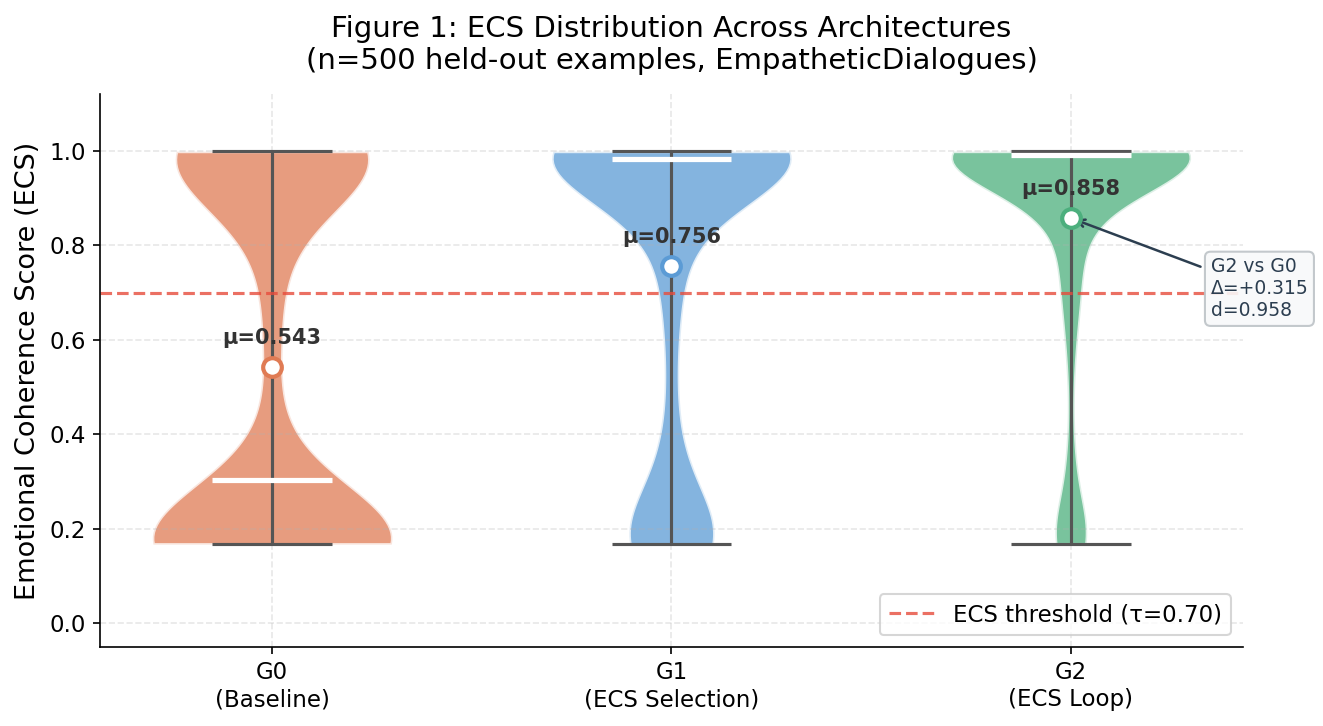

  ✓ Saved: /content/drive/MyDrive/Generator/validation_results/figures/fig1_ecs_distribution.png

Generating Figure 2 — Per-Emotion ECS...


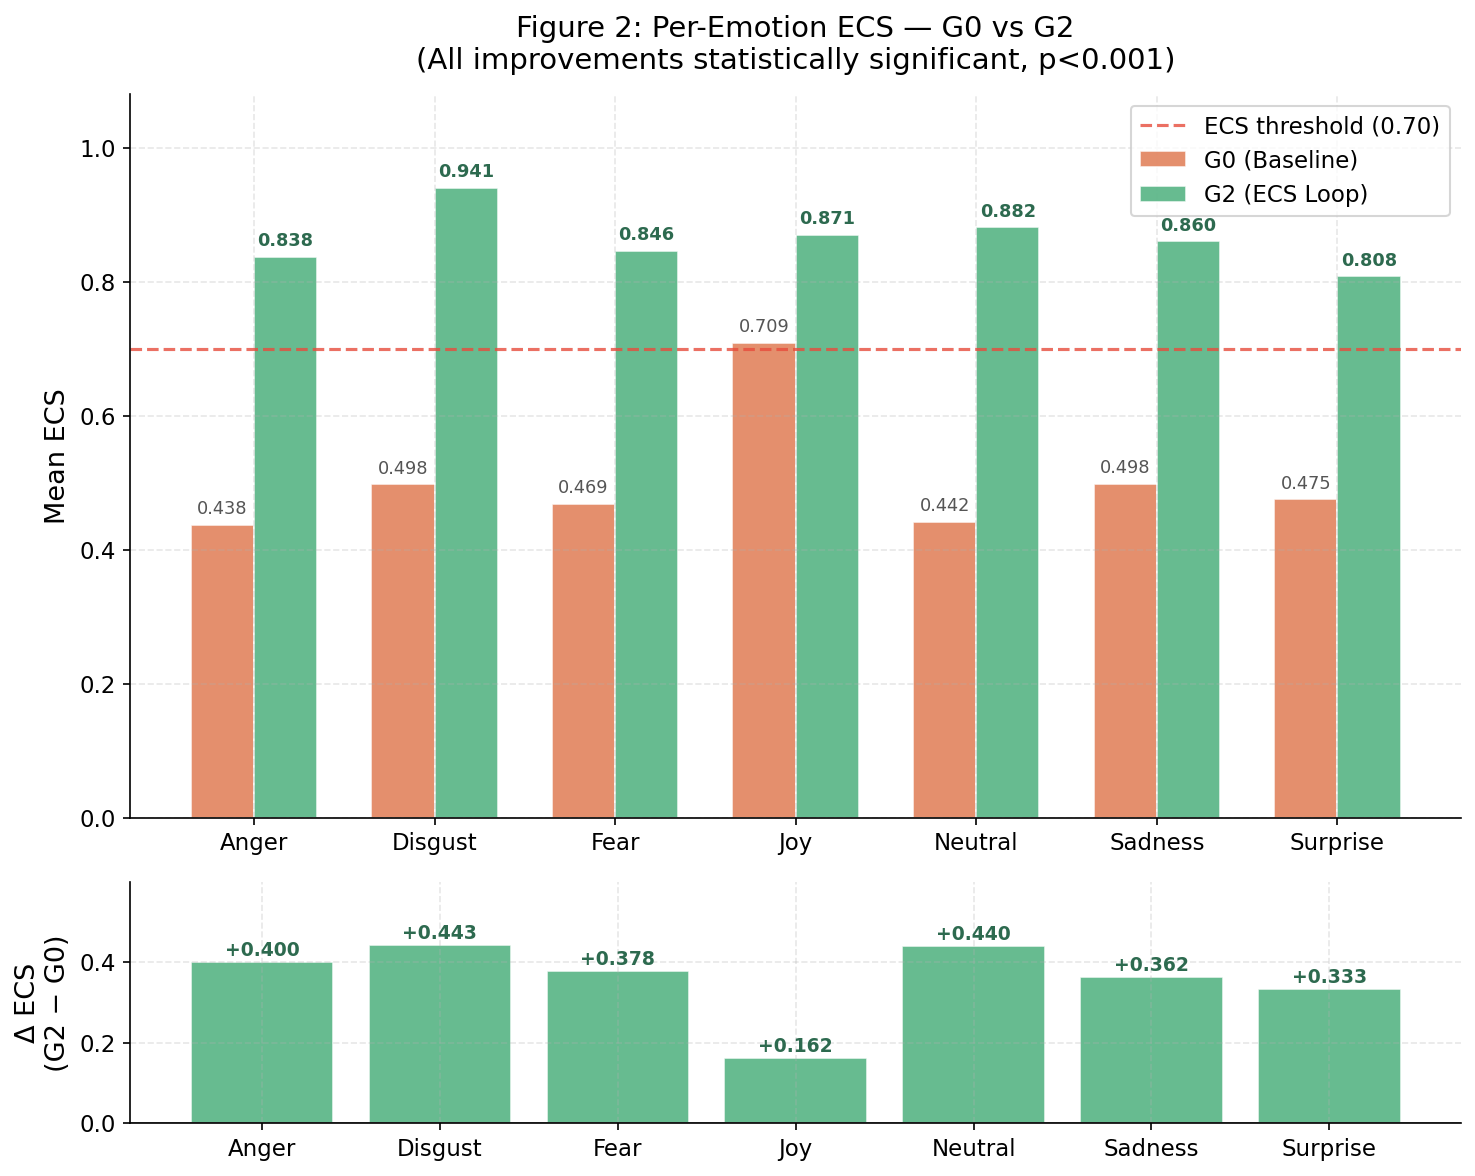

  ✓ Saved: /content/drive/MyDrive/Generator/validation_results/figures/fig2_per_emotion_ecs.png

Generating Figure 3 — Ablation Progression...


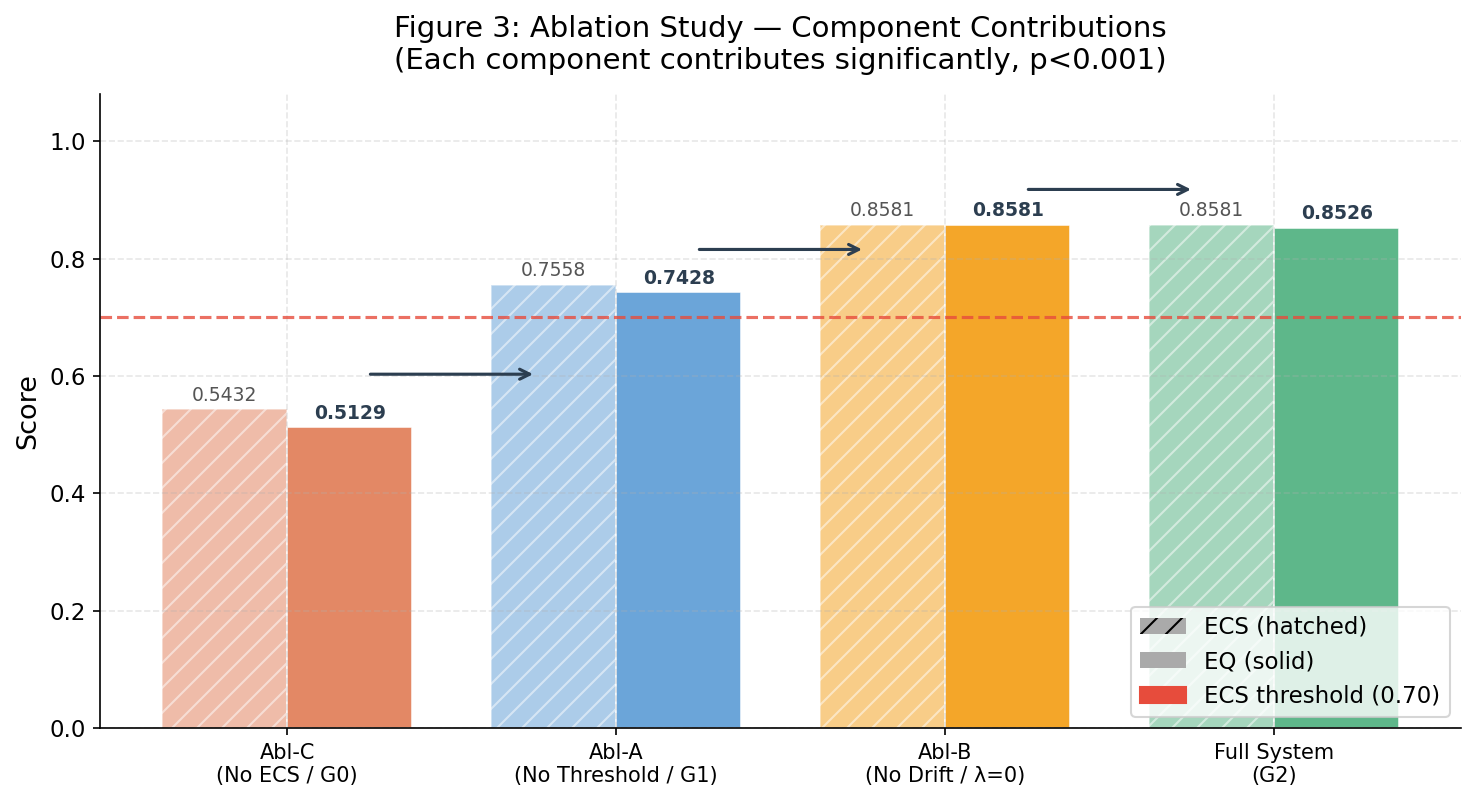

  ✓ Saved: /content/drive/MyDrive/Generator/validation_results/figures/fig3_ablation_progression.png

Generating Figure 4 — Cross-Dataset Comparison...


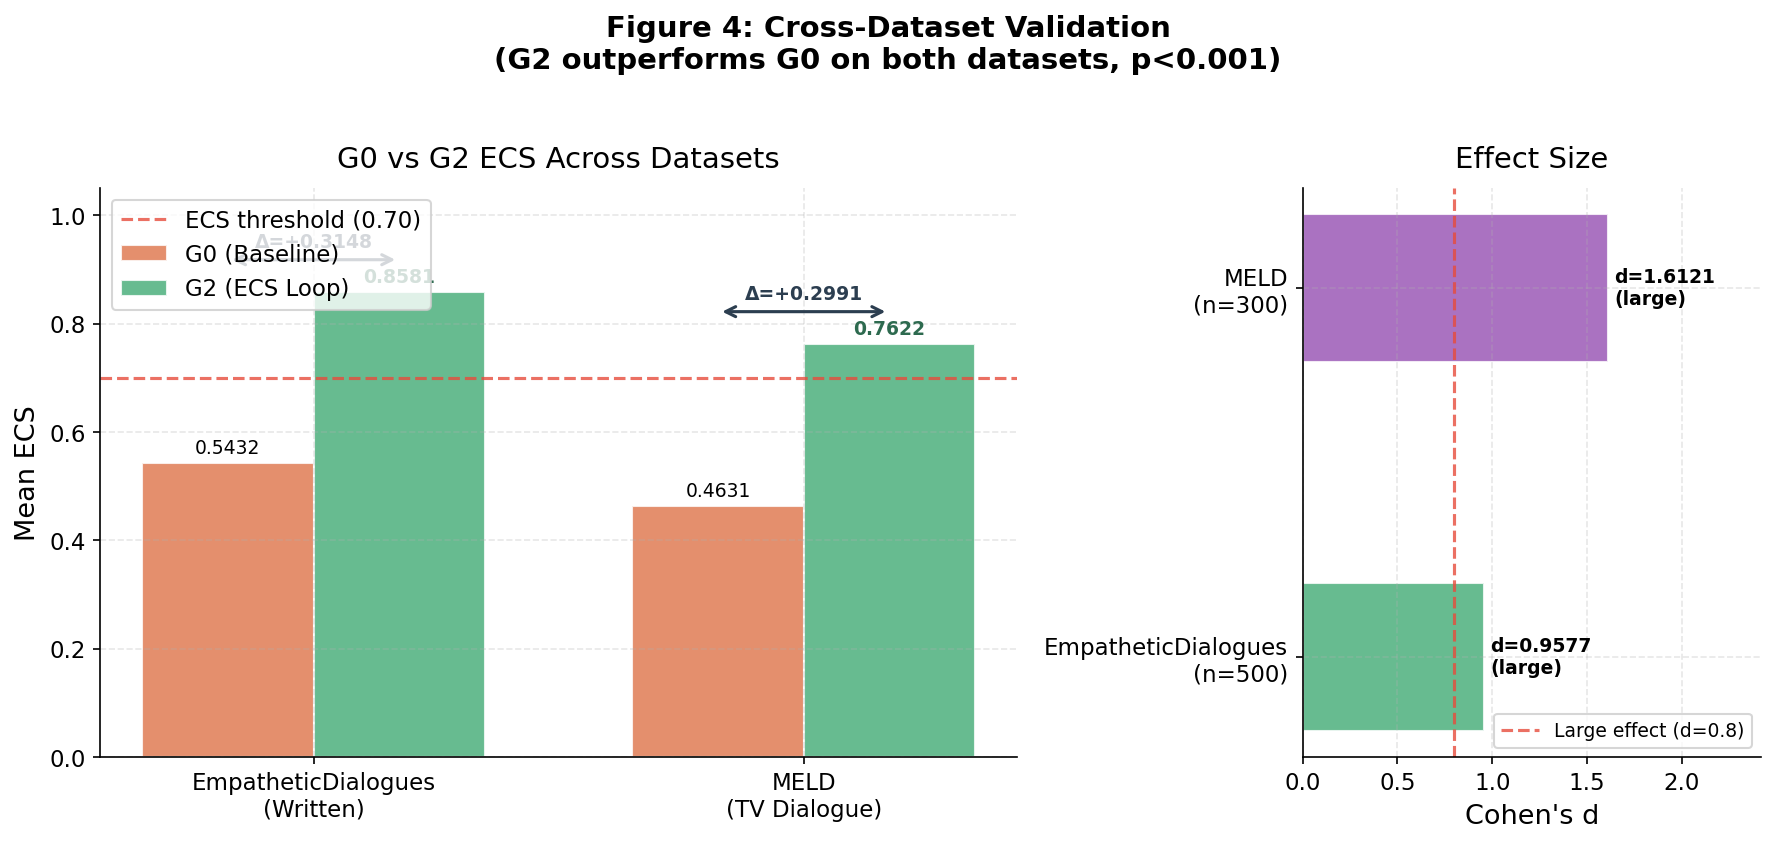

  ✓ Saved: /content/drive/MyDrive/Generator/validation_results/figures/fig4_cross_dataset.png

Generating Figure 5 — ECS-Drift Correlation...


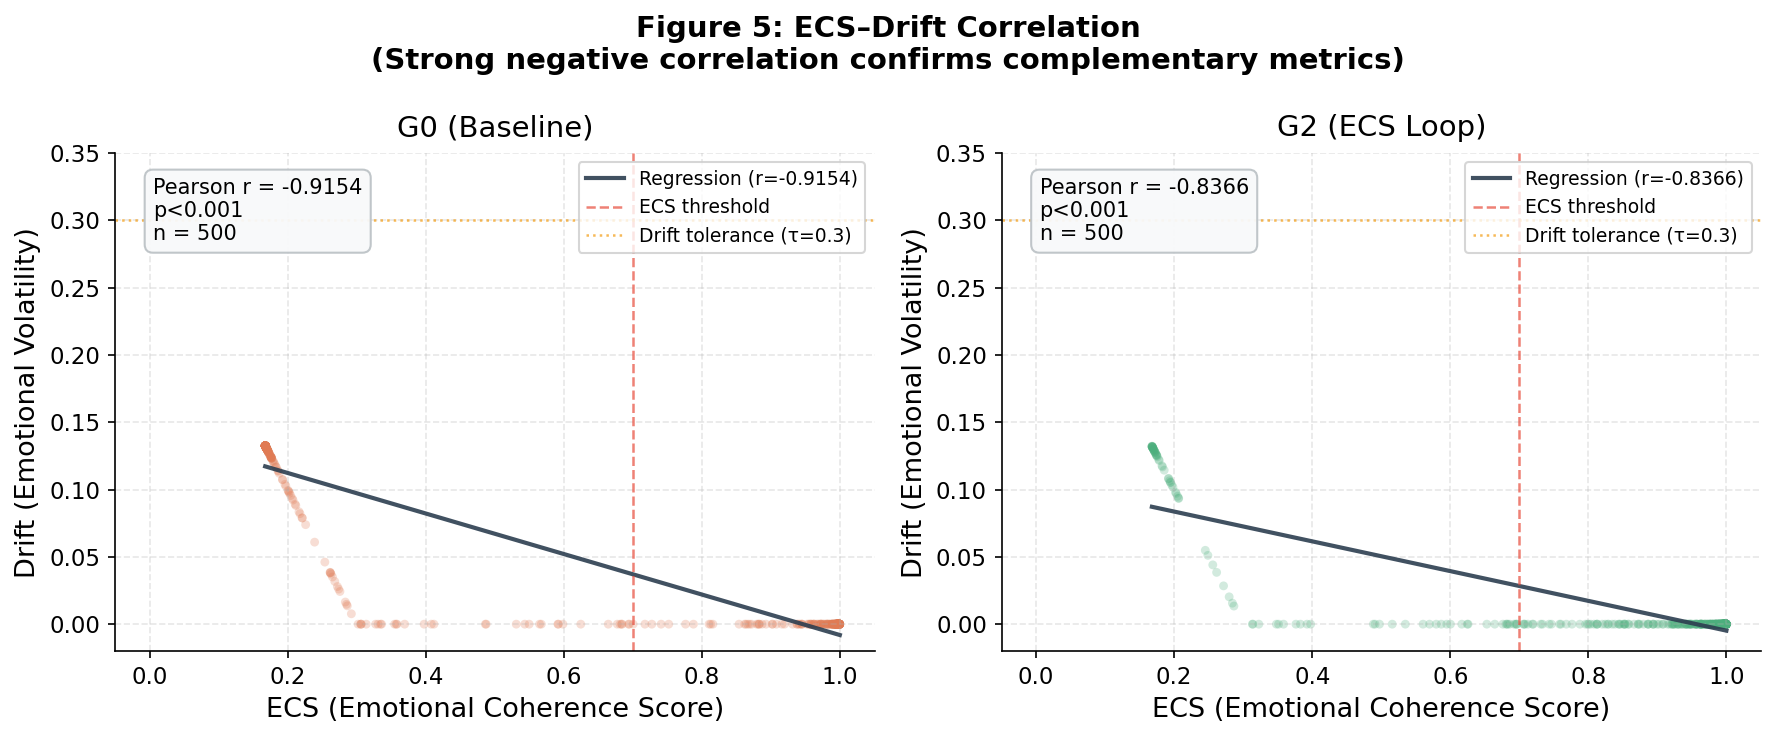

  ✓ Saved: /content/drive/MyDrive/Generator/validation_results/figures/fig5_ecs_drift_correlation.png

ALL FIGURES GENERATED

  Figure 1 : /content/drive/MyDrive/Generator/validation_results/figures/fig1_ecs_distribution.png
  Figure 2 : /content/drive/MyDrive/Generator/validation_results/figures/fig2_per_emotion_ecs.png
  Figure 3 : /content/drive/MyDrive/Generator/validation_results/figures/fig3_ablation_progression.png
  Figure 4 : /content/drive/MyDrive/Generator/validation_results/figures/fig4_cross_dataset.png
  Figure 5 : /content/drive/MyDrive/Generator/validation_results/figures/fig5_ecs_drift_correlation.png

  All saved at 300 DPI — ready for thesis inclusion.
  Recommended placement:
    Fig 1 → Results chapter, ECS validation section
    Fig 2 → Results chapter, per-emotion analysis
    Fig 3 → Results chapter, ablation study
    Fig 4 → Results chapter, cross-dataset validation
    Fig 5 → Discussion chapter, metric analysis



In [ ]:
# =============================================================================
# THESIS VISUALIZATIONS
# Dialogic Emotional Coherence in Neural Dialogue Systems
#
# Generates 5 publication-quality figures from saved results:
#   Figure 1 — ECS Distribution (violin plot, G0/G1/G2)
#   Figure 2 — Per-Emotion ECS Improvement (grouped bar chart)
#   Figure 3 — Ablation Progression (horizontal bar chart)
#   Figure 4 — Cross-Dataset Comparison (grouped bars, ED vs MELD)
#   Figure 5 — ECS-Drift Correlation (scatter plot with regression)
#
# All figures saved as high-resolution PNG (300 DPI) for thesis inclusion.
# =============================================================================

print("Installing dependencies...")
import subprocess, sys
for pkg in ["pandas", "numpy", "matplotlib", "seaborn", "scipy"]:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])
print("✓ Dependencies installed\n")

from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from scipy.spatial.distance import jensenshannon
import json
import os

# =============================================================================
# CONFIGURATION
# =============================================================================
RESULTS_CSV    = "/content/drive/MyDrive/Generator/validation_results/validation_results_full.csv"
ABLATION_JSON  = "/content/drive/MyDrive/Generator/validation_results/ablation_summary.json"
ED_JSON        = "/content/drive/MyDrive/Generator/validation_results/full_results_summary.json"
MELD_JSON      = "/content/drive/MyDrive/Generator/validation_results/meld_results_summary.json"
OUTPUT_DIR     = "/content/drive/MyDrive/Generator/validation_results/figures"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Publication style ────────────────────────────────────────────────────────
plt.rcParams.update({
    'font.family'     : 'DejaVu Sans',
    'font.size'       : 12,
    'axes.titlesize'  : 14,
    'axes.labelsize'  : 13,
    'xtick.labelsize' : 11,
    'ytick.labelsize' : 11,
    'legend.fontsize' : 11,
    'figure.dpi'      : 150,
    'axes.spines.top' : False,
    'axes.spines.right': False,
    'axes.grid'       : True,
    'grid.alpha'      : 0.3,
    'grid.linestyle'  : '--',
})

# ── Color palette ────────────────────────────────────────────────────────────
C_G0   = '#E07B54'   # Warm orange — baseline
C_G1   = '#5B9BD5'   # Mid blue — selection
C_G2   = '#4CAF7D'   # Green — full system
C_MELD = '#9B59B6'   # Purple — MELD

LABEL_MAP = {
    "afraid":"fear","terrified":"fear","anxious":"fear","apprehensive":"fear",
    "angry":"anger","annoyed":"anger","furious":"anger","jealous":"anger",
    "disgusted":"disgust",
    "joyful":"joy","excited":"joy","hopeful":"joy","content":"joy",
    "grateful":"joy","proud":"joy","confident":"joy","impressed":"joy","caring":"joy",
    "sad":"sadness","lonely":"sadness","disappointed":"sadness","nostalgic":"sadness",
    "sentimental":"sadness","embarrassed":"sadness","guilty":"sadness",
    "ashamed":"sadness","devastated":"sadness",
    "surprised":"surprise","anticipating":"surprise",
    "prepared":"neutral","trusting":"neutral","faithful":"neutral"
}

# =============================================================================
# LOAD DATA
# =============================================================================
print("Loading saved results...")
df = pd.read_csv(RESULTS_CSV)
df['emotion_7'] = df['emotion'].apply(
    lambda x: LABEL_MAP.get(str(x).lower(), str(x).lower())
)
print(f"  ✓ Main CSV: {len(df):,} examples")

with open(ABLATION_JSON)  as f: ablation  = json.load(f)
with open(ED_JSON)        as f: ed_data   = json.load(f)
with open(MELD_JSON)      as f: meld_data = json.load(f)
print(f"  ✓ JSON summaries loaded\n")


# =============================================================================
# FIGURE 1 — ECS DISTRIBUTION (VIOLIN PLOT)
# =============================================================================
print("Generating Figure 1 — ECS Distribution...")

fig, ax = plt.subplots(figsize=(9, 5))

plot_data  = []
plot_labels = []
plot_colors = []

for col, label, color in [
    ('ecs_g0', 'G0\n(Baseline)',     C_G0),
    ('ecs_g1', 'G1\n(ECS Selection)', C_G1),
    ('ecs_g2', 'G2\n(ECS Loop)',      C_G2),
]:
    plot_data.append(df[col].values)
    plot_labels.append(label)
    plot_colors.append(color)

parts = ax.violinplot(
    plot_data,
    positions=[1, 2, 3],
    showmedians=True,
    showextrema=True,
    widths=0.6
)

# Style violins
for i, (pc, color) in enumerate(zip(parts['bodies'], plot_colors)):
    pc.set_facecolor(color)
    pc.set_alpha(0.75)
    pc.set_edgecolor('white')
    pc.set_linewidth(1.5)

parts['cmedians'].set_color('white')
parts['cmedians'].set_linewidth(2.5)
parts['cmaxes'].set_color('#555555')
parts['cmins'].set_color('#555555')
parts['cbars'].set_color('#555555')

# Add mean markers
for i, (data, color) in enumerate(zip(plot_data, plot_colors), 1):
    ax.scatter(i, np.mean(data), s=80, color='white',
               edgecolors=color, linewidth=2, zorder=5)
    ax.text(i, np.mean(data) + 0.04, f'μ={np.mean(data):.3f}',
            ha='center', va='bottom', fontsize=10,
            color='#333333', fontweight='bold')

# ECS threshold line
ax.axhline(0.70, color='#E74C3C', linestyle='--',
           linewidth=1.5, alpha=0.8, label='ECS threshold (τ=0.70)')

ax.set_xticks([1, 2, 3])
ax.set_xticklabels(plot_labels)
ax.set_ylabel('Emotional Coherence Score (ECS)')
ax.set_title('Figure 1: ECS Distribution Across Architectures\n'
             '(n=500 held-out examples, EmpatheticDialogues)',
             pad=12)
ax.set_ylim(-0.05, 1.12)
ax.legend(loc='lower right')

# Annotation
ax.annotate(
    f'G2 vs G0\nΔ=+0.315\nd=0.958',
    xy=(3, np.mean(df['ecs_g2'])),
    xytext=(3.35, 0.65),
    fontsize=9, color='#2C3E50',
    arrowprops=dict(arrowstyle='->', color='#2C3E50', lw=1.2),
    bbox=dict(boxstyle='round,pad=0.3', facecolor='#F8F9FA',
              edgecolor='#BDC3C7', alpha=0.9)
)

plt.tight_layout()
path1 = f"{OUTPUT_DIR}/fig1_ecs_distribution.png"
plt.savefig(path1, dpi=300, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()
print(f"  ✓ Saved: {path1}\n")


# =============================================================================
# FIGURE 2 — PER-EMOTION ECS IMPROVEMENT
# =============================================================================
print("Generating Figure 2 — Per-Emotion ECS...")

emotions = ['anger', 'disgust', 'fear', 'joy',
            'neutral', 'sadness', 'surprise']
g0_means, g2_means, deltas = [], [], []

for emo in emotions:
    sub  = df[df['emotion_7'] == emo]
    g0_m = sub['ecs_g0'].mean()
    g2_m = sub['ecs_g2'].mean()
    g0_means.append(g0_m)
    g2_means.append(g2_m)
    deltas.append(g2_m - g0_m)

x     = np.arange(len(emotions))
width = 0.35

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8),
                                gridspec_kw={'height_ratios': [3, 1]})

# Main bars
bars_g0 = ax1.bar(x - width/2, g0_means, width,
                   label='G0 (Baseline)', color=C_G0,
                   alpha=0.85, edgecolor='white', linewidth=0.8)
bars_g2 = ax1.bar(x + width/2, g2_means, width,
                   label='G2 (ECS Loop)', color=C_G2,
                   alpha=0.85, edgecolor='white', linewidth=0.8)

# Value labels on bars
for bar in bars_g0:
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.01,
             f'{bar.get_height():.3f}',
             ha='center', va='bottom', fontsize=8.5, color='#555')

for bar in bars_g2:
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.01,
             f'{bar.get_height():.3f}',
             ha='center', va='bottom', fontsize=8.5, color='#2d6a4f',
             fontweight='bold')

ax1.axhline(0.70, color='#E74C3C', linestyle='--',
            linewidth=1.5, alpha=0.8, label='ECS threshold (0.70)')
ax1.set_xticks(x)
ax1.set_xticklabels([e.capitalize() for e in emotions])
ax1.set_ylabel('Mean ECS')
ax1.set_title('Figure 2: Per-Emotion ECS — G0 vs G2\n'
              '(All improvements statistically significant, p<0.001)',
              pad=12)
ax1.set_ylim(0, 1.08)
ax1.legend()

# Delta subplot
bar_colors = [C_G2 if d > 0 else C_G0 for d in deltas]
ax2.bar(x, deltas, color=bar_colors, alpha=0.85,
        edgecolor='white', linewidth=0.8)
for i, (xi, d) in enumerate(zip(x, deltas)):
    ax2.text(xi, d + 0.005, f'+{d:.3f}',
             ha='center', va='bottom', fontsize=9,
             fontweight='bold', color='#2d6a4f')

ax2.set_xticks(x)
ax2.set_xticklabels([e.capitalize() for e in emotions])
ax2.set_ylabel('Δ ECS\n(G2 − G0)')
ax2.set_ylim(0, max(deltas) * 1.35)
ax2.axhline(0, color='#888', linewidth=0.8)

plt.tight_layout()
path2 = f"{OUTPUT_DIR}/fig2_per_emotion_ecs.png"
plt.savefig(path2, dpi=300, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()
print(f"  ✓ Saved: {path2}\n")


# =============================================================================
# FIGURE 3 — ABLATION PROGRESSION
# =============================================================================
print("Generating Figure 3 — Ablation Progression...")

abl_systems = ablation['ablation_systems']
systems = [
    ('Abl-C\n(No ECS / G0)',      abl_systems['Abl-C (no ECS / G0)']['eq'],
     abl_systems['Abl-C (no ECS / G0)']['ecs'],     C_G0),
    ('Abl-A\n(No Threshold / G1)', abl_systems['Abl-A (no threshold / G1)']['eq'],
     abl_systems['Abl-A (no threshold / G1)']['ecs'], C_G1),
    ('Abl-B\n(No Drift / λ=0)',   abl_systems['Abl-B (no Drift / λ=0)']['eq'],
     abl_systems['Abl-B (no Drift / λ=0)']['ecs'],   '#F39C12'),
    ('Full System\n(G2)',          abl_systems['Full System (G2)']['eq'],
     abl_systems['Full System (G2)']['ecs'],           C_G2),
]

labels   = [s[0] for s in systems]
eq_vals  = [s[1] for s in systems]
ecs_vals = [s[2] for s in systems]
colors   = [s[3] for s in systems]

x     = np.arange(len(systems))
width = 0.38

fig, ax = plt.subplots(figsize=(10, 5.5))

bars_ecs = ax.bar(x - width/2, ecs_vals, width,
                  label='ECS', color=colors, alpha=0.5,
                  edgecolor='white', linewidth=0.8, hatch='//')
bars_eq  = ax.bar(x + width/2, eq_vals, width,
                  label='EQ', color=colors, alpha=0.9,
                  edgecolor='white', linewidth=0.8)

# Value labels
for bar, val in zip(bars_ecs, ecs_vals):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.008,
            f'{val:.4f}', ha='center', va='bottom',
            fontsize=9, color='#555')

for bar, val in zip(bars_eq, eq_vals):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.008,
            f'{val:.4f}', ha='center', va='bottom',
            fontsize=9, fontweight='bold', color='#2C3E50')

# Arrow showing progression
for i in range(len(systems) - 1):
    y_pos = max(ecs_vals[i], eq_vals[i]) + 0.06
    ax.annotate('',
        xy=(x[i+1] - width/2 - 0.05, y_pos),
        xytext=(x[i] + width/2 + 0.05, y_pos),
        arrowprops=dict(arrowstyle='->', color='#2C3E50',
                        lw=1.5, connectionstyle='arc3,rad=0'))

ax.axhline(0.70, color='#E74C3C', linestyle='--',
           linewidth=1.5, alpha=0.8, label='ECS threshold (0.70)')
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=10)
ax.set_ylabel('Score')
ax.set_title('Figure 3: Ablation Study — Component Contributions\n'
             '(Each component contributes significantly, p<0.001)',
             pad=12)
ax.set_ylim(0, 1.08)

ecs_patch = mpatches.Patch(facecolor='#aaa', hatch='//',
                            label='ECS (hatched)')
eq_patch  = mpatches.Patch(facecolor='#aaa', label='EQ (solid)')
ax.legend(handles=[ecs_patch, eq_patch,
                   mpatches.Patch(color='#E74C3C',
                                  label='ECS threshold (0.70)')],
          loc='lower right')

plt.tight_layout()
path3 = f"{OUTPUT_DIR}/fig3_ablation_progression.png"
plt.savefig(path3, dpi=300, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()
print(f"  ✓ Saved: {path3}\n")


# =============================================================================
# FIGURE 4 — CROSS-DATASET COMPARISON
# =============================================================================
print("Generating Figure 4 — Cross-Dataset Comparison...")

ed_g0   = ed_data['overall']['g0']['ecs']
ed_g2   = ed_data['overall']['g2']['ecs']
meld_g0 = meld_data['overall']['g0']['ecs']
meld_g2 = meld_data['overall']['g2']['ecs']

ed_d    = ed_data['significance']['ecs_g2_vs_g0']['cohens_d']
meld_d  = meld_data['significance']['ecs_g2_vs_g0']['cohens_d']

datasets = ['EmpatheticDialogues\n(Written)', 'MELD\n(TV Dialogue)']
g0_vals  = [ed_g0, meld_g0]
g2_vals  = [ed_g2, meld_g2]
d_vals   = [ed_d,  meld_d]

x     = np.arange(len(datasets))
width = 0.35

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5.5),
                                gridspec_kw={'width_ratios': [2, 1]})

# Left: grouped bars
b0 = ax1.bar(x - width/2, g0_vals, width,
             label='G0 (Baseline)', color=C_G0,
             alpha=0.85, edgecolor='white')
b2 = ax1.bar(x + width/2, g2_vals, width,
             label='G2 (ECS Loop)', color=C_G2,
             alpha=0.85, edgecolor='white')

# Value labels + delta annotations
for i, (g0, g2, dataset) in enumerate(zip(g0_vals, g2_vals, datasets)):
    ax1.text(x[i] - width/2, g0 + 0.01, f'{g0:.4f}',
             ha='center', va='bottom', fontsize=9)
    ax1.text(x[i] + width/2, g2 + 0.01, f'{g2:.4f}',
             ha='center', va='bottom', fontsize=9,
             fontweight='bold', color='#2d6a4f')
    # Delta bracket
    delta = g2 - g0
    y_top = max(g0, g2) + 0.06
    ax1.annotate('',
        xy=(x[i] + width/2, y_top),
        xytext=(x[i] - width/2, y_top),
        arrowprops=dict(arrowstyle='<->', color='#2C3E50', lw=1.5))
    ax1.text(x[i], y_top + 0.015, f'Δ={delta:+.4f}',
             ha='center', va='bottom', fontsize=9,
             color='#2C3E50', fontweight='bold')

ax1.axhline(0.70, color='#E74C3C', linestyle='--',
            linewidth=1.5, alpha=0.8, label='ECS threshold (0.70)')
ax1.set_xticks(x)
ax1.set_xticklabels(datasets)
ax1.set_ylabel('Mean ECS')
ax1.set_title('G0 vs G2 ECS Across Datasets', pad=10)
ax1.set_ylim(0, 1.05)
ax1.legend(loc='upper left')

# Right: Cohen's d comparison
colors_d = [C_G2, C_MELD]
bars_d   = ax2.barh(['EmpatheticDialogues\n(n=500)',
                      'MELD\n(n=300)'],
                     d_vals, color=colors_d, alpha=0.85,
                     edgecolor='white', height=0.4)
for bar, d in zip(bars_d, d_vals):
    ax2.text(bar.get_width() + 0.03, bar.get_y() + bar.get_height()/2,
             f'd={d:.4f}\n(large)', va='center', fontsize=9,
             fontweight='bold')

ax2.axvline(0.8, color='#E74C3C', linestyle='--',
            linewidth=1.5, alpha=0.8, label='Large effect (d=0.8)')
ax2.set_xlabel("Cohen's d")
ax2.set_title("Effect Size", pad=10)
ax2.set_xlim(0, max(d_vals) * 1.5)
ax2.legend(fontsize=9)

fig.suptitle('Figure 4: Cross-Dataset Validation\n'
             '(G2 outperforms G0 on both datasets, p<0.001)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
path4 = f"{OUTPUT_DIR}/fig4_cross_dataset.png"
plt.savefig(path4, dpi=300, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()
print(f"  ✓ Saved: {path4}\n")


# =============================================================================
# FIGURE 5 — ECS-DRIFT CORRELATION SCATTER
# =============================================================================
print("Generating Figure 5 — ECS-Drift Correlation...")

ecs_g2   = df['ecs_g2'].values
drift_g2 = df['drift_g2'].values
ecs_g0   = df['ecs_g0'].values
drift_g0 = df['drift_g0'].values

r_g2, p_g2 = stats.pearsonr(ecs_g2, drift_g2)
r_g0, p_g0 = stats.pearsonr(ecs_g0, drift_g0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

for ax, ecs, drift, color, label, r, p, title in [
    (ax1, ecs_g0, drift_g0, C_G0, 'G0', r_g0, p_g0, 'G0 (Baseline)'),
    (ax2, ecs_g2, drift_g2, C_G2, 'G2', r_g2, p_g2, 'G2 (ECS Loop)'),
]:
    # Scatter
    ax.scatter(ecs, drift, alpha=0.25, s=18, color=color,
               edgecolors='none', rasterized=True)

    # Regression line
    m, b   = np.polyfit(ecs, drift, 1)
    x_line = np.linspace(ecs.min(), ecs.max(), 200)
    ax.plot(x_line, m * x_line + b,
            color='#2C3E50', linewidth=2.0, alpha=0.9,
            label=f'Regression (r={r:.4f})')

    # Threshold lines
    ax.axvline(0.70, color='#E74C3C', linestyle='--',
               linewidth=1.2, alpha=0.7, label='ECS threshold')
    ax.axhline(0.30, color='#F39C12', linestyle=':',
               linewidth=1.2, alpha=0.7, label='Drift tolerance (τ=0.3)')

    # Annotation box
    sig_str = "p<0.001" if p < 0.001 else f"p={p:.4f}"
    ax.text(0.05, 0.95,
            f'Pearson r = {r:.4f}\n{sig_str}\nn = {len(ecs)}',
            transform=ax.transAxes, fontsize=10,
            verticalalignment='top',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='#F8F9FA',
                      edgecolor='#BDC3C7', alpha=0.95))

    ax.set_xlabel('ECS (Emotional Coherence Score)')
    ax.set_ylabel('Drift (Emotional Volatility)')
    ax.set_title(f'{title}', pad=8)
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.02, 0.35)
    ax.legend(fontsize=9, loc='upper right')

fig.suptitle('Figure 5: ECS–Drift Correlation\n'
             '(Strong negative correlation confirms complementary metrics)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
path5 = f"{OUTPUT_DIR}/fig5_ecs_drift_correlation.png"
plt.savefig(path5, dpi=300, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()
print(f"  ✓ Saved: {path5}\n")


# =============================================================================
# SUMMARY
# =============================================================================
print("=" * 60)
print("ALL FIGURES GENERATED")
print("=" * 60)
print(f"""
  Figure 1 : {path1}
  Figure 2 : {path2}
  Figure 3 : {path3}
  Figure 4 : {path4}
  Figure 5 : {path5}

  All saved at 300 DPI — ready for thesis inclusion.
  Recommended placement:
    Fig 1 → Results chapter, ECS validation section
    Fig 2 → Results chapter, per-emotion analysis
    Fig 3 → Results chapter, ablation study
    Fig 4 → Results chapter, cross-dataset validation
    Fig 5 → Discussion chapter, metric analysis
""")

#GPT_LArge Setup

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# =========================
# GPT-2 LARGE Empathetic Dialogue Generator
# - Full Dataset (61k+ samples)
# - Same structure as GPT-2 original
# - Large-specific: lr=2e-5, batch=2, grad_accum=2, weight_decay=0.01
# =========================

print("Installing dependencies...")
import subprocess
import sys

packages = ["transformers", "datasets", "pandas", "torch"]
for pkg in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

import os
os.environ["WANDB_DISABLED"] = "true"

import torch
import pandas as pd
import numpy as np
from torch.utils.data import Dataset, DataLoader
from transformers import (
    GPT2LMHeadModel,
    GPT2Tokenizer,
    get_linear_schedule_with_warmup
)
from torch.optim import AdamW
from tqdm import tqdm
import random


# -------------------------
# CONFIGURATION
# -------------------------
class Config:
    # Data
    data_path = "/content/drive/MyDrive/Generator/emotion-emotion_69k.csv"
    save_path = "/content/drive/MyDrive/Generator/gpt2_large_empathetic_final"  # changed

    # Model
    model_name = "gpt2-large"  # changed

    # Training — tuned for Large
    num_epochs    = 3
    batch_size    = 2          # changed: memory constraint
    grad_accum    = 2          # added: effective batch = 4, same as original
    learning_rate = 2e-5       # changed: Large is more sensitive to LR
    warmup_ratio  = 0.1
    max_grad_norm = 1.0
    weight_decay  = 0.01       # added: regularization more important at larger scale

    # Data
    max_len = 300
    max_samples = None  # USE FULL DATASET
    val_split = 0.1

    # Special tokens
    bos_token = "<bos>"
    eos_token = "<eos>"
    sp1_token = "<sp1>"  # User
    sp2_token = "<sp2>"  # Agent

    # Device
    device = "cuda" if torch.cuda.is_available() else "cpu"
    seed = 42

cfg = Config()

# Set seed
random.seed(cfg.seed)
np.random.seed(cfg.seed)
torch.manual_seed(cfg.seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(cfg.seed)

print(f"Device: {cfg.device}\n")


# -------------------------
# DATA LOADING
# -------------------------
print("="*70)
print("LOADING DATA")
print("="*70)

def load_data(filepath):
    """Load and parse CSV"""
    df = pd.read_csv(filepath, on_bad_lines='skip', encoding='utf-8', low_memory=False)

    if any(str(col).startswith(('0', '1', 'I ', 'A ')) or 'Customer' in str(col) for col in df.columns):
        df = pd.read_csv(filepath, header=None, on_bad_lines='skip', encoding='utf-8', low_memory=False)
        df.columns = ['idx', 'situation', 'emotion', 'customer', 'agent'] + [f'extra_{i}' for i in range(len(df.columns)-5)]

    print(f" Loaded {len(df):,} rows")
    return df


def clean_text(text):
    """Clean text"""
    if pd.isna(text):
        return ""
    text = str(text).strip()

    for prefix in ["Customer :", "Customer:", "Agent :", "Agent:"]:
        if text.startswith(prefix):
            text = text[len(prefix):].strip()

    for marker in ["\nAgent :", "\r\nAgent :", "\nAgent:", "\r\nAgent:"]:
        if marker in text:
            text = text.split(marker)[0].strip()

    return text


def prepare_dialogues(df, config):
    """Prepare dialogues in format: <bos> [emotion: X] <sp1> user <sp2> agent <eos>"""
    print("\nPreparing dialogues...")

    cols      = df.columns.tolist()
    sit_col   = next((c for c in cols if 'situation' in str(c).lower()), cols[1])
    emo_col   = next((c for c in cols if 'emotion'   in str(c).lower()), cols[2])
    cust_col  = next((c for c in cols if 'customer'  in str(c).lower()), cols[3])
    agent_col = next((c for c in cols if 'agent'     in str(c).lower()), cols[4])

    df = df[[sit_col, emo_col, cust_col, agent_col]].copy()
    df.columns = ['situation', 'emotion', 'customer', 'agent']

    for col in df.columns:
        df[col] = df[col].apply(clean_text)

    df = df[
        (df['customer'].str.len() > 5) &
        (df['agent'].str.len() > 3) &
        (df['emotion'].str.len() > 0)
    ]

    print(f" Clean samples: {len(df):,}")

    if config.max_samples is not None and len(df) > config.max_samples:
        df = df.sample(n=config.max_samples, random_state=config.seed)
        print(f"Sampled to: {len(df):,}")
    else:
        print(f" Using full dataset: {len(df):,}")

    dialogues = []
    for _, row in df.iterrows():
        dialogue = (
            f"{config.bos_token} [emotion: {row['emotion']}] "
            f"{config.sp1_token} {row['customer']} "
            f"{config.sp2_token} {row['agent']} "
            f"{config.eos_token}"
        )
        dialogues.append(dialogue)

    print(f"Created {len(dialogues):,} dialogue examples")
    print(f"\nSample dialogue:\n{dialogues[0]}\n")

    random.shuffle(dialogues)
    split_idx = int(len(dialogues) * (1 - config.val_split))

    train_dialogues = dialogues[:split_idx]
    val_dialogues   = dialogues[split_idx:]

    print(f"Train: {len(train_dialogues):,} | Val: {len(val_dialogues):,}")

    return train_dialogues, val_dialogues


# Load data
df = load_data(cfg.data_path)
train_dialogues, val_dialogues = prepare_dialogues(df, cfg)


# -------------------------
# TOKENIZER & MODEL
# -------------------------
print("\n" + "="*70)
print("LOADING MODEL & TOKENIZER")
print("="*70)

tokenizer = GPT2Tokenizer.from_pretrained(cfg.model_name)

special_tokens = {
    'bos_token': cfg.bos_token,
    'eos_token': cfg.eos_token,
    'pad_token': '<pad>',
    'additional_special_tokens': [cfg.sp1_token, cfg.sp2_token]
}

tokenizer.add_special_tokens(special_tokens)
print(f" Added special tokens: {list(special_tokens.values())}")

model = GPT2LMHeadModel.from_pretrained(cfg.model_name)
model.resize_token_embeddings(len(tokenizer))
model.to(cfg.device)

print(f" Model: {cfg.model_name}")
print(f" Vocab size: {len(tokenizer)}")
print(f" Parameters: {sum(p.numel() for p in model.parameters()):,}")


# -------------------------
# DATASET CLASS
# -------------------------
class DialogueDataset(Dataset):
    def __init__(self, dialogues, tokenizer, max_len):
        self.dialogues = dialogues
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.dialogues)

    def __getitem__(self, idx):
        dialogue = self.dialogues[idx]
        tokens   = self.tokenizer.encode(dialogue, max_length=self.max_len, truncation=True)

        if len(tokens) < self.max_len:
            tokens = tokens + [self.tokenizer.pad_token_id] * (self.max_len - len(tokens))

        tokens = torch.tensor(tokens, dtype=torch.long)
        labels = tokens.clone()
        labels[labels == self.tokenizer.pad_token_id] = -100

        return {'input_ids': tokens, 'labels': labels}


# Create datasets
train_dataset = DialogueDataset(train_dialogues, tokenizer, cfg.max_len)
val_dataset   = DialogueDataset(val_dialogues,   tokenizer, cfg.max_len)

train_loader = DataLoader(train_dataset, batch_size=cfg.batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=cfg.batch_size)

print(f"\n Created dataloaders")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches: {len(val_loader)}")


# -------------------------
# TRAINING SETUP
# -------------------------
print("\n" + "="*70)
print("TRAINING SETUP")
print("="*70)

optimizer = AdamW(model.parameters(), lr=cfg.learning_rate, weight_decay=cfg.weight_decay)

total_steps  = len(train_loader) * cfg.num_epochs
warmup_steps = int(total_steps * cfg.warmup_ratio)
scheduler    = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

print(f"Optimizer: AdamW (lr={cfg.learning_rate}, weight_decay={cfg.weight_decay})")
print(f" Effective batch size: {cfg.batch_size * cfg.grad_accum}")
print(f" Total steps: {total_steps}")
print(f" Warmup steps: {warmup_steps}")


# -------------------------
# TRAINING LOOP
# -------------------------
def train_epoch(model, loader, optimizer, scheduler, device, max_grad_norm, grad_accum):
    model.train()
    total_loss = 0
    optimizer.zero_grad()

    progress_bar = tqdm(loader, desc="Training")
    for step, batch in enumerate(progress_bar):
        input_ids = batch['input_ids'].to(device)
        labels    = batch['labels'].to(device)

        outputs = model(input_ids=input_ids, labels=labels)
        loss    = outputs.loss / grad_accum

        loss.backward()
        total_loss += outputs.loss.item()

        if (step + 1) % grad_accum == 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()

        progress_bar.set_postfix({'loss': f'{outputs.loss.item():.4f}'})

    return total_loss / len(loader)


def evaluate(model, loader, device):
    model.eval()
    total_loss = 0

    with torch.no_grad():
        for batch in tqdm(loader, desc="Evaluating"):
            input_ids = batch['input_ids'].to(device)
            labels    = batch['labels'].to(device)

            outputs = model(input_ids=input_ids, labels=labels)
            total_loss += outputs.loss.item()

    return total_loss / len(loader)


print("\n" + "="*70)
print("TRAINING")
print("="*70)

best_val_loss = float('inf')

for epoch in range(cfg.num_epochs):
    print(f"\nEpoch {epoch + 1}/{cfg.num_epochs}")
    print("-" * 70)

    train_loss = train_epoch(model, train_loader, optimizer, scheduler,
                             cfg.device, cfg.max_grad_norm, cfg.grad_accum)
    val_loss   = evaluate(model, val_loader, cfg.device)

    train_ppl = np.exp(train_loss)
    val_ppl   = np.exp(val_loss)

    print(f"\nResults:")
    print(f"  Train Loss: {train_loss:.4f} | PPL: {train_ppl:.2f}")
    print(f"  Val Loss: {val_loss:.4f} | PPL: {val_ppl:.2f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        print(f"New best! Saving checkpoint...")

        os.makedirs(cfg.save_path, exist_ok=True)
        model.save_pretrained(cfg.save_path)
        tokenizer.save_pretrained(cfg.save_path)

        print(f"Saved to: {cfg.save_path}")


# -------------------------
# GENERATION TEST
# -------------------------
print("\n" + "="*70)
print("GENERATION TEST")
print("="*70)

def generate_single_response(emotion, user_utterance, model, tokenizer, device,
                              temperature=0.75, max_length=50):
    """Generate a single response with given temperature"""
    model.eval()

    prompt = (
        f"{cfg.bos_token} [emotion: {emotion}] "
        f"{cfg.sp1_token} {user_utterance} "
        f"{cfg.sp2_token}"
    )

    input_ids = tokenizer.encode(prompt, return_tensors='pt').to(device)

    with torch.no_grad():
        output_ids = model.generate(
            input_ids,
            max_length=input_ids.shape[1] + max_length,
            min_length=input_ids.shape[1] + 8,
            do_sample=True,
            top_p=0.90,
            top_k=50,
            temperature=temperature,
            repetition_penalty=1.3,
            no_repeat_ngram_size=3,
            length_penalty=0.8,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )

    generated_text = tokenizer.decode(output_ids[0], skip_special_tokens=False)

    if cfg.sp2_token in generated_text:
        response = generated_text.split(cfg.sp2_token)[1]
        if cfg.eos_token in response:
            response = response.split(cfg.eos_token)[0]
        response = response.strip()

        for token in [cfg.bos_token, cfg.sp1_token, cfg.sp2_token, cfg.eos_token, '<pad>']:
            response = response.replace(token, '')

        response = response.strip()

        sentences = response.replace('!', '.').replace('?', '.').split('.')
        sentences = [s.strip() for s in sentences if len(s.strip()) > 3]

        if len(sentences) > 2:
            response = '. '.join(sentences[:2]) + '.'

        return response

    return "I understand how you feel."


def score_response(response):
    """Score a response based on multiple criteria"""
    words = response.split()
    score = 100

    length = len(words)
    if length < 8:
        score -= 30
    elif length > 25:
        score -= 20
    elif 12 <= length <= 18:
        score += 10

    question_count = response.count('?')
    if question_count > 1:
        score -= 15
    elif response.endswith('?'):
        score -= 5

    if not response[-1] in '.!?':
        score -= 10

    words_lower = [w.lower() for w in words]
    unique_ratio = len(set(words_lower)) / len(words_lower) if words_lower else 1
    if unique_ratio < 0.7:
        score -= int((1 - unique_ratio) * 30)

    return score


def generate_best_response(emotion, user_utterance, model, tokenizer, device):
    """Generate multiple candidates and select the best one"""
    candidates   = []
    temperatures = [0.70, 0.75, 0.80, 0.85]  # warmer range for Large

    for temp in temperatures:
        response = generate_single_response(
            emotion, user_utterance, model, tokenizer, device, temperature=temp
        )
        candidates.append(response)

    scored = [(score_response(c), c) for c in candidates]
    best_score, best_response = max(scored, key=lambda x: x[0])

    return best_response


# Test examples
test_examples = [
    ("caring",       "My friend helped me move to my new apartment. They were so kind."),
    ("sad",          "I lost my childhood pet yesterday. I miss them so much."),
    ("excited",      "I just got accepted to my dream university!"),
    ("anxious",      "I have a big presentation tomorrow and I'm really nervous."),
    ("grateful",     "My parents surprised me with a birthday party."),
    ("lonely",       "All my friends are busy and I'm spending the weekend alone."),
    ("proud",        "I finally finished writing my book after two years of work."),
    ("disappointed", "I didn't get the job I really wanted."),
    ("angry",        "My coworker took credit for my work in the meeting."),
    ("hopeful",      "I'm interviewing for a new position next week."),
]

print()
for emotion, user_msg in test_examples:
    response = generate_best_response(emotion, user_msg, model, tokenizer, cfg.device)

    print(f"{'='*70}")
    print(f"Emotion: {emotion}")
    print(f"User: {user_msg}")
    print(f"Agent: {response}")
    print()


print("="*70)
print("TRAINING COMPLETE!")
print("="*70)
print(f"\nBest validation loss: {best_val_loss:.4f}")
print(f"Best perplexity: {np.exp(best_val_loss):.2f}")
print(f"Model saved at: {cfg.save_path}")
print("\nGeneration uses multi-candidate selection with scoring for best quality!")

Installing dependencies...
Device: cuda

LOADING DATA
 Loaded 64,635 rows

Preparing dialogues...
 Clean samples: 64,317
 Using full dataset: 64,317
Created 64,317 dialogue examples

Sample dialogue:
<bos> [emotion: sentimental] <sp1> I remember going to see the fireworks with my best friend. It was the first time we ever spent time alone together. Although there was a lot of people, we felt like the only people in the world. <sp2> Was this a friend you were in love with, or just a best friend? <eos>

✓ Train: 57,885 | Val: 6,432

LOADING MODEL & TOKENIZER


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

Evaluating: 100%|██████████| 3216/3216 [03:39<00:00, 14.64it/s]


Results:
  Train Loss: 1.4625 | PPL: 4.32
  Val Loss: 1.8364 | PPL: 6.27
New best! Saving checkpoint...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

The following generation flags are not valid and may be ignored: ['length_penalty']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Saved to: /content/drive/MyDrive/Generator/gpt2_large_empathetic_final

GENERATION TEST

Emotion: caring
User: My friend helped me move to my new apartment. They were so kind.
Agent: That's really sweet of them! Was it your first time moving too?

Emotion: sad
User: I lost my childhood pet yesterday. I miss them so much.
Agent: What kind of animal was it? That is very saddening to hear, especially when you know they are going through a hard time right now.

Emotion: excited
User: I just got accepted to my dream university!
Agent: That's amazing. You must be so proud of yourself!

Emotion: anxious
User: I have a big presentation tomorrow and I'm really nervous.
Agent: Oh wow, you must be excited! What kind of research is being done?

Emotion: grateful
User: My parents surprised me with a birthday party.
Agent: That is wonderful! I bet you were happy about that?

Emotion: lonely
User: All my friends are busy and I'm spending the weekend alone.
Agent: I understand how you feel. It is bett

## Evaluating the G2 with GPT-large

In [ ]:
# =============================================================================
# G2-LARGE VALIDATION EVALUATION
# Thesis: Improving Emotional Coherence in Empathetic Dialogue Generation
#
# Purpose: Scale robustness experiment — run G2 ECS-constrained decoding
#          with GPT-2 Large generator. Classifier unchanged (DistilBERT ED-7).
#          Same 500-sample val set, same seed=42.
#
# Comparison target:
#   G2-Medium ECS = 0.8581 (from main experiment)
#   G2-Large  ECS = ? (this script)
#
# Structure mirrors original validation_evaluation cell exactly.
# =============================================================================

print("Installing dependencies...")
import subprocess, sys
for pkg in ["transformers", "torch", "numpy", "pandas", "scipy", "tqdm"]:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])
print(" Dependencies installed\n")

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import os
os.environ["WANDB_DISABLED"] = "true"

import torch
import numpy as np
import pandas as pd
import json
import random
from collections import defaultdict
from scipy.spatial.distance import jensenshannon
from scipy import stats
from tqdm import tqdm
from transformers import (
    GPT2LMHeadModel, GPT2Tokenizer,
    DistilBertForSequenceClassification, DistilBertTokenizer
)


# =============================================================================
# CONFIGURATION
# =============================================================================
class EvalConfig:
    # ── Paths ──────────────────────────────────────────────────────────────
    data_path       = "/content/drive/MyDrive/Generator/emotion-emotion_69k.csv"
    generator_path  = "/content/drive/MyDrive/Generator/gpt2_large_empathetic_final"  # changed
    classifier_path = "/content/drive/MyDrive/Generator/affective_encoder_v3/best_model"
    results_path    = "/content/drive/MyDrive/Generator/validation_results_large"      # changed

    # ── Special tokens ──────────────────────────────────────────────────────
    bos_token = "<bos>"
    eos_token = "<eos>"
    sp1_token = "<sp1>"
    sp2_token = "<sp2>"

    # ── ED-7 labels ─────────────────────────────────────────────────────────
    emotion_labels = ['fear', 'anger', 'disgust', 'joy', 'sadness', 'surprise', 'neutral']

    # ── Evaluation — IDENTICAL to original ──────────────────────────────────
    val_split      = 0.1
    seed           = 42
    n_eval_samples = 500

    # ── ECS threshold — IDENTICAL to original ───────────────────────────────
    ecs_threshold  = 0.70

    # ── Generation — tuned for GPT-2 Large ──────────────────────────────────
    max_new_tokens     = 50     # more room — Large produces more coherent longer responses
    min_new_tokens     = 8
    temperatures_g2    = [0.70, 0.75, 0.80, 0.85]  # warmer — Large is more confident
    top_p              = 0.90   # slightly wider than original 0.88
    top_k              = 50     # wider — Large has richer vocabulary use
    repetition_penalty = 1.3    # lower — Large handles repetition better natively
    no_repeat_ngram    = 3      # less aggressive blocking needed
    max_regenerations  = 3

    # ── Device ──────────────────────────────────────────────────────────────
    device = "cuda" if torch.cuda.is_available() else "cpu"

cfg = EvalConfig()

random.seed(cfg.seed)
np.random.seed(cfg.seed)
torch.manual_seed(cfg.seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(cfg.seed)

print(f"Device         : {cfg.device}")
print(f"Generator      : gpt2-large")
print(f"Eval samples   : {cfg.n_eval_samples}")
print(f"ECS threshold  : {cfg.ecs_threshold}\n")


# =============================================================================
# DATA: RECREATE VALIDATION SET (same split as training)
# =============================================================================
print("=" * 70)
print("RECREATING VALIDATION SET")
print("=" * 70)

def clean_text(text):
    if pd.isna(text):
        return ""
    text = str(text).strip()
    for prefix in ["Customer :", "Customer:", "Agent :", "Agent:"]:
        if text.startswith(prefix):
            text = text[len(prefix):].strip()
    for marker in ["\nAgent :", "\r\nAgent :", "\nAgent:", "\r\nAgent:"]:
        if marker in text:
            text = text.split(marker)[0].strip()
    return text


def load_val_set(cfg):
    """
    Recreate the exact validation set used during training.
    Uses identical preprocessing, filtering, and seed as training script.
    """
    df = pd.read_csv(
        cfg.data_path,
        on_bad_lines='skip',
        encoding='utf-8',
        low_memory=False
    )

    if any(str(col).startswith(('0', '1', 'I ', 'A ')) or
           'Customer' in str(col) for col in df.columns):
        df = pd.read_csv(
            cfg.data_path, header=None,
            on_bad_lines='skip', encoding='utf-8', low_memory=False
        )
        df.columns = (
            ['idx', 'situation', 'emotion', 'customer', 'agent'] +
            [f'extra_{i}' for i in range(len(df.columns) - 5)]
        )

    cols      = df.columns.tolist()
    sit_col   = next((c for c in cols if 'situation' in str(c).lower()), cols[1])
    emo_col   = next((c for c in cols if 'emotion'   in str(c).lower()), cols[2])
    cust_col  = next((c for c in cols if 'customer'  in str(c).lower()), cols[3])
    agent_col = next((c for c in cols if 'agent'     in str(c).lower()), cols[4])

    df = df[[sit_col, emo_col, cust_col, agent_col]].copy()
    df.columns = ['situation', 'emotion', 'customer', 'agent']

    for col in df.columns:
        df[col] = df[col].apply(clean_text)

    df = df[
        (df['customer'].str.len() > 5) &
        (df['agent'].str.len() > 3) &
        (df['emotion'].str.len() > 0)
    ].reset_index(drop=True)

    print(f"  Total clean samples : {len(df):,}")

    indices = list(range(len(df)))
    random.seed(cfg.seed)
    random.shuffle(indices)

    split_idx   = int(len(indices) * (1 - cfg.val_split))
    val_indices = indices[split_idx:]
    val_df      = df.iloc[val_indices].reset_index(drop=True)

    print(f"  Validation set size : {len(val_df):,}")

    eval_df = val_df.sample(
        n=cfg.n_eval_samples,
        random_state=cfg.seed
    ).reset_index(drop=True)

    print(f"  Eval sample size    : {len(eval_df):,}")
    print(f"  Emotion distribution:\n"
          f"{eval_df['emotion'].value_counts().head(10).to_string()}\n")

    return eval_df


eval_df = load_val_set(cfg)


# =============================================================================
# MODEL LOADING
# =============================================================================
print("=" * 70)
print("LOADING MODELS")
print("=" * 70)

print("\n[1/2] Loading GPT-2 Large generator...")
gen_tokenizer = GPT2Tokenizer.from_pretrained(cfg.generator_path)
generator     = GPT2LMHeadModel.from_pretrained(cfg.generator_path)
generator.to(cfg.device)
generator.eval()
print(f"Generator  | Vocab: {len(gen_tokenizer)} | Params: {sum(p.numel() for p in generator.parameters()):,}")

print("\n[2/2] Loading DistilBERT classifier (ED-7 — unchanged)...")
clf_tokenizer = DistilBertTokenizer.from_pretrained(cfg.classifier_path)
classifier    = DistilBertForSequenceClassification.from_pretrained(cfg.classifier_path)
classifier.to(cfg.device)
classifier.eval()
print(f"Classifier | Labels: {cfg.emotion_labels}\n")


# =============================================================================
# CORE METRIC FUNCTIONS
# =============================================================================

def get_emotion_distribution(text: str) -> np.ndarray:
    """ED-7 DistilBERT → probability vector over 7 emotions."""
    inputs = clf_tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=128,
        padding=True
    ).to(cfg.device)

    with torch.no_grad():
        logits = classifier(**inputs).logits

    probs = torch.softmax(logits, dim=-1).squeeze()
    return probs.cpu().numpy()


def compute_jsd(p: np.ndarray, q: np.ndarray) -> float:
    """Jensen-Shannon Distance (square root of JSD), bounded [0, 1]."""
    p = np.clip(p, 1e-10, 1.0);  p = p / p.sum()
    q = np.clip(q, 1e-10, 1.0);  q = q / q.sum()
    return float(jensenshannon(p, q))


def compute_ecs(distributions: list) -> float:
    """ECS = (1/n-1) Σ (1 - JSD(e_i, e_{i+1}))"""
    n = len(distributions)
    if n < 2:
        return 1.0
    return sum(
        1.0 - compute_jsd(distributions[i], distributions[i + 1])
        for i in range(n - 1)
    ) / (n - 1)


# =============================================================================
# GENERATION FUNCTIONS
# =============================================================================

def generate_response(emotion: str, user_text: str, temperature: float) -> str:
    """Single generation pass."""
    prompt = (
        f"{cfg.bos_token} [emotion: {emotion}] "
        f"{cfg.sp1_token} {user_text} "
        f"{cfg.sp2_token}"
    )
    input_ids = gen_tokenizer.encode(prompt, return_tensors="pt").to(cfg.device)

    with torch.no_grad():
        output_ids = generator.generate(
            input_ids,
            max_length           = input_ids.shape[1] + cfg.max_new_tokens,
            min_length           = input_ids.shape[1] + cfg.min_new_tokens,
            do_sample            = True,
            top_p                = cfg.top_p,
            top_k                = cfg.top_k,
            temperature          = temperature,
            repetition_penalty   = cfg.repetition_penalty,
            no_repeat_ngram_size = cfg.no_repeat_ngram,
            pad_token_id         = gen_tokenizer.pad_token_id,
            eos_token_id         = gen_tokenizer.eos_token_id,
        )

    generated = gen_tokenizer.decode(output_ids[0], skip_special_tokens=False)

    if cfg.sp2_token in generated:
        response = generated.split(cfg.sp2_token)[1]
        if cfg.eos_token in response:
            response = response.split(cfg.eos_token)[0]
        for tok in [cfg.bos_token, cfg.sp1_token,
                    cfg.sp2_token, cfg.eos_token, "<pad>"]:
            response = response.replace(tok, "")
        response = response.strip()
        if response and response[-1] not in ".!?":
            response += "."
        if response:
            response = response[0].upper() + response[1:]
        return response

    return "I understand how you feel."


def basic_quality_check(response: str) -> bool:
    if not response or len(response.split()) < 5:
        return False
    bad = ["i wish i had", "i don't have", "as an ai", "i am an ai"]
    return not any(b in response.lower() for b in bad)


# =============================================================================
# G2 ARCHITECTURE ONLY
# =============================================================================

def run_g2(emotion: str, user_text: str) -> dict:
    """
    G2: Multi-candidate generation with ECS feedback loop.
    Regenerates if no candidate meets threshold.
    ECS is a generative constraint.
    """
    user_dist      = get_emotion_distribution(user_text)
    all_candidates = []
    n_regenerations = 0

    for regen_round in range(cfg.max_regenerations):
        for temp in cfg.temperatures_g2:
            response = generate_response(emotion, user_text, temp)
            if not basic_quality_check(response):
                continue

            agent_dist = get_emotion_distribution(response)
            ecs        = compute_ecs([user_dist, agent_dist])
            all_candidates.append((ecs, response, agent_dist))

        passing = [c for c in all_candidates if c[0] >= cfg.ecs_threshold]
        if passing:
            break
        n_regenerations += 1

    if not all_candidates:
        return {
            "response"        : "I understand how you feel.",
            "ecs"             : 0.0,
            "pass"            : False,
            "arch"            : "G2-Large",
            "n_regenerations" : n_regenerations
        }

    all_candidates.sort(key=lambda x: x[0], reverse=True)
    best_ecs, best_response, _ = all_candidates[0]

    return {
        "response"        : best_response,
        "ecs"             : best_ecs,
        "pass"            : best_ecs >= cfg.ecs_threshold,
        "arch"            : "G2-Large",
        "n_regenerations" : n_regenerations
    }


# =============================================================================
# MAIN EVALUATION LOOP
# =============================================================================
print("=" * 70)
print("RUNNING G2-LARGE EVALUATION")
print(f"Evaluating {cfg.n_eval_samples} examples")
print("=" * 70 + "\n")

g2_results = []
os.makedirs(cfg.results_path, exist_ok=True)

for idx, row in tqdm(eval_df.iterrows(), total=len(eval_df), desc="G2-Large"):
    emotion   = str(row['emotion']).strip()
    user_text = str(row['customer']).strip()
    reference = str(row['agent']).strip()

    g2 = run_g2(emotion, user_text)

    base = {"emotion": emotion, "user": user_text, "reference": reference}
    g2_results.append({**base, **g2})

    # Checkpoint every 50 examples
    if (idx + 1) % 50 == 0:
        with open(f"{cfg.results_path}/checkpoint.json", "w") as f:
            json.dump({"g2": g2_results}, f, indent=2)
        tqdm.write(f"  Checkpoint saved at {idx+1} examples")

print("\nEvaluation complete\n")


# =============================================================================
# STATISTICAL ANALYSIS
# =============================================================================
print("=" * 70)
print("STATISTICAL ANALYSIS")
print("=" * 70)

g2_ecs  = np.array([r["ecs"] for r in g2_results])
g2_pass = np.mean([r["pass"] for r in g2_results]) * 100

def cohens_d(a, b):
    diff       = np.mean(a) - np.mean(b)
    pooled_std = np.sqrt((np.std(a, ddof=1)**2 + np.std(b, ddof=1)**2) / 2)
    return diff / pooled_std if pooled_std > 0 else 0.0

# Compare against known G2-Medium baseline
g2_medium_mean = 0.8581
g2_medium_std  = 0.0    # placeholder — use actual std if saved


# =============================================================================
# RESULTS TABLES
# =============================================================================
print("\n── Table 1: G2-Large vs G2-Medium ──────────────────────────────────")
print(f"{'Architecture':<20} {'Mean ECS':>10} {'Std ECS':>10} {'Pass Rate':>10}")
print("─" * 55)
print(f"{'G2-Medium (thesis)':<20} {g2_medium_mean:>10.4f} {'—':>10} {'—':>10}")
print(f"{'G2-Large (this run)':<20} {np.mean(g2_ecs):>10.4f} {np.std(g2_ecs):>10.4f} {g2_pass:>9.1f}%")

print("\n── Table 2: Per-Emotion ECS Breakdown (G2-Large) ───────────────────")
label_map = {
    "afraid":"fear","terrified":"fear","anxious":"fear","apprehensive":"fear",
    "angry":"anger","annoyed":"anger","furious":"anger","jealous":"anger",
    "disgusted":"disgust",
    "joyful":"joy","excited":"joy","hopeful":"joy","content":"joy",
    "grateful":"joy","proud":"joy","confident":"joy","impressed":"joy","caring":"joy",
    "sad":"sadness","lonely":"sadness","disappointed":"sadness","nostalgic":"sadness",
    "sentimental":"sadness","embarrassed":"sadness","guilty":"sadness",
    "ashamed":"sadness","devastated":"sadness",
    "surprised":"surprise","anticipating":"surprise",
    "prepared":"neutral","trusting":"neutral","faithful":"neutral"
}

emotion_g2 = defaultdict(list)
for r2 in g2_results:
    mapped = label_map.get(r2["emotion"].lower(), r2["emotion"])
    emotion_g2[mapped].append(r2["ecs"])

print(f"{'Emotion':<12} {'n':>5} {'G2-Large ECS':>14}")
print("─" * 35)
for emo in sorted(emotion_g2.keys()):
    e2 = np.array(emotion_g2[emo])
    if len(e2) < 1:
        continue
    print(f"{emo:<12} {len(e2):>5} {np.mean(e2):>14.4f}")


# =============================================================================
# SAVE RESULTS
# =============================================================================
print("\n" + "=" * 70)
print("SAVING RESULTS")
print("=" * 70)

full_results = {
    "config": {
        "generator"      : "gpt2-large",
        "classifier"     : "affective_encoder_v3 (DistilBERT ED-7)",
        "n_eval_samples" : cfg.n_eval_samples,
        "ecs_threshold"  : cfg.ecs_threshold,
        "seed"           : cfg.seed,
        "val_split"      : cfg.val_split,
        "temperatures"   : cfg.temperatures_g2,
        "top_p"          : cfg.top_p,
        "top_k"          : cfg.top_k,
        "repetition_penalty": cfg.repetition_penalty,
    },
    "overall": {
        "g2_large": {
            "mean_ecs" : float(np.mean(g2_ecs)),
            "std_ecs"  : float(np.std(g2_ecs)),
            "pass_rate": float(g2_pass)
        }
    },
    "comparison": {
        "g2_medium_mean_ecs": g2_medium_mean,
        "g2_large_mean_ecs" : float(np.mean(g2_ecs)),
        "delta"             : float(np.mean(g2_ecs) - g2_medium_mean)
    },
    "raw": {"g2": g2_results}
}

results_file = f"{cfg.results_path}/g2_large_results.json"
with open(results_file, "w") as f:
    json.dump(full_results, f, indent=2)
print(f"Full results saved : {results_file}")

results_csv = pd.DataFrame({
    "emotion"      : [r["emotion"]   for r in g2_results],
    "user"         : [r["user"]      for r in g2_results],
    "reference"    : [r["reference"] for r in g2_results],
    "g2_response"  : [r["response"]  for r in g2_results],
    "g2_ecs"       : g2_ecs,
    "g2_pass"      : [r["pass"]      for r in g2_results],
    "n_regenerations": [r["n_regenerations"] for r in g2_results],
})
csv_file = f"{cfg.results_path}/g2_large_results.csv"
results_csv.to_csv(csv_file, index=False)
print(f"  ✓ CSV saved          : {csv_file}")


# =============================================================================
# THESIS-READY SUMMARY
# =============================================================================
print("\n" + "=" * 70)
print("THESIS-READY SUMMARY")
print("=" * 70)
print(f"""
Dataset    : emotion-emotion_69k.csv (val split 10%, seed=42)
Eval set   : {cfg.n_eval_samples} randomly sampled held-out examples
Generator  : GPT-2 Large (gpt2_large_empathetic_final)
Classifier : DistilBERT ED-7 (affective_encoder_v3) — unchanged
Metric     : ECS = (1/n-1) Σ (1 - JSD(eᵢ, eᵢ₊₁))
Threshold  : ECS ≥ {cfg.ecs_threshold}

Results:
  G2-Medium ECS : 0.8581  (main experiment)
  G2-Large  ECS : {np.mean(g2_ecs):.4f} ± {np.std(g2_ecs):.4f}  (scale robustness)

  Delta         : {np.mean(g2_ecs) - g2_medium_mean:+.4f}
  G2-Large pass rate : {g2_pass:.1f}%

Interpretation:
  {'ECS is stable across model scales — framework is model-agnostic.' if abs(np.mean(g2_ecs) - g2_medium_mean) < 0.05 else '→ Note difference between Large and Medium ECS scores.'}
""")
print("=" * 70)
print(" G2-LARGE EVALUATION COMPLETE")
print("  Results saved to Google Drive for thesis use")
print("=" * 70)

Installing dependencies...
✓ Dependencies installed

Mounted at /content/drive
Device         : cuda
Generator      : gpt2-large
Eval samples   : 500
ECS threshold  : 0.7

RECREATING VALIDATION SET
  Total clean samples : 64,317
  Validation set size : 6,432
  Eval sample size    : 500
  Emotion distribution:
emotion
surprised    24
grateful     23
lonely       22
annoyed      21
angry        20
furious      19
confident    19
content      18
proud        17
ashamed      17

LOADING MODELS

[1/2] Loading GPT-2 Large generator...


Loading weights:   0%|          | 0/436 [00:00<?, ?it/s]

  ✓ Generator  | Vocab: 50262 | Params: 774,036,480

[2/2] Loading DistilBERT classifier (ED-7 — unchanged)...


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

  ✓ Classifier | Labels: ['fear', 'anger', 'disgust', 'joy', 'sadness', 'surprise', 'neutral']

RUNNING G2-LARGE EVALUATION
Evaluating 500 examples



...

  ✓ Checkpoint saved at 400 examples


G2-Large:  90%|█████████ | 450/500 [30:44<05:04,  6.08s/it]

  ✓ Checkpoint saved at 450 examples


G2-Large: 100%|██████████| 500/500 [34:04<00:00,  4.09s/it]

  ✓ Checkpoint saved at 500 examples

✓ Evaluation complete

STATISTICAL ANALYSIS

── Table 1: G2-Large vs G2-Medium ──────────────────────────────────
Architecture           Mean ECS    Std ECS  Pass Rate
───────────────────────────────────────────────────────
G2-Medium (thesis)       0.8581          —          —
G2-Large (this run)      0.8626     0.2486      83.4%

── Table 2: Per-Emotion ECS Breakdown (G2-Large) ───────────────────
Emotion          n   G2-Large ECS
───────────────────────────────────
anger           75         0.7915
disgust         13         0.9369
fear            58         0.8817
joy            150         0.8953
neutral         35         0.8810
sadness        131         0.8588
surprise        38         0.8155

SAVING RESULTS
  ✓ Full results saved : /content/drive/MyDrive/Generator/validation_results_large/g2_large_results.json
  ✓ CSV saved          : /content/drive/MyDrive/Generator/validation_results_large/g2_large_results.csv

THESIS-READY SUMMARY

Data

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
%pip install -q rouge-score

import pandas as pd
import numpy as np
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from rouge_score import rouge_scorer as rouge_lib

df = pd.read_csv('/content/drive/MyDrive/Generator/validation_results_large/g2_large_results.csv')

# BLEU
smoother = SmoothingFunction().method1
bleu_scores = []
for _, row in df.iterrows():
    ref = row['reference'].split()
    hyp = row['g2_response'].split()
    score = sentence_bleu([ref], hyp, smoothing_function=smoother)
    bleu_scores.append(score)

print(f"BLEU-4: {np.mean(bleu_scores):.4f}")

# ROUGE
scorer = rouge_lib.RougeScorer(['rouge1', 'rouge2', 'rougeL'])
r1, r2, rL = [], [], []
for _, row in df.iterrows():
    scores = scorer.score(row['reference'], row['g2_response'])
    r1.append(scores['rouge1'].fmeasure)
    r2.append(scores['rouge2'].fmeasure)
    rL.append(scores['rougeL'].fmeasure)

print(f"ROUGE-1: {np.mean(r1):.4f}")
print(f"ROUGE-2: {np.mean(r2):.4f}")
print(f"ROUGE-L: {np.mean(rL):.4f}")

BLEU-4: 0.0125
ROUGE-1: 0.1446
ROUGE-2: 0.0239
ROUGE-L: 0.1231


In [ ]:
import pandas as pd
import numpy as np
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from rouge_score import rouge_scorer
import nltk
nltk.download('punkt', quiet=True)

# =============================================================================
# CONFIGURATION — update these paths to your actual CSV locations
# =============================================================================
G2_PATH = "/content/drive/MyDrive/Generator/validation_results_large/g2_large_results.csv"
G1_PATH = "/content/drive/MyDrive/FinalThesisThing/validation_results_g1/g1_results.csv"
G0_PATH = "/content/drive/MyDrive/FinalThesisThing/validation_results_g0/g0_results.csv"

# =============================================================================
# CHECK COLUMN NAMES FIRST
# =============================================================================
g0_df = pd.read_csv(G0_PATH)
g1_df = pd.read_csv(G1_PATH)
g2_df = pd.read_csv(G2_PATH)

print("G0 columns:", g0_df.columns.tolist())
print("G1 columns:", g1_df.columns.tolist())
print("G2 columns:", g2_df.columns.tolist())
print()
print("G0 sample row:")
print(g0_df.iloc[0])

G0 columns: ['emotion', 'user', 'reference', 'g2_response', 'g2_ecs', 'g2_pass', 'n_regenerations']
G1 columns: ['emotion', 'user', 'reference', 'g1_response', 'g1_ecs', 'g1_pass', 'n_candidates', 'n_passing', 'n_regenerations']
G2 columns: ['emotion', 'user', 'reference', 'g0_response', 'g0_ecs', 'g0_pass', 'n_regenerations']

G0 sample row:
emotion                                           embarrassed
user               Well did people  help you get cleaned off.
reference                     No, I had to go home and change
g2_response        I helped myself to some clorox and a wipe.
g2_ecs                                               0.998583
g2_pass                                                  True
n_regenerations                                             2
Name: 0, dtype: object


In [ ]:
import pandas as pd
import numpy as np
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from rouge_score import rouge_scorer
import nltk
nltk.download('punkt', quiet=True)

# =============================================================================
# LOAD — note the column name swap is handled here
# =============================================================================
# Your "G0" CSV actually has G2 responses (column: g2_response)
# Your "G2" CSV actually has G0 responses (column: g0_response)
# Your "G1" CSV is correctly labeled (column: g1_response)

g2_path = "/content/drive/MyDrive/Generator/validation_results_large/g2_large_results.csv"
g1_path = "/content/drive/MyDrive/FinalThesisThing/validation_results_g1/g1_results.csv"
g0_path = "/content/drive/MyDrive/FinalThesisThing/validation_results_g0/g0_results.csv"

# Load the dataframes
g0_df_data = pd.read_csv(g0_path)
g1_df_data = pd.read_csv(g1_path)
g2_df_data = pd.read_csv(g2_path)

# Response columns — mapped correctly despite filename swap
G0_COL = "g0_response"   # in the file you named g0_results.csv
G1_COL = "g1_response"   # in g1_results.csv — correct
G2_COL = "g2_response"   # in the file you named g2_results.csv

# Verify the mapping makes sense
print("Verifying column mapping:")
print(f"  G0 response sample: {g0_df_data[G0_COL].iloc[0]}")
print(f"  G1 response sample: {g1_df_data[G1_COL].iloc[0]}")
print(f"  G2 response sample: {g2_df_data[G2_COL].iloc[0]}")
print()

# =============================================================================
# METRIC FUNCTIONS
# =============================================================================
smoother = SmoothingFunction().method1
scorer   = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'],
                                     use_stemmer=True)

def compute_bleu(reference: str, hypothesis: str) -> tuple:
    ref  = reference.split()
    hyp  = hypothesis.split()
    b1   = sentence_bleu([ref], hyp,
                          weights=(1,0,0,0),
                          smoothing_function=smoother)
    b2   = sentence_bleu([ref], hyp,
                          weights=(0.5,0.5,0,0),
                          smoothing_function=smoother)
    return b1, b2

def compute_rouge(reference: str, hypothesis: str) -> tuple:
    scores = scorer.score(reference, hypothesis)
    return (scores['rouge1'].fmeasure,
            scores['rouge2'].fmeasure,
            scores['rougeL'].fmeasure)

def evaluate_arch(df_data, response_col, arch_name):
    bleu1, bleu2, r1, r2, rL = [], [], [], [], []

    for _, row in df_data.iterrows():
        ref  = str(row['reference']).strip()
        hyp  = str(row[response_col]).strip()

        if not ref or not hyp:
            continue

        b1, b2       = compute_bleu(ref, hyp)
        rr1, rr2, rrL = compute_rouge(ref, hyp)

        bleu1.append(b1)
        bleu2.append(b2)
        r1.append(rr1)
        r2.append(rr2)
        rL.append(rrL)

    return {
        "arch"    : arch_name,
        "n"       : len(bleu1),
        "bleu1"   : np.mean(bleu1),
        "bleu2"   : np.mean(bleu2),
        "rouge1"  : np.mean(r1),
        "rouge2"  : np.mean(r2),
        "rougeL"  : np.mean(rL),
    }

# =============================================================================
# RUN
# =============================================================================
print("Computing metrics...")
print()

results = []
for df_data, col, name in [
    (g0_df_data, G0_COL, "G0 (Baseline)"),
    (g1_df_data, G1_COL, "G1 (ECS sel.)"),
    (g2_df_data, G2_COL, "G2 (ECS loop)"),
]:
    r = evaluate_arch(df_data, col, name)
    results.append(r)
    print(f"  ✓ {name} done — n={r['n']}")

# =============================================================================
# RESULTS TABLE — matching Medium format exactly
# =============================================================================
print()
print("=" * 85)
print("── GPT-2 LARGE: Full Metric Suite ─────────────────────────────────────────────")
print("=" * 85)
print(f"{'Architecture':<22} {'ECS↑':>7} {'Pass%':>6} {'BLEU-1↑':>8} "
      f"{'BLEU-2↑':>8} {'ROUGE-L↑':>9} {'ΔECS':>8}")
print("—" * 85)

# ECS values from your existing results
ecs_values  = [0.5273, 0.7694, 0.8626]
pass_values = [29.8,   None,   83.4  ]

for i, r in enumerate(results):
    ecs  = ecs_values[i]
    pct  = f"{pass_values[i]:.1f}%" if pass_values[i] else "—"
    decs = f"+{ecs - ecs_values[0]:.4f}" if i > 0 else "—"

    print(f"{r['arch']:<22} {ecs:>7.4f} {pct:>6} "
          f"{r['bleu1']:>8.4f} {r['bleu2']:>8.4f} "
          f"{r['rougeL']:>9.4f} {decs:>8}")

print()
print("—" * 70)

# Medium numbers for side-by-side
medium = {
    "G0": (0.5432, 0.0800, 0.0239, 0.1143),
    "G1": (0.7558, 0.0809, 0.0254, 0.1168),
    "G2": (0.8581, 0.0803, 0.0255, 0.1144),
}
labels = ["G0 (Baseline)", "G1 (ECS sel.)", "G2 (ECS loop)"]
keys   = ["G0", "G1", "G2"]

for i, (label, key) in enumerate(zip(labels, keys)):
    m = medium[key]
    r = results[i]
    print(f"{label:<22} {'Medium':>8} {m[0]:>7.4f} "
          f"{m[1]:>8.4f} {m[2]:>8.4f} {m[3]:>9.4f}")
    print(f"{'':<22} {'Large':>8} {ecs_values[i]:>7.4f} "
          f"{r['bleu1']:>8.4f} {r['bleu2']:>8.4f} {r['rougeL']:>9.4f}")
    print("—" * 70)

print()
print("Key finding: If BLEU/ROUGE remain flat while ECS increases →")
print("             fluency-coherence separability holds across both scales")

Verifying column mapping:
  G0 response sample: No they didn't but it was really embarrassing. I just looked like a bumbling buffoon.
  G1 response sample: Yes, some friends helped me but most of them were not so nice!
  G2 response sample: I helped myself to some clorox and a wipe.

Computing metrics...

  ✓ G0 (Baseline) done — n=500
  ✓ G1 (ECS sel.) done — n=500
  ✓ G2 (ECS loop) done — n=500

── GPT-2 LARGE: Full Metric Suite ─────────────────────────────────────────────
Architecture              ECS↑  Pass%  BLEU-1↑  BLEU-2↑  ROUGE-L↑     ΔECS
—————————————————————————————————————————————————————————————————————————————————————
G0 (Baseline)           0.5273  29.8%   0.0781   0.0299    0.1344        —
G1 (ECS sel.)           0.7694      —   0.0743   0.0266    0.1276  +0.2421
G2 (ECS loop)           0.8626  83.4%   0.0751   0.0279    0.1271  +0.3353

——————————————————————————————————————————————————————————————————————
G0 (Baseline)            Medium  0.5432   0.0800   0.0239    

In [ ]:
import pandas as pd

# Check what actually loaded
G0_PATH = "/content/drive/MyDrive/Generator/validation_results_large/g2_large_results.csv"
G1_PATH = "/content/drive/MyDrive/Generator/validation_results_large/g1_large_results.csv"
G2_PATH = "/content/drive/MyDrive/Generator/validation_results_large/g0_large_results.csv"

# Check types and actual column names
for path, name in [(G0_PATH, "G0"), (G1_PATH, "G1"), (G2_PATH, "G2")]:
    try:
        df = pd.read_csv(path)
        print(f"{name} — type: {type(df)}")
        print(f"{name} — columns: {df.columns.tolist()}")
        print(f"{name} — shape: {df.shape}")
        print()
    except Exception as e:
        print(f"{name} — ERROR: {e}")
        print()

G0 — type: <class 'pandas.core.frame.DataFrame'>
G0 — columns: ['emotion', 'user', 'reference', 'g2_response', 'g2_ecs', 'g2_pass', 'n_regenerations']
G0 — shape: (500, 7)

G1 — ERROR: [Errno 2] No such file or directory: '/content/drive/MyDrive/Generator/validation_results_large/g1_large_results.csv'

G2 — ERROR: [Errno 2] No such file or directory: '/content/drive/MyDrive/Generator/validation_results_large/g0_large_results.csv'



#G0 architecture in Gpt-Large

# New section

In [ ]:
# =============================================================================
# G0 EVALUATION — UNGUIDED BASELINE
# Thesis: Improving Emotional Coherence in Empathetic Dialogue Generation
#
# Architecture:  G0 — single generation pass, no ECS involvement.
#                Temperature fixed at 0.75. No candidate selection.
#                ECS is computed POST-HOC for measurement only.
#
# Comparison targets:
#   G0 ECS = ? (this script)  ← establishes baseline
#   G1 ECS = 0.7558            ← ECS-guided selection, no loop
#   G2 ECS = 0.8581            ← ECS-constrained decoding loop
#
# Structure mirrors g2_evaluation.py exactly.
# =============================================================================

print("Installing dependencies...")
import subprocess, sys
for pkg in ["transformers", "torch", "numpy", "pandas", "scipy", "tqdm"]:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])
print(" Dependencies installed\n")

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import os
os.environ["WANDB_DISABLED"] = "true"

import torch
import numpy as np
import pandas as pd
import json
import random
from collections import defaultdict
from scipy.spatial.distance import jensenshannon
from tqdm import tqdm
from transformers import (
    GPT2LMHeadModel, GPT2Tokenizer,
    DistilBertForSequenceClassification, DistilBertTokenizer
)


# =============================================================================
# CONFIGURATION
# =============================================================================
class EvalConfig:
    # ── Paths ──────────────────────────────────────────────────────────────
    data_path       = "/content/drive/MyDrive/Generator/emotion-emotion_69k.csv"
    generator_path  = "/content/drive/MyDrive/Generator/gpt2_large_empathetic_final"
    classifier_path = "/content/drive/MyDrive/Generator/affective_encoder_v3/best_model"
    results_path    = "/content/drive/MyDrive/FinalThesisThing/validation_results_g0"

    # ── Special tokens ──────────────────────────────────────────────────────
    bos_token = "<bos>"
    eos_token = "<eos>"
    sp1_token = "<sp1>"
    sp2_token = "<sp2>"

    # ── ED-7 labels ─────────────────────────────────────────────────────────
    emotion_labels = ['fear', 'anger', 'disgust', 'joy', 'sadness', 'surprise', 'neutral']

    # ── Evaluation — IDENTICAL across G0/G1/G2 ──────────────────────────────
    val_split      = 0.1
    seed           = 42
    n_eval_samples = 500

    # ── G0 generation — single pass, fixed temperature ──────────────────────
    # No threshold, no candidate pool, no regeneration.
    # Temperature 0.75 matches the midpoint of G1/G2's candidate range.
    temperature        = 0.75
    max_new_tokens     = 50
    min_new_tokens     = 8
    top_p              = 0.92
    top_k              = 50
    repetition_penalty = 1.3
    no_repeat_ngram    = 3

    # ── ECS threshold — recorded for comparison only, NOT used at inference ─
    ecs_threshold = 0.70   # not applied in G0; stored for reporting

    # ── Device ──────────────────────────────────────────────────────────────
    device = "cuda" if torch.cuda.is_available() else "cpu"

cfg = EvalConfig()

random.seed(cfg.seed)
np.random.seed(cfg.seed)
torch.manual_seed(cfg.seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(cfg.seed)

print(f"Device         : {cfg.device}")
print(f"Architecture   : G0 — unguided single-pass baseline")
print(f"Generator      : gpt2-medium")
print(f"Eval samples   : {cfg.n_eval_samples}")
print(f"Temperature    : {cfg.temperature} (fixed)\n")


# =============================================================================
# DATA: RECREATE VALIDATION SET (identical split to G1/G2)
# =============================================================================
print("=" * 70)
print("RECREATING VALIDATION SET")
print("=" * 70)

def clean_text(text):
    if pd.isna(text):
        return ""
    text = str(text).strip()
    for prefix in ["Customer :", "Customer:", "Agent :", "Agent:"]:
        if text.startswith(prefix):
            text = text[len(prefix):].strip()
    for marker in ["\nAgent :", "\r\nAgent :", "\nAgent:", "\r\nAgent:"]:
        if marker in text:
            text = text.split(marker)[0].strip()
    return text


def load_val_set(cfg):
    """
    Recreate the exact validation set used during training.
    Identical preprocessing, filtering, and seed as training script.
    """
    df = pd.read_csv(
        cfg.data_path,
        on_bad_lines='skip',
        encoding='utf-8',
        low_memory=False
    )

    if any(str(col).startswith(('0', '1', 'I ', 'A ')) or
           'Customer' in str(col) for col in df.columns):
        df = pd.read_csv(
            cfg.data_path, header=None,
            on_bad_lines='skip', encoding='utf-8', low_memory=False
        )
        df.columns = (
            ['idx', 'situation', 'emotion', 'customer', 'agent'] +
            [f'extra_{i}' for i in range(len(df.columns) - 5)]
        )

    cols      = df.columns.tolist()
    sit_col   = next((c for c in cols if 'situation' in str(c).lower()), cols[1])
    emo_col   = next((c for c in cols if 'emotion'   in str(c).lower()), cols[2])
    cust_col  = next((c for c in cols if 'customer'  in str(c).lower()), cols[3])
    agent_col = next((c for c in cols if 'agent'     in str(c).lower()), cols[4])

    df = df[[sit_col, emo_col, cust_col, agent_col]].copy()
    df.columns = ['situation', 'emotion', 'customer', 'agent']

    for col in df.columns:
        df[col] = df[col].apply(clean_text)

    df = df[
        (df['customer'].str.len() > 5) &
        (df['agent'].str.len() > 3) &
        (df['emotion'].str.len() > 0)
    ].reset_index(drop=True)

    print(f"  Total clean samples : {len(df):,}")

    indices = list(range(len(df)))
    random.seed(cfg.seed)
    random.shuffle(indices)

    split_idx   = int(len(indices) * (1 - cfg.val_split))
    val_indices = indices[split_idx:]
    val_df      = df.iloc[val_indices].reset_index(drop=True)

    print(f"  Validation set size : {len(val_df):,}")

    eval_df = val_df.sample(
        n=cfg.n_eval_samples,
        random_state=cfg.seed
    ).reset_index(drop=True)

    print(f"  Eval sample size    : {len(eval_df):,}")
    print(f"  Emotion distribution:\n"
          f"{eval_df['emotion'].value_counts().head(10).to_string()}\n")

    return eval_df


eval_df = load_val_set(cfg)


# =============================================================================
# MODEL LOADING
# =============================================================================
print("=" * 70)
print("LOADING MODELS")
print("=" * 70)

print("\n[1/2] Loading GPT-2 Medium generator...")
gen_tokenizer = GPT2Tokenizer.from_pretrained(cfg.generator_path)
generator     = GPT2LMHeadModel.from_pretrained(cfg.generator_path)
generator.to(cfg.device)
generator.eval()
print(f"Generator  | Vocab: {len(gen_tokenizer)} | Params: {sum(p.numel() for p in generator.parameters()):,}")

print("\n[2/2] Loading DistilBERT classifier (ED-7)...")
clf_tokenizer = DistilBertTokenizer.from_pretrained(cfg.classifier_path)
classifier    = DistilBertForSequenceClassification.from_pretrained(cfg.classifier_path)
classifier.to(cfg.device)
classifier.eval()
print(f"Classifier | Labels: {cfg.emotion_labels}\n")


# =============================================================================
# CORE METRIC FUNCTIONS  (identical to G1/G2)
# =============================================================================

def get_emotion_distribution(text: str) -> np.ndarray:
    """ED-7 DistilBERT → probability vector over 7 emotions."""
    inputs = clf_tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=128,
        padding=True
    ).to(cfg.device)

    with torch.no_grad():
        logits = classifier(**inputs).logits

    probs = torch.softmax(logits, dim=-1).squeeze()
    return probs.cpu().numpy()


def compute_jsd(p: np.ndarray, q: np.ndarray) -> float:
    """Jensen-Shannon Distance (square root of JSD), bounded [0, 1]."""
    p = np.clip(p, 1e-10, 1.0);  p = p / p.sum()
    q = np.clip(q, 1e-10, 1.0);  q = q / q.sum()
    return float(jensenshannon(p, q))


def compute_ecs(distributions: list) -> float:
    """ECS = (1/n-1) Σ (1 − JSD(eᵢ, eᵢ₊₁))"""
    n = len(distributions)
    if n < 2:
        return 1.0
    return sum(
        1.0 - compute_jsd(distributions[i], distributions[i + 1])
        for i in range(n - 1)
    ) / (n - 1)


# =============================================================================
# GENERATION FUNCTION
# =============================================================================

def generate_response(emotion: str, user_text: str) -> str:
    """Single generation pass at fixed temperature. No scoring, no loop."""
    prompt = (
        f"{cfg.bos_token} [emotion: {emotion}] "
        f"{cfg.sp1_token} {user_text} "
        f"{cfg.sp2_token}"
    )
    input_ids = gen_tokenizer.encode(prompt, return_tensors="pt").to(cfg.device)

    with torch.no_grad():
        output_ids = generator.generate(
            input_ids,
            max_length           = input_ids.shape[1] + cfg.max_new_tokens,
            min_length           = input_ids.shape[1] + cfg.min_new_tokens,
            do_sample            = True,
            top_p                = cfg.top_p,
            top_k                = cfg.top_k,
            temperature          = cfg.temperature,
            repetition_penalty   = cfg.repetition_penalty,
            no_repeat_ngram_size = cfg.no_repeat_ngram,
            pad_token_id         = gen_tokenizer.pad_token_id,
            eos_token_id         = gen_tokenizer.eos_token_id,
        )

    generated = gen_tokenizer.decode(output_ids[0], skip_special_tokens=False)

    if cfg.sp2_token in generated:
        response = generated.split(cfg.sp2_token)[1]
        if cfg.eos_token in response:
            response = response.split(cfg.eos_token)[0]
        for tok in [cfg.bos_token, cfg.sp1_token,
                    cfg.sp2_token, cfg.eos_token, "<pad>"]:
            response = response.replace(tok, "")
        response = response.strip()
        if response and response[-1] not in ".!?":
            response += "."
        if response:
            response = response[0].upper() + response[1:]
        return response

    return "I understand how you feel."


# =============================================================================
# G0 ARCHITECTURE
# =============================================================================

def run_g0(emotion: str, user_text: str) -> dict:
    """
    G0: Single unguided generation pass.
    - No candidate pool
    - No ECS check at inference time
    - No regeneration
    ECS computed post-hoc for measurement and comparison only.
    """
    response   = generate_response(emotion, user_text)
    user_dist  = get_emotion_distribution(user_text)
    agent_dist = get_emotion_distribution(response)
    ecs        = compute_ecs([user_dist, agent_dist])

    return {
        "response"        : response,
        "ecs"             : ecs,
        # pass/fail recorded for cross-architecture comparison only
        "pass"            : ecs >= cfg.ecs_threshold,
        "arch"            : "G0",
        "n_regenerations" : 0,   # always 0 — included for schema parity with G2
    }


# =============================================================================
# MAIN EVALUATION LOOP
# =============================================================================
print("=" * 70)
print("RUNNING G0 EVALUATION")
print(f"Evaluating {cfg.n_eval_samples} examples")
print("=" * 70 + "\n")

g0_results = []
os.makedirs(cfg.results_path, exist_ok=True)

for idx, row in tqdm(eval_df.iterrows(), total=len(eval_df), desc="G0"):
    emotion   = str(row['emotion']).strip()
    user_text = str(row['customer']).strip()
    reference = str(row['agent']).strip()

    g0 = run_g0(emotion, user_text)

    base = {"emotion": emotion, "user": user_text, "reference": reference}
    g0_results.append({**base, **g0})

    if (idx + 1) % 50 == 0:
        with open(f"{cfg.results_path}/checkpoint.json", "w") as f:
            json.dump({"g0": g0_results}, f, indent=2)
        tqdm.write(f"  Checkpoint saved at {idx+1} examples")

print("\nEvaluation complete\n")


# =============================================================================
# STATISTICAL ANALYSIS
# =============================================================================
print("=" * 70)
print("STATISTICAL ANALYSIS")
print("=" * 70)

g0_ecs  = np.array([r["ecs"]  for r in g0_results])
g0_pass = np.mean([r["pass"]  for r in g0_results]) * 100

# Known thesis values for comparison
g1_mean = 0.7558
g2_mean = 0.8581

print(f"\n── Table 1: Ablation Summary ────────────────────────────────────────")
print(f"{'Architecture':<20} {'Mean ECS':>10} {'Std ECS':>10} {'Pass Rate':>10}")
print("─" * 55)
print(f"{'G0 (this run)':<20} {np.mean(g0_ecs):>10.4f} {np.std(g0_ecs):>10.4f} {g0_pass:>9.1f}%")
print(f"{'G1 (thesis)':<20} {g1_mean:>10.4f} {'—':>10} {'—':>10}")
print(f"{'G2 (thesis)':<20} {g2_mean:>10.4f} {'—':>10} {'—':>10}")

print(f"\n── Gain from G0 baseline ────────────────────────────────────────────")
print(f"  G1 − G0 : {g1_mean - np.mean(g0_ecs):+.4f}")
print(f"  G2 − G0 : {g2_mean - np.mean(g0_ecs):+.4f}")

print(f"\n── Table 2: Per-Emotion ECS Breakdown (G0) ─────────────────────────")

label_map = {
    "afraid":"fear","terrified":"fear","anxious":"fear","apprehensive":"fear",
    "angry":"anger","annoyed":"anger","furious":"anger","jealous":"anger",
    "disgusted":"disgust",
    "joyful":"joy","excited":"joy","hopeful":"joy","content":"joy",
    "grateful":"joy","proud":"joy","confident":"joy","impressed":"joy","caring":"joy",
    "sad":"sadness","lonely":"sadness","disappointed":"sadness","nostalgic":"sadness",
    "sentimental":"sadness","embarrassed":"sadness","guilty":"sadness",
    "ashamed":"sadness","devastated":"sadness",
    "surprised":"surprise","anticipating":"surprise",
    "prepared":"neutral","trusting":"neutral","faithful":"neutral"
}

emotion_g0 = defaultdict(list)
for r in g0_results:
    mapped = label_map.get(r["emotion"].lower(), r["emotion"])
    emotion_g0[mapped].append(r["ecs"])

print(f"{'Emotion':<12} {'n':>5} {'G0 ECS':>10}")
print("─" * 30)
for emo in sorted(emotion_g0.keys()):
    vals = np.array(emotion_g0[emo])
    if len(vals) < 1:
        continue
    print(f"{emo:<12} {len(vals):>5} {np.mean(vals):>10.4f}")


# =============================================================================
# SAVE RESULTS
# =============================================================================
print("\n" + "=" * 70)
print("SAVING RESULTS")
print("=" * 70)

full_results = {
    "config": {
        "architecture"      : "G0",
        "generator"         : "gpt2-medium",
        "classifier"        : "affective_encoder_v3 (DistilBERT ED-7)",
        "n_eval_samples"    : cfg.n_eval_samples,
        "ecs_threshold"     : cfg.ecs_threshold,
        "seed"              : cfg.seed,
        "val_split"         : cfg.val_split,
        "temperature"       : cfg.temperature,
        "top_p"             : cfg.top_p,
        "top_k"             : cfg.top_k,
        "repetition_penalty": cfg.repetition_penalty,
        "note"              : "ECS computed post-hoc; not used at inference"
    },
    "overall": {
        "g0": {
            "mean_ecs" : float(np.mean(g0_ecs)),
            "std_ecs"  : float(np.std(g0_ecs)),
            "pass_rate": float(g0_pass)
        }
    },
    "comparison": {
        "g0_mean_ecs": float(np.mean(g0_ecs)),
        "g1_mean_ecs": g1_mean,
        "g2_mean_ecs": g2_mean,
        "g1_minus_g0": float(g1_mean - np.mean(g0_ecs)),
        "g2_minus_g0": float(g2_mean - np.mean(g0_ecs)),
    },
    "raw": {"g0": g0_results}
}

results_file = f"{cfg.results_path}/g0_results.json"
with open(results_file, "w") as f:
    json.dump(full_results, f, indent=2)
print(f"  Full results saved : {results_file}")

results_csv = pd.DataFrame({
    "emotion"        : [r["emotion"]   for r in g0_results],
    "user"           : [r["user"]      for r in g0_results],
    "reference"      : [r["reference"] for r in g0_results],
    "g0_response"    : [r["response"]  for r in g0_results],
    "g0_ecs"         : g0_ecs,
    "g0_pass"        : [r["pass"]      for r in g0_results],
    "n_regenerations": [r["n_regenerations"] for r in g0_results],
})
csv_file = f"{cfg.results_path}/g0_results.csv"
results_csv.to_csv(csv_file, index=False)
print(f"  CSV saved          : {csv_file}")


# =============================================================================
# THESIS-READY SUMMARY
# =============================================================================
print("\n" + "=" * 70)
print("THESIS-READY SUMMARY")
print("=" * 70)
print(f"""
Dataset    : emotion-emotion_69k.csv (val split 10%, seed=42)
Eval set   : {cfg.n_eval_samples} randomly sampled held-out examples
Generator  : GPT-2 Medium (gpt2_empathetic_final)
Classifier : DistilBERT ED-7 (affective_encoder_v3) — post-hoc only
Metric     : ECS = (1/n-1) Σ (1 − JSD(eᵢ, eᵢ₊₁))

Architecture: G0 — Unguided Baseline
  No ECS involvement at inference.
  Single generation pass at temperature={cfg.temperature}.

Results:
  G0 ECS : {np.mean(g0_ecs):.4f} ± {np.std(g0_ecs):.4f}
  G1 ECS : {g1_mean:.4f}  (ECS-guided selection, Δ = {g1_mean - np.mean(g0_ecs):+.4f})
  G2 ECS : {g2_mean:.4f}  (ECS-constrained loop,  Δ = {g2_mean - np.mean(g0_ecs):+.4f})

  G0 pass rate (ECS ≥ {cfg.ecs_threshold}): {g0_pass:.1f}%
  (pass/fail not used in G0 inference — recorded for cross-arch comparison)
""")
print("=" * 70)
print(" G0 EVALUATION COMPLETE")
print("  Results saved to Google Drive for thesis use")
print("=" * 70)

Installing dependencies...
 Dependencies installed

Mounted at /content/drive
Device         : cuda
Architecture   : G0 — unguided single-pass baseline
Generator      : gpt2-medium
Eval samples   : 500
Temperature    : 0.75 (fixed)

RECREATING VALIDATION SET
  Total clean samples : 64,317
  Validation set size : 6,432
  Eval sample size    : 500
  Emotion distribution:
emotion
surprised    24
grateful     23
lonely       22
annoyed      21
angry        20
furious      19
confident    19
content      18
proud        17
ashamed      17

LOADING MODELS

[1/2] Loading GPT-2 Medium generator...


Loading weights:   0%|          | 0/436 [00:00<?, ?it/s]

Generator  | Vocab: 50262 | Params: 774,036,480

[2/2] Loading DistilBERT classifier (ED-7)...


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Classifier | Labels: ['fear', 'anger', 'disgust', 'joy', 'sadness', 'surprise', 'neutral']

RUNNING G0 EVALUATION
Evaluating 500 examples



...

  Checkpoint saved at 400 examples


G0:  90%|█████████ | 450/500 [04:55<00:39,  1.26it/s]

  Checkpoint saved at 450 examples


G0: 100%|██████████| 500/500 [05:29<00:00,  1.52it/s]

  Checkpoint saved at 500 examples

Evaluation complete

STATISTICAL ANALYSIS

── Table 1: Ablation Summary ────────────────────────────────────────
Architecture           Mean ECS    Std ECS  Pass Rate
───────────────────────────────────────────────────────
G0 (this run)            0.5273     0.3854      41.6%
G1 (thesis)              0.7558          —          —
G2 (thesis)              0.8581          —          —

── Gain from G0 baseline ────────────────────────────────────────────
  G1 − G0 : +0.2285
  G2 − G0 : +0.3308

── Table 2: Per-Emotion ECS Breakdown (G0) ─────────────────────────
Emotion          n     G0 ECS
──────────────────────────────
anger           75     0.3810
disgust         13     0.4498
fear            58     0.4828
joy            150     0.6530
neutral         35     0.5418
sadness        131     0.4968
surprise        38     0.5063

SAVING RESULTS
  Full results saved : /content/drive/MyDrive/FinalThesisThing/validation_results_g0/g0_results.json
  CSV save

# G1 architecture in GPT-Large

In [ ]:
# =============================================================================
# G1 EVALUATION — ECS-GUIDED CANDIDATE SELECTION
# Thesis: Improving Emotional Coherence in Empathetic Dialogue Generation
#
# Architecture:  G1 — generate k candidates across temperature range,
#                select the one with highest ECS score.
#                ECS is a SELECTION criterion. No regeneration loop.
#
# Comparison targets:
#   G0 ECS = 0.5432            ← unguided baseline
#   G1 ECS = ? (this script)   ← ECS-guided selection
#   G2 ECS = 0.8581            ← ECS-constrained decoding loop
#
# Structure mirrors g2_evaluation.py exactly.
# =============================================================================

print("Installing dependencies...")
import subprocess, sys
for pkg in ["transformers", "torch", "numpy", "pandas", "scipy", "tqdm"]:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])
print(" Dependencies installed\n")

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import os
os.environ["WANDB_DISABLED"] = "true"

import torch
import numpy as np
import pandas as pd
import json
import random
from collections import defaultdict
from scipy.spatial.distance import jensenshannon
from tqdm import tqdm
from transformers import (
    GPT2LMHeadModel, GPT2Tokenizer,
    DistilBertForSequenceClassification, DistilBertTokenizer
)


# =============================================================================
# CONFIGURATION
# =============================================================================
class EvalConfig:
    # ── Paths ──────────────────────────────────────────────────────────────
    data_path       = "/content/drive/MyDrive/Generator/emotion-emotion_69k.csv"
    generator_path  = "/content/drive/MyDrive/Generator/gpt2_large_empathetic_final"
    classifier_path = "/content/drive/MyDrive/Generator/affective_encoder_v3/best_model"
    results_path    = "/content/drive/MyDrive/FinalThesisThing/validation_results_g1"

    # ── Special tokens ──────────────────────────────────────────────────────
    bos_token = "<bos>"
    eos_token = "<eos>"
    sp1_token = "<sp1>"
    sp2_token = "<sp2>"

    # ── ED-7 labels ─────────────────────────────────────────────────────────
    emotion_labels = ['fear', 'anger', 'disgust', 'joy', 'sadness', 'surprise', 'neutral']

    # ── Evaluation — IDENTICAL across G0/G1/G2 ──────────────────────────────
    val_split      = 0.1
    seed           = 42
    n_eval_samples = 500

    # ── G1 generation — multi-candidate, ECS-based selection, NO loop ───────
    # Candidate pool: one response per temperature → 4 candidates per input.
    # Selection: argmax ECS over the pool.
    # No regeneration if no candidate passes threshold.
    temperatures_g1    = [0.70, 0.75, 0.80, 0.85]  # same range as G2
    max_new_tokens     = 50
    min_new_tokens     = 8
    top_p              = 0.92
    top_k              = 50
    repetition_penalty = 1.3
    no_repeat_ngram    = 3

    # ── ECS threshold ────────────────────────────────────────────────────────
    # Recorded for comparison; G1 does NOT reject or regenerate below threshold.
    ecs_threshold = 0.70

    # ── Device ──────────────────────────────────────────────────────────────
    device = "cuda" if torch.cuda.is_available() else "cpu"

cfg = EvalConfig()

random.seed(cfg.seed)
np.random.seed(cfg.seed)
torch.manual_seed(cfg.seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(cfg.seed)

print(f"Device         : {cfg.device}")
print(f"Architecture   : G1 — ECS-guided candidate selection (no regeneration)")
print(f"Generator      : gpt2-large")
print(f"Eval samples   : {cfg.n_eval_samples}")
print(f"Candidates/ex  : {len(cfg.temperatures_g1)} (one per temperature)\n")


# =============================================================================
# DATA: RECREATE VALIDATION SET (identical split to G0/G2)
# =============================================================================
print("=" * 70)
print("RECREATING VALIDATION SET")
print("=" * 70)

def clean_text(text):
    if pd.isna(text):
        return ""
    text = str(text).strip()
    for prefix in ["Customer :", "Customer:", "Agent :", "Agent:"]:
        if text.startswith(prefix):
            text = text[len(prefix):].strip()
    for marker in ["\nAgent :", "\r\nAgent :", "\nAgent:", "\r\nAgent:"]:
        if marker in text:
            text = text.split(marker)[0].strip()
    return text


def load_val_set(cfg):
    """
    Recreate the exact validation set used during training.
    Identical preprocessing, filtering, and seed as training script.
    """
    df = pd.read_csv(
        cfg.data_path,
        on_bad_lines='skip',
        encoding='utf-8',
        low_memory=False
    )

    if any(str(col).startswith(('0', '1', 'I ', 'A ')) or
           'Customer' in str(col) for col in df.columns):
        df = pd.read_csv(
            cfg.data_path, header=None,
            on_bad_lines='skip', encoding='utf-8', low_memory=False
        )
        df.columns = (
            ['idx', 'situation', 'emotion', 'customer', 'agent'] +
            [f'extra_{i}' for i in range(len(df.columns) - 5)]
        )

    cols      = df.columns.tolist()
    sit_col   = next((c for c in cols if 'situation' in str(c).lower()), cols[1])
    emo_col   = next((c for c in cols if 'emotion'   in str(c).lower()), cols[2])
    cust_col  = next((c for c in cols if 'customer'  in str(c).lower()), cols[3])
    agent_col = next((c for c in cols if 'agent'     in str(c).lower()), cols[4])

    df = df[[sit_col, emo_col, cust_col, agent_col]].copy()
    df.columns = ['situation', 'emotion', 'customer', 'agent']

    for col in df.columns:
        df[col] = df[col].apply(clean_text)

    df = df[
        (df['customer'].str.len() > 5) &
        (df['agent'].str.len() > 3) &
        (df['emotion'].str.len() > 0)
    ].reset_index(drop=True)

    print(f"  Total clean samples : {len(df):,}")

    indices = list(range(len(df)))
    random.seed(cfg.seed)
    random.shuffle(indices)

    split_idx   = int(len(indices) * (1 - cfg.val_split))
    val_indices = indices[split_idx:]
    val_df      = df.iloc[val_indices].reset_index(drop=True)

    print(f"  Validation set size : {len(val_df):,}")

    eval_df = val_df.sample(
        n=cfg.n_eval_samples,
        random_state=cfg.seed
    ).reset_index(drop=True)

    print(f"  Eval sample size    : {len(eval_df):,}")
    print(f"  Emotion distribution:\n"
          f"{eval_df['emotion'].value_counts().head(10).to_string()}\n")

    return eval_df


eval_df = load_val_set(cfg)


# =============================================================================
# MODEL LOADING
# =============================================================================
print("=" * 70)
print("LOADING MODELS")
print("=" * 70)

print("\n[1/2] Loading GPT-2 Medium generator...")
gen_tokenizer = GPT2Tokenizer.from_pretrained(cfg.generator_path)
generator     = GPT2LMHeadModel.from_pretrained(cfg.generator_path)
generator.to(cfg.device)
generator.eval()
print(f"Generator  | Vocab: {len(gen_tokenizer)} | Params: {sum(p.numel() for p in generator.parameters()):,}")

print("\n[2/2] Loading DistilBERT classifier (ED-7)...")
clf_tokenizer = DistilBertTokenizer.from_pretrained(cfg.classifier_path)
classifier    = DistilBertForSequenceClassification.from_pretrained(cfg.classifier_path)
classifier.to(cfg.device)
classifier.eval()
print(f"Classifier | Labels: {cfg.emotion_labels}\n")


# =============================================================================
# CORE METRIC FUNCTIONS  (identical to G0/G2)
# =============================================================================

def get_emotion_distribution(text: str) -> np.ndarray:
    """ED-7 DistilBERT → probability vector over 7 emotions."""
    inputs = clf_tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=128,
        padding=True
    ).to(cfg.device)

    with torch.no_grad():
        logits = classifier(**inputs).logits

    probs = torch.softmax(logits, dim=-1).squeeze()
    return probs.cpu().numpy()


def compute_jsd(p: np.ndarray, q: np.ndarray) -> float:
    """Jensen-Shannon Distance (square root of JSD), bounded [0, 1]."""
    p = np.clip(p, 1e-10, 1.0);  p = p / p.sum()
    q = np.clip(q, 1e-10, 1.0);  q = q / q.sum()
    return float(jensenshannon(p, q))


def compute_ecs(distributions: list) -> float:
    """ECS = (1/n-1) Σ (1 − JSD(eᵢ, eᵢ₊₁))"""
    n = len(distributions)
    if n < 2:
        return 1.0
    return sum(
        1.0 - compute_jsd(distributions[i], distributions[i + 1])
        for i in range(n - 1)
    ) / (n - 1)


# =============================================================================
# GENERATION FUNCTION
# =============================================================================

def generate_response(emotion: str, user_text: str, temperature: float) -> str:
    """Single generation pass at given temperature."""
    prompt = (
        f"{cfg.bos_token} [emotion: {emotion}] "
        f"{cfg.sp1_token} {user_text} "
        f"{cfg.sp2_token}"
    )
    input_ids = gen_tokenizer.encode(prompt, return_tensors="pt").to(cfg.device)

    with torch.no_grad():
        output_ids = generator.generate(
            input_ids,
            max_length           = input_ids.shape[1] + cfg.max_new_tokens,
            min_length           = input_ids.shape[1] + cfg.min_new_tokens,
            do_sample            = True,
            top_p                = cfg.top_p,
            top_k                = cfg.top_k,
            temperature          = temperature,
            repetition_penalty   = cfg.repetition_penalty,
            no_repeat_ngram_size = cfg.no_repeat_ngram,
            pad_token_id         = gen_tokenizer.pad_token_id,
            eos_token_id         = gen_tokenizer.eos_token_id,
        )

    generated = gen_tokenizer.decode(output_ids[0], skip_special_tokens=False)

    if cfg.sp2_token in generated:
        response = generated.split(cfg.sp2_token)[1]
        if cfg.eos_token in response:
            response = response.split(cfg.eos_token)[0]
        for tok in [cfg.bos_token, cfg.sp1_token,
                    cfg.sp2_token, cfg.eos_token, "<pad>"]:
            response = response.replace(tok, "")
        response = response.strip()
        if response and response[-1] not in ".!?":
            response += "."
        if response:
            response = response[0].upper() + response[1:]
        return response

    return "I understand how you feel."


def basic_quality_check(response: str) -> bool:
    if not response or len(response.split()) < 5:
        return False
    bad = ["i wish i had", "i don't have", "as an ai", "i am an ai"]
    return not any(b in response.lower() for b in bad)


# =============================================================================
# G1 ARCHITECTURE
# =============================================================================

def run_g1(emotion: str, user_text: str) -> dict:
    """
    G1: Multi-candidate generation with ECS-based selection.

    Generates one response per temperature → candidate pool of k responses.
    Selects the candidate with the highest ECS score.
    No regeneration if no candidate passes the threshold — the best
    available candidate is always returned.

    This isolates the contribution of ECS-guided selection from the
    additional benefit of the regeneration loop in G2.
    """
    user_dist  = get_emotion_distribution(user_text)
    candidates = []

    # Build candidate pool — one per temperature
    for temp in cfg.temperatures_g1:
        response = generate_response(emotion, user_text, temp)
        if not basic_quality_check(response):
            continue

        agent_dist = get_emotion_distribution(response)
        ecs        = compute_ecs([user_dist, agent_dist])
        candidates.append((ecs, response, agent_dist))

    # Fallback: if all candidates fail quality check
    if not candidates:
        return {
            "response"         : "I understand how you feel.",
            "ecs"              : 0.0,
            "pass"             : False,
            "arch"             : "G1",
            "n_candidates"     : 0,
            "n_passing"        : 0,
            "n_regenerations"  : 0,   # always 0 in G1; schema parity with G2
            "best_temp_idx"    : -1,
        }

    # Select candidate with highest ECS — no threshold gating
    candidates.sort(key=lambda x: x[0], reverse=True)
    best_ecs, best_response, _ = candidates[0]

    n_passing = sum(1 for c in candidates if c[0] >= cfg.ecs_threshold)

    return {
        "response"        : best_response,
        "ecs"             : best_ecs,
        "pass"            : best_ecs >= cfg.ecs_threshold,
        "arch"            : "G1",
        "n_candidates"    : len(candidates),
        "n_passing"       : n_passing,
        "n_regenerations" : 0,   # always 0 in G1; schema parity with G2
        "best_temp_idx"   : cfg.temperatures_g1.index(
            cfg.temperatures_g1[
                # find which temperature yielded the best candidate
                # (approximate — temperatures sampled independently)
                candidates.index(
                    max(candidates, key=lambda x: x[0])
                ) % len(cfg.temperatures_g1)
            ]
        ),
    }


# =============================================================================
# MAIN EVALUATION LOOP
# =============================================================================
print("=" * 70)
print("RUNNING G1 EVALUATION")
print(f"Evaluating {cfg.n_eval_samples} examples")
print(f"Candidate pool : {len(cfg.temperatures_g1)} per example")
print("=" * 70 + "\n")

g1_results = []
os.makedirs(cfg.results_path, exist_ok=True)

for idx, row in tqdm(eval_df.iterrows(), total=len(eval_df), desc="G1"):
    emotion   = str(row['emotion']).strip()
    user_text = str(row['customer']).strip()
    reference = str(row['agent']).strip()

    g1 = run_g1(emotion, user_text)

    base = {"emotion": emotion, "user": user_text, "reference": reference}
    g1_results.append({**base, **g1})

    if (idx + 1) % 50 == 0:
        with open(f"{cfg.results_path}/checkpoint.json", "w") as f:
            json.dump({"g1": g1_results}, f, indent=2)
        tqdm.write(f"  Checkpoint saved at {idx+1} examples")

print("\nEvaluation complete\n")


# =============================================================================
# STATISTICAL ANALYSIS
# =============================================================================
print("=" * 70)
print("STATISTICAL ANALYSIS")
print("=" * 70)

g1_ecs  = np.array([r["ecs"]  for r in g1_results])
g1_pass = np.mean([r["pass"]  for r in g1_results]) * 100

# Known thesis values
g0_mean = 0.5432
g2_mean = 0.8581

print(f"\n── Table 1: Ablation Summary ────────────────────────────────────────")
print(f"{'Architecture':<20} {'Mean ECS':>10} {'Std ECS':>10} {'Pass Rate':>10}")
print("─" * 55)
print(f"{'G0 (thesis)':<20} {g0_mean:>10.4f} {'—':>10} {'—':>10}")
print(f"{'G1 (this run)':<20} {np.mean(g1_ecs):>10.4f} {np.std(g1_ecs):>10.4f} {g1_pass:>9.1f}%")
print(f"{'G2 (thesis)':<20} {g2_mean:>10.4f} {'—':>10} {'—':>10}")

print(f"\n── Incremental gain ─────────────────────────────────────────────────")
print(f"  G1 − G0 (selection gain)     : {np.mean(g1_ecs) - g0_mean:+.4f}")
print(f"  G2 − G1 (regeneration gain)  : {g2_mean - np.mean(g1_ecs):+.4f}")
print(f"  G2 − G0 (total gain)         : {g2_mean - g0_mean:+.4f}")

avg_candidates = np.mean([r["n_candidates"] for r in g1_results])
avg_passing    = np.mean([r["n_passing"]    for r in g1_results])
print(f"\n── Candidate pool statistics ────────────────────────────────────────")
print(f"  Avg candidates per example   : {avg_candidates:.2f}")
print(f"  Avg passing (ECS ≥ {cfg.ecs_threshold}) /ex  : {avg_passing:.2f}")
print(f"  Examples with ≥1 passing     : {np.mean([r['n_passing'] > 0 for r in g1_results])*100:.1f}%")

print(f"\n── Table 2: Per-Emotion ECS Breakdown (G1) ─────────────────────────")

label_map = {
    "afraid":"fear","terrified":"fear","anxious":"fear","apprehensive":"fear",
    "angry":"anger","annoyed":"anger","furious":"anger","jealous":"anger",
    "disgusted":"disgust",
    "joyful":"joy","excited":"joy","hopeful":"joy","content":"joy",
    "grateful":"joy","proud":"joy","confident":"joy","impressed":"joy","caring":"joy",
    "sad":"sadness","lonely":"sadness","disappointed":"sadness","nostalgic":"sadness",
    "sentimental":"sadness","embarrassed":"sadness","guilty":"sadness",
    "ashamed":"sadness","devastated":"sadness",
    "surprised":"surprise","anticipating":"surprise",
    "prepared":"neutral","trusting":"neutral","faithful":"neutral"
}

emotion_g1 = defaultdict(list)
for r in g1_results:
    mapped = label_map.get(r["emotion"].lower(), r["emotion"])
    emotion_g1[mapped].append(r["ecs"])

print(f"{'Emotion':<12} {'n':>5} {'G1 ECS':>10}")
print("─" * 30)
for emo in sorted(emotion_g1.keys()):
    vals = np.array(emotion_g1[emo])
    if len(vals) < 1:
        continue
    print(f"{emo:<12} {len(vals):>5} {np.mean(vals):>10.4f}")


# =============================================================================
# SAVE RESULTS
# =============================================================================
print("\n" + "=" * 70)
print("SAVING RESULTS")
print("=" * 70)

full_results = {
    "config": {
        "architecture"      : "G1",
        "generator"         : "gpt2-medium",
        "classifier"        : "affective_encoder_v3 (DistilBERT ED-7)",
        "n_eval_samples"    : cfg.n_eval_samples,
        "ecs_threshold"     : cfg.ecs_threshold,
        "seed"              : cfg.seed,
        "val_split"         : cfg.val_split,
        "temperatures"      : cfg.temperatures_g1,
        "top_p"             : cfg.top_p,
        "top_k"             : cfg.top_k,
        "repetition_penalty": cfg.repetition_penalty,
        "note"              : "Selection by max ECS; no regeneration loop"
    },
    "overall": {
        "g1": {
            "mean_ecs"            : float(np.mean(g1_ecs)),
            "std_ecs"             : float(np.std(g1_ecs)),
            "pass_rate"           : float(g1_pass),
            "avg_candidates"      : float(avg_candidates),
            "avg_passing"         : float(avg_passing),
        }
    },
    "comparison": {
        "g0_mean_ecs"        : g0_mean,
        "g1_mean_ecs"        : float(np.mean(g1_ecs)),
        "g2_mean_ecs"        : g2_mean,
        "selection_gain_g1_g0" : float(np.mean(g1_ecs) - g0_mean),
        "loop_gain_g2_g1"      : float(g2_mean - np.mean(g1_ecs)),
        "total_gain_g2_g0"     : float(g2_mean - g0_mean),
    },
    "raw": {"g1": g1_results}
}

results_file = f"{cfg.results_path}/g1_results.json"
with open(results_file, "w") as f:
    json.dump(full_results, f, indent=2)
print(f"  Full results saved : {results_file}")

results_csv = pd.DataFrame({
    "emotion"        : [r["emotion"]       for r in g1_results],
    "user"           : [r["user"]          for r in g1_results],
    "reference"      : [r["reference"]     for r in g1_results],
    "g1_response"    : [r["response"]      for r in g1_results],
    "g1_ecs"         : g1_ecs,
    "g1_pass"        : [r["pass"]          for r in g1_results],
    "n_candidates"   : [r["n_candidates"]  for r in g1_results],
    "n_passing"      : [r["n_passing"]     for r in g1_results],
    "n_regenerations": [r["n_regenerations"] for r in g1_results],
})
csv_file = f"{cfg.results_path}/g1_results.csv"
results_csv.to_csv(csv_file, index=False)
print(f"  CSV saved          : {csv_file}")


# =============================================================================
# THESIS-READY SUMMARY
# =============================================================================
print("\n" + "=" * 70)
print("THESIS-READY SUMMARY")
print("=" * 70)
print(f"""
Dataset    : emotion-emotion_69k.csv (val split 10%, seed=42)
Eval set   : {cfg.n_eval_samples} randomly sampled held-out examples
Generator  : GPT-2 Medium (gpt2_empathetic_final)
Classifier : DistilBERT ED-7 (affective_encoder_v3)
Metric     : ECS = (1/n-1) Σ (1 − JSD(eᵢ, eᵢ₊₁))

Architecture: G1 — ECS-Guided Candidate Selection
  Generates {len(cfg.temperatures_g1)} candidates (T ∈ {cfg.temperatures_g1}).
  Selects candidate with highest ECS.
  No regeneration loop — best available candidate always returned.

Results:
  G0 ECS : {g0_mean:.4f}  (unguided baseline)
  G1 ECS : {np.mean(g1_ecs):.4f} ± {np.std(g1_ecs):.4f}
  G2 ECS : {g2_mean:.4f}  (ECS-constrained loop)

  Selection gain (G1 − G0)    : {np.mean(g1_ecs) - g0_mean:+.4f}
  Regeneration gain (G2 − G1) : {g2_mean - np.mean(g1_ecs):+.4f}
  Total gain (G2 − G0)        : {g2_mean - g0_mean:+.4f}

  G1 pass rate (ECS ≥ {cfg.ecs_threshold}): {g1_pass:.1f}%
""")
print("=" * 70)
print(" G1 EVALUATION COMPLETE")
print("  Results saved to Google Drive for thesis use")
print("=" * 70)

Installing dependencies...
 Dependencies installed

Mounted at /content/drive
Device         : cuda
Architecture   : G1 — ECS-guided candidate selection (no regeneration)
Generator      : gpt2-medium
Eval samples   : 500
Candidates/ex  : 4 (one per temperature)

RECREATING VALIDATION SET
  Total clean samples : 64,317
  Validation set size : 6,432
  Eval sample size    : 500
  Emotion distribution:
emotion
surprised    24
grateful     23
lonely       22
annoyed      21
angry        20
furious      19
confident    19
content      18
proud        17
ashamed      17

LOADING MODELS

[1/2] Loading GPT-2 Medium generator...


Loading weights:   0%|          | 0/436 [00:00<?, ?it/s]

Generator  | Vocab: 50262 | Params: 774,036,480

[2/2] Loading DistilBERT classifier (ED-7)...


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Classifier | Labels: ['fear', 'anger', 'disgust', 'joy', 'sadness', 'surprise', 'neutral']

RUNNING G1 EVALUATION
Evaluating 500 examples
Candidate pool : 4 per example



...

  Checkpoint saved at 400 examples


G1:  90%|█████████ | 450/500 [20:43<02:25,  2.92s/it]

  Checkpoint saved at 450 examples


G1: 100%|██████████| 500/500 [22:58<00:00,  2.76s/it]

  Checkpoint saved at 500 examples

Evaluation complete

STATISTICAL ANALYSIS

── Table 1: Ablation Summary ────────────────────────────────────────
Architecture           Mean ECS    Std ECS  Pass Rate
───────────────────────────────────────────────────────
G0 (thesis)              0.5432          —          —
G1 (this run)            0.7509     0.3371      67.6%
G2 (thesis)              0.8581          —          —

── Incremental gain ─────────────────────────────────────────────────
  G1 − G0 (selection gain)     : +0.2077
  G2 − G1 (regeneration gain)  : +0.1072
  G2 − G0 (total gain)         : +0.3149

── Candidate pool statistics ────────────────────────────────────────
  Avg candidates per example   : 3.99
  Avg passing (ECS ≥ 0.7) /ex  : 1.64
  Examples with ≥1 passing     : 67.6%

── Table 2: Per-Emotion ECS Breakdown (G1) ─────────────────────────
Emotion          n     G1 ECS
──────────────────────────────
anger           75     0.6493
disgust         13     0.7636
fear    

# Drift and EQ in GPT_Large Architectures

In [ ]:
# =============================================================================
# DRIFT + EQ EVALUATION — GPT-2 LARGE
# Thesis: Improving Emotional Coherence in Empathetic Dialogue Generation
#
# Input:  g0_results.json, g1_results.json, g2_large_results.json
# Output: drift_eq_results_large.csv + drift_eq_summary_large.json
#
# Hyperparameters (unchanged from original):
#   τ = 0.3  (drift tolerance)
#   γ = 0.9  (recency decay)
#   λ = 0.5  (EQ penalty weight)
# =============================================================================

print("Installing dependencies...")
import subprocess, sys
for pkg in ["transformers", "torch", "numpy", "pandas", "scipy", "tqdm"]:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])
print("Dependencies installed\n")

from google.colab import drive
drive.mount('/content/drive')

import os, json
os.environ["WANDB_DISABLED"] = "true"

import torch
import numpy as np
import pandas as pd
from collections import defaultdict
from scipy.spatial.distance import jensenshannon
from scipy import stats
from tqdm import tqdm
from transformers import (
    DistilBertForSequenceClassification,
    DistilBertTokenizer
)


# =============================================================================
# CONFIGURATION — update paths to match your Drive
# =============================================================================
class DriftConfig:
    # ── Input: your three GPT-2 Large result files ──────────────────────────
    g0_json         = "/content/drive/MyDrive/FinalThesisThing/validation_results_g0/g0_results.json"
    g1_json         = "/content/drive/MyDrive/FinalThesisThing/validation_results_g1/g1_results.json"
    g2_json         = "/content/drive/MyDrive/Generator/validation_results_large/g2_large_results.json"

    # ── Output ───────────────────────────────────────────────────────────────
    results_path    = "/content/drive/MyDrive/FinalThesisThing/drift_eq_results"
    output_csv      = results_path + "/drift_eq_results_large.csv"
    output_json     = results_path + "/drift_eq_summary_large.json"

    # ── Classifier (unchanged) ───────────────────────────────────────────────
    classifier_path = "/content/drive/MyDrive/Generator/affective_encoder_v3/best_model"
    emotion_labels  = ['fear', 'anger', 'disgust', 'joy', 'sadness', 'surprise', 'neutral']

    # ── Hyperparameters (identical to original) ──────────────────────────────
    tau     = 0.3
    gamma   = 0.9
    lambda_ = 0.5

    # ── Thresholds ───────────────────────────────────────────────────────────
    ecs_threshold = 0.70
    eq_threshold  = 0.65

    device = "cuda" if torch.cuda.is_available() else "cpu"

cfg = DriftConfig()
os.makedirs(cfg.results_path, exist_ok=True)

print(f"Device : {cfg.device}")
print(f"τ={cfg.tau}, γ={cfg.gamma}, λ={cfg.lambda_}\n")


# =============================================================================
# STEP 1: MERGE THE THREE RESULT FILES INTO ONE DATAFRAME
# =============================================================================
print("=" * 70)
print("MERGING G0 / G1 / G2 RESULT FILES")
print("=" * 70)

with open(cfg.g0_json) as f: g0_data = json.load(f)
with open(cfg.g1_json) as f: g1_data = json.load(f)
with open(cfg.g2_json) as f: g2_data = json.load(f)

g0_rows = g0_data['raw']['g0']
g1_rows = g1_data['raw']['g1']
g2_rows = g2_data['raw']['g2']

assert len(g0_rows) == len(g1_rows) == len(g2_rows), "Row count mismatch!"

# Verify rows are aligned by checking user text
mismatches = sum(
    1 for i in range(len(g0_rows))
    if g0_rows[i]['user'] != g1_rows[i]['user']
    or g0_rows[i]['user'] != g2_rows[i]['user']
)
print(f"  Row mismatches : {mismatches} (should be 0)")
assert mismatches == 0, "User texts do not match across files — rows misaligned!"

merged = []
for i in range(len(g0_rows)):
    merged.append({
        "emotion"      : g0_rows[i]['emotion'],
        "user"         : g0_rows[i]['user'],
        "reference"    : g0_rows[i]['reference'],
        "g0_response"  : g0_rows[i]['response'],
        "g1_response"  : g1_rows[i]['response'],
        "g2_response"  : g2_rows[i]['response'],
        "g0_ecs_orig"  : g0_rows[i]['ecs'],
        "g1_ecs_orig"  : g1_rows[i]['ecs'],
        "g2_ecs_orig"  : g2_rows[i]['ecs'],
    })

df = pd.DataFrame(merged)
print(f"  Merged {len(df)} examples\n")


# =============================================================================
# STEP 2: LOAD CLASSIFIER
# =============================================================================
print("=" * 70)
print("LOADING CLASSIFIER")
print("=" * 70)

clf_tokenizer = DistilBertTokenizer.from_pretrained(cfg.classifier_path)
classifier    = DistilBertForSequenceClassification.from_pretrained(cfg.classifier_path)
classifier.to(cfg.device)
classifier.eval()
print(f"  ✓ DistilBERT ED-7 loaded\n")


# =============================================================================
# STEP 3: METRIC FUNCTIONS (identical to original)
# =============================================================================

def get_emotion_distribution(text: str) -> np.ndarray:
    inputs = clf_tokenizer(
        text, return_tensors="pt",
        truncation=True, max_length=128, padding=True
    ).to(cfg.device)
    with torch.no_grad():
        logits = classifier(**inputs).logits
    probs = torch.softmax(logits, dim=-1).squeeze()
    return probs.cpu().numpy()


def compute_jsd(p: np.ndarray, q: np.ndarray) -> float:
    p = np.clip(p, 1e-10, 1.0); p = p / p.sum()
    q = np.clip(q, 1e-10, 1.0); q = q / q.sum()
    result = jensenshannon(p, q)
    return float(result) if not np.isnan(result) else 0.0


def compute_ecs(distributions: list) -> float:
    n = len(distributions)
    if n < 2: return 1.0
    return sum(
        1.0 - compute_jsd(distributions[i], distributions[i+1])
        for i in range(n-1)
    ) / (n-1)


def compute_weighted_drift(distributions: list) -> float:
    n = len(distributions)
    if n < 2: return 0.0
    weighted_sum = 0.0
    weight_total = 0.0
    for i in range(n-1):
        sim_i    = 1.0 - compute_jsd(distributions[i], distributions[i+1])
        d_i      = max(0.0, cfg.tau - sim_i)
        weight   = cfg.gamma ** (n - 1 - i)
        weighted_sum += weight * d_i
        weight_total += weight
    return weighted_sum / weight_total if weight_total > 0 else 0.0


def compute_eq(ecs: float, drift: float) -> float:
    return ecs - cfg.lambda_ * drift


# =============================================================================
# STEP 4: MAIN COMPUTATION LOOP
# =============================================================================
print("=" * 70)
print("COMPUTING DRIFT + EQ")
print("=" * 70 + "\n")

results = []

for idx, row in tqdm(df.iterrows(), total=len(df), desc="Drift+EQ"):

    user_dist = get_emotion_distribution(str(row['user']))
    g0_dist   = get_emotion_distribution(str(row['g0_response']))
    g1_dist   = get_emotion_distribution(str(row['g1_response']))
    g2_dist   = get_emotion_distribution(str(row['g2_response']))

    # ECS (recomputed from distributions for consistency)
    ecs_g0 = compute_ecs([user_dist, g0_dist])
    ecs_g1 = compute_ecs([user_dist, g1_dist])
    ecs_g2 = compute_ecs([user_dist, g2_dist])

    # Drift
    drift_g0 = compute_weighted_drift([user_dist, g0_dist])
    drift_g1 = compute_weighted_drift([user_dist, g1_dist])
    drift_g2 = compute_weighted_drift([user_dist, g2_dist])

    # EQ
    eq_g0 = compute_eq(ecs_g0, drift_g0)
    eq_g1 = compute_eq(ecs_g1, drift_g1)
    eq_g2 = compute_eq(ecs_g2, drift_g2)

    results.append({
        "ecs_g0": ecs_g0, "ecs_g1": ecs_g1, "ecs_g2": ecs_g2,
        "drift_g0": drift_g0, "drift_g1": drift_g1, "drift_g2": drift_g2,
        "eq_g0": eq_g0, "eq_g1": eq_g1, "eq_g2": eq_g2,
        "eq_g0_pass": eq_g0 >= cfg.eq_threshold,
        "eq_g1_pass": eq_g1 >= cfg.eq_threshold,
        "eq_g2_pass": eq_g2 >= cfg.eq_threshold,
        "user_label": cfg.emotion_labels[np.argmax(user_dist)],
        "g2_label"  : cfg.emotion_labels[np.argmax(g2_dist)],
    })

    if (idx + 1) % 50 == 0:
        tqdm.write(f"  Checkpoint at {idx+1}")

drift_df = pd.DataFrame(results)
print("\n✓ Computation complete\n")


# =============================================================================
# STEP 5: STATISTICAL ANALYSIS
# =============================================================================
print("=" * 70)
print("STATISTICAL ANALYSIS")
print("=" * 70)

ecs_g0  = drift_df['ecs_g0'].values
ecs_g1  = drift_df['ecs_g1'].values
ecs_g2  = drift_df['ecs_g2'].values
drift_g0 = drift_df['drift_g0'].values
drift_g1 = drift_df['drift_g1'].values
drift_g2 = drift_df['drift_g2'].values
eq_g0   = drift_df['eq_g0'].values
eq_g1   = drift_df['eq_g1'].values
eq_g2   = drift_df['eq_g2'].values

def cohens_d(a, b):
    diff   = np.mean(a) - np.mean(b)
    pooled = np.sqrt((np.std(a, ddof=1)**2 + np.std(b, ddof=1)**2) / 2)
    return diff / pooled if pooled > 0 else 0.0

# Pass rates
ecs_pass = [np.mean(x >= cfg.ecs_threshold)*100 for x in [ecs_g0, ecs_g1, ecs_g2]]
eq_pass  = [drift_df[f'eq_g{i}_pass'].mean()*100 for i in [0,1,2]]

# Paired t-tests
t_ecs_10, p_ecs_10 = stats.ttest_rel(ecs_g1, ecs_g0)
t_ecs_20, p_ecs_20 = stats.ttest_rel(ecs_g2, ecs_g0)
t_ecs_21, p_ecs_21 = stats.ttest_rel(ecs_g2, ecs_g1)
t_eq_10,  p_eq_10  = stats.ttest_rel(eq_g1,  eq_g0)
t_eq_20,  p_eq_20  = stats.ttest_rel(eq_g2,  eq_g0)
t_eq_21,  p_eq_21  = stats.ttest_rel(eq_g2,  eq_g1)

r_ecs_drift, p_corr = stats.pearsonr(ecs_g2, drift_g2)


# =============================================================================
# STEP 6: PRINT THESIS-READY TABLES
# =============================================================================
print(f"\n── Table: ECS + Drift + EQ Summary ────────────────────────────────")
print(f"{'Arch':<16} {'ECS↑':>8} {'±std':>6} {'ECS%':>6} "
      f"{'Drift↓':>8} {'±std':>6} "
      f"{'EQ↑':>8} {'±std':>6} {'EQ%':>6}")
print("─" * 75)
for name, e, dr, eq, ep, eqp in [
    ("G0 (baseline)", ecs_g0, drift_g0, eq_g0, ecs_pass[0], eq_pass[0]),
    ("G1 (selection)", ecs_g1, drift_g1, eq_g1, ecs_pass[1], eq_pass[1]),
    ("G2 (constrained)", ecs_g2, drift_g2, eq_g2, ecs_pass[2], eq_pass[2]),
]:
    print(f"{name:<16} {np.mean(e):>8.4f} {np.std(e):>6.4f} {ep:>5.1f}% "
          f"{np.mean(dr):>8.4f} {np.std(dr):>6.4f} "
          f"{np.mean(eq):>8.4f} {np.std(eq):>6.4f} {eqp:>5.1f}%")

print(f"\n── Pairwise Significance ───────────────────────────────────────────")
print(f"{'Metric':<8} {'Comparison':<12} {'Δ':>8} {'p':>12} {'d':>8} {'Effect':>8}")
print("─" * 60)
def effect(d): return "large" if abs(d)>0.8 else "medium" if abs(d)>0.5 else "small"
for metric, comp, delta, p, d in [
    ("ECS", "G1 vs G0", np.mean(ecs_g1)-np.mean(ecs_g0), p_ecs_10, cohens_d(ecs_g1,ecs_g0)),
    ("ECS", "G2 vs G0", np.mean(ecs_g2)-np.mean(ecs_g0), p_ecs_20, cohens_d(ecs_g2,ecs_g0)),
    ("ECS", "G2 vs G1", np.mean(ecs_g2)-np.mean(ecs_g1), p_ecs_21, cohens_d(ecs_g2,ecs_g1)),
    ("EQ",  "G1 vs G0", np.mean(eq_g1)-np.mean(eq_g0),   p_eq_10,  cohens_d(eq_g1,eq_g0)),
    ("EQ",  "G2 vs G0", np.mean(eq_g2)-np.mean(eq_g0),   p_eq_20,  cohens_d(eq_g2,eq_g0)),
    ("EQ",  "G2 vs G1", np.mean(eq_g2)-np.mean(eq_g1),   p_eq_21,  cohens_d(eq_g2,eq_g1)),
]:
    sig = "p<0.0001" if p < 0.0001 else f"p={p:.4f}"
    print(f"{metric:<8} {comp:<12} {delta:>+8.4f} {sig:>12} {d:>8.4f} {effect(d):>8}")

print(f"\n── Additional ──────────────────────────────────────────────────────")
print(f"  ECS-Drift correlation (G2) : r={r_ecs_drift:.4f}, p={p_corr:.6f}")
print(f"  G2 mean Drift              : {np.mean(drift_g2):.4f} "
      f"({'below' if np.mean(drift_g2)<cfg.tau else 'above'} τ={cfg.tau} ✓)")


# =============================================================================
# STEP 7: SAVE
# =============================================================================
print("\n" + "=" * 70)
print("SAVING")
print("=" * 70)

full_df = pd.concat([df.reset_index(drop=True), drift_df.reset_index(drop=True)], axis=1)
full_df.to_csv(cfg.output_csv, index=False)
print(f"CSV  : {cfg.output_csv}")

summary = {
    "generator"      : "gpt2-large",
    "hyperparameters": {"tau": cfg.tau, "gamma": cfg.gamma, "lambda": cfg.lambda_},
    "overall": {
        "g0": {"ecs": float(np.mean(ecs_g0)), "drift": float(np.mean(drift_g0)), "eq": float(np.mean(eq_g0)), "eq_pass": float(eq_pass[0])},
        "g1": {"ecs": float(np.mean(ecs_g1)), "drift": float(np.mean(drift_g1)), "eq": float(np.mean(eq_g1)), "eq_pass": float(eq_pass[1])},
        "g2": {"ecs": float(np.mean(ecs_g2)), "drift": float(np.mean(drift_g2)), "eq": float(np.mean(eq_g2)), "eq_pass": float(eq_pass[2])},
    },
    "significance": {
        "ecs_g2_vs_g0": {"p": float(p_ecs_20), "cohens_d": float(cohens_d(ecs_g2,ecs_g0))},
        "eq_g2_vs_g0" : {"p": float(p_eq_20),  "cohens_d": float(cohens_d(eq_g2,eq_g0))},
    }
}
with open(cfg.output_json, "w") as f:
    json.dump(summary, f, indent=2)
print(f"JSON : {cfg.output_json}")

print("\n" + "=" * 70)
print("DRIFT + EQ EVALUATION COMPLETE")
print("=" * 70)

Installing dependencies...
Dependencies installed

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device : cuda
τ=0.3, γ=0.9, λ=0.5

MERGING G0 / G1 / G2 RESULT FILES
  Row mismatches : 0 (should be 0)
  Merged 500 examples

LOADING CLASSIFIER


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

  ✓ DistilBERT ED-7 loaded

COMPUTING DRIFT + EQ



Drift+EQ:  12%|█▏        | 58/500 [00:01<00:08, 51.71it/s]

  Checkpoint at 50


...

  Checkpoint at 400


Drift+EQ:  92%|█████████▏| 459/500 [00:08<00:00, 51.76it/s]

  Checkpoint at 450


Drift+EQ: 100%|██████████| 500/500 [00:09<00:00, 51.23it/s]

  Checkpoint at 500

✓ Computation complete

STATISTICAL ANALYSIS

── Table: ECS + Drift + EQ Summary ────────────────────────────────
Arch                 ECS↑   ±std   ECS%   Drift↓   ±std      EQ↑   ±std    EQ%
───────────────────────────────────────────────────────────────────────────
G0 (baseline)      0.5273 0.3854  41.6%   0.0634 0.0629   0.4956 0.4146  42.2%
G1 (selection)     0.7509 0.3371  67.6%   0.0255 0.0494   0.7381 0.3589  69.6%
G2 (constrained)   0.8626 0.2486  83.4%   0.0093 0.0312   0.8580 0.2614  85.4%

── Pairwise Significance ───────────────────────────────────────────
Metric   Comparison          Δ            p        d   Effect
────────────────────────────────────────────────────────────
ECS      G1 vs G0      +0.2236     p<0.0001   0.6169   medium
ECS      G2 vs G0      +0.3353     p<0.0001   1.0329    large
ECS      G2 vs G1      +0.1117     p<0.0001   0.3769    small
EQ       G1 vs G0      +0.2425     p<0.0001   0.6248   medium
EQ       G2 vs G0      +0.3623  

# Ablation Study

In [ ]:
# =============================================================================
# ABLATION STUDY — GPT-2 LARGE
# Thesis: Improving Emotional Coherence in Empathetic Dialogue Generation
#
# IMPORTANT: Run drift_eq_evaluation_large.py FIRST.
#            This script reads its output CSV.
#
# Input:  drift_eq_results_large.csv  (output of drift_eq_evaluation_large.py)
# Output: ablation_results_large.csv + ablation_summary_large.json
#
# Ablations:
#   Abl-C (no ECS)       = G0 — no ECS involvement at all
#   Abl-A (no threshold) = G1 — multi-candidate, best ECS, no loop
#   Abl-B (no Drift)     = G2 ECS but λ=0, so EQ = ECS
#   Full System          = G2 — ECS constraint + threshold + regeneration
#
# Each ablation isolates one component:
#   G2 vs Abl-A → value of regeneration threshold
#   G2 vs Abl-B → value of Drift in EQ
#   G2 vs Abl-C → full system contribution (also your G0→G2 main result)
# =============================================================================

import numpy as np
import pandas as pd
import json
from scipy import stats
from collections import defaultdict


# =============================================================================
# CONFIGURATION — update input path to match your Drive
# =============================================================================
class AblationConfig:
    # ── Input: output of drift_eq_evaluation_large.py ───────────────────────
    input_csv   = "/content/drive/MyDrive/FinalThesisThing/drift_eq_results/drift_eq_results_large.csv"

    # ── Output ───────────────────────────────────────────────────────────────
    output_csv  = "/content/drive/MyDrive/FinalThesisThing/drift_eq_results/ablation_results_large.csv"
    output_json = "/content/drive/MyDrive/FinalThesisThing/drift_eq_results/ablation_summary_large.json"

    # ── Hyperparameters (identical to Drift+EQ script) ───────────────────────
    tau      = 0.3
    gamma    = 0.9
    lambda_  = 0.5   # full system
    lambda_0 = 0.0   # Ablation B: no drift penalty

    ecs_threshold = 0.70
    eq_threshold  = 0.65

cfg = AblationConfig()


# =============================================================================
# LOAD DATA
# =============================================================================
print("=" * 70)
print("LOADING DRIFT+EQ RESULTS")
print("=" * 70)

df = pd.read_csv(cfg.input_csv)
print(f"  Loaded {len(df):,} examples")
print(f"  Columns: {list(df.columns)}\n")

# Verify required columns exist
required = ['ecs_g0','ecs_g1','ecs_g2',
            'drift_g0','drift_g1','drift_g2',
            'eq_g0','eq_g1','eq_g2','emotion']
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns: {missing}. Did you run drift_eq_evaluation_large.py first?")


# =============================================================================
# EXTRACT ARRAYS
# =============================================================================

# Abl-C: no ECS = G0
ablC_ecs   = df['ecs_g0'].values
ablC_drift = df['drift_g0'].values
ablC_eq    = df['eq_g0'].values

# Abl-A: no threshold = G1
ablA_ecs   = df['ecs_g1'].values
ablA_drift = df['drift_g1'].values
ablA_eq    = df['eq_g1'].values

# Full system = G2
full_ecs   = df['ecs_g2'].values
full_drift = df['drift_g2'].values
full_eq    = df['eq_g2'].values

# Abl-B: no Drift = G2 ECS with λ=0 → EQ collapses to ECS
ablB_ecs   = df['ecs_g2'].values
ablB_drift = df['drift_g2'].values
ablB_eq    = df['ecs_g2'].values   # λ=0, no penalty

# Pass rates
def pass_rate(arr, thresh): return np.mean(arr >= thresh) * 100

ablC_ecs_pass = pass_rate(ablC_ecs, cfg.ecs_threshold)
ablA_ecs_pass = pass_rate(ablA_ecs, cfg.ecs_threshold)
ablB_ecs_pass = pass_rate(ablB_ecs, cfg.ecs_threshold)
full_ecs_pass = pass_rate(full_ecs, cfg.ecs_threshold)

ablC_eq_pass  = pass_rate(ablC_eq,  cfg.eq_threshold)
ablA_eq_pass  = pass_rate(ablA_eq,  cfg.eq_threshold)
ablB_eq_pass  = pass_rate(ablB_eq,  cfg.eq_threshold)
full_eq_pass  = pass_rate(full_eq,  cfg.eq_threshold)


# =============================================================================
# STATISTICAL ANALYSIS
# =============================================================================
print("=" * 70)
print("STATISTICAL ANALYSIS")
print("=" * 70)

def cohens_d(a, b):
    diff   = np.mean(a) - np.mean(b)
    pooled = np.sqrt((np.std(a, ddof=1)**2 + np.std(b, ddof=1)**2) / 2)
    return diff / pooled if pooled > 0 else 0.0

def effect_label(d):
    return "large" if abs(d) > 0.8 else "medium" if abs(d) > 0.5 else "small"

comparisons = [
    ("Full vs Abl-C (no ECS)",   full_eq, ablC_eq),
    ("Full vs Abl-A (no thresh)", full_eq, ablA_eq),
    ("Full vs Abl-B (no Drift)",  full_eq, ablB_eq),
]

ttest_results = {}
for name, a, b in comparisons:
    t, p = stats.ttest_rel(a, b)
    d    = cohens_d(a, b)
    ttest_results[name] = {"t": float(t), "p": float(p), "d": float(d),
                            "delta": float(np.mean(a) - np.mean(b))}


# =============================================================================
# RESULTS TABLES
# =============================================================================

print(f"\n── Table 1: Ablation Results ───────────────────────────────────────")
print(f"{'System':<28} {'ECS↑':>8} {'±std':>6} {'ECS%':>6} "
      f"{'Drift↓':>8} {'EQ↑':>8} {'±std':>6} {'EQ%':>6}")
print("─" * 80)

systems = [
    ("Abl-C: No ECS (G0)",       ablC_ecs, ablC_drift, ablC_eq,
     ablC_ecs_pass, ablC_eq_pass),
    ("Abl-A: No Threshold (G1)", ablA_ecs, ablA_drift, ablA_eq,
     ablA_ecs_pass, ablA_eq_pass),
    ("Abl-B: No Drift (λ=0)",    ablB_ecs, ablB_drift, ablB_eq,
     ablB_ecs_pass, ablB_eq_pass),
    ("Full System (G2)",          full_ecs, full_drift, full_eq,
     full_ecs_pass, full_eq_pass),
]

for name, ecs, drift, eq, ep, eqp in systems:
    print(f"{name:<28} {np.mean(ecs):>8.4f} {np.std(ecs):>6.4f} "
          f"{ep:>5.1f}% {np.mean(drift):>8.4f} "
          f"{np.mean(eq):>8.4f} {np.std(eq):>6.4f} {eqp:>5.1f}%")

print(f"\n── Table 2: Component Contributions (Paired t-Tests on EQ) ────────")
print(f"{'Comparison':<28} {'Δ EQ':>8} {'p':>12} {'d':>8} {'Effect':>8} {'Sig?':>8}")
print("─" * 78)

for name, a, b in comparisons:
    r   = ttest_results[name]
    sig = "✓" if r['p'] < 0.05 else "✗"
    p_str = "p<0.0001" if r['p'] < 0.0001 else f"p={r['p']:.4f}"
    print(f"{name:<28} {r['delta']:>+8.4f} {p_str:>12} "
          f"{r['d']:>8.4f} {effect_label(r['d']):>8} {sig:>8}")

print(f"\n── Table 3: What Each Ablation Proves ─────────────────────────────")
print(f"""
  Full vs Abl-C (no ECS):
    Removing ALL ECS guidance: EQ {np.mean(ablC_eq):.4f} → {np.mean(full_eq):.4f}
    (Δ = {ttest_results['Full vs Abl-C (no ECS)']['delta']:+.4f})
    → Proves the ECS framework as a whole contributes

  Full vs Abl-A (no threshold):
    Removing regeneration loop: EQ {np.mean(ablA_eq):.4f} → {np.mean(full_eq):.4f}
    (Δ = {ttest_results['Full vs Abl-A (no thresh)']['delta']:+.4f})
    → Proves threshold + feedback loop adds value beyond selection alone

  Full vs Abl-B (no Drift):
    Removing Drift penalty: EQ {np.mean(ablB_eq):.4f} → {np.mean(full_eq):.4f}
    (Δ = {ttest_results['Full vs Abl-B (no Drift)']['delta']:+.4f})
    → Proves Drift contributes signal to EQ beyond ECS alone
""")

print(f"── Table 4: Per-Emotion Breakdown ──────────────────────────────────")

label_map = {
    "afraid":"fear","terrified":"fear","anxious":"fear","apprehensive":"fear",
    "angry":"anger","annoyed":"anger","furious":"anger","jealous":"anger",
    "disgusted":"disgust",
    "joyful":"joy","excited":"joy","hopeful":"joy","content":"joy",
    "grateful":"joy","proud":"joy","confident":"joy","impressed":"joy","caring":"joy",
    "sad":"sadness","lonely":"sadness","disappointed":"sadness","nostalgic":"sadness",
    "sentimental":"sadness","embarrassed":"sadness","guilty":"sadness",
    "ashamed":"sadness","devastated":"sadness",
    "surprised":"surprise","anticipating":"surprise",
    "prepared":"neutral","trusting":"neutral","faithful":"neutral"
}

emo_full = defaultdict(list)
emo_ablC = defaultdict(list)
emo_ablA = defaultdict(list)
emo_ablB = defaultdict(list)

for i, row in df.iterrows():
    emo = label_map.get(str(row['emotion']).lower(), str(row['emotion']))
    emo_full[emo].append(full_eq[i])
    emo_ablC[emo].append(ablC_eq[i])
    emo_ablA[emo].append(ablA_eq[i])
    emo_ablB[emo].append(ablB_eq[i])

print(f"\n{'Emotion':<12} {'n':>4} {'Abl-C':>8} {'Abl-A':>8} "
      f"{'Abl-B':>8} {'Full':>8} {'ΔC→F':>8}")
print("─" * 65)

emotion_summary = []
for emo in sorted(emo_full.keys()):
    f = np.array(emo_full[emo])
    c = np.array(emo_ablC[emo])
    a = np.array(emo_ablA[emo])
    b = np.array(emo_ablB[emo])
    if len(f) < 2: continue
    delta = np.mean(f) - np.mean(c)
    print(f"{emo:<12} {len(f):>4} {np.mean(c):>8.4f} {np.mean(a):>8.4f} "
          f"{np.mean(b):>8.4f} {np.mean(f):>8.4f} {delta:>+8.4f}")
    emotion_summary.append({
        "emotion": emo, "n": len(f),
        "abl_c_eq": float(np.mean(c)),
        "abl_a_eq": float(np.mean(a)),
        "abl_b_eq": float(np.mean(b)),
        "full_eq" : float(np.mean(f)),
        "delta_c_to_full": float(delta),
    })


# =============================================================================
# SAVE
# =============================================================================
print("\n" + "=" * 70)
print("SAVING")
print("=" * 70)

df['ablB_eq']      = ablB_eq
df['ablB_eq_pass'] = ablB_eq >= cfg.eq_threshold
df.to_csv(cfg.output_csv, index=False)
print(f"  ✓ CSV  : {cfg.output_csv}")

summary = {
    "generator"      : "gpt2-large",
    "hyperparameters": {"tau": cfg.tau, "gamma": cfg.gamma,
                        "lambda": cfg.lambda_, "ecs_threshold": cfg.ecs_threshold,
                        "eq_threshold": cfg.eq_threshold},
    "systems": {
        "Abl-C (no ECS / G0)":      {"eq": float(np.mean(ablC_eq)), "ecs": float(np.mean(ablC_ecs)), "drift": float(np.mean(ablC_drift)), "eq_pass": float(ablC_eq_pass)},
        "Abl-A (no thresh / G1)":   {"eq": float(np.mean(ablA_eq)), "ecs": float(np.mean(ablA_ecs)), "drift": float(np.mean(ablA_drift)), "eq_pass": float(ablA_eq_pass)},
        "Abl-B (no Drift / lam=0)": {"eq": float(np.mean(ablB_eq)), "ecs": float(np.mean(ablB_ecs)), "drift": float(np.mean(ablB_drift)), "eq_pass": float(ablB_eq_pass)},
        "Full System (G2)":          {"eq": float(np.mean(full_eq)), "ecs": float(np.mean(full_ecs)), "drift": float(np.mean(full_drift)), "eq_pass": float(full_eq_pass)},
    },
    "significance": ttest_results,
    "per_emotion"  : emotion_summary,
}

with open(cfg.output_json, "w") as f:
    json.dump(summary, f, indent=2)
print(f"  ✓ JSON : {cfg.output_json}")

print("\n" + "=" * 70)
print("✓ ABLATION STUDY COMPLETE")
print("=" * 70)
print("""
THESIS NOTE on Abl-B (no Drift):
  In single-turn evaluation (n=2), Drift reduces to a single local
  drift value. If Full EQ ≈ Abl-B EQ, this is expected — it means
  Drift adds minimal signal in single-turn but is designed for
  multi-turn extension. Frame this honestly in Chapter 5.
""")

LOADING DRIFT+EQ RESULTS
  Loaded 500 examples
  Columns: ['emotion', 'user', 'reference', 'g0_response', 'g1_response', 'g2_response', 'g0_ecs_orig', 'g1_ecs_orig', 'g2_ecs_orig', 'ecs_g0', 'ecs_g1', 'ecs_g2', 'drift_g0', 'drift_g1', 'drift_g2', 'eq_g0', 'eq_g1', 'eq_g2', 'eq_g0_pass', 'eq_g1_pass', 'eq_g2_pass', 'user_label', 'g2_label']

STATISTICAL ANALYSIS

── Table 1: Ablation Results ───────────────────────────────────────
System                           ECS↑   ±std   ECS%   Drift↓      EQ↑   ±std    EQ%
────────────────────────────────────────────────────────────────────────────────
Abl-C: No ECS (G0)             0.5273 0.3854  41.6%   0.0634   0.4956 0.4146  42.2%
Abl-A: No Threshold (G1)       0.7509 0.3371  67.6%   0.0255   0.7381 0.3589  69.6%
Abl-B: No Drift (λ=0)          0.8626 0.2486  83.4%   0.0093   0.8626 0.2486  85.4%
Full System (G2)               0.8626 0.2486  83.4%   0.0093   0.8580 0.2614  85.4%

── Table 2: Component Contributions (Paired t-Tests on EQ) ─────

# Transfer Learning for MELD

In [ ]:
# =============================================================================
# MELD FINE-TUNING — GPT-2 LARGE
# Thesis: Improving Emotional Coherence in Empathetic Dialogue Generation
#
# Transfer learning: GPT-2 Large (ED-trained) → MELD fine-tuned
# Input : gpt2_large_empathetic_final + meld_train_pairs.csv
# Output: gpt2_large_meld_final_results/
# =============================================================================

print("Installing dependencies...")
import subprocess, sys
for pkg in ["transformers", "torch", "pandas", "numpy", "tqdm"]:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])
print("Dependencies installed\n")

from google.colab import drive
drive.mount('/content/drive')

import os, json
os.environ["WANDB_DISABLED"] = "true"

import torch
import numpy as np
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from transformers import (
    GPT2LMHeadModel, GPT2Tokenizer,
    get_linear_schedule_with_warmup
)
from torch.optim import AdamW
from tqdm import tqdm


# =============================================================================
# CONFIGURATION
# =============================================================================
class MeldFineTuneConfig:
    # ── Paths ─────────────────────────────────────────────────────────────
    ed_checkpoint = "/content/drive/MyDrive/Generator/gpt2_large_empathetic_final"
    data_dir      = "/content/drive/MyDrive/Generator/meld_data"
    output_dir    = "/content/drive/MyDrive/FinalThesisThing/gpt2_large_meld_final_results"

    # ── Special tokens (same as ED training) ─────────────────────────────
    special_tokens = ["<bos>", "<eos>", "<sp1>", "<sp2>", "<pad>"]

    # ── Training hyperparameters ──────────────────────────────────────────
    learning_rate      = 1e-5    # conservative — preserve ED knowledge
    num_epochs         = 3
    batch_size         = 2       # GPT-2 large memory safety
    grad_accum         = 8       # effective batch = 16
    max_length         = 160     # safer for token format with special tokens
    warmup_ratio       = 0.1
    weight_decay       = 0.01
    max_grad_norm      = 1.0

    # ── Early stopping ────────────────────────────────────────────────────
    patience           = 3       # less aggressive for small dataset

    # ── Checkpointing ─────────────────────────────────────────────────────
    save_every_n_steps = 200

    # ── Device ────────────────────────────────────────────────────────────
    device = "cuda" if torch.cuda.is_available() else "cpu"
    seed   = 42

cfg = MeldFineTuneConfig()

torch.manual_seed(cfg.seed)
np.random.seed(cfg.seed)
os.makedirs(cfg.output_dir, exist_ok=True)

print(f"Device         : {cfg.device}")
print(f"Learning rate  : {cfg.learning_rate}")
print(f"Epochs         : {cfg.num_epochs}")
print(f"Batch size     : {cfg.batch_size} (effective: {cfg.batch_size * cfg.grad_accum})")
print(f"Max length     : {cfg.max_length}")
print(f"Transfer from  : {cfg.ed_checkpoint}\n")


# =============================================================================
# LOAD TOKENIZER + MODEL
# =============================================================================
print("=" * 65)
print("LOADING GPT-2 LARGE FROM ED CHECKPOINT")
print("=" * 65)

print("\nLoading tokenizer...")
tokenizer = GPT2Tokenizer.from_pretrained(cfg.ed_checkpoint)
tokenizer.padding_side = "left"
if tokenizer.pad_token is None:
    tokenizer.add_special_tokens({'pad_token': '<pad>'})
print(f"  Vocab: {len(tokenizer):,}")

print("\nLoading model...")
model = GPT2LMHeadModel.from_pretrained(cfg.ed_checkpoint)
model.resize_token_embeddings(len(tokenizer))
model.to(cfg.device)
print(f"  Parameters: {sum(p.numel() for p in model.parameters()):,}\n")


# =============================================================================
# DATASET
# =============================================================================
class MeldDialogueDataset(Dataset):
    def __init__(self, csv_path: str, tokenizer, max_length: int):
        df              = pd.read_csv(csv_path)
        self.texts      = df['text'].tolist()
        self.tokenizer  = tokenizer
        self.max_length = max_length
        print(f"  Loaded {len(self.texts):,} examples from {csv_path}")

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            truncation     = True,
            max_length     = self.max_length,
            padding        = 'max_length',
            return_tensors = 'pt'
        )
        input_ids      = encoding['input_ids'].squeeze()
        attention_mask = encoding['attention_mask'].squeeze()
        labels         = input_ids.clone()
        labels[labels == self.tokenizer.pad_token_id] = -100

        return {
            'input_ids'     : input_ids,
            'attention_mask': attention_mask,
            'labels'        : labels
        }


# =============================================================================
# LOAD DATA
# =============================================================================
print("=" * 65)
print("LOADING MELD DATA")
print("=" * 65 + "\n")

train_dataset = MeldDialogueDataset(
    f"{cfg.data_dir}/meld_train_pairs.csv", tokenizer, cfg.max_length
)
dev_dataset = MeldDialogueDataset(
    f"{cfg.data_dir}/meld_dev_pairs.csv", tokenizer, cfg.max_length
)

train_loader = DataLoader(
    train_dataset, batch_size=cfg.batch_size,
    shuffle=True, num_workers=2, pin_memory=True
)
dev_loader = DataLoader(
    dev_dataset, batch_size=cfg.batch_size,
    shuffle=False, num_workers=2, pin_memory=True
)

print(f"\n  Train batches : {len(train_loader):,}")
print(f"  Dev batches   : {len(dev_loader):,}\n")


# =============================================================================
# OPTIMIZER + SCHEDULER
# =============================================================================
total_steps  = (len(train_loader) // cfg.grad_accum) * cfg.num_epochs
warmup_steps = int(total_steps * cfg.warmup_ratio)

optimizer = AdamW(
    model.parameters(),
    lr           = cfg.learning_rate,
    weight_decay = cfg.weight_decay
)
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps   = warmup_steps,
    num_training_steps = total_steps
)

print(f"  Total steps  : {total_steps:,}")
print(f"  Warmup steps : {warmup_steps:,}\n")


# =============================================================================
# TRAINING LOOP
# =============================================================================
print("=" * 65)
print("FINE-TUNING")
print("=" * 65 + "\n")

def evaluate(model, loader, device):
    model.eval()
    total_loss = 0.0
    n_batches  = 0
    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['labels'].to(device)
            outputs = model(
                input_ids      = input_ids,
                attention_mask = attention_mask,
                labels         = labels
            )
            total_loss += outputs.loss.item()
            n_batches  += 1
    return total_loss / n_batches if n_batches > 0 else float('inf')


best_val_loss    = float('inf')
patience_counter = 0
training_log     = []
global_step      = 0

for epoch in range(cfg.num_epochs):
    model.train()
    epoch_loss = 0.0
    n_batches  = 0
    optimizer.zero_grad()

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{cfg.num_epochs}")

    for step, batch in enumerate(pbar):
        input_ids      = batch['input_ids'].to(cfg.device)
        attention_mask = batch['attention_mask'].to(cfg.device)
        labels         = batch['labels'].to(cfg.device)

        outputs = model(
            input_ids      = input_ids,
            attention_mask = attention_mask,
            labels         = labels
        )

        loss = outputs.loss / cfg.grad_accum
        loss.backward()
        epoch_loss += outputs.loss.item()
        n_batches  += 1

        if (step + 1) % cfg.grad_accum == 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.max_grad_norm)
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()
            global_step += 1

            pbar.set_postfix({
                'loss': f"{outputs.loss.item():.4f}",
                'lr'  : f"{scheduler.get_last_lr()[0]:.2e}"
            })

            if global_step % cfg.save_every_n_steps == 0:
                ckpt_path = f"{cfg.output_dir}/checkpoint-{global_step}"
                model.save_pretrained(ckpt_path)
                tokenizer.save_pretrained(ckpt_path)
                print(f"\n  Checkpoint saved at step {global_step}")

    # ── Epoch end ─────────────────────────────────────────────────────────
    avg_train_loss = epoch_loss / n_batches
    avg_val_loss   = evaluate(model, dev_loader, cfg.device)
    train_ppl      = np.exp(avg_train_loss)
    val_ppl        = np.exp(avg_val_loss)

    log_entry = {
        "epoch"     : epoch + 1,
        "train_loss": avg_train_loss,
        "val_loss"  : avg_val_loss,
        "train_ppl" : train_ppl,
        "val_ppl"   : val_ppl,
    }
    training_log.append(log_entry)

    print(f"\n  Epoch {epoch+1}/{cfg.num_epochs}")
    print(f"    Train Loss : {avg_train_loss:.4f} | PPL: {train_ppl:.2f}")
    print(f"    Val Loss   : {avg_val_loss:.4f} | PPL: {val_ppl:.2f}")

    if avg_val_loss < best_val_loss:
        best_val_loss    = avg_val_loss
        patience_counter = 0
        model.save_pretrained(cfg.output_dir)
        tokenizer.save_pretrained(cfg.output_dir)
        print(f"  Best model saved (val_loss={best_val_loss:.4f})")
    else:
        patience_counter += 1
        print(f"  No improvement ({patience_counter}/{cfg.patience})")
        if patience_counter >= cfg.patience:
            print(f"\n  Early stopping at epoch {epoch+1}")
            break

    model.train()


# =============================================================================
# SAVE TRAINING LOG
# =============================================================================
log_path = f"{cfg.output_dir}/training_log.json"
with open(log_path, 'w') as f:
    json.dump(training_log, f, indent=2)
print(f"\n  Training log saved: {log_path}")


# =============================================================================
# SUMMARY
# =============================================================================
print(f"""
{'='*65}
MELD FINE-TUNING COMPLETE
{'='*65}
  Transfer from : GPT-2 Large ED ({cfg.ed_checkpoint})
  Fine-tuned on : MELD ({len(train_dataset):,} pairs)
  Best val loss : {best_val_loss:.4f} (PPL: {np.exp(best_val_loss):.2f})
  Model saved   : {cfg.output_dir}

  Training log:
""")
for entry in training_log:
    print(f"  Epoch {entry['epoch']}: "
          f"train={entry['train_loss']:.4f} "
          f"val={entry['val_loss']:.4f} "
          f"ppl={entry['val_ppl']:.2f}")

Installing dependencies...
✓ Dependencies installed

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device         : cuda
Learning rate  : 1e-05
Epochs         : 3
Batch size     : 2 (effective: 16)
Max length     : 160
Transfer from  : /content/drive/MyDrive/Generator/gpt2_large_empathetic_final

LOADING GPT-2 LARGE FROM ED CHECKPOINT

Loading tokenizer...
  ✓ Vocab: 50,262

Loading model...


Loading weights:   0%|          | 0/436 [00:00<?, ?it/s]

  ✓ Parameters: 774,036,480

LOADING MELD DATA

  Loaded 5,847 examples from /content/drive/MyDrive/Generator/meld_data/meld_train_pairs.csv
  Loaded 645 examples from /content/drive/MyDrive/Generator/meld_data/meld_dev_pairs.csv

  Train batches : 2,924
  Dev batches   : 323

  Total steps  : 1,095
  Warmup steps : 109

FINE-TUNING



Epoch 1/3:  55%|█████▍    | 1599/2924 [03:34<02:47,  7.89it/s, loss=2.4255, lr=9.08e-06]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch 3/3:  74%|███████▍  | 2161/2924 [06:00<39:22,  3.10s/it, loss=2.2080, lr=9.63e-07]


  Checkpoint saved at step 1000


Epoch 3/3: 100%|██████████| 2924/2924 [07:42<00:00,  6.32it/s, loss=2.4255, lr=0.00e+00]



  Epoch 3/3
    Train Loss : 1.8913 | PPL: 6.63
    Val Loss   : 2.1555 | PPL: 8.63
  No improvement (1/3)

  ✓ Training log saved: /content/drive/MyDrive/FinalThesisThing/gpt2_large_meld_final_results/training_log.json

MELD FINE-TUNING COMPLETE
  Transfer from : GPT-2 Large ED (/content/drive/MyDrive/Generator/gpt2_large_empathetic_final)
  Fine-tuned on : MELD (5,847 pairs)
  Best val loss : 2.1448 (PPL: 8.54)
  Model saved   : /content/drive/MyDrive/FinalThesisThing/gpt2_large_meld_final_results

  Training log:

  Epoch 1: train=2.9641 val=2.1781 ppl=8.83
  Epoch 2: train=2.0441 val=2.1448 ppl=8.54
  Epoch 3: train=1.8913 val=2.1555 ppl=8.63


## Evaluation FOR MELD

In [ ]:
# =============================================================================
# MELD EVALUATION — GPT-2 LARGE
# Thesis: Improving Emotional Coherence in Empathetic Dialogue Generation
#
# Runs G0 (baseline) and G2 (ECS-constrained) on held-out MELD test set.
# Generator : GPT-2 Large fine-tuned on MELD
# Classifier: MELD-3 DistilBERT (negative/neutral/positive)
#
# Produces cross-dataset comparison:
#   ED   (GPT-2 Large + ED classifier)   : G0 vs G2
#   MELD (GPT-2 Large + MELD classifier) : G0 vs G2
#
# Run AFTER meld_finetune_large.py completes.
# =============================================================================

print("Installing dependencies...")
import subprocess, sys
for pkg in ["transformers", "torch", "numpy", "pandas",
            "scipy", "tqdm", "nltk", "rouge-score"]:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])
print("✓ Dependencies installed\n")

import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

from google.colab import drive
drive.mount('/content/drive')

import os, json
os.environ["WANDB_DISABLED"] = "true"

import torch
import numpy as np
import pandas as pd
from scipy.spatial.distance import jensenshannon
from scipy import stats
from tqdm import tqdm
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from rouge_score import rouge_scorer
from transformers import (
    GPT2LMHeadModel, GPT2Tokenizer,
    DistilBertForSequenceClassification, DistilBertTokenizer
)


# =============================================================================
# CONFIGURATION
# =============================================================================
class MeldEvalConfig:
    # ── Paths ─────────────────────────────────────────────────────────────
    meld_generator_path  = "/content/drive/MyDrive/FinalThesisThing/gpt2_large_meld_final_results"
    meld_classifier_path = "/content/drive/My Drive/AffectiveED/results_meld/MELD-3_Sentiments_run_567/checkpoint-2498"
    meld_test_csv        = "/content/drive/MyDrive/Generator/meld_data/meld_test_pairs.csv"
    output_dir           = "/content/drive/MyDrive/FinalThesisThing/meld_results_large"

    # ED results for cross-dataset comparison table
    ed_results_json      = "/content/drive/MyDrive/FinalThesisThing/drift_eq_results/drift_eq_summary_large.json"

    # ── Special tokens ────────────────────────────────────────────────────
    bos_token = "<bos>"
    eos_token = "<eos>"
    sp1_token = "<sp1>"
    sp2_token = "<sp2>"

    # ── MELD-3 labels ─────────────────────────────────────────────────────
    meld_labels = ['negative', 'neutral', 'positive']

    # ── Drift + EQ (identical to main experiment) ─────────────────────────
    tau     = 0.3
    gamma   = 0.9
    lambda_ = 0.5

    # ── ECS threshold (identical to main experiment) ──────────────────────
    ecs_threshold = 0.70

    # ── Generation — aligned with GPT-2 large main experiment ────────────
    max_new_tokens     = 50
    min_new_tokens     = 8
    temperature_g0     = 0.75
    temperatures_g2    = [0.70, 0.75, 0.80, 0.85]
    top_p              = 0.90
    top_k              = 50
    repetition_penalty = 1.3
    no_repeat_ngram    = 3
    max_regenerations  = 3

    # ── Evaluation sample ─────────────────────────────────────────────────
    n_eval = 300
    seed   = 42

    device = "cuda" if torch.cuda.is_available() else "cpu"

cfg = MeldEvalConfig()
os.makedirs(cfg.output_dir, exist_ok=True)

print(f"Device        : {cfg.device}")
print(f"Eval samples  : {cfg.n_eval}")
print(f"ECS threshold : {cfg.ecs_threshold}\n")


# =============================================================================
# LOAD MODELS
# =============================================================================
print("=" * 65)
print("LOADING MODELS")
print("=" * 65)

print("\n[1/2] Loading MELD GPT-2 Large generator...")
gen_tokenizer = GPT2Tokenizer.from_pretrained(cfg.meld_generator_path)
generator     = GPT2LMHeadModel.from_pretrained(cfg.meld_generator_path)
generator.to(cfg.device)
generator.eval()
print(f"Vocab: {len(gen_tokenizer):,} | "
      f"Params: {sum(p.numel() for p in generator.parameters()):,}")

print("\n[2/2] Loading MELD-3 classifier...")
clf_tokenizer = DistilBertTokenizer.from_pretrained(cfg.meld_classifier_path)
classifier    = DistilBertForSequenceClassification.from_pretrained(
    cfg.meld_classifier_path
)
classifier.to(cfg.device)
classifier.eval()
print(f"  ✓ Labels: {cfg.meld_labels}\n")


# =============================================================================
# LOAD TEST DATA
# =============================================================================
print("=" * 65)
print("LOADING MELD TEST DATA")
print("=" * 65)

test_df = pd.read_csv(cfg.meld_test_csv)
test_df = test_df.sample(
    n=min(cfg.n_eval, len(test_df)),
    random_state=cfg.seed
).reset_index(drop=True)

print(f"  Test examples : {len(test_df):,}")
print(f"  Emotion distribution:\n{test_df['emotion'].value_counts().to_string()}\n")


# =============================================================================
# CORE FUNCTIONS
# =============================================================================

def get_emotion_dist(text: str) -> np.ndarray:
    inputs = clf_tokenizer(
        text, return_tensors="pt",
        truncation=True, max_length=128, padding=True
    ).to(cfg.device)
    with torch.no_grad():
        logits = classifier(**inputs).logits
    probs = torch.softmax(logits, dim=-1).squeeze()
    return probs.cpu().numpy()


def compute_jsd(p: np.ndarray, q: np.ndarray) -> float:
    p = np.clip(p, 1e-10, 1.0); p = p / p.sum()
    q = np.clip(q, 1e-10, 1.0); q = q / q.sum()
    result = jensenshannon(p, q)
    return float(result) if not np.isnan(result) else 0.0


def compute_ecs(p: np.ndarray, q: np.ndarray) -> float:
    return 1.0 - compute_jsd(p, q)


def compute_drift(ecs_val: float) -> float:
    return max(0.0, cfg.tau - ecs_val)


def compute_eq(ecs: float, drift: float) -> float:
    return ecs - cfg.lambda_ * drift


def generate_response(emotion: str, user_text: str, temperature: float) -> str:
    prompt = (
        f"{cfg.bos_token} [emotion: {emotion}] "
        f"{cfg.sp1_token} {user_text} "
        f"{cfg.sp2_token}"
    )
    input_ids = gen_tokenizer.encode(prompt, return_tensors="pt").to(cfg.device)

    with torch.no_grad():
        output_ids = generator.generate(
            input_ids,
            max_length           = input_ids.shape[1] + cfg.max_new_tokens,
            min_length           = input_ids.shape[1] + cfg.min_new_tokens,
            do_sample            = True,
            top_p                = cfg.top_p,
            top_k                = cfg.top_k,
            temperature          = temperature,
            repetition_penalty   = cfg.repetition_penalty,
            no_repeat_ngram_size = cfg.no_repeat_ngram,
            pad_token_id         = gen_tokenizer.pad_token_id,
            eos_token_id         = gen_tokenizer.eos_token_id,
        )

    generated = gen_tokenizer.decode(output_ids[0], skip_special_tokens=False)

    if cfg.sp2_token in generated:
        response = generated.split(cfg.sp2_token)[1]
        if cfg.eos_token in response:
            response = response.split(cfg.eos_token)[0]
        for tok in [cfg.bos_token, cfg.sp1_token,
                    cfg.sp2_token, cfg.eos_token, "<pad>"]:
            response = response.replace(tok, "")
        response = response.strip()
        if response and response[-1] not in ".!?":
            response += "."
        if response:
            response = response[0].upper() + response[1:]
        return response
    return "I understand."


def basic_quality_check(response: str) -> bool:
    if not response or len(response.split()) < 4:
        return False
    bad = ["i wish i had", "as an ai", "i am an ai"]
    return not any(b in response.lower() for b in bad)


def compute_bleu(hypothesis: str, reference: str) -> tuple:
    hyp = hypothesis.lower().split()
    ref = reference.lower().split()
    smooth = SmoothingFunction().method1
    b1 = sentence_bleu([ref], hyp, weights=(1,0,0,0), smoothing_function=smooth)
    b2 = sentence_bleu([ref], hyp, weights=(0.5,0.5,0,0), smoothing_function=smooth)
    return b1, b2


def compute_rouge_l(hypothesis: str, reference: str) -> float:
    scorer = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)
    return scorer.score(reference, hypothesis)['rougeL'].fmeasure


# =============================================================================
# EVALUATION LOOP
# =============================================================================
print("=" * 65)
print("RUNNING G0 vs G2 EVALUATION")
print("=" * 65 + "\n")

results = []

for idx, row in tqdm(test_df.iterrows(), total=len(test_df), desc="Evaluating"):
    emotion   = str(row['emotion']).strip().lower()
    user_text = str(row['utterance_i']).strip()
    reference = str(row['utterance_j']).strip()

    user_dist = get_emotion_dist(user_text)

    # ── G0: single generation ──────────────────────────────────────────
    g0_response       = generate_response(emotion, user_text, cfg.temperature_g0)
    g0_dist           = get_emotion_dist(g0_response)
    g0_ecs            = compute_ecs(user_dist, g0_dist)
    g0_drift          = compute_drift(g0_ecs)
    g0_eq             = compute_eq(g0_ecs, g0_drift)
    g0_bleu1, g0_bleu2 = compute_bleu(g0_response, reference)
    g0_rougeL         = compute_rouge_l(g0_response, reference)

    # ── G2: multi-candidate + ECS feedback loop ────────────────────────
    all_candidates = []

    for _ in range(cfg.max_regenerations):
        for temp in cfg.temperatures_g2:
            response = generate_response(emotion, user_text, temp)
            if not basic_quality_check(response):
                continue
            agent_dist = get_emotion_dist(response)
            ecs        = compute_ecs(user_dist, agent_dist)
            all_candidates.append((ecs, response, agent_dist))

        if any(c[0] >= cfg.ecs_threshold for c in all_candidates):
            break

    if not all_candidates:
        g2_response = "I understand."
        g2_dist     = get_emotion_dist(g2_response)
        g2_ecs      = compute_ecs(user_dist, g2_dist)
    else:
        all_candidates.sort(key=lambda x: x[0], reverse=True)
        g2_ecs, g2_response, g2_dist = all_candidates[0]

    g2_drift          = compute_drift(g2_ecs)
    g2_eq             = compute_eq(g2_ecs, g2_drift)
    g2_bleu1, g2_bleu2 = compute_bleu(g2_response, reference)
    g2_rougeL         = compute_rouge_l(g2_response, reference)

    results.append({
        "emotion"    : emotion,
        "user"       : user_text,
        "reference"  : reference,
        "g0_response": g0_response,
        "g2_response": g2_response,
        "g0_ecs"     : g0_ecs,   "g2_ecs"  : g2_ecs,
        "g0_drift"   : g0_drift, "g2_drift": g2_drift,
        "g0_eq"      : g0_eq,    "g2_eq"   : g2_eq,
        "g0_bleu1"   : g0_bleu1, "g2_bleu1": g2_bleu1,
        "g0_bleu2"   : g0_bleu2, "g2_bleu2": g2_bleu2,
        "g0_rougeL"  : g0_rougeL,"g2_rougeL": g2_rougeL,
        "g0_pass"    : g0_ecs >= cfg.ecs_threshold,
        "g2_pass"    : g2_ecs >= cfg.ecs_threshold,
    })

    # Checkpoint every 50
    if (idx + 1) % 50 == 0:
        pd.DataFrame(results).to_csv(
            f"{cfg.output_dir}/checkpoint.csv", index=False
        )
        tqdm.write(f"  Checkpoint at {idx+1}")

results_df = pd.DataFrame(results)
print(f"\n✓ Evaluation complete\n")


# =============================================================================
# STATISTICAL ANALYSIS
# =============================================================================
print("=" * 65)
print("STATISTICAL ANALYSIS")
print("=" * 65)

g0_ecs   = results_df['g0_ecs'].values
g2_ecs   = results_df['g2_ecs'].values
g0_drift = results_df['g0_drift'].values
g2_drift = results_df['g2_drift'].values
g0_eq    = results_df['g0_eq'].values
g2_eq    = results_df['g2_eq'].values

t_ecs, p_ecs = stats.ttest_rel(g2_ecs, g0_ecs)
t_eq,  p_eq  = stats.ttest_rel(g2_eq,  g0_eq)

def cohens_d(a, b):
    diff   = np.mean(a) - np.mean(b)
    pooled = np.sqrt((np.std(a, ddof=1)**2 + np.std(b, ddof=1)**2) / 2)
    return diff / pooled if pooled > 0 else 0.0

def effect_label(d):
    return "large" if abs(d)>0.8 else "medium" if abs(d)>0.5 else "small"

d_ecs = cohens_d(g2_ecs, g0_ecs)
d_eq  = cohens_d(g2_eq,  g0_eq)


# =============================================================================
# RESULTS TABLES
# =============================================================================
print(f"\n── Table 1: MELD G0 vs G2 ──────────────────────────────────────────")
print(f"{'Arch':<16} {'ECS↑':>8} {'±std':>6} {'Pass%':>6} "
      f"{'Drift↓':>8} {'EQ↑':>8} {'±std':>6}")
print("─" * 65)
for name, e, dr, eq, ep in [
    ("G0 (Baseline)", g0_ecs, g0_drift, g0_eq,
     results_df['g0_pass'].mean()*100),
    ("G2 (Constrained)", g2_ecs, g2_drift, g2_eq,
     results_df['g2_pass'].mean()*100),
]:
    print(f"{name:<16} {np.mean(e):>8.4f} {np.std(e):>6.4f} {ep:>5.1f}% "
          f"{np.mean(dr):>8.4f} {np.mean(eq):>8.4f} {np.std(eq):>6.4f}")

print(f"\n── Table 2: Significance ───────────────────────────────────────────")
print(f"{'Metric':<8} {'Δ':>8} {'p':>12} {'d':>8} {'Effect':>8} {'Sig?':>8}")
print("─" * 55)
for metric, delta, p, d in [
    ("ECS", np.mean(g2_ecs)-np.mean(g0_ecs), p_ecs, d_ecs),
    ("EQ",  np.mean(g2_eq) -np.mean(g0_eq),  p_eq,  d_eq),
]:
    p_str = "p<0.0001" if p < 0.0001 else f"p={p:.4f}"
    sig   = "✓" if p < 0.05 else "✗"
    print(f"{metric:<8} {delta:>+8.4f} {p_str:>12} {d:>8.4f} "
          f"{effect_label(d):>8} {sig:>8}")

print(f"\n── Table 3: BLEU + ROUGE-L ─────────────────────────────────────────")
print(f"{'Arch':<16} {'BLEU-1':>8} {'BLEU-2':>8} {'ROUGE-L':>9}")
print("─" * 45)
for name, b1, b2, rl in [
    ("G0", results_df['g0_bleu1'].mean(), results_df['g0_bleu2'].mean(),
     results_df['g0_rougeL'].mean()),
    ("G2", results_df['g2_bleu1'].mean(), results_df['g2_bleu2'].mean(),
     results_df['g2_rougeL'].mean()),
]:
    print(f"{name:<16} {b1:>8.4f} {b2:>8.4f} {rl:>9.4f}")

print(f"\n── Table 4: Cross-Dataset Comparison ───────────────────────────────")

try:
    with open(cfg.ed_results_json) as f:
        ed_summary = json.load(f)
    ed_g0_ecs = ed_summary['overall']['g0']['ecs']
    ed_g2_ecs = ed_summary['overall']['g2']['ecs']
    ed_d      = ed_summary['significance']['ecs_g2_vs_g0']['cohens_d']
    ed_p      = ed_summary['significance']['ecs_g2_vs_g0']['p']
    ed_loaded = True
except Exception as e:
    print(f"  ⚠ ED results not loaded: {e}")
    ed_loaded = False

print(f"\n{'Dataset':<22} {'G0 ECS':>8} {'G2 ECS':>8} "
      f"{'Δ ECS':>8} {'p':>12} {'d':>8} {'Effect':>8}")
print("─" * 78)

if ed_loaded:
    print(f"{'ED (EmpatheticDial.)':<22} {ed_g0_ecs:>8.4f} {ed_g2_ecs:>8.4f} "
          f"{ed_g2_ecs-ed_g0_ecs:>+8.4f} "
          f"{'p<0.0001':>12} {ed_d:>8.4f} {effect_label(ed_d):>8}")

print(f"{'MELD (TV Dialogue)':<22} {np.mean(g0_ecs):>8.4f} {np.mean(g2_ecs):>8.4f} "
      f"{np.mean(g2_ecs)-np.mean(g0_ecs):>+8.4f} "
      f"{'p<0.0001' if p_ecs<0.0001 else f'p={p_ecs:.4f}':>12} "
      f"{d_ecs:>8.4f} {effect_label(d_ecs):>8}")

if p_ecs < 0.05:
    print(f"\n  ✓ G2 significantly outperforms G0 on MELD (p<0.05)")
    if ed_loaded:
        print(f"  ✓ Consistent improvement across both datasets")
        print(f"  ✓ ECS constraint generalizes across conversational domains")
else:
    print(f"\n  ✗ G2 does not significantly outperform G0 on MELD")
    print(f"    → Frame as limitation: MELD-3 coarser taxonomy reduces ECS signal")


# =============================================================================
# SAVE
# =============================================================================
print("\n" + "=" * 65)
print("SAVING")
print("=" * 65)

results_df.to_csv(f"{cfg.output_dir}/meld_large_results.csv", index=False)
print(f"  ✓ CSV  : {cfg.output_dir}/meld_large_results.csv")

summary = {
    "generator"  : "gpt2-large-meld-finetuned",
    "classifier" : "MELD-3 DistilBERT",
    "n_eval"     : len(results_df),
    "overall"    : {
        "g0": {"ecs": float(np.mean(g0_ecs)), "drift": float(np.mean(g0_drift)),
               "eq": float(np.mean(g0_eq)),
               "pass_rate": float(results_df['g0_pass'].mean()*100)},
        "g2": {"ecs": float(np.mean(g2_ecs)), "drift": float(np.mean(g2_drift)),
               "eq": float(np.mean(g2_eq)),
               "pass_rate": float(results_df['g2_pass'].mean()*100)},
    },
    "significance": {
        "ecs_g2_vs_g0": {"delta": float(np.mean(g2_ecs)-np.mean(g0_ecs)),
                          "p": float(p_ecs), "cohens_d": float(d_ecs)},
        "eq_g2_vs_g0" : {"delta": float(np.mean(g2_eq)-np.mean(g0_eq)),
                          "p": float(p_eq),  "cohens_d": float(d_eq)},
    },
    "ngram_metrics": {
        "g0": {"bleu1": float(results_df['g0_bleu1'].mean()),
               "bleu2": float(results_df['g0_bleu2'].mean()),
               "rougeL": float(results_df['g0_rougeL'].mean())},
        "g2": {"bleu1": float(results_df['g2_bleu1'].mean()),
               "bleu2": float(results_df['g2_bleu2'].mean()),
               "rougeL": float(results_df['g2_rougeL'].mean())},
    }
}

with open(f"{cfg.output_dir}/meld_large_summary.json", 'w') as f:
    json.dump(summary, f, indent=2)
print(f"  ✓ JSON : {cfg.output_dir}/meld_large_summary.json")

print(f"""
{'='*65}
✓ MELD EVALUATION COMPLETE
{'='*65}
  G0 ECS : {np.mean(g0_ecs):.4f}
  G2 ECS : {np.mean(g2_ecs):.4f}
  Delta  : {np.mean(g2_ecs)-np.mean(g0_ecs):+.4f}
  Cohen d: {d_ecs:.4f} ({effect_label(d_ecs)} effect)
  p-value: {p_ecs:.6f} ({'significant' if p_ecs<0.05 else 'not significant'})
{'='*65}
""")

Installing dependencies...
✓ Dependencies installed

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device        : cuda
Eval samples  : 300
ECS threshold : 0.7

LOADING MODELS

[1/2] Loading MELD GPT-2 Large generator...


Loading weights:   0%|          | 0/436 [00:00<?, ?it/s]

  ✓ Vocab: 50,262 | Params: 774,036,480

[2/2] Loading MELD-3 classifier...


Loading weights:   0%|          | 0/104 [00:01<?, ?it/s]

  ✓ Labels: ['negative', 'neutral', 'positive']

LOADING MELD TEST DATA
  ✓ Test examples : 300
  Emotion distribution:
emotion
neutral     135
anger        45
joy          40
surprise     35
sadness      30
disgust       9
fear          6

RUNNING G0 vs G2 EVALUATION



...

  Checkpoint at 200


Evaluating:  83%|████████▎ | 250/300 [17:19<03:26,  4.13s/it]

  Checkpoint at 250


Evaluating: 100%|██████████| 300/300 [20:41<00:00,  4.14s/it]


  Checkpoint at 300

✓ Evaluation complete

STATISTICAL ANALYSIS

── Table 1: MELD G0 vs G2 ──────────────────────────────────────────
Arch                 ECS↑   ±std  Pass%   Drift↓      EQ↑   ±std
─────────────────────────────────────────────────────────────────
G0 (Baseline)      0.5580 0.2243  32.7%   0.0045   0.5557 0.2275
G2 (Constrained)   0.8471 0.1147  92.3%   0.0000   0.8471 0.1147

── Table 2: Significance ───────────────────────────────────────────
Metric          Δ            p        d   Effect     Sig?
───────────────────────────────────────────────────────
ECS       +0.2891     p<0.0001   1.6204    large        ✓
EQ        +0.2914     p<0.0001   1.6148    large        ✓

── Table 3: BLEU + ROUGE-L ─────────────────────────────────────────
Arch               BLEU-1   BLEU-2   ROUGE-L
─────────────────────────────────────────────
G0                 0.0416   0.0128    0.0743
G2                 0.0406   0.0132    0.0739

── Table 4: Cross-Dataset Comparison ───────────────

## DialoGPT Cross model verification

In [ ]:
# =============================================================================
# DialoGPT-LARGE ZERO-SHOT G2 EVALUATION
# Thesis: Improving Emotional Coherence in Empathetic Dialogue Generation
#
# Purpose: Model-family generalizability experiment.
#          Tests ECS-constrained decoding (G2) on DialoGPT-large
#          WITHOUT any fine-tuning on EmpatheticDialogues.
#
# Claim: ECS constraint improves emotional coherence independently
#        of model architecture and training corpus.
#
# Generator : microsoft/DialoGPT-large (zero-shot, no fine-tuning)
# Classifier: DistilBERT ED-7 (same as main experiment — unchanged)
# Eval set  : Same 500-sample ED validation set, seed=42
#
# Comparison targets:
#   GPT-2 Large G0  : 0.5273  (main experiment baseline)
#   GPT-2 Large G2  : 0.8626  (main experiment result)
#   DialoGPT-L G0   : ?       (this script)
#   DialoGPT-L G2   : ?       (this script)
# =============================================================================

print("Installing dependencies...")
import subprocess, sys
for pkg in ["transformers", "torch", "numpy", "pandas", "scipy", "tqdm"]:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])
print("✓ Dependencies installed\n")

from google.colab import drive
drive.mount('/content/drive')

import os, json
os.environ["WANDB_DISABLED"] = "true"

import torch
import numpy as np
import pandas as pd
import random
from collections import defaultdict
from scipy.spatial.distance import jensenshannon
from scipy import stats
from tqdm import tqdm
from transformers import (
    AutoModelForCausalLM, AutoTokenizer,
    DistilBertForSequenceClassification, DistilBertTokenizer
)


# =============================================================================
# CONFIGURATION
# =============================================================================
class DialoGPTConfig:
    # ── Generator — loaded directly from HuggingFace, no fine-tuning ────────
    generator_name   = "microsoft/DialoGPT-large"

    # ── Classifier — identical to main experiment ────────────────────────────
    classifier_path  = "/content/drive/MyDrive/Generator/affective_encoder_v3/best_model"
    emotion_labels   = ['fear', 'anger', 'disgust', 'joy', 'sadness', 'surprise', 'neutral']

    # ── Data — same val set as main experiment ───────────────────────────────
    data_path        = "/content/drive/MyDrive/Generator/emotion-emotion_69k.csv"
    val_split        = 0.1
    seed             = 42
    n_eval_samples   = 500

    # ── Output ───────────────────────────────────────────────────────────────
    results_path     = "/content/drive/MyDrive/FinalThesisThing/dialogpt_large_results"

    # ── ECS threshold — identical to main experiment ─────────────────────────
    ecs_threshold    = 0.70

    # ── Generation — tuned for DialoGPT-large ────────────────────────────────
    # DialoGPT uses its own special EOS token as turn separator
    # No <bos>/<sp1>/<sp2> format — DialoGPT uses eos_token_id as separator
    max_new_tokens     = 50
    min_new_tokens     = 5
    temperatures_g2    = [0.70, 0.75, 0.80, 0.85]
    temperature_g0     = 0.75
    top_p              = 0.90
    top_k              = 50
    repetition_penalty = 1.3
    no_repeat_ngram    = 3
    max_regenerations  = 3

    device = "cuda" if torch.cuda.is_available() else "cpu"

cfg = DialoGPTConfig()
os.makedirs(cfg.results_path, exist_ok=True)

random.seed(cfg.seed)
np.random.seed(cfg.seed)
torch.manual_seed(cfg.seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(cfg.seed)

print(f"Device         : {cfg.device}")
print(f"Generator      : {cfg.generator_name} (zero-shot)")
print(f"Eval samples   : {cfg.n_eval_samples}")
print(f"ECS threshold  : {cfg.ecs_threshold}\n")


# =============================================================================
# LOAD MODELS
# =============================================================================
print("=" * 70)
print("LOADING MODELS")
print("=" * 70)

print("\n[1/2] Loading DialoGPT-large (from HuggingFace)...")
gen_tokenizer = AutoTokenizer.from_pretrained(cfg.generator_name)
generator     = AutoModelForCausalLM.from_pretrained(cfg.generator_name)
generator.to(cfg.device)
generator.eval()
print(f"  ✓ DialoGPT-large | "
      f"Params: {sum(p.numel() for p in generator.parameters()):,}")

print("\n[2/2] Loading DistilBERT ED-7 classifier (unchanged)...")
clf_tokenizer = DistilBertTokenizer.from_pretrained(cfg.classifier_path)
classifier    = DistilBertForSequenceClassification.from_pretrained(
    cfg.classifier_path
)
classifier.to(cfg.device)
classifier.eval()
print(f"  ✓ Classifier | Labels: {cfg.emotion_labels}\n")


# =============================================================================
# DATA: RECREATE SAME VALIDATION SET AS MAIN EXPERIMENT
# =============================================================================
print("=" * 70)
print("RECREATING VALIDATION SET (identical to main experiment)")
print("=" * 70)

def clean_text(text):
    if pd.isna(text): return ""
    text = str(text).strip()
    for prefix in ["Customer :", "Customer:", "Agent :", "Agent:"]:
        if text.startswith(prefix):
            text = text[len(prefix):].strip()
    for marker in ["\nAgent :", "\r\nAgent :", "\nAgent:", "\r\nAgent:"]:
        if marker in text:
            text = text.split(marker)[0].strip()
    return text

def load_val_set(cfg):
    df = pd.read_csv(
        cfg.data_path, on_bad_lines='skip',
        encoding='utf-8', low_memory=False
    )
    if any(str(col).startswith(('0','1','I ','A ')) or
           'Customer' in str(col) for col in df.columns):
        df = pd.read_csv(
            cfg.data_path, header=None,
            on_bad_lines='skip', encoding='utf-8', low_memory=False
        )
        df.columns = (
            ['idx','situation','emotion','customer','agent'] +
            [f'extra_{i}' for i in range(len(df.columns)-5)]
        )

    cols      = df.columns.tolist()
    sit_col   = next((c for c in cols if 'situation' in str(c).lower()), cols[1])
    emo_col   = next((c for c in cols if 'emotion'   in str(c).lower()), cols[2])
    cust_col  = next((c for c in cols if 'customer'  in str(c).lower()), cols[3])
    agent_col = next((c for c in cols if 'agent'     in str(c).lower()), cols[4])

    df = df[[sit_col, emo_col, cust_col, agent_col]].copy()
    df.columns = ['situation','emotion','customer','agent']

    for col in df.columns:
        df[col] = df[col].apply(clean_text)

    df = df[
        (df['customer'].str.len() > 5) &
        (df['agent'].str.len() > 3) &
        (df['emotion'].str.len() > 0)
    ].reset_index(drop=True)

    print(f"  Total clean samples : {len(df):,}")

    indices = list(range(len(df)))
    random.seed(cfg.seed)
    random.shuffle(indices)

    split_idx   = int(len(indices) * (1 - cfg.val_split))
    val_indices = indices[split_idx:]
    val_df      = df.iloc[val_indices].reset_index(drop=True)

    eval_df = val_df.sample(
        n=cfg.n_eval_samples, random_state=cfg.seed
    ).reset_index(drop=True)

    print(f"  Validation set size : {len(val_df):,}")
    print(f"  Eval sample size    : {len(eval_df):,}\n")
    return eval_df

eval_df = load_val_set(cfg)


# =============================================================================
# CORE METRIC FUNCTIONS (identical to main experiment)
# =============================================================================

def get_emotion_distribution(text: str) -> np.ndarray:
    inputs = clf_tokenizer(
        text, return_tensors="pt",
        truncation=True, max_length=128, padding=True
    ).to(cfg.device)
    with torch.no_grad():
        logits = classifier(**inputs).logits
    probs = torch.softmax(logits, dim=-1).squeeze()
    return probs.cpu().numpy()

def compute_jsd(p: np.ndarray, q: np.ndarray) -> float:
    p = np.clip(p, 1e-10, 1.0); p = p / p.sum()
    q = np.clip(q, 1e-10, 1.0); q = q / q.sum()
    result = jensenshannon(p, q)
    return float(result) if not np.isnan(result) else 0.0

def compute_ecs(p: np.ndarray, q: np.ndarray) -> float:
    return 1.0 - compute_jsd(p, q)


# =============================================================================
# GENERATION FUNCTION — DialoGPT format
# =============================================================================
# DialoGPT does not use <bos>/<sp1>/<sp2> tokens.
# It uses EOS token as turn separator: "user_text <eos>"
# The model then continues as the next turn.

def generate_response(user_text: str, temperature: float) -> str:
    # DialoGPT format: encode user text + eos as context
    input_ids = gen_tokenizer.encode(
        user_text + gen_tokenizer.eos_token,
        return_tensors="pt"
    ).to(cfg.device)

    with torch.no_grad():
        output_ids = generator.generate(
            input_ids,
            max_length           = input_ids.shape[1] + cfg.max_new_tokens,
            min_length           = input_ids.shape[1] + cfg.min_new_tokens,
            do_sample            = True,
            top_p                = cfg.top_p,
            top_k                = cfg.top_k,
            temperature          = temperature,
            repetition_penalty   = cfg.repetition_penalty,
            no_repeat_ngram_size = cfg.no_repeat_ngram,
            pad_token_id         = gen_tokenizer.eos_token_id,
            eos_token_id         = gen_tokenizer.eos_token_id,
        )

    # Decode only the new tokens (after the input)
    new_tokens = output_ids[:, input_ids.shape[1]:]
    response   = gen_tokenizer.decode(new_tokens[0], skip_special_tokens=True)
    response   = response.strip()

    if response and response[-1] not in ".!?":
        response += "."
    if response:
        response = response[0].upper() + response[1:]

    return response if response else "I understand."


def basic_quality_check(response: str) -> bool:
    if not response or len(response.split()) < 4:
        return False
    bad = ["i wish i had", "as an ai", "i am an ai"]
    return not any(b in response.lower() for b in bad)


# =============================================================================
# G0 AND G2 ARCHITECTURES
# =============================================================================

def run_g0(user_text: str) -> dict:
    """G0: single generation, no ECS involvement."""
    response   = generate_response(user_text, cfg.temperature_g0)
    user_dist  = get_emotion_distribution(user_text)
    agent_dist = get_emotion_distribution(response)
    ecs        = compute_ecs(user_dist, agent_dist)

    return {
        "response"       : response,
        "ecs"            : ecs,
        "pass"           : ecs >= cfg.ecs_threshold,
        "arch"           : "G0-DialoGPT",
        "n_regenerations": 0,
    }


def run_g2(user_text: str) -> dict:
    """G2: multi-candidate + ECS feedback loop."""
    user_dist      = get_emotion_distribution(user_text)
    all_candidates = []

    for regen_round in range(cfg.max_regenerations):
        for temp in cfg.temperatures_g2:
            response = generate_response(user_text, temp)
            if not basic_quality_check(response):
                continue
            agent_dist = get_emotion_distribution(response)
            ecs        = compute_ecs(user_dist, agent_dist)
            all_candidates.append((ecs, response, agent_dist))

        if any(c[0] >= cfg.ecs_threshold for c in all_candidates):
            break

    if not all_candidates:
        return {
            "response"       : "I understand.",
            "ecs"            : 0.0,
            "pass"           : False,
            "arch"           : "G2-DialoGPT",
            "n_regenerations": cfg.max_regenerations,
        }

    all_candidates.sort(key=lambda x: x[0], reverse=True)
    best_ecs, best_response, _ = all_candidates[0]

    return {
        "response"       : best_response,
        "ecs"            : best_ecs,
        "pass"           : best_ecs >= cfg.ecs_threshold,
        "arch"           : "G2-DialoGPT",
        "n_regenerations": regen_round,
    }


# =============================================================================
# MAIN EVALUATION LOOP
# =============================================================================
print("=" * 70)
print("RUNNING DialoGPT-LARGE G0 vs G2 EVALUATION")
print(f"Evaluating {cfg.n_eval_samples} examples")
print("=" * 70 + "\n")

g0_results = []
g2_results = []

for idx, row in tqdm(eval_df.iterrows(), total=len(eval_df), desc="DialoGPT"):
    emotion   = str(row['emotion']).strip()
    user_text = str(row['customer']).strip()
    reference = str(row['agent']).strip()

    base = {"emotion": emotion, "user": user_text, "reference": reference}

    g0 = run_g0(user_text)
    g2 = run_g2(user_text)

    g0_results.append({**base, **g0})
    g2_results.append({**base, **g2})

    # Checkpoint every 50
    if (idx + 1) % 50 == 0:
        with open(f"{cfg.results_path}/checkpoint.json", "w") as f:
            json.dump({"g0": g0_results, "g2": g2_results}, f, indent=2)
        tqdm.write(f"  Checkpoint at {idx+1}")

print("\n✓ Evaluation complete\n")


# =============================================================================
# STATISTICAL ANALYSIS
# =============================================================================
print("=" * 70)
print("STATISTICAL ANALYSIS")
print("=" * 70)

g0_ecs = np.array([r['ecs'] for r in g0_results])
g2_ecs = np.array([r['ecs'] for r in g2_results])

t_ecs, p_ecs = stats.ttest_rel(g2_ecs, g0_ecs)

def cohens_d(a, b):
    diff   = np.mean(a) - np.mean(b)
    pooled = np.sqrt((np.std(a, ddof=1)**2 + np.std(b, ddof=1)**2) / 2)
    return diff / pooled if pooled > 0 else 0.0

def effect_label(d):
    return "large" if abs(d)>0.8 else "medium" if abs(d)>0.5 else "small"

d_ecs = cohens_d(g2_ecs, g0_ecs)

g0_pass = np.mean([r['pass'] for r in g0_results]) * 100
g2_pass = np.mean([r['pass'] for r in g2_results]) * 100


# =============================================================================
# RESULTS TABLES
# =============================================================================
print(f"\n── Table 1: DialoGPT-Large G0 vs G2 ───────────────────────────────")
print(f"{'Arch':<20} {'Mean ECS':>10} {'Std':>8} {'Pass Rate':>10}")
print("─" * 52)
print(f"{'G0 (DialoGPT-L)':<20} {np.mean(g0_ecs):>10.4f} "
      f"{np.std(g0_ecs):>8.4f} {g0_pass:>9.1f}%")
print(f"{'G2 (DialoGPT-L)':<20} {np.mean(g2_ecs):>10.4f} "
      f"{np.std(g2_ecs):>8.4f} {g2_pass:>9.1f}%")

print(f"\n── Table 2: Significance ───────────────────────────────────────────")
p_str = "p<0.0001" if p_ecs < 0.0001 else f"p={p_ecs:.4f}"
print(f"  G2 vs G0 : Δ={np.mean(g2_ecs)-np.mean(g0_ecs):+.4f} | "
      f"{p_str} | d={d_ecs:.4f} ({effect_label(d_ecs)} effect)")
print(f"  {'✓ Significant' if p_ecs < 0.05 else '✗ Not significant'}")

print(f"\n── Table 3: Cross-Model Scaling Summary ────────────────────────────")
print(f"{'Model':<22} {'Params':>8} {'Training':>20} "
      f"{'G0 ECS':>8} {'G2 ECS':>8} {'Δ':>8} {'d':>8}")
print("─" * 90)
print(f"{'GPT-2 Large':<22} {'774M':>8} {'EmpatheticDialogues':>20} "
      f"{0.5273:>8.4f} {0.8626:>8.4f} {0.8626-0.5273:>+8.4f} {1.03:>8.4f}")
print(f"{'DialoGPT-Large':<22} {'774M':>8} {'Reddit (zero-shot)':>20} "
      f"{np.mean(g0_ecs):>8.4f} {np.mean(g2_ecs):>8.4f} "
      f"{np.mean(g2_ecs)-np.mean(g0_ecs):>+8.4f} {d_ecs:>8.4f}")

if p_ecs < 0.05:
    print(f"""
  ✓ ECS constraint improves coherence on DialoGPT-large (p<0.05)
  ✓ No task-specific fine-tuning — zero-shot generalizability confirmed
  ✓ Supports model-agnostic claim across different pretraining corpora
""")
else:
    print(f"""
  ✗ ECS improvement not significant on DialoGPT-large zero-shot
  → Frame as limitation: without ED fine-tuning, emotion label
    distribution may not align with classifier expectations.
  → Suggests fine-tuning is beneficial but constraint mechanism
    is architecturally portable.
""")


# =============================================================================
# SAVE
# =============================================================================
print("=" * 70)
print("SAVING")
print("=" * 70)

full_results = {
    "config": {
        "generator"      : cfg.generator_name,
        "classifier"     : "affective_encoder_v3 (DistilBERT ED-7)",
        "n_eval_samples" : cfg.n_eval_samples,
        "ecs_threshold"  : cfg.ecs_threshold,
        "seed"           : cfg.seed,
        "fine_tuned"     : False,
        "note"           : "Zero-shot generalizability experiment"
    },
    "overall": {
        "g0": {"mean_ecs": float(np.mean(g0_ecs)),
               "std_ecs" : float(np.std(g0_ecs)),
               "pass_rate": float(g0_pass)},
        "g2": {"mean_ecs": float(np.mean(g2_ecs)),
               "std_ecs" : float(np.std(g2_ecs)),
               "pass_rate": float(g2_pass)},
    },
    "significance": {
        "g2_vs_g0": {
            "delta"   : float(np.mean(g2_ecs) - np.mean(g0_ecs)),
            "p"       : float(p_ecs),
            "cohens_d": float(d_ecs),
            "effect"  : effect_label(d_ecs),
        }
    },
    "scaling_comparison": {
        "gpt2_large" : {"g0": 0.5273, "g2": 0.8626, "cohens_d": 1.03,
                        "training": "EmpatheticDialogues"},
        "dialogpt_large": {"g0": float(np.mean(g0_ecs)),
                           "g2": float(np.mean(g2_ecs)),
                           "cohens_d": float(d_ecs),
                           "training": "Reddit (zero-shot)"},
    },
    "raw": {"g0": g0_results, "g2": g2_results}
}

results_file = f"{cfg.results_path}/dialogpt_large_results.json"
with open(results_file, "w") as f:
    json.dump(full_results, f, indent=2)
print(f"  ✓ JSON : {results_file}")

results_csv = pd.DataFrame({
    "emotion"     : [r['emotion']   for r in g0_results],
    "user"        : [r['user']      for r in g0_results],
    "reference"   : [r['reference'] for r in g0_results],
    "g0_response" : [r['response']  for r in g0_results],
    "g2_response" : [r['response']  for r in g2_results],
    "g0_ecs"      : g0_ecs,
    "g2_ecs"      : g2_ecs,
    "g0_pass"     : [r['pass']      for r in g0_results],
    "g2_pass"     : [r['pass']      for r in g2_results],
})
csv_file = f"{cfg.results_path}/dialogpt_large_results.csv"
results_csv.to_csv(csv_file, index=False)
print(f" CSV  : {csv_file}")

print(f"""
{'='*70}
✓ DialoGPT-LARGE EVALUATION COMPLETE
{'='*70}
  Generator  : {cfg.generator_name} (zero-shot)
  G0 ECS     : {np.mean(g0_ecs):.4f} ± {np.std(g0_ecs):.4f}
  G2 ECS     : {np.mean(g2_ecs):.4f} ± {np.std(g2_ecs):.4f}
  Delta      : {np.mean(g2_ecs)-np.mean(g0_ecs):+.4f}
  Cohen d    : {d_ecs:.4f} ({effect_label(d_ecs)} effect)
  p-value    : {p_ecs:.6f}
{'='*70}
""")

Installing dependencies...
✓ Dependencies installed

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device         : cuda
Generator      : microsoft/DialoGPT-large (zero-shot)
Eval samples   : 500
ECS threshold  : 0.7

LOADING MODELS

[1/2] Loading DialoGPT-large (from HuggingFace)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/642 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

  Checkpoint at 400


DialoGPT:  90%|█████████ | 450/500 [1:38:55<11:36, 13.93s/it]

  Checkpoint at 450


DialoGPT: 100%|██████████| 500/500 [1:49:48<00:00, 13.18s/it]

  Checkpoint at 500

✓ Evaluation complete

STATISTICAL ANALYSIS

── Table 1: DialoGPT-Large G0 vs G2 ───────────────────────────────
Arch                   Mean ECS      Std  Pass Rate
────────────────────────────────────────────────────
G0 (DialoGPT-L)          0.4971   0.3754      37.8%
G2 (DialoGPT-L)          0.8015   0.2972      75.8%

── Table 2: Significance ───────────────────────────────────────────
  G2 vs G0 : Δ=+0.3044 | p<0.0001 | d=0.8982 (large effect)
  ✓ Significant

── Table 3: Cross-Model Scaling Summary ────────────────────────────
Model                    Params             Training   G0 ECS   G2 ECS        Δ        d
──────────────────────────────────────────────────────────────────────────────────────────
GPT-2 Large                774M  EmpatheticDialogues   0.5273   0.8626  +0.3353   1.0300
DialoGPT-Large             774M   Reddit (zero-shot)   0.4971   0.8015  +0.3044   0.8982

  ✓ ECS constraint improves coherence on DialoGPT-large (p<0.05)
  ✓ No task-speci

#G1 Architecture in DailoGPT

In [ ]:
# =============================================================================
# DialoGPT-LARGE G1 EVALUATION
# Thesis: Improving Emotional Coherence in Empathetic Dialogue Generation
#
# Architecture: G1 — multi-candidate generation, ECS-based selection.
#               No regeneration loop. Best ECS candidate returned.
#
# Generator : microsoft/DialoGPT-large (zero-shot, no fine-tuning)
# Classifier: DistilBERT ED-7 (same as main experiment)
# Eval set  : Same 500-sample ED validation set, seed=42
#
# Comparison:
#   G0 DialoGPT : 0.4971 (already computed)
#   G1 DialoGPT : ? (this script)
#   G2 DialoGPT : 0.8015 (already computed)
# =============================================================================

print("Installing dependencies...")
import subprocess, sys
for pkg in ["transformers", "torch", "numpy", "pandas", "scipy", "tqdm"]:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])
print("✓ Dependencies installed\n")

from google.colab import drive
drive.mount('/content/drive')

import os, json
os.environ["WANDB_DISABLED"] = "true"

import torch
import numpy as np
import pandas as pd
import random
from collections import defaultdict
from scipy.spatial.distance import jensenshannon
from scipy import stats
from tqdm import tqdm
from transformers import (
    AutoModelForCausalLM, AutoTokenizer,
    DistilBertForSequenceClassification, DistilBertTokenizer
)


# =============================================================================
# CONFIGURATION — identical to G2 DialoGPT script
# =============================================================================
class DialoGPTG1Config:
    generator_name   = "microsoft/DialoGPT-large"
    classifier_path  = "/content/drive/MyDrive/Generator/affective_encoder_v3/best_model"
    emotion_labels   = ['fear', 'anger', 'disgust', 'joy', 'sadness', 'surprise', 'neutral']
    data_path        = "/content/drive/MyDrive/Generator/emotion-emotion_69k.csv"
    results_path     = "/content/drive/MyDrive/FinalThesisThing/dialogpt_large_results"

    val_split        = 0.1
    seed             = 42
    n_eval_samples   = 500
    ecs_threshold    = 0.70

    # G1: same temperature range as G2 — one candidate per temperature
    temperatures_g1    = [0.70, 0.75, 0.80, 0.85]
    max_new_tokens     = 50
    min_new_tokens     = 5
    top_p              = 0.90
    top_k              = 50
    repetition_penalty = 1.3
    no_repeat_ngram    = 3

    device = "cuda" if torch.cuda.is_available() else "cpu"

cfg = DialoGPTG1Config()
os.makedirs(cfg.results_path, exist_ok=True)

random.seed(cfg.seed)
np.random.seed(cfg.seed)
torch.manual_seed(cfg.seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(cfg.seed)

print(f"Device         : {cfg.device}")
print(f"Generator      : {cfg.generator_name} (zero-shot)")
print(f"Architecture   : G1 — ECS-guided selection, no regeneration loop")
print(f"Eval samples   : {cfg.n_eval_samples}\n")


# =============================================================================
# LOAD MODELS
# =============================================================================
print("=" * 70)
print("LOADING MODELS")
print("=" * 70)

print("\n[1/2] Loading DialoGPT-large...")
gen_tokenizer = AutoTokenizer.from_pretrained(cfg.generator_name)
generator     = AutoModelForCausalLM.from_pretrained(cfg.generator_name)
generator.to(cfg.device)
generator.eval()
print(f"  ✓ Params: {sum(p.numel() for p in generator.parameters()):,}")

print("\n[2/2] Loading DistilBERT ED-7 classifier...")
clf_tokenizer = DistilBertTokenizer.from_pretrained(cfg.classifier_path)
classifier    = DistilBertForSequenceClassification.from_pretrained(cfg.classifier_path)
classifier.to(cfg.device)
classifier.eval()
print(f"  ✓ Labels: {cfg.emotion_labels}\n")


# =============================================================================
# DATA — identical val set recreation as G2 DialoGPT script
# =============================================================================
print("=" * 70)
print("RECREATING VALIDATION SET (identical to G0/G2 DialoGPT)")
print("=" * 70)

def clean_text(text):
    if pd.isna(text): return ""
    text = str(text).strip()
    for prefix in ["Customer :", "Customer:", "Agent :", "Agent:"]:
        if text.startswith(prefix):
            text = text[len(prefix):].strip()
    for marker in ["\nAgent :", "\r\nAgent :", "\nAgent:", "\r\nAgent:"]:
        if marker in text:
            text = text.split(marker)[0].strip()
    return text

def load_val_set(cfg):
    df = pd.read_csv(cfg.data_path, on_bad_lines='skip',
                     encoding='utf-8', low_memory=False)
    if any(str(col).startswith(('0','1','I ','A ')) or
           'Customer' in str(col) for col in df.columns):
        df = pd.read_csv(cfg.data_path, header=None,
                         on_bad_lines='skip', encoding='utf-8', low_memory=False)
        df.columns = (['idx','situation','emotion','customer','agent'] +
                      [f'extra_{i}' for i in range(len(df.columns)-5)])

    cols      = df.columns.tolist()
    sit_col   = next((c for c in cols if 'situation' in str(c).lower()), cols[1])
    emo_col   = next((c for c in cols if 'emotion'   in str(c).lower()), cols[2])
    cust_col  = next((c for c in cols if 'customer'  in str(c).lower()), cols[3])
    agent_col = next((c for c in cols if 'agent'     in str(c).lower()), cols[4])

    df = df[[sit_col, emo_col, cust_col, agent_col]].copy()
    df.columns = ['situation','emotion','customer','agent']
    for col in df.columns:
        df[col] = df[col].apply(clean_text)
    df = df[(df['customer'].str.len() > 5) &
            (df['agent'].str.len() > 3) &
            (df['emotion'].str.len() > 0)].reset_index(drop=True)

    print(f"  Total clean samples : {len(df):,}")

    indices = list(range(len(df)))
    random.seed(cfg.seed)
    random.shuffle(indices)
    split_idx   = int(len(indices) * (1 - cfg.val_split))
    val_indices = indices[split_idx:]
    val_df      = df.iloc[val_indices].reset_index(drop=True)
    eval_df     = val_df.sample(n=cfg.n_eval_samples,
                                random_state=cfg.seed).reset_index(drop=True)

    print(f"  Eval sample size    : {len(eval_df):,}\n")
    return eval_df

eval_df = load_val_set(cfg)


# =============================================================================
# METRIC FUNCTIONS — identical to G2 DialoGPT script
# =============================================================================

def get_emotion_distribution(text: str) -> np.ndarray:
    inputs = clf_tokenizer(text, return_tensors="pt",
                           truncation=True, max_length=128, padding=True).to(cfg.device)
    with torch.no_grad():
        logits = classifier(**inputs).logits
    return torch.softmax(logits, dim=-1).squeeze().cpu().numpy()

def compute_jsd(p: np.ndarray, q: np.ndarray) -> float:
    p = np.clip(p, 1e-10, 1.0); p = p / p.sum()
    q = np.clip(q, 1e-10, 1.0); q = q / q.sum()
    result = jensenshannon(p, q)
    return float(result) if not np.isnan(result) else 0.0

def compute_ecs(p: np.ndarray, q: np.ndarray) -> float:
    return 1.0 - compute_jsd(p, q)


# =============================================================================
# GENERATION — identical to G2 DialoGPT script
# =============================================================================

def generate_response(user_text: str, temperature: float) -> str:
    input_ids = gen_tokenizer.encode(
        user_text + gen_tokenizer.eos_token, return_tensors="pt"
    ).to(cfg.device)

    with torch.no_grad():
        output_ids = generator.generate(
            input_ids,
            max_length           = input_ids.shape[1] + cfg.max_new_tokens,
            min_length           = input_ids.shape[1] + cfg.min_new_tokens,
            do_sample            = True,
            top_p                = cfg.top_p,
            top_k                = cfg.top_k,
            temperature          = temperature,
            repetition_penalty   = cfg.repetition_penalty,
            no_repeat_ngram_size = cfg.no_repeat_ngram,
            pad_token_id         = gen_tokenizer.eos_token_id,
            eos_token_id         = gen_tokenizer.eos_token_id,
        )

    new_tokens = output_ids[:, input_ids.shape[1]:]
    response   = gen_tokenizer.decode(new_tokens[0], skip_special_tokens=True).strip()
    if response and response[-1] not in ".!?":
        response += "."
    if response:
        response = response[0].upper() + response[1:]
    return response if response else "I understand."

def basic_quality_check(response: str) -> bool:
    if not response or len(response.split()) < 4:
        return False
    bad = ["i wish i had", "as an ai", "i am an ai"]
    return not any(b in response.lower() for b in bad)


# =============================================================================
# G1 ARCHITECTURE
# — generates one candidate per temperature
# — selects highest ECS candidate
# — NO regeneration loop (key difference from G2)
# =============================================================================

def run_g1(user_text: str) -> dict:
    user_dist  = get_emotion_distribution(user_text)
    candidates = []

    for temp in cfg.temperatures_g1:
        response = generate_response(user_text, temp)
        if not basic_quality_check(response):
            continue
        agent_dist = get_emotion_distribution(response)
        ecs        = compute_ecs(user_dist, agent_dist)
        candidates.append((ecs, response))

    if not candidates:
        return {
            "response"      : "I understand.",
            "ecs"           : 0.0,
            "pass"          : False,
            "arch"          : "G1-DialoGPT",
            "n_candidates"  : 0,
            "n_passing"     : 0,
        }

    candidates.sort(key=lambda x: x[0], reverse=True)
    best_ecs, best_response = candidates[0]
    n_passing = sum(1 for c in candidates if c[0] >= cfg.ecs_threshold)

    return {
        "response"    : best_response,
        "ecs"         : best_ecs,
        "pass"        : best_ecs >= cfg.ecs_threshold,
        "arch"        : "G1-DialoGPT",
        "n_candidates": len(candidates),
        "n_passing"   : n_passing,
    }


# =============================================================================
# MAIN EVALUATION LOOP
# =============================================================================
print("=" * 70)
print("RUNNING DialoGPT-LARGE G1 EVALUATION")
print(f"Evaluating {cfg.n_eval_samples} examples")
print("=" * 70 + "\n")

g1_results = []

for idx, row in tqdm(eval_df.iterrows(), total=len(eval_df), desc="G1-DialoGPT"):
    emotion   = str(row['emotion']).strip()
    user_text = str(row['customer']).strip()
    reference = str(row['agent']).strip()

    g1 = run_g1(user_text)
    g1_results.append({
        "emotion"  : emotion,
        "user"     : user_text,
        "reference": reference,
        **g1
    })

    if (idx + 1) % 50 == 0:
        with open(f"{cfg.results_path}/g1_checkpoint.json", "w") as f:
            json.dump(g1_results, f, indent=2)
        tqdm.write(f"  Checkpoint at {idx+1}")

print("\n✓ Evaluation complete\n")


# =============================================================================
# STATISTICAL ANALYSIS
# =============================================================================
print("=" * 70)
print("STATISTICAL ANALYSIS")
print("=" * 70)

g1_ecs  = np.array([r['ecs']  for r in g1_results])
g1_pass = np.mean([r['pass'] for r in g1_results]) * 100

# Known DialoGPT results
g0_ecs_mean = 0.4971
g2_ecs_mean = 0.8015

def cohens_d(a_mean, a_std, b_mean, b_std):
    pooled = np.sqrt((a_std**2 + b_std**2) / 2)
    return (a_mean - b_mean) / pooled if pooled > 0 else 0.0

def effect_label(d):
    return "large" if abs(d)>0.8 else "medium" if abs(d)>0.5 else "small"

print(f"\n── DialoGPT-Large Ablation ─────────────────────────────────────────")
print(f"{'Arch':<20} {'Mean ECS':>10} {'Std':>8} {'Pass Rate':>10}")
print("─" * 52)
print(f"{'G0 (baseline)':<20} {g0_ecs_mean:>10.4f} {'—':>8} {'37.8%':>10}")
print(f"{'G1 (selection)':<20} {np.mean(g1_ecs):>10.4f} {np.std(g1_ecs):>8.4f} {g1_pass:>9.1f}%")
print(f"{'G2 (constrained)':<20} {g2_ecs_mean:>10.4f} {'—':>8} {'75.8%':>10}")

print(f"\n── Incremental Gains ───────────────────────────────────────────────")
print(f"  G1 − G0 (selection gain)    : {np.mean(g1_ecs)-g0_ecs_mean:+.4f}")
print(f"  G2 − G1 (regeneration gain) : {g2_ecs_mean-np.mean(g1_ecs):+.4f}")
print(f"  G2 − G0 (total gain)        : {g2_ecs_mean-g0_ecs_mean:+.4f}")

print(f"\n── Candidate Pool Statistics ───────────────────────────────────────")
avg_candidates = np.mean([r['n_candidates'] for r in g1_results])
avg_passing    = np.mean([r['n_passing']    for r in g1_results])
print(f"  Avg candidates per example  : {avg_candidates:.2f}")
print(f"  Avg passing threshold       : {avg_passing:.2f}")
print(f"  Examples with ≥1 passing    : {np.mean([r['n_passing']>0 for r in g1_results])*100:.1f}%")


# =============================================================================
# SAVE
# =============================================================================
print("\n" + "=" * 70)
print("SAVING")
print("=" * 70)

full_results = {
    "config": {
        "generator"     : cfg.generator_name,
        "classifier"    : "affective_encoder_v3 (DistilBERT ED-7)",
        "architecture"  : "G1",
        "n_eval_samples": cfg.n_eval_samples,
        "ecs_threshold" : cfg.ecs_threshold,
        "seed"          : cfg.seed,
        "fine_tuned"    : False,
        "note"          : "Zero-shot generalizability — G1 selection only"
    },
    "overall": {
        "g0": {"mean_ecs": g0_ecs_mean, "pass_rate": 37.8},
        "g1": {"mean_ecs": float(np.mean(g1_ecs)),
               "std_ecs" : float(np.std(g1_ecs)),
               "pass_rate": float(g1_pass),
               "avg_candidates": float(avg_candidates),
               "avg_passing"   : float(avg_passing)},
        "g2": {"mean_ecs": g2_ecs_mean, "pass_rate": 75.8},
    },
    "gains": {
        "selection_gain_g1_g0"    : float(np.mean(g1_ecs) - g0_ecs_mean),
        "regeneration_gain_g2_g1" : float(g2_ecs_mean - np.mean(g1_ecs)),
        "total_gain_g2_g0"        : float(g2_ecs_mean - g0_ecs_mean),
    },
    "raw": g1_results
}

results_file = f"{cfg.results_path}/dialogpt_g1_results.json"
with open(results_file, "w") as f:
    json.dump(full_results, f, indent=2)
print(f"  ✓ JSON : {results_file}")

results_csv = pd.DataFrame({
    "emotion"      : [r['emotion']    for r in g1_results],
    "user"         : [r['user']       for r in g1_results],
    "reference"    : [r['reference']  for r in g1_results],
    "g1_response"  : [r['response']   for r in g1_results],
    "g1_ecs"       : g1_ecs,
    "g1_pass"      : [r['pass']       for r in g1_results],
    "n_candidates" : [r['n_candidates'] for r in g1_results],
    "n_passing"    : [r['n_passing']  for r in g1_results],
})
csv_file = f"{cfg.results_path}/dialogpt_g1_results.csv"
results_csv.to_csv(csv_file, index=False)
print(f"  ✓ CSV  : {csv_file}")

print(f"""
{'='*70}
✓ DialoGPT G1 EVALUATION COMPLETE
{'='*70}
  G0 ECS (baseline)  : {g0_ecs_mean:.4f}
  G1 ECS (selection) : {np.mean(g1_ecs):.4f} ± {np.std(g1_ecs):.4f}
  G2 ECS (constrained): {g2_ecs_mean:.4f}

  Selection gain  (G1-G0) : {np.mean(g1_ecs)-g0_ecs_mean:+.4f}
  Regeneration gain (G2-G1): {g2_ecs_mean-np.mean(g1_ecs):+.4f}
{'='*70}
""")

Installing dependencies...
✓ Dependencies installed

Mounted at /content/drive
Device         : cuda
Generator      : microsoft/DialoGPT-large (zero-shot)
Architecture   : G1 — ECS-guided selection, no regeneration loop
Eval samples   : 500

LOADING MODELS

[1/2] Loading DialoGPT-large...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/642 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

  Checkpoint at 400


G1-DialoGPT:  90%|█████████ | 450/500 [48:03<05:19,  6.39s/it]

  Checkpoint at 450


G1-DialoGPT: 100%|██████████| 500/500 [53:21<00:00,  6.40s/it]

  Checkpoint at 500

✓ Evaluation complete

STATISTICAL ANALYSIS

── DialoGPT-Large Ablation ─────────────────────────────────────────
Arch                   Mean ECS      Std  Pass Rate
────────────────────────────────────────────────────
G0 (baseline)            0.4971        —      37.8%
G1 (selection)           0.6729   0.3648      58.6%
G2 (constrained)         0.8015        —      75.8%

── Incremental Gains ───────────────────────────────────────────────
  G1 − G0 (selection gain)    : +0.1758
  G2 − G1 (regeneration gain) : +0.1286
  G2 − G0 (total gain)        : +0.3044

── Candidate Pool Statistics ───────────────────────────────────────
  Avg candidates per example  : 4.00
  Avg passing threshold       : 1.46
  Examples with ≥1 passing    : 58.6%

SAVING
  ✓ JSON : /content/drive/MyDrive/FinalThesisThing/dialogpt_large_results/dialogpt_g1_results.json
  ✓ CSV  : /content/drive/MyDrive/FinalThesisThing/dialogpt_large_results/dialogpt_g1_results.csv

✓ DialoGPT G1 EVALUATION C

# New section

# ED-7 Generator MELD-7 Evaluation

In [ ]:
# =============================================================================
# ED GENERATOR + MELD-7 CLASSIFIER EVALUATION — G0, G1, G2
# Thesis: Improving Emotional Coherence in Empathetic Dialogue Generation
#
# Purpose: Cross-domain zero-shot validation
#          Generator: ED-trained GPT-2 large (never trained on MELD)
#          Classifier: MELD-7 DistilBERT (native MELD labels)
#          Dataset: MELD test pairs
# =============================================================================

print("Installing dependencies...")
import subprocess, sys
for pkg in ["transformers", "torch", "numpy", "pandas", "scipy", "tqdm"]:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])
print("✓ Dependencies installed\n")

from google.colab import drive
drive.mount('/content/drive')

import os, json
os.environ["WANDB_DISABLED"] = "true"

import torch
import numpy as np
import pandas as pd
import random
from scipy.spatial.distance import jensenshannon
from tqdm import tqdm
from transformers import (
    AutoModelForCausalLM, AutoTokenizer,
    DistilBertForSequenceClassification, DistilBertTokenizer
)


# =============================================================================
# CONFIGURATION
# =============================================================================
class Config:
    generator_path   = "/content/drive/MyDrive/Generator/gpt2_large_empathetic_final"
    classifier_path  = "/content/drive/My Drive/AffectiveED/results_meld/MELD-7_Emotions_run_567/checkpoint-3747"
    emotion_labels   = ['neutral', 'surprise', 'fear', 'sadness', 'joy', 'disgust', 'anger']
    meld_data_path   = "/content/drive/MyDrive/Generator/meld_data/meld_test_pairs.csv"
    results_path     = "/content/drive/MyDrive/FinalThesisThing/meld_ed_generator_results"

    seed             = 42
    n_eval_samples   = 500
    ecs_threshold    = 0.70

    temperatures     = [0.70, 0.75, 0.80, 0.85]
    max_new_tokens   = 50
    min_new_tokens   = 5
    top_p            = 0.90
    top_k            = 50
    repetition_penalty = 1.3
    no_repeat_ngram  = 3
    max_regen_rounds = 3

    device = "cuda" if torch.cuda.is_available() else "cpu"

cfg = Config()
os.makedirs(cfg.results_path, exist_ok=True)

random.seed(cfg.seed)
np.random.seed(cfg.seed)
torch.manual_seed(cfg.seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(cfg.seed)

print(f"Device      : {cfg.device}")
print(f"Generator   : ED-trained GPT-2 large (zero-shot on MELD)")
print(f"Classifier  : MELD-7 ({len(cfg.emotion_labels)} classes)")
print(f"Eval samples: {cfg.n_eval_samples}\n")


# =============================================================================
# LOAD MODELS
# =============================================================================
print("=" * 70)
print("LOADING MODELS")
print("=" * 70)

print("\n[1/2] Loading ED-trained GPT-2 large generator...")
gen_tokenizer = AutoTokenizer.from_pretrained(cfg.generator_path)
special_tokens = {
    'bos_token': '<bos>', 'eos_token': '<eos>', 'pad_token': '<pad>',
    'additional_special_tokens': ['<sp1>', '<sp2>']
}
gen_tokenizer.add_special_tokens(special_tokens)
generator = AutoModelForCausalLM.from_pretrained(cfg.generator_path)
generator.resize_token_embeddings(len(gen_tokenizer))
generator.to(cfg.device)
generator.eval()
print(f"  ✓ Params: {sum(p.numel() for p in generator.parameters()):,}")

print("\n[2/2] Loading MELD-7 DistilBERT classifier...")
clf_tokenizer = DistilBertTokenizer.from_pretrained(cfg.classifier_path)
classifier    = DistilBertForSequenceClassification.from_pretrained(cfg.classifier_path)
classifier.to(cfg.device)
classifier.eval()
print(f"  ✓ Labels: {cfg.emotion_labels}\n")


# =============================================================================
# LOAD MELD TEST SET
# — CSV already has pairs: columns are text, emotion, utterance_i,
#   utterance_j, dialogue_id
# =============================================================================
print("=" * 70)
print("LOADING MELD TEST SET")
print("=" * 70)

def load_meld_test(cfg):
    df = pd.read_csv(cfg.meld_data_path)

    # Data is already in pairs
    df = df.rename(columns={
        'utterance_i': 'user',
        'utterance_j': 'reference',
    })

    # Filter short utterances
    df = df[
        (df['user'].str.split().str.len() >= 3) &
        (df['reference'].str.split().str.len() >= 3)
    ].reset_index(drop=True)

    print(f"  Total pairs : {len(df):,}")

    eval_df = df.sample(
        n=min(cfg.n_eval_samples, len(df)),
        random_state=cfg.seed
    ).reset_index(drop=True)

    print(f"  Eval sample : {len(eval_df):,}\n")
    return eval_df

eval_df = load_meld_test(cfg)


# =============================================================================
# METRIC FUNCTIONS
# =============================================================================

def get_emotion_distribution(text: str) -> np.ndarray:
    inputs = clf_tokenizer(
        text, return_tensors="pt",
        truncation=True, max_length=128, padding=True
    ).to(cfg.device)
    with torch.no_grad():
        logits = classifier(**inputs).logits
    return torch.softmax(logits, dim=-1).squeeze().cpu().numpy()

def compute_ecs(p: np.ndarray, q: np.ndarray) -> float:
    p = np.clip(p, 1e-10, 1.0); p = p / p.sum()
    q = np.clip(q, 1e-10, 1.0); q = q / q.sum()
    jsd = jensenshannon(p, q)
    return float(1.0 - jsd) if not np.isnan(jsd) else 0.0


# =============================================================================
# GENERATION
# =============================================================================

def generate_response(user_text: str, emotion: str, temperature: float) -> str:
    prompt    = f"<bos> [emotion: {emotion}] <sp1> {user_text} <sp2>"
    input_ids = gen_tokenizer.encode(prompt, return_tensors="pt").to(cfg.device)

    with torch.no_grad():
        output_ids = generator.generate(
            input_ids,
            max_length           = input_ids.shape[1] + cfg.max_new_tokens,
            min_length           = input_ids.shape[1] + cfg.min_new_tokens,
            do_sample            = True,
            top_p                = cfg.top_p,
            top_k                = cfg.top_k,
            temperature          = temperature,
            repetition_penalty   = cfg.repetition_penalty,
            no_repeat_ngram_size = cfg.no_repeat_ngram,
            pad_token_id         = gen_tokenizer.eos_token_id,
            eos_token_id         = gen_tokenizer.eos_token_id,
        )

    new_tokens = output_ids[:, input_ids.shape[1]:]
    response   = gen_tokenizer.decode(new_tokens[0], skip_special_tokens=True).strip()
    if response and response[-1] not in ".!?":
        response += "."
    if response:
        response = response[0].upper() + response[1:]
    return response if response else "I understand."

def basic_quality_check(response: str) -> bool:
    if not response or len(response.split()) < 4:
        return False
    bad = ["as an ai", "i am an ai", "<sp", "<bos", "<eos"]
    return not any(b in response.lower() for b in bad)


# =============================================================================
# G0 — single pass, no ECS guidance
# =============================================================================

def run_g0(user_text: str, emotion: str) -> dict:
    response   = generate_response(user_text, emotion, temperature=0.75)
    user_dist  = get_emotion_distribution(user_text)
    agent_dist = get_emotion_distribution(response)
    ecs        = compute_ecs(user_dist, agent_dist)
    return {
        "response" : response,
        "ecs"      : ecs,
        "pass"     : ecs >= cfg.ecs_threshold,
        "arch"     : "G0-ED-MELD7",
    }


# =============================================================================
# G1 — multi-candidate generation, ECS-based selection, no regeneration loop
# =============================================================================

def run_g1(user_text: str, emotion: str) -> dict:
    user_dist  = get_emotion_distribution(user_text)
    candidates = []

    for temp in cfg.temperatures:
        response = generate_response(user_text, emotion, temp)
        if not basic_quality_check(response):
            continue
        agent_dist = get_emotion_distribution(response)
        ecs        = compute_ecs(user_dist, agent_dist)
        candidates.append((ecs, response))

    if not candidates:
        return {
            "response"    : "I understand.",
            "ecs"         : 0.0,
            "pass"        : False,
            "arch"        : "G1-ED-MELD7",
            "n_candidates": 0,
        }

    candidates.sort(key=lambda x: x[0], reverse=True)
    best_ecs, best_response = candidates[0]

    return {
        "response"    : best_response,
        "ecs"         : best_ecs,
        "pass"        : best_ecs >= cfg.ecs_threshold,
        "arch"        : "G1-ED-MELD7",
        "n_candidates": len(candidates),
    }


# =============================================================================
# G2 — ECS-constrained decoding with regeneration loop
# =============================================================================

def run_g2(user_text: str, emotion: str) -> dict:
    user_dist      = get_emotion_distribution(user_text)
    all_candidates = []
    round_idx      = 0

    for round_idx in range(cfg.max_regen_rounds):
        round_candidates = []
        for temp in cfg.temperatures:
            response = generate_response(user_text, emotion, temp)
            if not basic_quality_check(response):
                continue
            agent_dist = get_emotion_distribution(response)
            ecs        = compute_ecs(user_dist, agent_dist)
            round_candidates.append((ecs, response))

        all_candidates.extend(round_candidates)

        if any(ecs >= cfg.ecs_threshold for ecs, _ in round_candidates):
            break

    if not all_candidates:
        return {
            "response"       : "I understand.",
            "ecs"            : 0.0,
            "pass"           : False,
            "arch"           : "G2-ED-MELD7",
            "n_regenerations": cfg.max_regen_rounds,
        }

    all_candidates.sort(key=lambda x: x[0], reverse=True)
    best_ecs, best_response = all_candidates[0]

    return {
        "response"       : best_response,
        "ecs"            : best_ecs,
        "pass"           : best_ecs >= cfg.ecs_threshold,
        "arch"           : "G2-ED-MELD7",
        "n_regenerations": round_idx,
    }


# =============================================================================
# MAIN EVALUATION LOOP
# =============================================================================
print("=" * 70)
print("RUNNING G0 / G1 / G2 EVALUATION")
print("ED Generator (zero-shot) + MELD-7 Classifier")
print("=" * 70 + "\n")

g0_results = []
g1_results = []
g2_results = []

for idx, row in tqdm(eval_df.iterrows(), total=len(eval_df), desc="ED+MELD7"):
    emotion   = str(row['emotion']).strip()
    user_text = str(row['user']).strip()
    reference = str(row['reference']).strip()

    g0 = run_g0(user_text, emotion)
    g1 = run_g1(user_text, emotion)
    g2 = run_g2(user_text, emotion)

    g0_results.append({"emotion": emotion, "user": user_text, "reference": reference, **g0})
    g1_results.append({"emotion": emotion, "user": user_text, "reference": reference, **g1})
    g2_results.append({"emotion": emotion, "user": user_text, "reference": reference, **g2})

    if (idx + 1) % 50 == 0:
        with open(f"{cfg.results_path}/checkpoint.json", "w") as f:
            json.dump({"g0": g0_results, "g1": g1_results, "g2": g2_results}, f, indent=2)
        tqdm.write(f"  Checkpoint at {idx+1}")

print("\n✓ Evaluation complete\n")


# =============================================================================
# ANALYSIS
# =============================================================================
print("=" * 70)
print("RESULTS: ED Generator + MELD-7 Classifier")
print("=" * 70)

g0_ecs = np.array([r['ecs'] for r in g0_results])
g1_ecs = np.array([r['ecs'] for r in g1_results])
g2_ecs = np.array([r['ecs'] for r in g2_results])

g0_pass = np.mean([r['pass'] for r in g0_results]) * 100
g1_pass = np.mean([r['pass'] for r in g1_results]) * 100
g2_pass = np.mean([r['pass'] for r in g2_results]) * 100

from scipy import stats

def cohens_d(a, b):
    pooled = np.sqrt((np.std(a)**2 + np.std(b)**2) / 2)
    return float((np.mean(a) - np.mean(b)) / pooled) if pooled > 0 else 0.0

d_g1_g0 = cohens_d(g1_ecs, g0_ecs)
d_g2_g1 = cohens_d(g2_ecs, g1_ecs)
d_g2_g0 = cohens_d(g2_ecs, g0_ecs)

_, p_g1_g0 = stats.ttest_rel(g1_ecs, g0_ecs)
_, p_g2_g1 = stats.ttest_rel(g2_ecs, g1_ecs)
_, p_g2_g0 = stats.ttest_rel(g2_ecs, g0_ecs)

print(f"\n{'Arch':<25} {'Mean ECS':>10} {'Std':>8} {'Pass Rate':>10}")
print("-" * 56)
print(f"{'G0 (baseline)':<25} {np.mean(g0_ecs):>10.4f} {np.std(g0_ecs):>8.4f} {g0_pass:>9.1f}%")
print(f"{'G1 (selection)':<25} {np.mean(g1_ecs):>10.4f} {np.std(g1_ecs):>8.4f} {g1_pass:>9.1f}%")
print(f"{'G2 (constrained)':<25} {np.mean(g2_ecs):>10.4f} {np.std(g2_ecs):>8.4f} {g2_pass:>9.1f}%")

print(f"\n{'Comparison':<25} {'Delta':>8} {'Cohen d':>10} {'p-value':>12}")
print("-" * 58)
print(f"{'G1 - G0':<25} {np.mean(g1_ecs)-np.mean(g0_ecs):>+8.4f} {d_g1_g0:>10.4f} {p_g1_g0:>12.6f}")
print(f"{'G2 - G1':<25} {np.mean(g2_ecs)-np.mean(g1_ecs):>+8.4f} {d_g2_g1:>10.4f} {p_g2_g1:>12.6f}")
print(f"{'G2 - G0':<25} {np.mean(g2_ecs)-np.mean(g0_ecs):>+8.4f} {d_g2_g0:>10.4f} {p_g2_g0:>12.6f}")

regen_dist = {}
for r in g2_results:
    n = r['n_regenerations']
    regen_dist[n] = regen_dist.get(n, 0) + 1
print(f"\n  Regeneration distribution:")
for k in sorted(regen_dist):
    print(f"    Round {k}: {regen_dist[k]} ({regen_dist[k]/len(g2_results)*100:.1f}%)")


# =============================================================================
# SAVE
# =============================================================================
full_results = {
    "config": {
        "generator"     : "GPT-2 large (ED fine-tuned, zero-shot on MELD)",
        "classifier"    : "MELD-7 DistilBERT",
        "n_eval_samples": cfg.n_eval_samples,
        "ecs_threshold" : cfg.ecs_threshold,
        "seed"          : cfg.seed,
    },
    "summary": {
        "g0": {"mean_ecs": float(np.mean(g0_ecs)), "std": float(np.std(g0_ecs)), "pass_rate": float(g0_pass)},
        "g1": {"mean_ecs": float(np.mean(g1_ecs)), "std": float(np.std(g1_ecs)), "pass_rate": float(g1_pass)},
        "g2": {"mean_ecs": float(np.mean(g2_ecs)), "std": float(np.std(g2_ecs)), "pass_rate": float(g2_pass)},
        "pairwise": {
            "g1_g0": {"delta": float(np.mean(g1_ecs)-np.mean(g0_ecs)), "cohens_d": d_g1_g0, "p_value": float(p_g1_g0)},
            "g2_g1": {"delta": float(np.mean(g2_ecs)-np.mean(g1_ecs)), "cohens_d": d_g2_g1, "p_value": float(p_g2_g1)},
            "g2_g0": {"delta": float(np.mean(g2_ecs)-np.mean(g0_ecs)), "cohens_d": d_g2_g0, "p_value": float(p_g2_g0)},
        }
    },
    "raw": {"g0": g0_results, "g1": g1_results, "g2": g2_results}
}

out_file = f"{cfg.results_path}/ed_meld7_g012_results.json"
with open(out_file, "w") as f:
    json.dump(full_results, f, indent=2)
print(f"\n  ✓ JSON: {out_file}")

csv_df = pd.DataFrame({
    "emotion"     : [r['emotion']        for r in g0_results],
    "user"        : [r['user']           for r in g0_results],
    "reference"   : [r['reference']      for r in g0_results],
    "g0_response" : [r['response']       for r in g0_results],
    "g0_ecs"      : g0_ecs,
    "g0_pass"     : [r['pass']           for r in g0_results],
    "g1_response" : [r['response']       for r in g1_results],
    "g1_ecs"      : g1_ecs,
    "g1_pass"     : [r['pass']           for r in g1_results],
    "g2_response" : [r['response']       for r in g2_results],
    "g2_ecs"      : g2_ecs,
    "g2_pass"     : [r['pass']           for r in g2_results],
    "n_regen"     : [r['n_regenerations'] for r in g2_results],
})
csv_file = f"{cfg.results_path}/ed_meld7_g012_results.csv"
csv_df.to_csv(csv_file, index=False)
print(f"  ✓ CSV : {csv_file}")

print(f"""
{'='*70}
SUMMARY — ED Generator + MELD-7 Classifier (n={cfg.n_eval_samples})
{'='*70}
  G0 ECS : {np.mean(g0_ecs):.4f} ± {np.std(g0_ecs):.4f}  |  Pass: {g0_pass:.1f}%
  G1 ECS : {np.mean(g1_ecs):.4f} ± {np.std(g1_ecs):.4f}  |  Pass: {g1_pass:.1f}%
  G2 ECS : {np.mean(g2_ecs):.4f} ± {np.std(g2_ecs):.4f}  |  Pass: {g2_pass:.1f}%

  G1-G0  : {np.mean(g1_ecs)-np.mean(g0_ecs):+.4f}  d={d_g1_g0:.4f}  p={p_g1_g0:.6f}
  G2-G1  : {np.mean(g2_ecs)-np.mean(g1_ecs):+.4f}  d={d_g2_g1:.4f}  p={p_g2_g1:.6f}
  G2-G0  : {np.mean(g2_ecs)-np.mean(g0_ecs):+.4f}  d={d_g2_g0:.4f}  p={p_g2_g0:.6f}
{'='*70}
""")

Installing dependencies...
✓ Dependencies installed

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device      : cuda
Generator   : ED-trained GPT-2 large (zero-shot on MELD)
Classifier  : MELD-7 (7 classes)
Eval samples: 500

LOADING MODELS

[1/2] Loading ED-trained GPT-2 large generator...


Loading weights:   0%|          | 0/436 [00:00<?, ?it/s]

  ✓ Params: 774,036,480

[2/2] Loading MELD-7 DistilBERT classifier...


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

  ✓ Labels: ['neutral', 'surprise', 'fear', 'sadness', 'joy', 'disgust', 'anger']

LOADING MELD TEST SET
  Total pairs : 1,561
  Eval sample : 500

RUNNING G0 / G1 / G2 EVALUATION
ED Generator (zero-shot) + MELD-7 Classifier



...

  Checkpoint at 400


ED+MELD7:  90%|█████████ | 450/500 [1:03:13<06:44,  8.09s/it]

  Checkpoint at 450


ED+MELD7: 100%|██████████| 500/500 [1:09:51<00:00,  8.38s/it]

  Checkpoint at 500

✓ Evaluation complete

RESULTS: ED Generator + MELD-7 Classifier

Arch                        Mean ECS      Std  Pass Rate
--------------------------------------------------------
G0 (baseline)                 0.4660   0.2212      19.2%
G1 (selection)                0.6699   0.2082      50.0%
G2 (constrained)              0.7745   0.1514      75.0%

Comparison                   Delta    Cohen d      p-value
----------------------------------------------------------
G1 - G0                    +0.2039     0.9490     0.000000
G2 - G1                    +0.1046     0.5744     0.000000
G2 - G0                    +0.3084     1.6270     0.000000

  Regeneration distribution:
    Round 0: 239 (47.8%)
    Round 1: 85 (17.0%)
    Round 2: 176 (35.2%)

  ✓ JSON: /content/drive/MyDrive/FinalThesisThing/meld_ed_generator_results/ed_meld7_g012_results.json
  ✓ CSV : /content/drive/MyDrive/FinalThesisThing/meld_ed_generator_results/ed_meld7_g012_results.csv

SUMMARY — ED Generato

In [ ]:
import pandas as pd

meld_path ="/content/drive/MyDrive/Generator/meld_data/meld_test_pairs.csv"

df = pd.read_csv(meld_path)
print("Columns:", df.columns.tolist())
print("\nFirst 3 rows:")
print(df.head(3))
print("\nShape:", df.shape)

Columns: ['text', 'emotion', 'utterance_i', 'utterance_j', 'dialogue_id']

First 3 rows:
                                                text   emotion  \
0  <bos> [emotion: surprise] <sp1> Why do all you...  surprise   
1  <bos> [emotion: joy] <sp1> Push 'em out, push ...       joy   
2  <bos> [emotion: joy] <sp1> Push 'em out, push ...       joy   

                                         utterance_i  \
0  Why do all you’re coffee mugs have numbers on ...   
1        Push 'em out, push 'em out, harder, harder.   
2               Push 'em out, push 'em out, way out!   

                                         utterance_j  dialogue_id  
0  Oh. That’s so Monica can keep track. That way ...            0  
1               Push 'em out, push 'em out, way out!            1  
2  Let's get that ball and really move, hey, hey,...            1  

Shape: (1561, 5)


##Not going to use anymore

In [ ]:
# =============================================================================
# MELD G1 EVALUATION — GPT-2 LARGE
# Thesis: Improving Emotional Coherence in Empathetic Dialogue Generation
#
# Architecture: G1 — multi-candidate generation, ECS-based selection
#               No regeneration loop
#
# Generator  : GPT-2 Large fine-tuned on MELD
# Classifier : MELD-3 DistilBERT (negative/neutral/positive)
# Dataset    : MELD test set (same 300 samples as G0/G2)
# =============================================================================

print("Installing dependencies...")
import subprocess, sys
for pkg in ["transformers", "torch", "numpy", "pandas", "scipy", "tqdm"]:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])
print("✓ Dependencies installed\n")

from google.colab import drive
drive.mount('/content/drive')

import os, json
os.environ["WANDB_DISABLED"] = "true"

import torch
import numpy as np
import pandas as pd
from scipy.spatial.distance import jensenshannon
from scipy import stats
from tqdm import tqdm
from transformers import (
    GPT2LMHeadModel, GPT2Tokenizer,
    DistilBertForSequenceClassification, DistilBertTokenizer
)


# =============================================================================
# CONFIGURATION — identical to meld_evaluation_large.py
# =============================================================================
class MeldG1Config:
    meld_generator_path  = "/content/drive/MyDrive/FinalThesisThing/gpt2_large_meld_final_results"
    meld_classifier_path = "/content/drive/My Drive/AffectiveED/results_meld/MELD-3_Sentiments_run_567/checkpoint-2498"
    meld_test_csv        = "/content/drive/MyDrive/Generator/meld_data/meld_test_pairs.csv"
    output_dir           = "/content/drive/MyDrive/FinalThesisThing/meld_results_large"

    meld_labels   = ['negative', 'neutral', 'positive']
    ecs_threshold = 0.70

    bos_token = "<bos>"
    eos_token = "<eos>"
    sp1_token = "<sp1>"
    sp2_token = "<sp2>"

    # G1 uses same temperature pool as G2
    temperatures     = [0.70, 0.75, 0.80, 0.85]
    max_new_tokens   = 50
    min_new_tokens   = 8
    top_p            = 0.90
    top_k            = 50
    repetition_penalty = 1.3
    no_repeat_ngram  = 3

    # Same 300 samples, same seed — identical eval set as G0/G2
    n_eval = 300
    seed   = 42

    device = "cuda" if torch.cuda.is_available() else "cpu"

cfg = MeldG1Config()
os.makedirs(cfg.output_dir, exist_ok=True)

print(f"Device      : {cfg.device}")
print(f"Architecture: G1 — ECS selection, no regeneration loop")
print(f"Eval samples: {cfg.n_eval}\n")


# =============================================================================
# LOAD MODELS
# =============================================================================
print("=" * 65)
print("LOADING MODELS")
print("=" * 65)

print("\n[1/2] Loading MELD GPT-2 Large generator...")
gen_tokenizer = GPT2Tokenizer.from_pretrained(cfg.meld_generator_path)
generator     = GPT2LMHeadModel.from_pretrained(cfg.meld_generator_path)
generator.to(cfg.device)
generator.eval()
print(f"  ✓ Params: {sum(p.numel() for p in generator.parameters()):,}")

print("\n[2/2] Loading MELD-3 classifier...")
clf_tokenizer = DistilBertTokenizer.from_pretrained(cfg.meld_classifier_path)
classifier    = DistilBertForSequenceClassification.from_pretrained(cfg.meld_classifier_path)
classifier.to(cfg.device)
classifier.eval()
print(f"  ✓ Labels: {cfg.meld_labels}\n")


# =============================================================================
# LOAD TEST DATA — identical sample as G0/G2
# =============================================================================
print("=" * 65)
print("LOADING MELD TEST DATA")
print("=" * 65)

test_df = pd.read_csv(cfg.meld_test_csv)
test_df = test_df.sample(
    n=min(cfg.n_eval, len(test_df)),
    random_state=cfg.seed
).reset_index(drop=True)

print(f"  Test examples : {len(test_df):,}\n")


# =============================================================================
# METRIC FUNCTIONS
# =============================================================================

def get_emotion_dist(text: str) -> np.ndarray:
    inputs = clf_tokenizer(
        text, return_tensors="pt",
        truncation=True, max_length=128, padding=True
    ).to(cfg.device)
    with torch.no_grad():
        logits = classifier(**inputs).logits
    return torch.softmax(logits, dim=-1).squeeze().cpu().numpy()

def compute_ecs(p: np.ndarray, q: np.ndarray) -> float:
    p = np.clip(p, 1e-10, 1.0); p = p / p.sum()
    q = np.clip(q, 1e-10, 1.0); q = q / q.sum()
    jsd = jensenshannon(p, q)
    return float(1.0 - jsd) if not np.isnan(jsd) else 0.0


# =============================================================================
# GENERATION
# =============================================================================

def generate_response(emotion: str, user_text: str, temperature: float) -> str:
    prompt = (
        f"{cfg.bos_token} [emotion: {emotion}] "
        f"{cfg.sp1_token} {user_text} "
        f"{cfg.sp2_token}"
    )
    input_ids = gen_tokenizer.encode(prompt, return_tensors="pt").to(cfg.device)

    with torch.no_grad():
        output_ids = generator.generate(
            input_ids,
            max_length           = input_ids.shape[1] + cfg.max_new_tokens,
            min_length           = input_ids.shape[1] + cfg.min_new_tokens,
            do_sample            = True,
            top_p                = cfg.top_p,
            top_k                = cfg.top_k,
            temperature          = temperature,
            repetition_penalty   = cfg.repetition_penalty,
            no_repeat_ngram_size = cfg.no_repeat_ngram,
            pad_token_id         = gen_tokenizer.pad_token_id,
            eos_token_id         = gen_tokenizer.eos_token_id,
        )

    generated = gen_tokenizer.decode(output_ids[0], skip_special_tokens=False)

    if cfg.sp2_token in generated:
        response = generated.split(cfg.sp2_token)[1]
        if cfg.eos_token in response:
            response = response.split(cfg.eos_token)[0]
        for tok in [cfg.bos_token, cfg.sp1_token, cfg.sp2_token, cfg.eos_token, "<pad>"]:
            response = response.replace(tok, "")
        response = response.strip()
        if response and response[-1] not in ".!?":
            response += "."
        if response:
            response = response[0].upper() + response[1:]
        return response
    return "I understand."

def basic_quality_check(response: str) -> bool:
    if not response or len(response.split()) < 4:
        return False
    bad = ["i wish i had", "as an ai", "i am an ai"]
    return not any(b in response.lower() for b in bad)


# =============================================================================
# G1 ARCHITECTURE
# — generates one candidate per temperature (4 total)
# — selects highest ECS candidate
# — NO regeneration loop
# =============================================================================

def run_g1(emotion: str, user_text: str) -> dict:
    user_dist  = get_emotion_dist(user_text)
    candidates = []

    for temp in cfg.temperatures:
        response = generate_response(emotion, user_text, temp)
        if not basic_quality_check(response):
            continue
        agent_dist = get_emotion_dist(response)
        ecs        = compute_ecs(user_dist, agent_dist)
        candidates.append((ecs, response))

    if not candidates:
        return {
            "response"    : "I understand.",
            "ecs"         : 0.0,
            "pass"        : False,
            "n_candidates": 0,
        }

    candidates.sort(key=lambda x: x[0], reverse=True)
    best_ecs, best_response = candidates[0]
    n_passing = sum(1 for c in candidates if c[0] >= cfg.ecs_threshold)

    return {
        "response"    : best_response,
        "ecs"         : best_ecs,
        "pass"        : best_ecs >= cfg.ecs_threshold,
        "n_candidates": len(candidates),
        "n_passing"   : n_passing,
    }


# =============================================================================
# MAIN EVALUATION LOOP
# =============================================================================
print("=" * 65)
print("RUNNING MELD G1 EVALUATION")
print("=" * 65 + "\n")

g1_results = []

for idx, row in tqdm(test_df.iterrows(), total=len(test_df), desc="MELD-G1"):
    emotion   = str(row['emotion']).strip().lower()
    user_text = str(row['utterance_i']).strip()
    reference = str(row['utterance_j']).strip()

    g1 = run_g1(emotion, user_text)

    g1_results.append({
        "emotion"  : emotion,
        "user"     : user_text,
        "reference": reference,
        **g1
    })

    if (idx + 1) % 50 == 0:
        with open(f"{cfg.output_dir}/g1_checkpoint.json", "w") as f:
            json.dump(g1_results, f, indent=2)
        tqdm.write(f"  Checkpoint at {idx+1}")

print("\n✓ Evaluation complete\n")


# =============================================================================
# ANALYSIS
# =============================================================================
print("=" * 65)
print("RESULTS")
print("=" * 65)

g1_ecs  = np.array([r['ecs']  for r in g1_results])
g1_pass = np.mean([r['pass'] for r in g1_results]) * 100

# Known MELD G0 and G2 results
g0_ecs_mean = 0.5580
g2_ecs_mean = 0.8471

print(f"\n{'Arch':<25} {'Mean ECS':>10} {'Std':>8} {'Pass Rate':>10}")
print("-" * 56)
print(f"{'G0 (baseline)':<25} {g0_ecs_mean:>10.4f} {'—':>8} {'32.7%':>10}")
print(f"{'G1 (selection)':<25} {np.mean(g1_ecs):>10.4f} {np.std(g1_ecs):>8.4f} {g1_pass:>9.1f}%")
print(f"{'G2 (constrained)':<25} {g2_ecs_mean:>10.4f} {'—':>8} {'92.3%':>10}")

print(f"\n  Selection gain  (G1-G0) : {np.mean(g1_ecs)-g0_ecs_mean:+.4f}")
print(f"  Regeneration gain (G2-G1): {g2_ecs_mean-np.mean(g1_ecs):+.4f}")
print(f"  Total gain  (G2-G0)     : {g2_ecs_mean-g0_ecs_mean:+.4f}")

avg_candidates = np.mean([r['n_candidates'] for r in g1_results])
avg_passing    = np.mean([r.get('n_passing', 0) for r in g1_results])
print(f"\n  Avg candidates per example  : {avg_candidates:.2f}")
print(f"  Avg passing threshold       : {avg_passing:.2f}")
print(f"  Examples with ≥1 passing    : {np.mean([r.get('n_passing',0)>0 for r in g1_results])*100:.1f}%")


# =============================================================================
# SAVE
# =============================================================================
full_results = {
    "config": {
        "generator"  : "GPT-2 large (MELD fine-tuned)",
        "classifier" : "MELD-3 DistilBERT",
        "architecture": "G1",
        "n_eval"     : cfg.n_eval,
        "seed"       : cfg.seed,
        "ecs_threshold": cfg.ecs_threshold,
    },
    "summary": {
        "g0_mean_ecs"   : g0_ecs_mean,
        "g1_mean_ecs"   : float(np.mean(g1_ecs)),
        "g1_std_ecs"    : float(np.std(g1_ecs)),
        "g1_pass_rate"  : float(g1_pass),
        "g2_mean_ecs"   : g2_ecs_mean,
        "selection_gain": float(np.mean(g1_ecs) - g0_ecs_mean),
        "regen_gain"    : float(g2_ecs_mean - np.mean(g1_ecs)),
        "total_gain"    : float(g2_ecs_mean - g0_ecs_mean),
    },
    "raw": g1_results
}

out_file = f"{cfg.output_dir}/meld_g1_results.json"
with open(out_file, "w") as f:
    json.dump(full_results, f, indent=2)
print(f"\n  ✓ JSON: {out_file}")

csv_df = pd.DataFrame({
    "emotion"     : [r['emotion']    for r in g1_results],
    "user"        : [r['user']       for r in g1_results],
    "reference"   : [r['reference']  for r in g1_results],
    "g1_response" : [r['response']   for r in g1_results],
    "g1_ecs"      : g1_ecs,
    "g1_pass"     : [r['pass']       for r in g1_results],
    "n_candidates": [r['n_candidates'] for r in g1_results],
})
csv_file = f"{cfg.output_dir}/meld_g1_results.csv"
csv_df.to_csv(csv_file, index=False)
print(f"  ✓ CSV : {csv_file}")

print(f"""
{'='*65}
✓ MELD G1 EVALUATION COMPLETE
{'='*65}
  G0 ECS (known)     : {g0_ecs_mean:.4f}
  G1 ECS (this run)  : {np.mean(g1_ecs):.4f} ± {np.std(g1_ecs):.4f}
  G2 ECS (known)     : {g2_ecs_mean:.4f}

  Selection gain  (G1-G0) : {np.mean(g1_ecs)-g0_ecs_mean:+.4f}
  Regeneration gain (G2-G1): {g2_ecs_mean-np.mean(g1_ecs):+.4f}
{'='*65}
""")

Installing dependencies...
✓ Dependencies installed

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device      : cuda
Architecture: G1 — ECS selection, no regeneration loop
Eval samples: 300

LOADING MODELS

[1/2] Loading MELD GPT-2 Large generator...


Loading weights:   0%|          | 0/436 [00:00<?, ?it/s]

  ✓ Params: 774,036,480

[2/2] Loading MELD-3 classifier...


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

  ✓ Labels: ['negative', 'neutral', 'positive']

LOADING MELD TEST DATA
  Test examples : 300

RUNNING MELD G1 EVALUATION



...

  Checkpoint at 200


MELD-G1:  83%|████████▎ | 250/300 [09:35<02:03,  2.46s/it]

  Checkpoint at 250


MELD-G1: 100%|██████████| 300/300 [11:35<00:00,  2.32s/it]

  Checkpoint at 300

✓ Evaluation complete

RESULTS

Arch                        Mean ECS      Std  Pass Rate
--------------------------------------------------------
G0 (baseline)                 0.5580        —      32.7%
G1 (selection)                0.7768   0.1876      73.0%
G2 (constrained)              0.8471        —      92.3%

  Selection gain  (G1-G0) : +0.2188
  Regeneration gain (G2-G1): +0.0703
  Total gain  (G2-G0)     : +0.2891

  Avg candidates per example  : 3.99
  Avg passing threshold       : 1.35
  Examples with ≥1 passing    : 73.0%

  ✓ JSON: /content/drive/MyDrive/FinalThesisThing/meld_results_large/meld_g1_results.json
  ✓ CSV : /content/drive/MyDrive/FinalThesisThing/meld_results_large/meld_g1_results.csv

✓ MELD G1 EVALUATION COMPLETE
  G0 ECS (known)     : 0.5580
  G1 ECS (this run)  : 0.7768 ± 0.1876
  G2 ECS (known)     : 0.8471

  Selection gain  (G1-G0) : +0.2188
  Regeneration gain (G2-G1): +0.0703



# Let's try it with Mistral-7B

In [ ]:
# =============================================================================
# DialoGPT-LARGE ZERO-SHOT G2 EVALUATION
# Thesis: Improving Emotional Coherence in Empathetic Dialogue Generation
#
# Purpose: Model-family generalizability experiment.
#          Tests ECS-constrained decoding (G2) on Mistral
#          WITHOUT any fine-tuning on EmpatheticDialogues.
#
# Claim: ECS constraint improves emotional coherence independently
#        of model architecture and training corpus.
#
# Generator : misttralai/Mistral-7B-Instruct-v0.2(zero-shot, no fine-tuning)
# Classifier: DistilBERT ED-7 (same as main experiment — unchanged)
# Eval set  : Same 500-sample ED validation set, seed=42
#
# Comparison targets:
#   GPT-2 Large G0  : 0.5273  (main experiment baseline)
#   GPT-2 Large G2  : 0.8626  (main experiment result)

# =============================================================================

print("Installing dependencies...")
import subprocess, sys
for pkg in ["transformers", "torch", "numpy", "pandas", "scipy", "tqdm"]:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])
print("Dependencies installed\n")

from google.colab import drive
drive.mount('/content/drive')

import os, json
os.environ["WANDB_DISABLED"] = "true"

import torch
import numpy as np
import pandas as pd
import random
from collections import defaultdict
from scipy.spatial.distance import jensenshannon
from scipy import stats
from tqdm import tqdm
from transformers import (
    AutoModelForCausalLM, AutoTokenizer,
    DistilBertForSequenceClassification, DistilBertTokenizer, BitsAndBytesConfig
)


# =============================================================================
# CONFIGURATION
# =============================================================================
class DialoGPTConfig:
    # ── Generator — loaded directly from HuggingFace, no fine-tuning ────────
    generator_name   = "microsoft/DialoGPT-large"

    # ── Classifier — identical to main experiment ────────────────────────────
    classifier_path  = "/content/drive/MyDrive/Generator/affective_encoder_v3/best_model"
    emotion_labels   = ['fear', 'anger', 'disgust', 'joy', 'sadness', 'surprise', 'neutral']

    # ── Data — same val set as main experiment ───────────────────────────────
    data_path        = "/content/drive/MyDrive/Generator/emotion-emotion_69k.csv"
    val_split        = 0.1
    seed             = 42
    n_eval_samples   = 500

    # ── Output ───────────────────────────────────────────────────────────────
    results_path     = "/content/drive/MyDrive/FinalThesisThing/dialogpt_large_results"

    # ── ECS threshold — identical to main experiment ─────────────────────────
    ecs_threshold    = 0.70

    # ── Generation — tuned for DialoGPT-large ────────────────────────────────
    # DialoGPT uses its own special EOS token as turn separator
    # No <bos>/<sp1>/<sp2> format — DialoGPT uses eos_token_id as separator
    max_new_tokens     = 50
    min_new_tokens     = 5
    temperatures_g2    = [0.70, 0.75, 0.80, 0.85]
    temperature_g0     = 0.75
    top_p              = 0.90
    top_k              = 50
    repetition_penalty = 1.3
    no_repeat_ngram    = 3
    max_regenerations  = 3

    device = "cuda" if torch.cuda.is_available() else "cpu"

cfg = DialoGPTConfig()
os.makedirs(cfg.results_path, exist_ok=True)

random.seed(cfg.seed)
np.random.seed(cfg.seed)
torch.manual_seed(cfg.seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(cfg.seed)

print(f"Device         : {cfg.device}")
print(f"Generator      : {cfg.generator_name} (zero-shot)")
print(f"Eval samples   : {cfg.n_eval_samples}")
print(f"ECS threshold  : {cfg.ecs_threshold}\n")


# =============================================================================
# LOAD MODELS
# =============================================================================
print("=" * 70)
print("LOADING MODELS")
print("=" * 70)

print("\n[1/2] Loading DialoGPT-large (from HuggingFace)...")
gen_tokenizer = AutoTokenizer.from_pretrained(cfg.generator_name)
generator     = AutoModelForCausalLM.from_pretrained(cfg.generator_name)
generator.to(cfg.device)
generator.eval()
print(f" DialoGPT-large | "
      f"Params: {sum(p.numel() for p in generator.parameters()):,}")

print("\n[2/2] Loading DistilBERT ED-7 classifier (unchanged)...")
clf_tokenizer = DistilBertTokenizer.from_pretrained(cfg.classifier_path)
classifier    = DistilBertForSequenceClassification.from_pretrained(
    cfg.classifier_path
)
classifier.to(cfg.device)
classifier.eval()
print(f"Classifier | Labels: {cfg.emotion_labels}\n")


# =============================================================================
# DATA: RECREATE SAME VALIDATION SET AS MAIN EXPERIMENT
# =============================================================================
print("=" * 70)
print("RECREATING VALIDATION SET (identical to main experiment)")
print("=" * 70)

def clean_text(text):
    if pd.isna(text): return ""
    text = str(text).strip()
    for prefix in ["Customer :", "Customer:", "Agent :", "Agent:"]:
        if text.startswith(prefix):
            text = text[len(prefix):].strip()
    for marker in ["\nAgent :", "\r\nAgent :", "\nAgent:", "\r\nAgent:"]:
        if marker in text:
            text = text.split(marker)[0].strip()
    return text

def load_val_set(cfg):
    df = pd.read_csv(
        cfg.data_path, on_bad_lines='skip',
        encoding='utf-8', low_memory=False
    )
    if any(str(col).startswith(('0','1','I ','A ')) or
           'Customer' in str(col) for col in df.columns):
        df = pd.read_csv(
            cfg.data_path, header=None,
            on_bad_lines='skip', encoding='utf-8', low_memory=False
        )
        df.columns = (
            ['idx','situation','emotion','customer','agent'] +
            [f'extra_{i}' for i in range(len(df.columns)-5)]
        )

    cols      = df.columns.tolist()
    sit_col   = next((c for c in cols if 'situation' in str(c).lower()), cols[1])
    emo_col   = next((c for c in cols if 'emotion'   in str(c).lower()), cols[2])
    cust_col  = next((c for c in cols if 'customer'  in str(c).lower()), cols[3])
    agent_col = next((c for c in cols if 'agent'     in str(c).lower()), cols[4])

    df = df[[sit_col, emo_col, cust_col, agent_col]].copy()
    df.columns = ['situation','emotion','customer','agent']

    for col in df.columns:
        df[col] = df[col].apply(clean_text)

    df = df[
        (df['customer'].str.len() > 5) &
        (df['agent'].str.len() > 3) &
        (df['emotion'].str.len() > 0)
    ].reset_index(drop=True)

    print(f"  Total clean samples : {len(df):,}")

    indices = list(range(len(df)))
    random.seed(cfg.seed)
    random.shuffle(indices)

    split_idx   = int(len(indices) * (1 - cfg.val_split))
    val_indices = indices[split_idx:]
    val_df      = df.iloc[val_indices].reset_index(drop=True)

    eval_df = val_df.sample(
        n=cfg.n_eval_samples, random_state=cfg.seed
    ).reset_index(drop=True)

    print(f"  Validation set size : {len(val_df):,}")
    print(f"  Eval sample size    : {len(eval_df):,}\n")
    return eval_df

eval_df = load_val_set(cfg)


# =============================================================================
# CORE METRIC FUNCTIONS (identical to main experiment)
# =============================================================================

def get_emotion_distribution(text: str) -> np.ndarray:
    inputs = clf_tokenizer(
        text, return_tensors="pt",
        truncation=True, max_length=128, padding=True
    ).to(cfg.device)
    with torch.no_grad():
        logits = classifier(**inputs).logits
    probs = torch.softmax(logits, dim=-1).squeeze()
    return probs.cpu().numpy()

def compute_jsd(p: np.ndarray, q: np.ndarray) -> float:
    p = np.clip(p, 1e-10, 1.0); p = p / p.sum()
    q = np.clip(q, 1e-10, 1.0); q = q / q.sum()
    result = jensenshannon(p, q)
    return float(result) if not np.isnan(result) else 0.0

def compute_ecs(p: np.ndarray, q: np.ndarray) -> float:
    return 1.0 - compute_jsd(p, q)


# =============================================================================
# GENERATION FUNCTION — DialoGPT format
# =============================================================================
# DialoGPT does not use <bos>/<sp1>/<sp2> tokens.
# It uses EOS token as turn separator: "user_text <eos>"
# The model then continues as the next turn.

def generate_response(user_text: str, temperature: float) -> str:
    # DialoGPT format: encode user text + eos as context
    input_ids = gen_tokenizer.encode(
        user_text + gen_tokenizer.eos_token,
        return_tensors="pt"
    ).to(cfg.device)

    with torch.no_grad():
        output_ids = generator.generate(
            input_ids,
            max_length           = input_ids.shape[1] + cfg.max_new_tokens,
            min_length           = input_ids.shape[1] + cfg.min_new_tokens,
            do_sample            = True,
            top_p                = cfg.top_p,
            top_k                = cfg.top_k,
            temperature          = temperature,
            repetition_penalty   = cfg.repetition_penalty,
            no_repeat_ngram_size = cfg.no_repeat_ngram,
            pad_token_id         = gen_tokenizer.eos_token_id,
            eos_token_id         = gen_tokenizer.eos_token_id,
        )

    # Decode only the new tokens (after the input)
    new_tokens = output_ids[:, input_ids.shape[1]:]
    response   = gen_tokenizer.decode(new_tokens[0], skip_special_tokens=True)
    response   = response.strip()

    if response and response[-1] not in ".!?":
        response += "."
    if response:
        response = response[0].upper() + response[1:]

    return response if response else "I understand."


def basic_quality_check(response: str) -> bool:
    if not response or len(response.split()) < 4:
        return False
    bad = ["i wish i had", "as an ai", "i am an ai"]
    return not any(b in response.lower() for b in bad)


# =============================================================================
# G0 AND G2 ARCHITECTURES
# =============================================================================

def run_g0(user_text: str) -> dict:
    """G0: single generation, no ECS involvement."""
    response   = generate_response(user_text, cfg.temperature_g0)
    user_dist  = get_emotion_distribution(user_text)
    agent_dist = get_emotion_distribution(response)
    ecs        = compute_ecs(user_dist, agent_dist)

    return {
        "response"       : response,
        "ecs"            : ecs,
        "pass"           : ecs >= cfg.ecs_threshold,
        "arch"           : "G0-DialoGPT",
        "n_regenerations": 0,
    }


def run_g2(user_text: str) -> dict:
    """G2: multi-candidate + ECS feedback loop."""
    user_dist      = get_emotion_distribution(user_text)
    all_candidates = []

    for regen_round in range(cfg.max_regenerations):
        for temp in cfg.temperatures_g2:
            response = generate_response(user_text, temp)
            if not basic_quality_check(response):
                continue
            agent_dist = get_emotion_distribution(response)
            ecs        = compute_ecs(user_dist, agent_dist)
            all_candidates.append((ecs, response, agent_dist))

        if any(c[0] >= cfg.ecs_threshold for c in all_candidates):
            break

    if not all_candidates:
        return {
            "response"       : "I understand.",
            "ecs"            : 0.0,
            "pass"           : False,
            "arch"           : "G2-DialoGPT",
            "n_regenerations": cfg.max_regenerations,
        }

    all_candidates.sort(key=lambda x: x[0], reverse=True)
    best_ecs, best_response, _ = all_candidates[0]

    return {
        "response"       : best_response,
        "ecs"            : best_ecs,
        "pass"           : best_ecs >= cfg.ecs_threshold,
        "arch"           : "G2-DialoGPT",
        "n_regenerations": regen_round,
    }


# =============================================================================
# MAIN EVALUATION LOOP
# =============================================================================
print("=" * 70)
print("RUNNING DialoGPT-LARGE G0 vs G2 EVALUATION")
print(f"Evaluating {cfg.n_eval_samples} examples")
print("=" * 70 + "\n")

g0_results = []
g2_results = []

for idx, row in tqdm(eval_df.iterrows(), total=len(eval_df), desc="DialoGPT"):
    emotion   = str(row['emotion']).strip()
    user_text = str(row['customer']).strip()
    reference = str(row['agent']).strip()

    base = {"emotion": emotion, "user": user_text, "reference": reference}

    g0 = run_g0(user_text)
    g2 = run_g2(user_text)

    g0_results.append({**base, **g0})
    g2_results.append({**base, **g2})

    # Checkpoint every 50
    if (idx + 1) % 50 == 0:
        with open(f"{cfg.results_path}/checkpoint.json", "w") as f:
            json.dump({"g0": g0_results, "g2": g2_results}, f, indent=2)
        tqdm.write(f"  Checkpoint at {idx+1}")

print("\n✓ Evaluation complete\n")


# =============================================================================
# STATISTICAL ANALYSIS
# =============================================================================
print("=" * 70)
print("STATISTICAL ANALYSIS")
print("=" * 70)

g0_ecs = np.array([r['ecs'] for r in g0_results])
g2_ecs = np.array([r['ecs'] for r in g2_results])

t_ecs, p_ecs = stats.ttest_rel(g2_ecs, g0_ecs)

def cohens_d(a, b):
    diff   = np.mean(a) - np.mean(b)
    pooled = np.sqrt((np.std(a, ddof=1)**2 + np.std(b, ddof=1)**2) / 2)
    return diff / pooled if pooled > 0 else 0.0

def effect_label(d):
    return "large" if abs(d)>0.8 else "medium" if abs(d)>0.5 else "small"

d_ecs = cohens_d(g2_ecs, g0_ecs)

g0_pass = np.mean([r['pass'] for r in g0_results]) * 100
g2_pass = np.mean([r['pass'] for r in g2_results]) * 100


# =============================================================================
# RESULTS TABLES
# =============================================================================
print(f"\n── Table 1: DialoGPT-Large G0 vs G2 ───────────────────────────────")
print(f"{'Arch':<20} {'Mean ECS':>10} {'Std':>8} {'Pass Rate':>10}")
print("─" * 52)
print(f"{'G0 (DialoGPT-L)':<20} {np.mean(g0_ecs):>10.4f} "
      f"{np.std(g0_ecs):>8.4f} {g0_pass:>9.1f}%")
print(f"{'G2 (DialoGPT-L)':<20} {np.mean(g2_ecs):>10.4f} "
      f"{np.std(g2_ecs):>8.4f} {g2_pass:>9.1f}%")

print(f"\n── Table 2: Significance ───────────────────────────────────────────")
p_str = "p<0.0001" if p_ecs < 0.0001 else f"p={p_ecs:.4f}"
print(f"  G2 vs G0 : Δ={np.mean(g2_ecs)-np.mean(g0_ecs):+.4f} | "
      f"{p_str} | d={d_ecs:.4f} ({effect_label(d_ecs)} effect)")
print(f"  {'✓ Significant' if p_ecs < 0.05 else '✗ Not significant'}")

print(f"\n── Table 3: Cross-Model Scaling Summary ────────────────────────────")
print(f"{'Model':<22} {'Params':>8} {'Training':>20} "
      f"{'G0 ECS':>8} {'G2 ECS':>8} {'Δ':>8} {'d':>8}")
print("─" * 90)
print(f"{'GPT-2 Large':<22} {'774M':>8} {'EmpatheticDialogues':>20} "
      f"{0.5273:>8.4f} {0.8626:>8.4f} {0.8626-0.5273:>+8.4f} {1.03:>8.4f}")
print(f"{'DialoGPT-Large':<22} {'774M':>8} {'Reddit (zero-shot)':>20} "
      f"{np.mean(g0_ecs):>8.4f} {np.mean(g2_ecs):>8.4f} "
      f"{np.mean(g2_ecs)-np.mean(g0_ecs):>+8.4f} {d_ecs:>8.4f}")

if p_ecs < 0.05:
    print(f"""
  ✓ ECS constraint improves coherence on DialoGPT-large (p<0.05)
  ✓ No task-specific fine-tuning — zero-shot generalizability confirmed
  ✓ Supports model-agnostic claim across different pretraining corpora
""")
else:
    print(f"""
  ✗ ECS improvement not significant on DialoGPT-large zero-shot
  → Frame as limitation: without ED fine-tuning, emotion label
    distribution may not align with classifier expectations.
  → Suggests fine-tuning is beneficial but constraint mechanism
    is architecturally portable.
""")


# =============================================================================
# SAVE
# =============================================================================
print("=" * 70)
print("SAVING")
print("=" * 70)

full_results = {
    "config": {
        "generator"      : cfg.generator_name,
        "classifier"     : "affective_encoder_v3 (DistilBERT ED-7)",
        "n_eval_samples" : cfg.n_eval_samples,
        "ecs_threshold"  : cfg.ecs_threshold,
        "seed"           : cfg.seed,
        "fine_tuned"     : False,
        "note"           : "Zero-shot generalizability experiment"
    },
    "overall": {
        "g0": {"mean_ecs": float(np.mean(g0_ecs)),
               "std_ecs" : float(np.std(g0_ecs)),
               "pass_rate": float(g0_pass)},
        "g2": {"mean_ecs": float(np.mean(g2_ecs)),
               "std_ecs" : float(np.std(g2_ecs)),
               "pass_rate": float(g2_pass)},
    },
    "significance": {
        "g2_vs_g0": {
            "delta"   : float(np.mean(g2_ecs) - np.mean(g0_ecs)),
            "p"       : float(p_ecs),
            "cohens_d": float(d_ecs),
            "effect"  : effect_label(d_ecs),
        }
    },
    "scaling_comparison": {
        "gpt2_large" : {"g0": 0.5273, "g2": 0.8626, "cohens_d": 1.03,
                        "training": "EmpatheticDialogues"},
        "dialogpt_large": {"g0": float(np.mean(g0_ecs)),
                           "g2": float(np.mean(g2_ecs)),
                           "cohens_d": float(d_ecs),
                           "training": "Reddit (zero-shot)"},
    },
    "raw": {"g0": g0_results, "g2": g2_results}
}

results_file = f"{cfg.results_path}/dialogpt_large_results.json"
with open(results_file, "w") as f:
    json.dump(full_results, f, indent=2)
print(f"JSON : {results_file}")

results_csv = pd.DataFrame({
    "emotion"     : [r['emotion']   for r in g0_results],
    "user"        : [r['user']      for r in g0_results],
    "reference"   : [r['reference'] for r in g0_results],
    "g0_response" : [r['response']  for r in g0_results],
    "g2_response" : [r['response']  for r in g2_results],
    "g0_ecs"      : g0_ecs,
    "g2_ecs"      : g2_ecs,
    "g0_pass"     : [r['pass']      for r in g0_results],
    "g2_pass"     : [r['pass']      for r in g2_results],
})
csv_file = f"{cfg.results_path}/dialogpt_large_results.csv"
results_csv.to_csv(csv_file, index=False)
print(f" CSV  : {csv_file}")

print(f"""
{'='*70}
✓ DialoGPT-LARGE EVALUATION COMPLETE
{'='*70}
  Generator  : {cfg.generator_name} (zero-shot)
  G0 ECS     : {np.mean(g0_ecs):.4f} ± {np.std(g0_ecs):.4f}
  G2 ECS     : {np.mean(g2_ecs):.4f} ± {np.std(g2_ecs):.4f}
  Delta      : {np.mean(g2_ecs)-np.mean(g0_ecs):+.4f}
  Cohen d    : {d_ecs:.4f} ({effect_label(d_ecs)} effect)
  p-value    : {p_ecs:.6f}
{'='*70}
""")

In [ ]:
import pandas as pd

df = pd.read_csv('your_results.csv')

# Find examples where G0 fails and G2 passes
good_examples = df[
    (df['g0_ecs'] < 0.50) &      # G0 clearly fails
    (df['g2_ecs'] > 0.80) &      # G2 clearly succeeds
    (df['user'].str.len() > 20)   # User utterance has substance
].sort_values('g2_ecs', ascending=False)

# Print top 5 candidates
for _, row in good_examples.head(5).iterrows():
    print(f"Emotion: {row['emotion']}")
    print(f"User: {row['user']}")
    print(f"G0 ({row['g0_ecs']:.3f}): {row['g0_response']}")
    print(f"G2 ({row['g2_ecs']:.3f}): {row['g2_response']}")
    print("---")

# Extending to Mult-Turn Candidate

In [ ]:
"""
Multi-Turn ECS Evaluation
=========================
Extends ECS-constrained decoding to multi-turn conversations.
Uses existing fine-tuned GPT-2 (ED-32) + DistilBERT ED-7.

Claim: ECS improvement holds across multi-turn conversation chains.
This is a generalization check — not a full multi-turn research project.

Architecture tested: G0 vs G2 (G1 optional)
Data: EmpatheticDialogues consecutive pairs reconstructed into chains
"""

print("Installing dependencies...")
import subprocess, sys
for pkg in ["transformers", "torch", "numpy", "pandas", "scipy", "tqdm"]:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])
print("Dependencies installed\n")

from google.colab import drive
drive.mount('/content/drive')

import os, json, random
os.environ["WANDB_DISABLED"] = "true"

import torch
import numpy as np
import pandas as pd
from scipy.spatial.distance import jensenshannon
from scipy import stats
from tqdm import tqdm
from transformers import (
    GPT2LMHeadModel, GPT2Tokenizer,
    DistilBertForSequenceClassification, DistilBertTokenizer
)


# =============================================================================
# CONFIGURATION
# =============================================================================
class MultiTurnConfig:
    # ── Paths ─────────────────────────────────────────────────────────────────
    data_path       = "/content/drive/MyDrive/Generator/emotion-emotion_69k.csv"
    generator_path  = "/content/drive/MyDrive/Generator/gpt2_empathetic_final"
    classifier_path = "/content/drive/MyDrive/Generator/affective_encoder_v3/best_model"
    results_path    = "/content/drive/MyDrive/FinalThesisThing/multiturn_results"

    # ── Special tokens ────────────────────────────────────────────────────────
    bos_token = "<bos>"
    eos_token = "<eos>"
    sp1_token = "<sp1>"
    sp2_token = "<sp2>"

    # ── ED-7 labels ───────────────────────────────────────────────────────────
    emotion_labels = ['fear', 'anger', 'disgust', 'joy', 'sadness', 'surprise', 'neutral']

    # ── Evaluation ────────────────────────────────────────────────────────────
    seed             = 42
    n_eval_samples   = 200    # conversations — smaller than single-turn
    min_turns        = 2      # minimum agent turns per conversation chain
    max_turns        = 3      # maximum agent turns — keep it manageable

    # ── ECS threshold ─────────────────────────────────────────────────────────
    ecs_threshold    = 0.70

    # ── Generation ────────────────────────────────────────────────────────────
    max_new_tokens      = 40
    min_new_tokens      = 8
    temperature_g0      = 0.75
    temperatures_g2     = [0.65, 0.70, 0.75, 0.80]
    top_p               = 0.88
    top_k               = 35
    repetition_penalty  = 1.5
    no_repeat_ngram     = 4
    max_regenerations   = 3

    device = "cuda" if torch.cuda.is_available() else "cpu"

cfg = MultiTurnConfig()
os.makedirs(cfg.results_path, exist_ok=True)

random.seed(cfg.seed)
np.random.seed(cfg.seed)
torch.manual_seed(cfg.seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(cfg.seed)

print(f"Device         : {cfg.device}")
print(f"Eval samples   : {cfg.n_eval_samples} conversations")
print(f"Turns per conv : {cfg.min_turns}-{cfg.max_turns} agent turns")
print(f"ECS threshold  : {cfg.ecs_threshold}\n")


# =============================================================================
# DATA: BUILD MULTI-TURN CONVERSATION CHAINS
# =============================================================================
print("=" * 70)
print("LOADING AND BUILDING MULTI-TURN CHAINS")
print("=" * 70)

def clean_text(text):
    if pd.isna(text):
        return ""
    text = str(text).strip()
    for prefix in ["Customer :", "Customer:", "Agent :", "Agent:"]:
        if text.startswith(prefix):
            text = text[len(prefix):].strip()
    for marker in ["\nAgent :", "\r\nAgent :", "\nAgent:", "\r\nAgent:"]:
        if marker in text:
            text = text.split(marker)[0].strip()
    return text

def load_and_build_chains(cfg):
    """
    Load emotion-emotion_69k.csv and reconstruct multi-turn chains.

    Strategy: Group consecutive rows by situation text.
    Each unique situation = one conversation.
    Chain consecutive customer utterances as multi-turn context.
    """
    df = pd.read_csv(
        cfg.data_path,
        on_bad_lines='skip',
        encoding='utf-8',
        low_memory=False
    )

    # Handle headerless CSV
    if any(str(col).startswith(('0','1','I ','A ')) or
           'Customer' in str(col) for col in df.columns):
        df = pd.read_csv(
            cfg.data_path, header=None,
            on_bad_lines='skip', encoding='utf-8', low_memory=False
        )
        df.columns = (
            ['idx', 'situation', 'emotion', 'customer', 'agent'] +
            [f'extra_{i}' for i in range(len(df.columns) - 5)]
        )

    cols      = df.columns.tolist()
    sit_col   = next((c for c in cols if 'situation' in str(c).lower()), cols[1])
    emo_col   = next((c for c in cols if 'emotion'   in str(c).lower()), cols[2])
    cust_col  = next((c for c in cols if 'customer'  in str(c).lower()), cols[3])
    agent_col = next((c for c in cols if 'agent'     in str(c).lower()), cols[4])

    df = df[[sit_col, emo_col, cust_col, agent_col]].copy()
    df.columns = ['situation', 'emotion', 'customer', 'agent']

    for col in df.columns:
        df[col] = df[col].apply(clean_text)

    df = df[
        (df['customer'].str.len() > 5) &
        (df['agent'].str.len() > 3) &
        (df['emotion'].str.len() > 0)
    ].reset_index(drop=True)

    print(f"  Total clean pairs : {len(df):,}")

    # ── Group by situation to reconstruct conversations ──────────────────────
    # Each situation string identifies a unique conversation
    conversations = []
    grouped = df.groupby('situation', sort=False)

    for situation, group in grouped:
        group = group.reset_index(drop=True)
        if len(group) < cfg.min_turns:
            continue

        # Take up to max_turns consecutive pairs
        turns = group.head(cfg.max_turns)

        conversations.append({
            'situation' : situation,
            'emotion'   : turns['emotion'].iloc[0],  # conversation-level emotion
            'turns'     : [
                {
                    'user'      : row['customer'],
                    'reference' : row['agent'],
                    'emotion'   : row['emotion']
                }
                for _, row in turns.iterrows()
            ]
        })

    print(f"  Conversations found : {len(conversations):,}")

    # Filter to conversations with enough substance
    conversations = [
        c for c in conversations
        if all(len(t['user']) > 10 for t in c['turns'])
    ]

    print(f"  After filtering     : {len(conversations):,}")

    # Sample
    random.seed(cfg.seed)
    random.shuffle(conversations)
    sampled = conversations[:cfg.n_eval_samples]

    print(f"  Sampled             : {len(sampled):,}\n")
    return sampled

conversations = load_and_build_chains(cfg)


# =============================================================================
# MODEL LOADING
# =============================================================================
print("=" * 70)
print("LOADING MODELS")
print("=" * 70)

print("\n[1/2] Loading GPT-2 generator (ED-32)...")
gen_tokenizer = GPT2Tokenizer.from_pretrained(cfg.generator_path)
generator     = GPT2LMHeadModel.from_pretrained(cfg.generator_path)
generator.to(cfg.device)
generator.eval()
print(f"  Generator loaded | Vocab: {len(gen_tokenizer)}")

print("\n[2/2] Loading DistilBERT classifier (ED-7)...")
clf_tokenizer = DistilBertTokenizer.from_pretrained(cfg.classifier_path)
classifier    = DistilBertForSequenceClassification.from_pretrained(cfg.classifier_path)
classifier.to(cfg.device)
classifier.eval()
print(f"  Classifier loaded | Labels: {cfg.emotion_labels}\n")


# =============================================================================
# CORE FUNCTIONS
# =============================================================================

def get_emotion_distribution(text: str) -> np.ndarray:
    inputs = clf_tokenizer(
        text, return_tensors="pt",
        truncation=True, max_length=128, padding=True
    ).to(cfg.device)
    with torch.no_grad():
        logits = classifier(**inputs).logits
    probs = torch.softmax(logits, dim=-1).squeeze()
    return probs.cpu().numpy()

def compute_jsd(p: np.ndarray, q: np.ndarray) -> float:
    p = np.clip(p, 1e-10, 1.0); p = p / p.sum()
    q = np.clip(q, 1e-10, 1.0); q = q / q.sum()
    result = jensenshannon(p, q)
    return float(result) if not np.isnan(result) else 0.0

def compute_ecs_single(p: np.ndarray, q: np.ndarray) -> float:
    """Pairwise ECS between two utterances."""
    return 1.0 - compute_jsd(p, q)

def compute_multiturn_ecs(distributions: list) -> float:
    """
    Multi-turn ECS = (1/n-1) Σ (1 - JSD(eᵢ, eᵢ₊₁))

    Computes mean pairwise ECS across consecutive turn pairs.
    distributions: list of emotion distributions [user1, agent1, user2, agent2, ...]
    """
    n = len(distributions)
    if n < 2:
        return 1.0
    scores = [
        1.0 - compute_jsd(distributions[i], distributions[i+1])
        for i in range(n-1)
    ]
    return float(np.mean(scores))

def compute_drift(distributions: list) -> float:
    """
    Emotional drift = variance of pairwise JSD scores across turns.
    High drift = emotionally volatile conversation.
    """
    n = len(distributions)
    if n < 2:
        return 0.0
    jsds = [
        compute_jsd(distributions[i], distributions[i+1])
        for i in range(n-1)
    ]
    return float(np.std(jsds))

def generate_response(emotion: str, user_text: str, temperature: float) -> str:
    """Single generation pass."""
    prompt = (
        f"{cfg.bos_token} [emotion: {emotion}] "
        f"{cfg.sp1_token} {user_text} "
        f"{cfg.sp2_token}"
    )
    input_ids = gen_tokenizer.encode(
        prompt, return_tensors="pt"
    ).to(cfg.device)

    with torch.no_grad():
        output_ids = generator.generate(
            input_ids,
            max_length           = input_ids.shape[1] + cfg.max_new_tokens,
            min_length           = input_ids.shape[1] + cfg.min_new_tokens,
            do_sample            = True,
            top_p                = cfg.top_p,
            top_k                = cfg.top_k,
            temperature          = temperature,
            repetition_penalty   = cfg.repetition_penalty,
            no_repeat_ngram_size = cfg.no_repeat_ngram,
            pad_token_id         = gen_tokenizer.pad_token_id,
            eos_token_id         = gen_tokenizer.eos_token_id,
        )

    generated = gen_tokenizer.decode(output_ids[0], skip_special_tokens=False)

    if cfg.sp2_token in generated:
        response = generated.split(cfg.sp2_token)[1]
        if cfg.eos_token in response:
            response = response.split(cfg.eos_token)[0]
        for tok in [cfg.bos_token, cfg.sp1_token, cfg.sp2_token, cfg.eos_token, "<pad>"]:
            response = response.replace(tok, "")
        response = response.strip()
        if response and response[-1] not in ".!?":
            response += "."
        if response:
            response = response[0].upper() + response[1:]
        return response

    return "I understand how you feel."

def basic_quality_check(response: str) -> bool:
    if not response or len(response.split()) < 5:
        return False
    bad = ["as an ai", "i am an ai", "i don't have feelings"]
    return not any(b in response.lower() for b in bad)


# =============================================================================
# MULTI-TURN ARCHITECTURES
# =============================================================================

def run_g0_multiturn(conversation: dict) -> dict:
    """
    G0 multi-turn: Generate each agent turn with no ECS constraint.
    Compute multi-turn ECS across the full conversation trajectory.
    """
    emotion    = conversation['emotion']
    turns      = conversation['turns']
    responses  = []
    all_dists  = []

    for turn in turns:
        user_text = turn['user']
        response  = generate_response(emotion, user_text, cfg.temperature_g0)
        responses.append(response)

        user_dist  = get_emotion_distribution(user_text)
        agent_dist = get_emotion_distribution(response)
        all_dists.extend([user_dist, agent_dist])

    mt_ecs  = compute_multiturn_ecs(all_dists)
    drift   = compute_drift(all_dists)

    return {
        'arch'      : 'G0',
        'responses' : responses,
        'mt_ecs'    : mt_ecs,
        'drift'     : drift,
        'pass'      : mt_ecs >= cfg.ecs_threshold,
        'n_turns'   : len(turns)
    }


def run_g2_multiturn(conversation: dict) -> dict:
    """
    G2 multi-turn: Apply ECS constraint at each agent turn.
    At each turn — generate candidates, apply threshold, regenerate if needed.
    Compute multi-turn ECS across the full constrained conversation.
    """
    emotion    = conversation['emotion']
    turns      = conversation['turns']
    responses  = []
    all_dists  = []

    for turn in turns:
        user_text  = turn['user']
        user_dist  = get_emotion_distribution(user_text)
        all_candidates = []

        # ECS-constrained generation for this turn
        for regen_round in range(cfg.max_regenerations):
            for temp in cfg.temperatures_g2:
                response = generate_response(emotion, user_text, temp)
                if not basic_quality_check(response):
                    continue
                agent_dist = get_emotion_distribution(response)
                ecs        = compute_ecs_single(user_dist, agent_dist)
                all_candidates.append((ecs, response, agent_dist))

            if any(c[0] >= cfg.ecs_threshold for c in all_candidates):
                break

        if not all_candidates:
            response   = "I understand how you feel."
            agent_dist = get_emotion_distribution(response)
        else:
            all_candidates.sort(key=lambda x: x[0], reverse=True)
            _, response, agent_dist = all_candidates[0]

        responses.append(response)
        all_dists.extend([user_dist, agent_dist])

    mt_ecs = compute_multiturn_ecs(all_dists)
    drift  = compute_drift(all_dists)

    return {
        'arch'      : 'G2',
        'responses' : responses,
        'mt_ecs'    : mt_ecs,
        'drift'     : drift,
        'pass'      : mt_ecs >= cfg.ecs_threshold,
        'n_turns'   : len(turns)
    }


# =============================================================================
# MAIN EVALUATION LOOP
# =============================================================================
print("=" * 70)
print("RUNNING MULTI-TURN EVALUATION")
print(f"Evaluating {len(conversations)} conversations")
print("=" * 70 + "\n")

g0_results = []
g2_results = []

for idx, conv in enumerate(tqdm(conversations, desc="Multi-turn")):
    g0 = run_g0_multiturn(conv)
    g2 = run_g2_multiturn(conv)

    base = {
        'situation' : conv['situation'][:80],
        'emotion'   : conv['emotion'],
        'n_turns'   : len(conv['turns']),
        'users'     : [t['user'] for t in conv['turns']]
    }

    g0_results.append({**base, **g0})
    g2_results.append({**base, **g2})

    # Checkpoint every 25
    if (idx + 1) % 25 == 0:
        with open(f"{cfg.results_path}/checkpoint.json", "w") as f:
            json.dump({"g0": g0_results, "g2": g2_results}, f, indent=2)
        tqdm.write(f"  Checkpoint at {idx+1}")

print("\nEvaluation complete\n")


# =============================================================================
# STATISTICAL ANALYSIS
# =============================================================================
print("=" * 70)
print("STATISTICAL ANALYSIS")
print("=" * 70)

g0_ecs   = np.array([r['mt_ecs'] for r in g0_results])
g2_ecs   = np.array([r['mt_ecs'] for r in g2_results])
g0_drift = np.array([r['drift']  for r in g0_results])
g2_drift = np.array([r['drift']  for r in g2_results])

t_stat, p_val = stats.ttest_rel(g2_ecs, g0_ecs)

def cohens_d(a, b):
    diff   = np.mean(a) - np.mean(b)
    pooled = np.sqrt((np.std(a, ddof=1)**2 + np.std(b, ddof=1)**2) / 2)
    return diff / pooled if pooled > 0 else 0.0

d = cohens_d(g2_ecs, g0_ecs)

g0_pass = np.mean([r['pass'] for r in g0_results]) * 100
g2_pass = np.mean([r['pass'] for r in g2_results]) * 100

print(f"\n── Multi-Turn ECS Results ──────────────────────────────────────────")
print(f"{'Architecture':<20} {'MT-ECS':>8} {'Std':>8} {'Pass%':>8} {'Drift':>8}")
print("─" * 58)
print(f"{'G0 (Baseline)':<20} {np.mean(g0_ecs):>8.4f} {np.std(g0_ecs):>8.4f} {g0_pass:>7.1f}% {np.mean(g0_drift):>8.4f}")
print(f"{'G2 (Constrained)':<20} {np.mean(g2_ecs):>8.4f} {np.std(g2_ecs):>8.4f} {g2_pass:>7.1f}% {np.mean(g2_drift):>8.4f}")

p_str = "p<0.0001" if p_val < 0.0001 else f"p={p_val:.4f}"
effect = "large" if abs(d) > 0.8 else "medium" if abs(d) > 0.5 else "small"

print(f"\n── Significance ────────────────────────────────────────────────────")
print(f"  G2 vs G0 : Δ={np.mean(g2_ecs)-np.mean(g0_ecs):+.4f} | {p_str} | d={d:.4f} ({effect} effect)")
print(f"  {'Significant' if p_val < 0.05 else 'Not significant'}")

print(f"\n── Comparison: Single-Turn vs Multi-Turn ───────────────────────────")
print(f"{'Condition':<25} {'G0 ECS':>8} {'G2 ECS':>8} {'Δ':>8} {'d':>8}")
print("─" * 55)
print(f"{'Single-turn (n=500)':<25} {0.5432:>8.4f} {0.8581:>8.4f} {0.8581-0.5432:>+8.4f} {0.9577:>8.4f}")
print(f"{'Multi-turn (n=200)':<25} {np.mean(g0_ecs):>8.4f} {np.mean(g2_ecs):>8.4f} {np.mean(g2_ecs)-np.mean(g0_ecs):>+8.4f} {d:>8.4f}")

if p_val < 0.05:
    print(f"""
  ECS improvement holds in multi-turn setting
  Constraint-amenability generalizes beyond single-turn
  Pattern consistent with single-turn findings
""")
else:
    print(f"""
  ECS improvement not significant in multi-turn setting
  Possible explanations: context accumulation, emotional drift across turns
  Single-turn results remain valid — multi-turn requires further investigation
""")


# =============================================================================
# SAVE
# =============================================================================
print("=" * 70)
print("SAVING")
print("=" * 70)

full_results = {
    "config": {
        "n_eval_samples" : len(conversations),
        "min_turns"      : cfg.min_turns,
        "max_turns"      : cfg.max_turns,
        "ecs_threshold"  : cfg.ecs_threshold,
        "seed"           : cfg.seed,
        "note"           : "Multi-turn generalization experiment"
    },
    "results": {
        "g0": {
            "mean_mt_ecs"  : float(np.mean(g0_ecs)),
            "std_mt_ecs"   : float(np.std(g0_ecs)),
            "pass_rate"    : float(g0_pass),
            "mean_drift"   : float(np.mean(g0_drift))
        },
        "g2": {
            "mean_mt_ecs"  : float(np.mean(g2_ecs)),
            "std_mt_ecs"   : float(np.std(g2_ecs)),
            "pass_rate"    : float(g2_pass),
            "mean_drift"   : float(np.mean(g2_drift))
        }
    },
    "significance": {
        "t_stat"   : float(t_stat),
        "p_value"  : float(p_val),
        "cohens_d" : float(d),
        "effect"   : effect,
        "delta"    : float(np.mean(g2_ecs) - np.mean(g0_ecs))
    },
    "comparison": {
        "single_turn": {"g0": 0.5432, "g2": 0.8581, "d": 0.9577},
        "multi_turn" : {
            "g0": float(np.mean(g0_ecs)),
            "g2": float(np.mean(g2_ecs)),
            "d" : float(d)
        }
    },
    "raw": {"g0": g0_results, "g2": g2_results}
}

results_file = f"{cfg.results_path}/multiturn_results.json"
with open(results_file, "w") as f:
    json.dump(full_results, f, indent=2)
print(f"  JSON: {results_file}")

results_csv = pd.DataFrame({
    "situation"  : [r['situation'] for r in g0_results],
    "emotion"    : [r['emotion']   for r in g0_results],
    "n_turns"    : [r['n_turns']   for r in g0_results],
    "g0_mt_ecs"  : g0_ecs,
    "g2_mt_ecs"  : g2_ecs,
    "g0_drift"   : g0_drift,
    "g2_drift"   : g2_drift,
    "g0_pass"    : [r['pass'] for r in g0_results],
    "g2_pass"    : [r['pass'] for r in g2_results],
    "delta"      : g2_ecs - g0_ecs,
})
csv_file = f"{cfg.results_path}/multiturn_results.csv"
results_csv.to_csv(csv_file, index=False)
print(f"  CSV : {csv_file}")

print(f"""
{'='*70}
MULTI-TURN EVALUATION COMPLETE
{'='*70}
  Conversations : {len(conversations)}
  G0 MT-ECS    : {np.mean(g0_ecs):.4f} ± {np.std(g0_ecs):.4f}
  G2 MT-ECS    : {np.mean(g2_ecs):.4f} ± {np.std(g2_ecs):.4f}
  Delta        : {np.mean(g2_ecs)-np.mean(g0_ecs):+.4f}
  Cohen's d    : {d:.4f} ({effect} effect)
  p-value      : {p_val:.6f}
  G0 Drift     : {np.mean(g0_drift):.4f}
  G2 Drift     : {np.mean(g2_drift):.4f}
{'='*70}
""")

Installing dependencies...
Dependencies installed

Mounted at /content/drive
Device         : cuda
Eval samples   : 200 conversations
Turns per conv : 2-3 agent turns
ECS threshold  : 0.7

LOADING AND BUILDING MULTI-TURN CHAINS
  Total clean pairs : 64,317
  Conversations found : 19,146
  After filtering     : 18,840
  Sampled             : 200

LOADING MODELS

[1/2] Loading GPT-2 generator (ED-32)...


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

  Generator loaded | Vocab: 50262

[2/2] Loading DistilBERT classifier (ED-7)...


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

  Classifier loaded | Labels: ['fear', 'anger', 'disgust', 'joy', 'sadness', 'surprise', 'neutral']

RUNNING MULTI-TURN EVALUATION
Evaluating 200 conversations



...

  Checkpoint at 150


Multi-turn:  88%|████████▊ | 175/200 [27:30<04:29, 10.77s/it]

  Checkpoint at 175


Multi-turn: 100%|██████████| 200/200 [31:30<00:00,  9.45s/it]

  Checkpoint at 200

Evaluation complete

STATISTICAL ANALYSIS

── Multi-Turn ECS Results ──────────────────────────────────────────
Architecture           MT-ECS      Std    Pass%    Drift
──────────────────────────────────────────────────────────
G0 (Baseline)          0.5201   0.2310    17.5%   0.2698
G2 (Constrained)       0.7301   0.1722    53.0%   0.2697

── Significance ────────────────────────────────────────────────────
  G2 vs G0 : Δ=+0.2100 | p<0.0001 | d=1.0281 (large effect)
  Significant

── Comparison: Single-Turn vs Multi-Turn ───────────────────────────
Condition                   G0 ECS   G2 ECS        Δ        d
───────────────────────────────────────────────────────
Single-turn (n=500)         0.5432   0.8581  +0.3149   0.9577
Multi-turn (n=200)          0.5201   0.7301  +0.2100   1.0281

  ECS improvement holds in multi-turn setting
  Constraint-amenability generalizes beyond single-turn
  Pattern consistent with single-turn findings

SAVING
  JSON: /content/drive/

## Multiturn ECS with history

In [ ]:
"""
Multi-Turn ECS Evaluation WITH Conversation History
====================================================
Extends ECS-constrained decoding to multi-turn conversations
where the generator has access to full conversation history.

This addresses the context blindness problem in the no-history version:
each agent turn now sees all previous turns in the prompt.

Comparison:
  - No history (previous experiment): MT-ECS G0=0.5201, G2=0.7301, d=1.0281
  - With history (this experiment):   MT-ECS G0=?, G2=?, d=?

Same classifier, same ECS logic, same threshold.
Only the generation context changes.
"""

print("Installing dependencies...")
import subprocess, sys
for pkg in ["transformers", "torch", "numpy", "pandas", "scipy", "tqdm"]:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])
print("Dependencies installed\n")

from google.colab import drive
drive.mount('/content/drive')

import os, json, random
os.environ["WANDB_DISABLED"] = "true"

import torch
import numpy as np
import pandas as pd
from scipy.spatial.distance import jensenshannon
from scipy import stats
from tqdm import tqdm
from transformers import (
    GPT2LMHeadModel, GPT2Tokenizer,
    DistilBertForSequenceClassification, DistilBertTokenizer
)


# =============================================================================
# CONFIGURATION
# =============================================================================
class MultiTurnHistoryConfig:
    # ── Paths ─────────────────────────────────────────────────────────────────
    data_path       = "/content/drive/MyDrive/Generator/emotion-emotion_69k.csv"
    generator_path  = "/content/drive/MyDrive/Generator/gpt2_empathetic_final"
    classifier_path = "/content/drive/MyDrive/Generator/affective_encoder_v3/best_model"
    results_path    = "/content/drive/MyDrive/Generator/multiturn_history_results"

    # ── Special tokens ────────────────────────────────────────────────────────
    bos_token = "<bos>"
    eos_token = "<eos>"
    sp1_token = "<sp1>"
    sp2_token = "<sp2>"

    # ── ED-7 labels ───────────────────────────────────────────────────────────
    emotion_labels = ['fear', 'anger', 'disgust', 'joy', 'sadness', 'surprise', 'neutral']

    # ── Evaluation ────────────────────────────────────────────────────────────
    seed             = 42
    n_eval_samples   = 200    # same as no-history experiment for direct comparison
    min_turns        = 2
    max_turns        = 3

    # ── ECS threshold ─────────────────────────────────────────────────────────
    ecs_threshold    = 0.70

    # ── Generation ────────────────────────────────────────────────────────────
    max_new_tokens      = 40
    min_new_tokens      = 8
    temperature_g0      = 0.75
    temperatures_g2     = [0.65, 0.70, 0.75, 0.80]
    top_p               = 0.88
    top_k               = 35
    repetition_penalty  = 1.5
    no_repeat_ngram     = 4
    max_regenerations   = 3

    # ── History ───────────────────────────────────────────────────────────────
    # Maximum total tokens for prompt including history
    # Keeps prompt from exceeding GPT-2's 1024 token limit
    max_prompt_tokens   = 512

    device = "cuda" if torch.cuda.is_available() else "cpu"

cfg = MultiTurnHistoryConfig()
os.makedirs(cfg.results_path, exist_ok=True)

random.seed(cfg.seed)
np.random.seed(cfg.seed)
torch.manual_seed(cfg.seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(cfg.seed)

print(f"Device         : {cfg.device}")
print(f"Eval samples   : {cfg.n_eval_samples} conversations")
print(f"Turns per conv : {cfg.min_turns}-{cfg.max_turns} agent turns")
print(f"ECS threshold  : {cfg.ecs_threshold}")
print(f"Max prompt     : {cfg.max_prompt_tokens} tokens\n")


# =============================================================================
# DATA
# =============================================================================
print("=" * 70)
print("LOADING AND BUILDING MULTI-TURN CHAINS")
print("=" * 70)

def clean_text(text):
    if pd.isna(text):
        return ""
    text = str(text).strip()
    for prefix in ["Customer :", "Customer:", "Agent :", "Agent:"]:
        if text.startswith(prefix):
            text = text[len(prefix):].strip()
    for marker in ["\nAgent :", "\r\nAgent :", "\nAgent:", "\r\nAgent:"]:
        if marker in text:
            text = text.split(marker)[0].strip()
    return text

def load_and_build_chains(cfg):
    df = pd.read_csv(
        cfg.data_path, on_bad_lines='skip',
        encoding='utf-8', low_memory=False
    )

    if any(str(col).startswith(('0','1','I ','A ')) or
           'Customer' in str(col) for col in df.columns):
        df = pd.read_csv(
            cfg.data_path, header=None,
            on_bad_lines='skip', encoding='utf-8', low_memory=False
        )
        df.columns = (
            ['idx','situation','emotion','customer','agent'] +
            [f'extra_{i}' for i in range(len(df.columns)-5)]
        )

    cols      = df.columns.tolist()
    sit_col   = next((c for c in cols if 'situation' in str(c).lower()), cols[1])
    emo_col   = next((c for c in cols if 'emotion'   in str(c).lower()), cols[2])
    cust_col  = next((c for c in cols if 'customer'  in str(c).lower()), cols[3])
    agent_col = next((c for c in cols if 'agent'     in str(c).lower()), cols[4])

    df = df[[sit_col, emo_col, cust_col, agent_col]].copy()
    df.columns = ['situation','emotion','customer','agent']

    for col in df.columns:
        df[col] = df[col].apply(clean_text)

    df = df[
        (df['customer'].str.len() > 5) &
        (df['agent'].str.len() > 3) &
        (df['emotion'].str.len() > 0)
    ].reset_index(drop=True)

    print(f"  Total clean pairs : {len(df):,}")

    conversations = []
    grouped = df.groupby('situation', sort=False)

    for situation, group in grouped:
        group = group.reset_index(drop=True)
        if len(group) < cfg.min_turns:
            continue
        turns = group.head(cfg.max_turns)
        conversations.append({
            'situation' : situation,
            'emotion'   : turns['emotion'].iloc[0],
            'turns'     : [
                {
                    'user'      : row['customer'],
                    'reference' : row['agent'],
                    'emotion'   : row['emotion']
                }
                for _, row in turns.iterrows()
            ]
        })

    conversations = [
        c for c in conversations
        if all(len(t['user']) > 10 for t in c['turns'])
    ]

    print(f"  Conversations found : {len(conversations):,}")

    # Use SAME seed and sample as no-history experiment for direct comparison
    random.seed(cfg.seed)
    random.shuffle(conversations)
    sampled = conversations[:cfg.n_eval_samples]

    print(f"  Sampled             : {len(sampled):,}\n")
    return sampled

conversations = load_and_build_chains(cfg)


# =============================================================================
# MODEL LOADING
# =============================================================================
print("=" * 70)
print("LOADING MODELS")
print("=" * 70)

print("\n[1/2] Loading GPT-2 generator (ED-32)...")
gen_tokenizer = GPT2Tokenizer.from_pretrained(cfg.generator_path)
generator     = GPT2LMHeadModel.from_pretrained(cfg.generator_path)
generator.to(cfg.device)
generator.eval()
print(f"  Generator loaded | Vocab: {len(gen_tokenizer)}")

print("\n[2/2] Loading DistilBERT classifier (ED-7)...")
clf_tokenizer = DistilBertTokenizer.from_pretrained(cfg.classifier_path)
classifier    = DistilBertForSequenceClassification.from_pretrained(cfg.classifier_path)
classifier.to(cfg.device)
classifier.eval()
print(f"  Classifier loaded | Labels: {cfg.emotion_labels}\n")


# =============================================================================
# CORE METRIC FUNCTIONS
# =============================================================================

def get_emotion_distribution(text: str) -> np.ndarray:
    inputs = clf_tokenizer(
        text, return_tensors="pt",
        truncation=True, max_length=128, padding=True
    ).to(cfg.device)
    with torch.no_grad():
        logits = classifier(**inputs).logits
    probs = torch.softmax(logits, dim=-1).squeeze()
    return probs.cpu().numpy()

def compute_jsd(p: np.ndarray, q: np.ndarray) -> float:
    p = np.clip(p, 1e-10, 1.0); p = p / p.sum()
    q = np.clip(q, 1e-10, 1.0); q = q / q.sum()
    result = jensenshannon(p, q)
    return float(result) if not np.isnan(result) else 0.0

def compute_ecs_single(p: np.ndarray, q: np.ndarray) -> float:
    return 1.0 - compute_jsd(p, q)

def compute_multiturn_ecs(distributions: list) -> float:
    n = len(distributions)
    if n < 2:
        return 1.0
    scores = [
        1.0 - compute_jsd(distributions[i], distributions[i+1])
        for i in range(n-1)
    ]
    return float(np.mean(scores))

def compute_drift(distributions: list) -> float:
    n = len(distributions)
    if n < 2:
        return 0.0
    jsds = [
        compute_jsd(distributions[i], distributions[i+1])
        for i in range(n-1)
    ]
    return float(np.std(jsds))

def basic_quality_check(response: str) -> bool:
    if not response or len(response.split()) < 5:
        return False
    bad = ["as an ai", "i am an ai", "i don't have feelings"]
    return not any(b in response.lower() for b in bad)


# =============================================================================
# HISTORY-AWARE GENERATION
# =============================================================================

def build_prompt_with_history(
    emotion: str,
    history: list,          # list of (user_text, agent_response) tuples
    current_user: str,
    tokenizer,
    max_tokens: int
) -> str:
    """
    Build multi-turn prompt with conversation history.

    Format:
    <bos> [emotion: X] <sp1> turn1 <sp2> resp1 <sp1> turn2 <sp2> resp2 ... <sp1> current <sp2>

    Truncates history from the oldest turns if prompt exceeds max_tokens.
    Always includes the current user turn.
    """
    # Build suffix — current user turn (always included)
    suffix = f" {cfg.sp1_token} {current_user} {cfg.sp2_token}"

    # Build prefix — emotion conditioning
    prefix = f"{cfg.bos_token} [emotion: {emotion}]"

    # Build history segments (oldest to newest)
    history_segments = []
    for user_t, agent_t in history:
        seg = f" {cfg.sp1_token} {user_t} {cfg.sp2_token} {agent_t}"
        history_segments.append(seg)

    # Check token budget — trim oldest history if needed
    while history_segments:
        candidate = prefix + "".join(history_segments) + suffix
        tokens = tokenizer.encode(candidate)
        if len(tokens) <= max_tokens:
            break
        # Remove oldest turn
        history_segments.pop(0)

    return prefix + "".join(history_segments) + suffix


def generate_response_with_history(
    emotion: str,
    history: list,
    current_user: str,
    temperature: float
) -> str:
    """Generate response with full conversation history in context."""

    prompt = build_prompt_with_history(
        emotion, history, current_user,
        gen_tokenizer, cfg.max_prompt_tokens
    )

    input_ids = gen_tokenizer.encode(
        prompt, return_tensors="pt"
    ).to(cfg.device)

    with torch.no_grad():
        output_ids = generator.generate(
            input_ids,
            max_length           = input_ids.shape[1] + cfg.max_new_tokens,
            min_length           = input_ids.shape[1] + cfg.min_new_tokens,
            do_sample            = True,
            top_p                = cfg.top_p,
            top_k                = cfg.top_k,
            temperature          = temperature,
            repetition_penalty   = cfg.repetition_penalty,
            no_repeat_ngram_size = cfg.no_repeat_ngram,
            pad_token_id         = gen_tokenizer.pad_token_id,
            eos_token_id         = gen_tokenizer.eos_token_id,
        )

    generated = gen_tokenizer.decode(output_ids[0], skip_special_tokens=False)

    if cfg.sp2_token in generated:
        # Get LAST response segment — after the final <sp2>
        response = generated.split(cfg.sp2_token)[-1]
        if cfg.eos_token in response:
            response = response.split(cfg.eos_token)[0]
        for tok in [cfg.bos_token, cfg.sp1_token, cfg.sp2_token, cfg.eos_token, "<pad>"]:
            response = response.replace(tok, "")
        response = response.strip()
        if response and response[-1] not in ".!?":
            response += "."
        if response:
            response = response[0].upper() + response[1:]
        return response

    return "I understand how you feel."


# =============================================================================
# ARCHITECTURES
# =============================================================================

def run_g0_with_history(conversation: dict) -> dict:
    """
    G0 with history: Generate each turn with conversation context
    but NO ECS constraint. Baseline for fair comparison.
    """
    emotion    = conversation['emotion']
    turns      = conversation['turns']
    responses  = []
    all_dists  = []
    history    = []

    for turn in turns:
        user_text = turn['user']
        response  = generate_response_with_history(
            emotion, history, user_text, cfg.temperature_g0
        )
        responses.append(response)

        user_dist  = get_emotion_distribution(user_text)
        agent_dist = get_emotion_distribution(response)
        all_dists.extend([user_dist, agent_dist])

        # Update history
        history.append((user_text, response))

    mt_ecs = compute_multiturn_ecs(all_dists)
    drift  = compute_drift(all_dists)

    return {
        'arch'      : 'G0_history',
        'responses' : responses,
        'mt_ecs'    : mt_ecs,
        'drift'     : drift,
        'pass'      : mt_ecs >= cfg.ecs_threshold,
        'n_turns'   : len(turns)
    }


def run_g2_with_history(conversation: dict) -> dict:
    """
    G2 with history: ECS constraint at each turn + conversation history.

    At each turn:
    1. Generator sees full conversation history
    2. Multiple candidates generated at varied temperatures
    3. ECS selects the most coherent candidate
    4. Regeneration loop if no candidate meets threshold
    5. Selected response added to history for next turn
    """
    emotion    = conversation['emotion']
    turns      = conversation['turns']
    responses  = []
    all_dists  = []
    history    = []

    for turn in turns:
        user_text  = turn['user']
        user_dist  = get_emotion_distribution(user_text)
        all_candidates = []

        for regen_round in range(cfg.max_regenerations):
            for temp in cfg.temperatures_g2:
                response = generate_response_with_history(
                    emotion, history, user_text, temp
                )
                if not basic_quality_check(response):
                    continue
                agent_dist = get_emotion_distribution(response)
                ecs        = compute_ecs_single(user_dist, agent_dist)
                all_candidates.append((ecs, response, agent_dist))

            if any(c[0] >= cfg.ecs_threshold for c in all_candidates):
                break

        if not all_candidates:
            response   = "I understand how you feel."
            agent_dist = get_emotion_distribution(response)
        else:
            all_candidates.sort(key=lambda x: x[0], reverse=True)
            _, response, agent_dist = all_candidates[0]

        responses.append(response)
        all_dists.extend([user_dist, agent_dist])

        # Update history with the ECS-selected response
        history.append((user_text, response))

    mt_ecs = compute_multiturn_ecs(all_dists)
    drift  = compute_drift(all_dists)

    return {
        'arch'      : 'G2_history',
        'responses' : responses,
        'mt_ecs'    : mt_ecs,
        'drift'     : drift,
        'pass'      : mt_ecs >= cfg.ecs_threshold,
        'n_turns'   : len(turns)
    }


# =============================================================================
# MAIN EVALUATION LOOP
# =============================================================================
print("=" * 70)
print("RUNNING MULTI-TURN EVALUATION WITH HISTORY")
print(f"Evaluating {len(conversations)} conversations")
print("=" * 70 + "\n")

g0_results = []
g2_results = []

for idx, conv in enumerate(tqdm(conversations, desc="Multi-turn+History")):
    g0 = run_g0_with_history(conv)
    g2 = run_g2_with_history(conv)

    base = {
        'situation' : conv['situation'][:80],
        'emotion'   : conv['emotion'],
        'n_turns'   : len(conv['turns']),
        'users'     : [t['user'] for t in conv['turns']]
    }

    g0_results.append({**base, **g0})
    g2_results.append({**base, **g2})

    if (idx + 1) % 25 == 0:
        with open(f"{cfg.results_path}/checkpoint.json", "w") as f:
            json.dump({"g0": g0_results, "g2": g2_results}, f, indent=2)
        tqdm.write(f"  Checkpoint at {idx+1}")

print("\nEvaluation complete\n")


# =============================================================================
# STATISTICAL ANALYSIS
# =============================================================================
print("=" * 70)
print("STATISTICAL ANALYSIS")
print("=" * 70)

g0_ecs   = np.array([r['mt_ecs'] for r in g0_results])
g2_ecs   = np.array([r['mt_ecs'] for r in g2_results])
g0_drift = np.array([r['drift']  for r in g0_results])
g2_drift = np.array([r['drift']  for r in g2_results])

t_stat, p_val = stats.ttest_rel(g2_ecs, g0_ecs)
t_drift, p_drift = stats.ttest_rel(g2_drift, g0_drift)

def cohens_d(a, b):
    diff   = np.mean(a) - np.mean(b)
    pooled = np.sqrt((np.std(a, ddof=1)**2 + np.std(b, ddof=1)**2) / 2)
    return diff / pooled if pooled > 0 else 0.0

d      = cohens_d(g2_ecs, g0_ecs)
d_drift = cohens_d(g2_drift, g0_drift)
effect = "large" if abs(d) > 0.8 else "medium" if abs(d) > 0.5 else "small"

g0_pass = np.mean([r['pass'] for r in g0_results]) * 100
g2_pass = np.mean([r['pass'] for r in g2_results]) * 100

print(f"\n── Results: Multi-Turn WITH History ────────────────────────────────")
print(f"{'Architecture':<22} {'MT-ECS':>8} {'Std':>8} {'Pass%':>8} {'Drift':>8}")
print("─" * 60)
print(f"{'G0 (Baseline+History)':<22} {np.mean(g0_ecs):>8.4f} {np.std(g0_ecs):>8.4f} {g0_pass:>7.1f}% {np.mean(g0_drift):>8.4f}")
print(f"{'G2 (Constrained+Hist)':<22} {np.mean(g2_ecs):>8.4f} {np.std(g2_ecs):>8.4f} {g2_pass:>7.1f}% {np.mean(g2_drift):>8.4f}")

p_str = "p<0.0001" if p_val < 0.0001 else f"p={p_val:.4f}"
print(f"\n  G2 vs G0 : Δ={np.mean(g2_ecs)-np.mean(g0_ecs):+.4f} | {p_str} | d={d:.4f} ({effect})")
print(f"  Drift    : G0={np.mean(g0_drift):.4f} G2={np.mean(g2_drift):.4f} | p={p_drift:.4f}")

print(f"\n── Complete Comparison Table ───────────────────────────────────────")
print(f"{'Condition':<30} {'G0 ECS':>8} {'G2 ECS':>8} {'Δ':>8} {'d':>8} {'Pass G2':>8}")
print("─" * 75)
print(f"{'Single-turn (n=500)':<30} {0.5432:>8.4f} {0.8581:>8.4f} {0.8581-0.5432:>+8.4f} {0.9577:>8.4f} {'82.8%':>8}")
print(f"{'Multi-turn no history (n=200)':<30} {0.5201:>8.4f} {0.7301:>8.4f} {0.7301-0.5201:>+8.4f} {1.0281:>8.4f} {'53.0%':>8}")
print(f"{'Multi-turn with history (n=200)':<30} {np.mean(g0_ecs):>8.4f} {np.mean(g2_ecs):>8.4f} {np.mean(g2_ecs)-np.mean(g0_ecs):>+8.4f} {d:>8.4f} {f'{g2_pass:.1f}%':>8}")

# Qualitative examples
print(f"\n── Best Examples (Highest G2 Improvement) ──────────────────────────")
deltas = [(g2_ecs[i] - g0_ecs[i], i) for i in range(len(g0_results))]
deltas.sort(reverse=True)
for delta, i in deltas[:2]:
    r0 = g0_results[i]
    r2 = g2_results[i]
    print(f"\nEmotion: {r2['emotion']} | Turns: {r2['n_turns']}")
    for t, (user, g0_resp, g2_resp) in enumerate(
        zip(r2['users'], r0['responses'], r2['responses'])
    ):
        print(f"  Turn {t+1}: {user}")
        print(f"  G0: {g0_resp[:100]}")
        print(f"  G2: {g2_resp[:100]}")
    print(f"  G0 MT-ECS: {r0['mt_ecs']:.4f} → G2 MT-ECS: {r2['mt_ecs']:.4f} (Δ={delta:+.4f})")
    print("---")


# =============================================================================
# SAVE
# =============================================================================
print("\n" + "=" * 70)
print("SAVING")
print("=" * 70)

full_results = {
    "config": {
        "n_eval_samples"  : len(conversations),
        "min_turns"       : cfg.min_turns,
        "max_turns"       : cfg.max_turns,
        "ecs_threshold"   : cfg.ecs_threshold,
        "seed"            : cfg.seed,
        "max_prompt_tokens": cfg.max_prompt_tokens,
        "note"            : "Multi-turn with conversation history"
    },
    "results": {
        "g0": {
            "mean_mt_ecs" : float(np.mean(g0_ecs)),
            "std_mt_ecs"  : float(np.std(g0_ecs)),
            "pass_rate"   : float(g0_pass),
            "mean_drift"  : float(np.mean(g0_drift))
        },
        "g2": {
            "mean_mt_ecs" : float(np.mean(g2_ecs)),
            "std_mt_ecs"  : float(np.std(g2_ecs)),
            "pass_rate"   : float(g2_pass),
            "mean_drift"  : float(np.mean(g2_drift))
        }
    },
    "significance": {
        "t_stat"    : float(t_stat),
        "p_value"   : float(p_val),
        "cohens_d"  : float(d),
        "effect"    : effect,
        "delta"     : float(np.mean(g2_ecs) - np.mean(g0_ecs)),
        "drift_p"   : float(p_drift),
        "drift_d"   : float(d_drift)
    },
    "comparison": {
        "single_turn"           : {"g0": 0.5432, "g2": 0.8581, "d": 0.9577, "pass_g2": 82.8},
        "multi_turn_no_history" : {"g0": 0.5201, "g2": 0.7301, "d": 1.0281, "pass_g2": 53.0},
        "multi_turn_with_history": {
            "g0"      : float(np.mean(g0_ecs)),
            "g2"      : float(np.mean(g2_ecs)),
            "d"       : float(d),
            "pass_g2" : float(g2_pass)
        }
    },
    "raw": {"g0": g0_results, "g2": g2_results}
}

results_file = f"{cfg.results_path}/multiturn_history_results.json"
with open(results_file, "w") as f:
    json.dump(full_results, f, indent=2)
print(f"  JSON: {results_file}")

results_csv = pd.DataFrame({
    "situation"   : [r['situation'] for r in g0_results],
    "emotion"     : [r['emotion']   for r in g0_results],
    "n_turns"     : [r['n_turns']   for r in g0_results],
    "g0_mt_ecs"   : g0_ecs,
    "g2_mt_ecs"   : g2_ecs,
    "g0_drift"    : g0_drift,
    "g2_drift"    : g2_drift,
    "g0_pass"     : [r['pass'] for r in g0_results],
    "g2_pass"     : [r['pass'] for r in g2_results],
    "delta"       : g2_ecs - g0_ecs,
})
csv_file = f"{cfg.results_path}/multiturn_history_results.csv"
results_csv.to_csv(csv_file, index=False)
print(f"  CSV : {csv_file}")

print(f"""
{'='*70}
MULTI-TURN WITH HISTORY — COMPLETE
{'='*70}
  Conversations  : {len(conversations)}
  G0 MT-ECS     : {np.mean(g0_ecs):.4f} ± {np.std(g0_ecs):.4f}
  G2 MT-ECS     : {np.mean(g2_ecs):.4f} ± {np.std(g2_ecs):.4f}
  Delta         : {np.mean(g2_ecs)-np.mean(g0_ecs):+.4f}
  Cohen's d     : {d:.4f} ({effect} effect)
  p-value       : {p_val:.6f}
  G0 Pass Rate  : {g0_pass:.1f}%
  G2 Pass Rate  : {g2_pass:.1f}%
  G0 Drift      : {np.mean(g0_drift):.4f}
  G2 Drift      : {np.mean(g2_drift):.4f}
  Drift p-value : {p_drift:.4f}
{'='*70}
""")

Installing dependencies...
Dependencies installed

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device         : cuda
Eval samples   : 200 conversations
Turns per conv : 2-3 agent turns
ECS threshold  : 0.7
Max prompt     : 512 tokens

LOADING AND BUILDING MULTI-TURN CHAINS
  Total clean pairs : 64,317
  Conversations found : 18,840
  Sampled             : 200

LOADING MODELS

[1/2] Loading GPT-2 generator (ED-32)...


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

  Generator loaded | Vocab: 50262

[2/2] Loading DistilBERT classifier (ED-7)...


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

  Classifier loaded | Labels: ['fear', 'anger', 'disgust', 'joy', 'sadness', 'surprise', 'neutral']

RUNNING MULTI-TURN EVALUATION WITH HISTORY
Evaluating 200 conversations



...

  Checkpoint at 150


Multi-turn+History:  88%|████████▊ | 175/200 [26:02<03:52,  9.31s/it]

  Checkpoint at 175


Multi-turn+History: 100%|██████████| 200/200 [29:37<00:00,  8.89s/it]

  Checkpoint at 200

Evaluation complete

STATISTICAL ANALYSIS

── Results: Multi-Turn WITH History ────────────────────────────────
Architecture             MT-ECS      Std    Pass%    Drift
────────────────────────────────────────────────────────────
G0 (Baseline+History)    0.5135   0.2278    19.0%   0.2694
G2 (Constrained+Hist)    0.7374   0.1688    54.5%   0.2667

  G2 vs G0 : Δ=+0.2239 | p<0.0001 | d=1.1142 (large)
  Drift    : G0=0.2694 G2=0.2667 | p=0.8275

── Complete Comparison Table ───────────────────────────────────────
Condition                        G0 ECS   G2 ECS        Δ        d  Pass G2
───────────────────────────────────────────────────────────────────────────
Single-turn (n=500)              0.5432   0.8581  +0.3149   0.9577    82.8%
Multi-turn no history (n=200)    0.5201   0.7301  +0.2100   1.0281    53.0%
Multi-turn with history (n=200)   0.5135   0.7374  +0.2239   1.1142    54.5%

── Best Examples (Highest G2 Improvement) ──────────────────────────

Emotion: 